<div>
<h1 style="margin-bottom: 0.25em;">International Roaming Price-Change</h1>
<p style="margin-top: 0; font-family: Georgia, serif; font-size: 1.6em; font-style: italic;">Estimating the 12-month revenue effect of a proposed international roaming price increase</p>
</div>


<div style="border: 2px solid #a94442; padding: 20px 30px;">
<h2>Disclosure</h2>
<ul style="margin-left: 0; padding-left: 1.25em;">
<li>This notebook reconstructs the methodology used in a client engagement for portfolio purposes. It does not reproduce the engagement or its results.</li>
<li>The &#36;100 million contribution described in the Introduction provides business context and is not a modeled result.</li>
<li>All data and modeled results are synthetic. The approximately 50,000-account customer base was designed to support the same type of modeling methodology. All coefficients, distributions, revenue estimates, and segment profiles are derived from synthetic data and do not reflect the engagement’s actual findings.</li>
<li>The actual findings, production Power BI deliverable, and client-identifying details are proprietary and are not reproduced here.</li>
<li>What remains faithful to the original work is the methodology, including the model architecture, estimation choices, simulation design, and segmentation logic.</li>
</ul>
</div>


<hr>
<div>
<h2>Abstract</h2>
<ul style="margin-left: 0; padding-left: 1.25em;">
<li>This study evaluates a proposed international roaming price increase using a synthetic book of approximately 50,000 accounts. It estimates the resulting 12-month roaming revenue and identifies the customers most likely to reduce or stop purchasing roaming coverage.</li>
<li>Two machine-learning models estimate how customers respond to price. The first predicts whether a trip receives no, partial, or full coverage, while the second estimates how much coverage is purchased when a customer reduces usage. A simulation then evaluates revenue across a range of prices and economic conditions.</li>
<li>The study also runs a joint stronger-response sensitivity case, which amplifies the estimated price response and reduction depth to account for evidence that the fitted models may understate both. The recommendation is read from this case.</li>
<li>Account segments respond differently enough that letting each take its own best price beats a single uniform increase by roughly &#36;80,000 a year in modeled gross revenue, chiefly by holding the most price-sensitive segments near the standard price. That figure carries no implementation or fairness cost, so segmentation informs the pricing decision more than it settles it, while also showing where retention effort belongs.</li>
<li>Under that sensitivity case, the highest-revenue evaluated price is a <strong>15% increase</strong>, with modeled 12-month roaming revenue then declining toward the +20% cap; the as-fitted models still favour the cap. The recommendation is therefore a 15% increase, and it depends on taking at face value the regional-holdout evidence that the fitted price response is understated.</li>
<li>The results are delivered through an interactive scenario tool that allows users to explore changes in price, customer mix, and economic conditions without requiring a follow-up study.</li>
</ul>
</div>


<hr>
<div>
<h2>Introduction</h2>
<p><strong>Business Question:</strong> International roaming was assigned a &#36;100 million contribution toward closing a larger company-wide revenue gap. How much of that target could be delivered through a price change, and how would different customer groups be affected?</p>
<p><strong>Data and Scope:</strong> The study uses a synthetic customer base of approximately 50,000 accounts, built and validated in a separate data notebook. It estimates the effect on roaming revenue over 12 months. Wireless churn (customers leaving the carrier entirely) is outside the scope of this study; the results describe roaming-pass revenue, not total customer value.</p>
<p><strong>Study Design:</strong> The study follows four connected stages, with each stage supplying the information required by the next.</p>
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Section</th>
<th style="text-align: left;">Business Question Answered</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left;">01 · Customer Response (State Model)</td>
<td style="text-align: left;">How likely is a customer to choose no, partial, or full roaming coverage for a trip at each candidate price?</td>
</tr>
<tr>
<td style="text-align: left;">02 · Purchase Amount (Magnitude Model)</td>
<td style="text-align: left;">When a customer chooses partial coverage, how much roaming coverage will be purchased?</td>
</tr>
<tr>
<td style="text-align: left;">03 · 12-Month Revenue Simulation</td>
<td style="text-align: left;">How much 12-month roaming revenue could result at each price under different economic and market conditions, using both fitted and cautious (stronger-response) assumptions?</td>
</tr>
<tr>
<td style="text-align: left;">04 · Customer Segments and Delivery</td>
<td style="text-align: left;">Which customer groups are most affected, and how can business users explore the results through an interactive scenario tool?</td>
</tr>
</tbody>
</table>
<p><strong>Model Requirements:</strong> Because the predicted probabilities enter directly into the revenue calculation, they must be well calibrated, not merely useful for ranking customers. The price-response curves must also be monotonic and smooth, ensuring that simulated customer behavior remains economically coherent across the full range of candidate prices.</p>
</div>


<hr>
<div>
<h2>Initialize Environment</h2>
<p>Initializes the shared imports, plotting style, file paths, constants, and helper functions used throughout the study. Each section then loads only the data and defines only the components it requires.</p>
</div>


In [1]:
# Standard Library
from pathlib import Path

# Numerical and Data
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Optimization
from scipy.optimize import minimize

# Scikit-Learn: Models
from sklearn.cluster import KMeans
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.linear_model import LogisticRegression

# Scikit-Learn: Preprocessing and Calibration
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression

# Scikit-Learn: Metrics
from sklearn.metrics import (
    adjusted_mutual_info_score,
    adjusted_rand_score,
    brier_score_loss,
    log_loss,
    mean_absolute_error,
    r2_score,
    roc_auc_score,
    silhouette_score,
)

# Jupyter
from IPython.display import display


In [2]:
# Plotting Theme and Color Palette
SURFACE = '#ffffff'
INK = '#0b0b0b'
MUTED = '#898781'
GRIDLINE = '#e1e0d9'
BASELINE = '#c3c2b7'
ACCENT = '#2a78d6'
ACCENT2 = '#eb6834'
RED = '#e34948'
PALETTE = [ACCENT, '#17369b', '#6f8fe8', RED, MUTED, INK]

plt.rcParams.update({
    'figure.dpi': 110,
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'savefig.facecolor': SURFACE,
    'axes.edgecolor': BASELINE,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'grid.color': GRIDLINE,
    'grid.linewidth': 0.8,
    'font.size': 9,
    'text.color': INK,
    'axes.labelcolor': INK,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
})


In [3]:
# Data Loading and Export Helpers
DATA = Path('data/synthetic')

def load(name):
    
    pq, csv = DATA / f'{name}.parquet', DATA / f'{name}.csv'
    if pq.exists():
        return pd.read_parquet(pq)
    
    if csv.exists():
        return pd.read_csv(csv)
    
    raise FileNotFoundError(
        f'{name} not found in {DATA.resolve()}. Run '
        'data/00_generate_and_validate_data.ipynb, then the earlier sections, first.')

    
def _parquet_available():
    
    for mod in ('pyarrow', 'fastparquet'):
        try:
            __import__(mod)
            return True
        
        except ImportError:
            continue
            
    print('pyarrow/fastparquet not found; writing CSV instead.')
    
    return False


FMT = 'parquet' if _parquet_available() else 'csv'

def save_tables(frames, dest = DATA, with_cols = False):
    
    dest = Path(dest)
    dest.mkdir(parents = True, exist_ok = True)
    
    names, rows, cols = [], [], []
    for name, df in frames.items():
        path = dest / f'{name}.{FMT}'
        df.to_parquet(path, index = False) if FMT == 'parquet' else df.to_csv(path, index = False)
        names.append(path.name)
        rows.append(len(df))
        cols.append(df.shape[1])
        
    data = {'rows': rows, 'cols': cols} if with_cols else {'rows': rows}
    
    return pd.DataFrame(data, index = names).rename_axis(None)


In [4]:
# Domain Constants and Data-Preparation Helpers
CLASSES = ['null', 'partial', 'full']
IDX = {c: i for i, c in enumerate(CLASSES)}
DAY_THRESH = 0.70
PRICE_FIRST, PRICE_ADDL = 10.0, 5.0


def reconstruct_label(df, day_thresh = DAY_THRESH):

    ratio = df['days_bought'] / df['days_traveled']
    lines = df['lines_active'] / df['lines_traveling'].clip(lower = 1)

    y = pd.Series('full', index = df.index, dtype = object)
    y[(ratio < day_thresh) | (lines < 0.999)] = 'partial'
    y[df['days_bought'] == 0] = 'null'

    return y


def build_features(df):

    out = pd.DataFrame(index = df.index)
    out['is_business'] = df['is_business'].astype(int)
    out['lines_on_account'] = df['lines_on_account']
    out['tenure_months'] = df['tenure_months']
    out['premium'] = (df['plan_tier'] == 'premium').astype(int)
    out['value_tier'] = (df['plan_tier'] == 'value').astype(int)
    
    for r in ['asia', 'caribbean', 'central_america', 'europe', 'mideast', 'oceania', 'south_america']:  # Basline: Africa
        out[f'region_{r}'] = (df['region'] == r).astype(int)

    out['month_of_year'] = df['month'] % 12
    out['macro_index'] = df['macro_index']

    return out


def prior_trip_count(df):

    hist = df[['account_id', 'month']].sort_values(['account_id', 'month'])
    cum = hist.groupby('account_id').cumcount()
    same = hist.groupby(['account_id', 'month']).cumcount()

    return (cum - same).reindex(df.index).fillna(0).astype(int)


def load_trips(with_macro = True):

    t = load('trips').merge(load('accounts'), on = 'account_id', how = 'left')

    if with_macro:
        t = t.merge(load('macro')[['month', 'macro_index']], on = 'month', how = 'left')

    return t


In [5]:
# Probability and Price-Shift Helpers
_SORTED_CLASSES = sorted(CLASSES)
_PERM = [CLASSES.index(c) for c in _SORTED_CLASSES]


def LL(y_true, P):
    
    return log_loss(y_true, P[:, _PERM], labels = _SORTED_CLASSES)


def softmax(eta):
    
    e = np.exp(eta - eta.max(axis = 1, keepdims = True))
    
    return e / e.sum(axis=1, keepdims = True)


def logp(p):
    
    return np.log(np.clip(p, 1e-9, 1.0))


def price_shift_logodds(sweep, mult, ref = 1.0):
    
    idx = sweep.index.to_numpy()
    tgt = sweep.iloc[np.argmin(np.abs(idx - mult))][CLASSES].to_numpy()
    base = sweep.iloc[np.argmin(np.abs(idx - ref))][CLASSES].to_numpy()
    
    return logp(tgt) - logp(base)


def apply_price_shift(P0, shift, response_scale = 1.0):
    
    return softmax(logp(P0) + response_scale * shift)


<hr style="border: none; border-top: 2px solid #4A4A4A;">
<div>
<h1>01 · The State Model</h1>
<p><strong>Purpose:</strong> Predicts, for each customer trip and candidate price, the probability distribution across three coverage levels: null, partial, and full. Because these probabilities enter directly into the revenue calculation, they must be well calibrated. A predicted 15% probability of partial coverage should correspond to approximately 15% of comparable trips receiving partial coverage.</p>
<p><strong>Architecture:</strong> The model has two stages. Stage 1 estimates baseline state probabilities at the standard price using customer and trip characteristics other than price, including travel behavior, number of lines, plan tier, tenure, region, and time of year. Stage 2 adds a constrained price component that estimates how those probabilities change as price rises or falls. This produces smooth, monotonic price-response curves across the candidate range, including intermediate prices not previously charged.</p>
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Stage</th>
<th style="text-align: left;">Method</th>
<th style="text-align: left;">Reasoning</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;">1</td>
<td style="text-align: left; vertical-align: top;">Gradient-Boosted Trees on Non-Price Features</td>
<td style="text-align: left; vertical-align: top;">Customer behavior is nonlinear and includes many interactions, making a flexible tree model appropriate. At this stage, predictive flexibility is more important than coefficient-level interpretation.</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">2</td>
<td style="text-align: left; vertical-align: top;">Multinomial Logit with Stage 1 as a Fixed Offset</td>
<td style="text-align: left; vertical-align: top;">The price response must remain smooth and monotonic across the candidate range. A sign-constrained parametric price component provides that structure, while a tree alone does not.</td>
</tr>
</tbody>
</table>
<p><strong>Design Requirements:</strong> Because the model feeds a forward-looking revenue simulation, its outputs must be statistically reliable and economically coherent. The following requirements govern how labels are constructed, data is split, probabilities are calibrated, the price effect is estimated, and the response is tested beyond the original market-test regions.</p>
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Requirement</th>
<th style="text-align: left;">Where</th>
<th style="text-align: left;">Reasoning</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;">Labels Reconstructed from Observed Data</td>
<td style="text-align: left; vertical-align: top;">Label Construction</td>
<td style="text-align: left; vertical-align: top;">The behavioral state is not recorded and must be derived from observed trip quantities, including days and lines purchased relative to days and lines traveled.</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Time-Based Split</td>
<td style="text-align: left; vertical-align: top;">Train, Calibration, and Test Split</td>
<td style="text-align: left; vertical-align: top;">The model is used to forecast future behavior, so training, calibration, and testing are separated in time. A random split could allow future patterns to influence model development and overstate performance.</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Calibrated Probabilities</td>
<td style="text-align: left; vertical-align: top;">Final Probability Model</td>
<td style="text-align: left; vertical-align: top;">The revenue calculation multiplies each probability by a dollar value, so probabilities must be accurate in level, not merely useful for ranking customers.</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Price Effect Separated from Other Factors</td>
<td style="text-align: left; vertical-align: top;">Price Identification and Stage 2</td>
<td style="text-align: left; vertical-align: top;">Historical price changes were not assigned randomly. The price relationship must therefore be estimated after accounting for factors such as customer characteristics, region, and season.</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Monotonic and Smooth Price Response</td>
<td style="text-align: left; vertical-align: top;">Stage 2</td>
<td style="text-align: left; vertical-align: top;">The modeled response must move consistently in the expected direction as price changes, without implausible reversals or discontinuities.</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Price-Response Transferability Tested</td>
<td style="text-align: left; vertical-align: top;">Regional Holdout</td>
<td style="text-align: left; vertical-align: top;">The price response is estimated using market-test data but applied to the full customer base, so its performance must be tested outside the original market-test regions.</td>
</tr>
</tbody>
</table>
</div>


In [6]:
# Load Trip Data
trips = load_trips()
print(f'{len(trips):,} trips \u00b7 {trips.account_id.nunique():,} accounts \u00b7 {trips.month.nunique()} months')


94,579 trips · 29,406 accounts · 24 months


<hr>
<div>
<h2>1 · Label Reconstruction</h2>
<p><strong>Purpose:</strong> Reconstructs three coverage levels from observed trip data because the underlying behavioral state is not recorded in production.</p>
<p><strong>Design Notes:</strong> Coverage level is the outcome predicted by the state model and an input to the revenue calculation. For each customer trip and candidate price, the model estimates the probability of no, partial, or full coverage. Expected revenue is then calculated by multiplying each probability by the revenue associated with that coverage level.</p>
<p style="margin-bottom: 0;">Coverage level is determined by the share of travel days covered by a pass and whether every traveling line is covered:</p>
<ul style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li><code>day coverage = days_bought / days_traveled</code></li>
<li><code>line coverage = lines_active / lines_traveling</code></li>
</ul>
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Level</th>
<th style="text-align: left;">Meaning</th>
<th style="text-align: left;">Rule per trip</th>
<th style="text-align: left;">Notes</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;"><code>null</code></td>
<td style="text-align: left; vertical-align: top;">No roaming pass purchased</td>
<td style="text-align: left; vertical-align: top;"><code>days_bought == 0</code></td>
<td style="text-align: left; vertical-align: top;">The customer traveled but used an alternative such as a local SIM, eSIM, Wi-Fi, or no connectivity.</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>partial</code></td>
<td style="text-align: left; vertical-align: top;">Some coverage purchased, but below the full-coverage rule</td>
<td style="text-align: left; vertical-align: top;">Day coverage is below 70%, or at least one traveling line is not covered</td>
<td style="text-align: left; vertical-align: top;">May result from fewer covered days, fewer covered lines, or both.</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>full</code></td>
<td style="text-align: left; vertical-align: top;">Broad trip coverage under the study’s operational definition</td>
<td style="text-align: left; vertical-align: top;">Day coverage is at least 70%, and every traveling line is covered</td>
<td style="text-align: left; vertical-align: top;">The 70% threshold defines broad trip coverage without requiring a pass for every travel day.</td>
</tr>
</tbody>
</table>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li>Full coverage represents 77.8% of reconstructed labels, followed by partial coverage at 12.1% and null coverage at 10.1%.</li>
<li>Because full coverage dominates the labels, calibrated probabilities and class-specific performance measures are more informative than overall classification accuracy.</li>
</ol>
</div>


In [7]:
# Reconstruct Coverage Labels
trips['y'] = reconstruct_label(trips)
y = trips['y'].to_numpy()
yi = np.array([IDX[v] for v in y])

LABEL_INPUTS = [
    'days_traveled',
    'lines_traveling',
    'days_bought',
    'lines_active',
]

LABEL_INPUTS_COMPLETE = bool(
    trips[LABEL_INPUTS].notna().all().all()
)

assert LABEL_INPUTS_COMPLETE, (
    'incomplete trip record found; synthetic data is assumed fully observed'
)

LEFT_ALIGNED_TABLE_STYLES = [
    {
        'selector': 'caption',
        'props': [
            ('caption-side', 'top'),
            ('font-size', '16px'),
            ('font-weight', 'bold'),
            ('text-align', 'left'),
            ('padding-bottom', '8px'),
        ],
    },
    {
        'selector': 'th',
        'props': [
            ('text-align', 'left !important'),
        ],
    },
    {
        'selector': 'td',
        'props': [
            ('text-align', 'left !important'),
        ],
    },
]

label_distribution = (
    trips['y']
    .value_counts()
    .reindex(CLASSES, fill_value=0)
    .rename_axis('Coverage Level')
    .reset_index(name='Trips')
)

label_distribution['Share of Trips'] = (
    label_distribution['Trips']
    / label_distribution['Trips'].sum()
)

display(
    label_distribution.style
    .hide(axis='index')
    .format({
        'Trips': '{:,.0f}',
        'Share of Trips': '{:.1%}',
    })
    .bar(
        subset=['Share of Trips'],
        color='rgba(42, 120, 214, 0.45)',
        vmin=0,
        vmax=1,
    )
    .set_caption('Reconstructed Coverage-State Distribution')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(LEFT_ALIGNED_TABLE_STYLES)
)

label_audit = pd.DataFrame({
    'Validation': ['Label inputs'],
    'Status': ['Pass'],
    'Result': [
        f'All four label inputs are complete across {len(trips):,} trip records'
    ],
})

display(
    label_audit.style
    .hide(axis='index')
    .set_caption('Coverage-Label Audit')
    .set_properties(**{'text-align': 'left'})
    .set_properties(
        subset=['Status'],
        **{
            'color': '#237a3b',
            'font-weight': 'bold',
            'text-align': 'left',
        },
    )
    .set_table_styles(LEFT_ALIGNED_TABLE_STYLES)
)


Coverage Level,Trips,Share of Trips
null,"9,566",10.1%
partial,"11,478",12.1%
full,"73,535",77.7%


Validation,Status,Result
Label inputs,Pass,"All four label inputs are complete across 94,579 trip records"


<hr>
<div>
<h2>2 · Feature Selection and Data Audits</h2>
<p><strong>Purpose:</strong> Builds the non-price feature set for Stage 1 after auditing candidate fields for target leakage and redundant information.</p>
<p><strong>Design Notes:</strong> Stage 1 uses only information available when the prediction is made. Fields that define the outcome, become known during or after the trip, or exist only in the synthetic data are excluded from the model.</p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Target Leakage Audit.</strong> The following fields are excluded from the predictive feature set:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li><code>days_bought</code> and <code>lines_active</code> help define the reconstructed coverage label.</li>
<li><code>pass_revenue</code> and <code>account_lost</code> are outcomes observed after roaming activity occurs.</li>
<li><code>state</code> is the target variable created during label reconstruction.</li>
<li><code>price_sensitivity</code> and <code>travel_propensity</code> are latent variables used to generate the synthetic data and would not be observable in production.</li>
<li><code>days_traveled</code> and <code>lines_traveling</code> are final trip outcomes: coverage is metered day by day as an account's lines connect to foreign towers, so both fields are only fully known once the trip is over, not at the point the model's prediction is used. They are retained for post-trip label construction, historical revenue calculations, and simulation exposure assumptions, but are excluded from the probability model.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Price Separation.</strong> <code>price_multiplier</code> and <code>log_price</code> are excluded from Stage 1. Price enters only in Stage 2, allowing the study to estimate a smooth and monotonic price response separately from the customer and trip characteristics captured in Stage 1.</li>
<li style="margin-bottom: 0.7em;"><strong>Redundancy Audit.</strong> <code>substitute_ease</code> is a synthetic measure of how easily customers in a region can avoid purchasing the company’s roaming pass by using alternatives such as a local SIM, eSIM, or Wi-Fi. Because it is assigned entirely from <code>region</code>, it contains no independent information.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Including both <code>substitute_ease</code> and region would duplicate the same signal.</li>
<li>Interacting <code>substitute_ease</code> with price could make regional differences in the market test appear to be a general substitution effect.</li>
<li>The field is excluded from both stages. Region remains in Stage 1, while Stage 2 estimates the price response without this deterministic regional proxy.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Historical Feature Construction.</strong> <code>prior_trips</code> uses an expanding time window. Only trips from earlier months are counted, preventing information from future trips from entering the model.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li>The leakage audit excludes label-defining, downstream, post-trip, and synthetic latent fields.</li>
<li><code>substitute_ease</code> is fully determined by region and is excluded as redundant.</li>
<li>Fifteen non-price features remain for the Stage 1 model.</li>
</ol>
</div>


In [13]:
# Data Audit
region_audit = (
    trips.groupby('region', as_index=False)
    .agg(
        substitute_ease=('substitute_ease', 'first'),
        distinct_values=('substitute_ease', 'nunique'),
    )
)

DETERMINISTIC = bool(region_audit['distinct_values'].eq(1).all())

trips['prior_trips'] = prior_trip_count(trips)
trips['log_price'] = np.log(trips['price_multiplier'])

X = build_features(trips)
X['prior_trips'] = trips['prior_trips']

LEAKY = {
    'days_bought', 'lines_active', 'pass_revenue', 'account_lost', 'state', 'y',
    'price_sensitivity', 'travel_propensity', 'price_multiplier', 'log_price',
    'days_traveled', 'lines_traveling', 'substitute_ease',
}

EXPECTED_COLS = [
    'is_business', 'lines_on_account', 'tenure_months', 'premium', 'value_tier',
    'region_asia', 'region_caribbean', 'region_central_america', 'region_europe',
    'region_mideast', 'region_oceania', 'region_south_america',
    'month_of_year', 'macro_index', 'prior_trips',
]

NO_LEAKAGE = not bool(set(X.columns) & LEAKY)
EXPECTED_SCHEMA = list(X.columns) == EXPECTED_COLS
FINITE_VALUES = bool(np.isfinite(X.to_numpy()).all())

assert DETERMINISTIC, 'substitute_ease varies within at least one region'
assert NO_LEAKAGE, 'leakage in the Stage 1 feature matrix'
assert EXPECTED_SCHEMA, f'unexpected Stage 1 feature set: {list(X.columns)}'
assert FINITE_VALUES, 'missing or non-finite values in the Stage 1 feature matrix'

CAPTION_STYLE = {
    'selector': 'caption',
    'props': [
        ('caption-side', 'top'),
        ('font-size', '16px'),
        ('font-weight', 'bold'),
        ('text-align', 'left'),
        ('padding-bottom', '8px'),
    ],
}

region_display = region_audit.rename(columns={
    'region': 'Region',
    'substitute_ease': 'Substitute Ease',
    'distinct_values': 'Distinct Values',
})

display(
    region_display.style
    .hide(axis='index')
    .format({
        'Substitute Ease': '{:.2f}',
        'Distinct Values': '{:,.0f}',
    })
    .set_caption('Substitute Ease by Region')
    .set_table_styles([
        CAPTION_STYLE,
        {
            'selector': 'table',
            'props': [
                ('table-layout', 'fixed'),
                ('width', '100%'),
            ],
        },
        {
            'selector': 'th',
            'props': [('text-align', 'left !important')],
        },
        {
            'selector': 'td',
            'props': [('text-align', 'left !important')],
        },
        {
            'selector': 'th.col0, td.col0',
            'props': [('width', '35%')],
        },
        {
            'selector': 'th.col1, td.col1',
            'props': [('width', '35%')],
        },
        {
            'selector': 'th.col2, td.col2',
            'props': [('width', '30%')],
        },
        {
            'selector': 'td.col1, td.col2',
            'props': [('text-align', 'right !important')],
        },
    ])
)

audit_summary = pd.DataFrame({
    'Validation': [
        'Regional mapping',
        'Feature leakage',
        'Feature schema',
        'Finite values',
    ],
    'Status': ['Pass', 'Pass', 'Pass', 'Pass'],
    'Result': [
        'One substitute-ease value per region',
        'No outcome or post-purchase variables included',
        f'All {len(EXPECTED_COLS)} expected features present',
        'No missing or non-finite feature values',
    ],
})

display(
    audit_summary.style
    .hide(axis='index')
    .set_caption('Stage 1 Data-Audit Summary')
    .set_properties(
        subset=['Status'],
        **{
            'color': '#237a3b',
            'font-weight': 'bold',
        },
    )
    .set_table_styles([
        CAPTION_STYLE,
        {
            'selector': 'th, td',
            'props': [('text-align', 'left !important')],
        },
    ])
)


Region,Substitute Ease,Distinct Values
africa,0.35,1
asia,0.75,1
caribbean,0.45,1
central_america,0.45,1
europe,0.85,1
mideast,0.55,1
oceania,0.65,1
south_america,0.55,1


Validation,Status,Result
Regional mapping,Pass,One substitute-ease value per region
Feature leakage,Pass,No outcome or post-purchase variables included
Feature schema,Pass,All 15 expected features present
Finite values,Pass,No missing or non-finite feature values


<hr>
<div>
<h2>3 · Split by Time</h2>
<p><strong>Purpose:</strong> Separates trips chronologically so predictive accuracy and probability calibration can be evaluated on later trips that the model did not use for training. Because the market price test ended in month 15, the later periods provide limited direct evidence about the price response; the regional holdout in Section 6.2 provides a complementary test.</p>
<p><strong>Synthetic-data assumption:</strong> The dataset represents a finalized historical snapshot, and all trips are treated as fully reported. Operational reporting delays are outside the scope of this portfolio study.</p>
<p><strong>Design Notes:</strong> The split preserves the order in which trips occurred. Separate temporal and regional holdouts are used because model performance over time and price-response generalization are distinct validation questions.</p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Chronological Slices.</strong> Months are numbered relative to the beginning of the 24-month study period. A separate calibration split allows the probability adjustment to be estimated independently while preserving the test set for an unbiased final evaluation. Calibrating on the training data could preserve the model’s in-sample overconfidence, while calibrating on the test data would contaminate the final evaluation.
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Slice</th>
<th style="text-align: left;">Months</th>
<th style="text-align: left;">Purpose</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;">Train</td>
<td style="text-align: left; vertical-align: top;">0–15</td>
<td style="text-align: left; vertical-align: top;">Fit the Stage 1 and Stage 2 models</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Calibration</td>
<td style="text-align: left; vertical-align: top;">16–19</td>
<td style="text-align: left; vertical-align: top;">Fit the probability calibrator only</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Test</td>
<td style="text-align: left; vertical-align: top;">20–23</td>
<td style="text-align: left; vertical-align: top;">Conduct the final evaluation on untouched data</td>
</tr>
</tbody>
</table></li>
<li style="margin-bottom: 0.7em;"><strong>Price-Response Validation Limitation.</strong> The market price test ran during months 8 through 15. The calibration and test periods contain only limited naturally occurring price variation.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>The temporal test set provides a strong evaluation of general predictive accuracy and calibration over time.</li>
<li>It provides only limited direct evidence about the model’s price-response curve.</li>
<li>The regional holdout in Section 6.2 evaluates whether the price response estimated from the market-test population generalizes to the broader customer book.</li>
<li>Temporal and regional holdouts are complementary and answer different validation questions.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Evaluation Population.</strong> The split is performed by trip month rather than by account. An account may therefore appear in more than one period if it has multiple trips. This design evaluates predictions for future trips from the customer book, not generalization to an entirely new set of customers.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong> An off-standard trip is a trip observed at a price other than the standard price.</p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li>Train (months 0–15): 54,045 trips, 22,624 accounts, 38.7% off-standard, 5 observed price levels.</li>
<li>Calibration (months 16–19): 22,062 trips, 13,298 accounts, 38.8% off-standard, 4 observed price levels.</li>
<li>Test (months 20–23): 18,472 trips, 11,799 accounts, 10.1% off-standard, 3 observed price levels. The limited off-standard representation restricts how strongly this period can validate the price response.</li>
</ol>
</div>


In [18]:
# Time-Based Split
month = trips['month'].to_numpy()
tr = month <= 15
ca = (month >= 16) & (month <= 19)
te = month >= 20

splits = {
    'Train': ('0–15', tr),
    'Calibration': ('16–19', ca),
    'Test': ('20–23', te),
}

split_summary = pd.DataFrame([
    {
        'Sample': name,
        'Months': months,
        'Trips': mask.sum(),
        'Accounts': trips.loc[mask, 'account_id'].nunique(),
        'Off-Standard Share': trips.loc[
            mask, 'price_multiplier'
        ].ne(1.0).mean(),
        'Price Levels': trips.loc[
            mask, 'price_multiplier'
        ].nunique(),
    }
    for name, (months, mask) in splits.items()
])

CAPTION_STYLE = {
    'selector': 'caption',
    'props': [
        ('caption-side', 'top'),
        ('font-size', '16px'),
        ('font-weight', 'bold'),
        ('text-align', 'left'),
        ('padding-bottom', '8px'),
    ],
}


def right_aligned_bar(value):
    pct = 100 * np.clip(float(value), 0, 1)
    start = 100 - pct

    return (
        'background: linear-gradient('
        'to right, '
        f'transparent 0%, transparent {start:.2f}%, '
        f'rgba(42, 120, 214, 0.45) {start:.2f}%, '
        'rgba(42, 120, 214, 0.45) 100%'
        ');'
    )


display(
    split_summary.style
    .hide(axis='index')
    .format({
        'Trips': '{:,.0f}',
        'Accounts': '{:,.0f}',
        'Off-Standard Share': '{:.1%}',
        'Price Levels': '{:,.0f}',
    })
    .applymap(
        right_aligned_bar,
        subset=['Off-Standard Share'],
    )
    .set_caption('Time-Based Modeling Samples')
    .set_table_styles([
        CAPTION_STYLE,
        {
            'selector': 'table',
            'props': [
                ('table-layout', 'fixed'),
                ('width', '100%'),
            ],
        },
        {
            'selector': 'th',
            'props': [('text-align', 'left !important')],
        },
        {
            'selector': 'td',
            'props': [('text-align', 'left !important')],
        },
        {
            'selector': 'th.col0, td.col0',
            'props': [('width', '16%')],
        },
        {
            'selector': 'th.col1, td.col1',
            'props': [('width', '13%')],
        },
        {
            'selector': 'th.col2, td.col2',
            'props': [('width', '13%')],
        },
        {
            'selector': 'th.col3, td.col3',
            'props': [('width', '15%')],
        },
        {
            'selector': 'th.col4, td.col4',
            'props': [('width', '25%')],
        },
        {
            'selector': 'th.col5, td.col5',
            'props': [('width', '18%')],
        },
        {
            'selector': 'td.col2, td.col3, td.col4, td.col5',
            'props': [('text-align', 'right !important')],
        },
    ])
)

base = (
    trips.loc[tr, 'y']
    .value_counts(normalize=True)
    .reindex(CLASSES, fill_value=0)
    .to_numpy()
)

BASE_LL = LL(y[te], np.tile(base, (te.sum(), 1)))

benchmark_summary = pd.DataFrame({
    'Metric': ['Test log-loss benchmark'],
    'Value': [BASE_LL],
    'Interpretation': [
        'A useful model should achieve lower test log loss'
    ],
})

display(
    benchmark_summary.style
    .hide(axis='index')
    .format({'Value': '{:.4f}'})
    .set_caption('Train-Period Base-Rate Benchmark')
    .set_properties(
        subset=['Value'],
        **{
            'color': ACCENT,
            'font-weight': 'bold',
        },
    )
    .set_table_styles([
        CAPTION_STYLE,
        {
            'selector': 'table',
            'props': [
                ('table-layout', 'fixed'),
                ('width', '100%'),
            ],
        },
        {
            'selector': 'th',
            'props': [('text-align', 'left !important')],
        },
        {
            'selector': 'td',
            'props': [('text-align', 'left !important')],
        },
        {
            'selector': 'th.col0, td.col0',
            'props': [('width', '32%')],
        },
        {
            'selector': 'th.col1, td.col1',
            'props': [('width', '13%')],
        },
        {
            'selector': 'th.col2, td.col2',
            'props': [('width', '55%')],
        },
        {
            'selector': 'td.col1',
            'props': [('text-align', 'right !important')],
        },
    ])
)


Sample,Months,Trips,Accounts,Off-Standard Share,Price Levels
Train,0–15,"54,045","22,624",38.7%,5
Calibration,16–19,"22,062","13,298",38.8%,4
Test,20–23,"18,472","11,799",10.1%,3


Metric,Value,Interpretation
Test log-loss benchmark,0.6809,A useful model should achieve lower test log loss


<hr>
<div>
<h2>4 · Price-Effect Identification and Confounding Checks</h2>
<p><strong>Purpose:</strong> Assesses whether the estimated customer response reflects the effect of price rather than regional or time-related differences. This is separate from evaluating how accurately the model predicts individual outcomes.</p>
<p><strong>Design Notes:</strong> A credible price coefficient must be supported by price variation that is not fully explained by where or when a trip occurred. Three model specifications show how the estimate changes as progressively stronger controls are introduced.</p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Sources of Price Variation.</strong> Price changed through three mechanisms during the historical study period:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>A market test in Europe and Asia-Pacific during months 8 through 15</li>
<li>A separate promotional window</li>
<li>Limited residual price movement outside those programs</li>
</ul>
<p>These sources are not assumed to represent randomized price assignment unless supported by the market-test design.</p></li>
<li style="margin-bottom: 0.7em;"><strong>Identification Specifications.</strong> Each specification uses a different portion of the observed price variation.
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Specification</th>
<th style="text-align: left;">Controls</th>
<th style="text-align: left;">Price variation used</th>
<th style="text-align: left;">Role</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;">Unadjusted</td>
<td style="text-align: left; vertical-align: top;">None</td>
<td style="text-align: left; vertical-align: top;">All observed price variation</td>
<td style="text-align: left; vertical-align: top;">Shows the estimate before accounting for customer, regional, or time-related differences</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Controlled</td>
<td style="text-align: left; vertical-align: top;">Customer attributes, region, and month</td>
<td style="text-align: left; vertical-align: top;">Variation remaining after customer attributes and additive regional and monthly patterns are removed</td>
<td style="text-align: left; vertical-align: top;">Provides the primary benchmark for Stage 2</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Saturated</td>
<td style="text-align: left; vertical-align: top;">Customer attributes, region × month</td>
<td style="text-align: left; vertical-align: top;">Price differences within the same region and month</td>
<td style="text-align: left; vertical-align: top;">Provides the most restrictive robustness check</td>
</tr>
</tbody>
</table></li>
<li style="margin-bottom: 0.7em;"><strong>Interpretation.</strong> The difference between the unadjusted and controlled estimates indicates how much of the apparent price response can be attributed to regional and time-related confounding. Agreement between the controlled and saturated point estimates suggests that the benchmark is not highly sensitive to the more restrictive controls, but statistical uncertainty must also be considered.</li>
<li style="margin-bottom: 0.7em;"><strong>Connection to Stage 2.</strong> Stage 2 should produce a price response broadly consistent with the controlled benchmark when both estimates use the same outcome definition, reference state, price transformation, estimation population, and weighting. If the specifications are not directly comparable on the coefficient scale, the comparison should use predicted probability changes at representative price levels.</li>
<li style="margin-bottom: 0.7em;"><strong>Post-Trip Information.</strong> <code>days_traveled</code> and <code>lines_traveling</code> may be used to reconstruct outcomes, but they are not included as controls or price interactions in any identification specification.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li>The unadjusted null-state coefficient is 3.12, compared with 1.89 in the controlled specification. The controls remove about 39% of the unadjusted estimate (reported confounding share 0.394), indicating meaningful confounding.</li>
<li>The confounding share for the partial state is much smaller, 0.034, so most of the partial-state price coefficient survives the controls.</li>
<li>The controlled and saturated point estimates are broadly similar, suggesting that the controlled specification is a reasonable benchmark for Stage 2. This conclusion should also be evaluated using the estimates’ confidence intervals.</li>
<li>The reported coefficients are model-scale estimates rather than direct percentage-point changes in customer behavior. Their business effect is evaluated by comparing predicted state probabilities across representative price levels.</li>
</ol>
</div>


In [24]:
# Identify Price Effect
def logit_price_effect(spec):
    """Estimate naive, controlled, or saturated price effects."""
    cust_cols = [
        'is_business',
        'lines_on_account',
        'tenure_months',
        'premium',
        'value_tier',
        'prior_trips',
    ]

    D = pd.DataFrame({
        'log_price': trips.loc[tr, 'log_price']
    })

    if spec in ('controlled', 'saturated'):
        D = pd.concat([
            D,
            X.loc[tr, cust_cols],
            pd.get_dummies(
                trips.loc[tr, 'region'],
                prefix='reg',
                drop_first=True,
            ),
            pd.get_dummies(
                trips.loc[tr, 'month'],
                prefix='m',
                drop_first=True,
            ),
        ], axis=1)

    if spec == 'saturated':
        region_month = (
            trips.loc[tr, 'region'].astype(str)
            + '_'
            + trips.loc[tr, 'month'].astype(str)
        )

        D = pd.concat([
            D[['log_price'] + cust_cols],
            pd.get_dummies(
                region_month,
                prefix='rm',
                drop_first=True,
            ),
        ], axis=1)

    D = D.astype(float)
    scaler = StandardScaler().fit(D)

    model = LogisticRegression(
        max_iter=3000,
        C=1.0,
    ).fit(scaler.transform(D), y[tr])

    price_col = list(D.columns).index('log_price')

    effects = pd.Series(
        model.coef_[:, price_col] / scaler.scale_[price_col],
        index=model.classes_,
    )

    return effects, D.shape[1]


ident, kdim = {}, {}

for spec in ['naive', 'controlled', 'saturated']:
    ident[spec], kdim[spec] = logit_price_effect(spec)

ident = pd.DataFrame(ident).reindex(CLASSES)

column_labels = {
    spec: f'{spec.title()} (k={kdim[spec]})'
    for spec in ident.columns
}

CAPTION_STYLE = {
    'selector': 'caption',
    'props': [
        ('caption-side', 'top'),
        ('font-size', '16px'),
        ('font-weight', 'bold'),
        ('text-align', 'left'),
        ('padding-bottom', '8px'),
    ],
}

EFFECT_TABLE_STYLES = [
    CAPTION_STYLE,
    {
        'selector': 'th',
        'props': [
            ('text-align', 'left !important'),
            ('white-space', 'nowrap'),
        ],
    },
    {
        'selector': 'th.row_heading',
        'props': [('text-align', 'left !important')],
    },
    {
        'selector': 'td',
        'props': [('text-align', 'right !important')],
    },
]

display(
    ident.rename(columns=column_labels).style
    .format('{:.3f}')
    .set_caption('Estimated Effect of Log Price on Coverage State')
    .set_table_styles(EFFECT_TABLE_STYLES)
)

rel = ident.sub(ident.loc['full'], axis=1)
TARGET = rel['controlled']

display(
    rel.rename(columns=column_labels).style
    .format('{:.3f}')
    .set_caption('Price Effects Relative to Full Coverage')
    .set_table_styles(EFFECT_TABLE_STYLES)
)

confounding = (
    (rel['naive'] - rel['controlled']).abs()
    / rel['naive'].abs()
).drop('full')

confounding_table = (
    confounding
    .rename('Confounding Share')
    .rename_axis('Coverage Level')
    .reset_index()
)

display(
    confounding_table.style
    .hide(axis='index')
    .format({'Confounding Share': '{:.1%}'})
    .set_caption('Estimated Confounding in the Naive Price Effect')
    .set_table_styles([
        CAPTION_STYLE,
        {
            'selector': '',
            'props': [
                ('table-layout', 'fixed'),
                ('width', '100%'),
            ],
        },
        {
            'selector': 'th',
            'props': [
                ('text-align', 'left !important'),
                ('white-space', 'normal'),
            ],
        },
        {
            'selector': 'td',
            'props': [('text-align', 'left !important')],
        },
        {
            'selector': 'th.col0, td.col0',
            'props': [('width', '55%')],
        },
        {
            'selector': 'th.col1, td.col1',
            'props': [('width', '45%')],
        },
        {
            'selector': 'td.col1',
            'props': [('text-align', 'right !important')],
        },
    ])
)


,Naive (k=1),Controlled (k=29),Saturated (k=134)
null,1.143,0.328,0.229
partial,0.834,1.199,1.431
full,-1.977,-1.527,-1.659


,Naive (k=1),Controlled (k=29),Saturated (k=134)
null,3.120,1.855,1.888
partial,2.811,2.726,3.090
full,0.000,0.000,0.000


Coverage Level,Confounding Share
null,40.5%
partial,3.0%


<hr>
<div>
<h2>5 · Stage 1: Baseline Behavior without Price</h2>
<p><strong>Purpose:</strong> Estimates each trip’s baseline probabilities of <code>null</code>, <code>partial</code>, and <code>full</code> coverage at the standard price. Stage 2 uses these baseline probabilities as its starting point and then estimates how they change at alternative prices.</p>
<p><strong>Design Notes:</strong> Stage 1 captures differences associated with customer, account, calendar, and market characteristics without allowing price to enter directly or indirectly. Its primary objective is to produce reliable baseline probabilities rather than assign every trip to a single most-likely class.</p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Model.</strong> Stage 1 uses a multiclass gradient-boosted tree model with 15 non-price features.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Price variables are excluded because price enters separately in Stage 2.</li>
<li><code>days_traveled</code> and <code>lines_traveling</code> are excluded because they are final trip outcomes that may not be known when the prediction is made.</li>
<li>Synthetic latent variables, label-defining fields, and downstream outcomes are also excluded.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Training Population.</strong> Stage 1 is fitted only on standard-price trips.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>The market test aligned price changes with particular region and month combinations.</li>
<li>If Stage 1 were fitted across all prices, it could use region and month as indirect indicators of price and absorb variation that Stage 2 is intended to estimate.</li>
<li>Restricting the model to standard-price trips preserves the separation between baseline customer behavior and price response.</li>
<li>This restriction retains approximately 61% of the original training trips and excludes approximately 39%.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Evaluation Population.</strong> Stage 1 should be evaluated directly on standard-price trips in the test period. The complete two-stage model is evaluated separately across all test-period price levels.</li>
<li style="margin-bottom: 0.7em;"><strong>Evaluation Metrics.</strong> Because Stage 1 probabilities feed into later modeling stages, probability quality is more important than most-likely-class accuracy.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Multiclass log loss measures the overall quality of the predicted probability distribution.</li>
<li>Class-level Brier scores measure probability error for each coverage state.</li>
<li>Calibration curves compare predicted and observed outcome rates across probability ranges.</li>
<li>Calibration in the large compares average predicted shares with overall observed shares.</li>
<li>Per-class AUC is retained as a supplementary measure of how well the model ranks trips within each state.</li>
<li>Most-likely-class accuracy is not emphasized because the predominance of <code>full</code> coverage would allow a model to achieve apparently strong accuracy by predicting <code>full</code> for nearly every trip.</li>
</ul></li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li>Stage 1 currently trains on 33,127 standard-price trips, representing approximately 61% of the original training sample.</li>
<li>The reported test log loss is 0.6786, compared with 0.6809 for the train-period base-rate benchmark. The small improvement indicates that the available non-price features provide limited additional information about coverage outcomes.</li>
<li>Per-class AUC is 0.585 for <code>null</code>, 0.509 for <code>partial</code>, and 0.540 for <code>full</code>. These values indicate weak customer-level discrimination, particularly for the <code>partial</code> state.</li>
<li>Average predicted shares are close to the observed shares across all three states. This supports calibration in the large but does not, by itself, establish calibration across different probability ranges.</li>
<li>The weak individual-level discrimination does not prevent Stage 1 from supporting aggregate revenue estimation, but it limits claims about predicting individual customer behavior and should be considered when interpreting the later segmentation.</li>
</ol>
</div>


In [26]:
# Fit Stage 1
S1_TRAIN = tr & trips['price_multiplier'].eq(1.0).to_numpy()

gbm = HistGradientBoostingClassifier(
    max_iter=400,
    learning_rate=0.06,
    max_leaf_nodes=31,
    min_samples_leaf=40,
    l2_regularization=1.0,
    early_stopping=True,
    validation_fraction=0.15,
    random_state=0,
).fit(X[S1_TRAIN], y[S1_TRAIN])

ORDER = [list(gbm.classes_).index(c) for c in CLASSES]


def stage1_proba(Xf):
    P = gbm.predict_proba(Xf)[:, ORDER]
    P = np.clip(P, 1e-6, None)
    return P / P.sum(axis=1, keepdims=True)


P0_te = stage1_proba(X[te])
STD_TE = te & trips['price_multiplier'].eq(1.0).to_numpy()
P0_std_te = stage1_proba(X[STD_TE])

primary_ll = LL(y[STD_TE], P0_std_te)
secondary_ll = LL(y[te], P0_te)

fit_summary = pd.DataFrame({
    'Measure': [
        'Stage 1 training sample',
        'Standard-price test log loss',
        'All-trip test log loss',
        'Base-rate test benchmark',
    ],
    'Value': [
        f'{S1_TRAIN.sum():,}',
        f'{primary_ll:.4f}',
        f'{secondary_ll:.4f}',
        f'{BASE_LL:.4f}',
    ],
    'Context': [
        f'{S1_TRAIN.sum() / tr.sum():.0%} of the training sample',
        'Primary performance measure',
        'Secondary performance measure',
        'Lower log loss indicates improvement',
    ],
})

CAPTION_STYLE = {
    'selector': 'caption',
    'props': [
        ('caption-side', 'top'),
        ('font-size', '16px'),
        ('font-weight', 'bold'),
        ('text-align', 'left'),
        ('padding-bottom', '8px'),
    ],
}

display(
    fit_summary.style
    .hide(axis='index')
    .set_caption('Stage 1 Fit Summary')
    .set_properties(
        subset=['Value'],
        **{
            'color': ACCENT,
            'font-weight': 'bold',
        },
    )
    .set_table_styles([
        CAPTION_STYLE,
        {
            'selector': 'th',
            'props': [('text-align', 'left !important')],
        },
        {
            'selector': 'td',
            'props': [('text-align', 'left !important')],
        },
        {
            'selector': 'td.col1',
            'props': [('text-align', 'right !important')],
        },
    ])
)

diagnostics = pd.DataFrame({
    'Coverage Level': [c.title() for c in CLASSES],
    'AUC': [
        roc_auc_score(
            y[te] == c,
            P0_te[:, i],
        )
        for i, c in enumerate(CLASSES)
    ],
    'Brier Score': [
        brier_score_loss(
            y[te] == c,
            P0_te[:, i],
        )
        for i, c in enumerate(CLASSES)
    ],
    'Predicted Share': P0_te.mean(axis=0),
    'Observed Share': [
        (y[te] == c).mean()
        for c in CLASSES
    ],
})

diagnostics['Calibration Gap'] = (
    diagnostics['Predicted Share']
    - diagnostics['Observed Share']
)

display(
    diagnostics.style
    .hide(axis='index')
    .format({
        'AUC': '{:.3f}',
        'Brier Score': '{:.4f}',
        'Predicted Share': '{:.1%}',
        'Observed Share': '{:.1%}',
        'Calibration Gap': '{:+.1%}',
    })
    .set_caption('Stage 1 Test Diagnostics')
    .set_table_styles([
        CAPTION_STYLE,
        {
            'selector': 'th',
            'props': [('text-align', 'left !important')],
        },
        {
            'selector': 'td',
            'props': [('text-align', 'left !important')],
        },
        {
            'selector': 'td.col1, td.col2, td.col3, td.col4, td.col5',
            'props': [('text-align', 'right !important')],
        },
    ])
)


Measure,Value,Context
Stage 1 training sample,"33,127",61% of the training sample
Standard-price test log loss,0.6730,Primary performance measure
All-trip test log loss,0.6786,Secondary performance measure
Base-rate test benchmark,0.6809,Lower log loss indicates improvement


Coverage Level,AUC,Brier Score,Predicted Share,Observed Share,Calibration Gap
Null,0.585,0.0899,9.4%,10.1%,-0.6%
Partial,0.509,0.1062,12.4%,12.0%,+0.3%
Full,0.540,0.1718,78.2%,77.9%,+0.3%


<hr>
<div>
<h2>6 · Stage 2: Price Response from a Fixed Baseline</h2>
<p><strong>Purpose:</strong> Estimates how the Stage 1 baseline probabilities change as price changes. Stage 1 remains fixed, so Stage 2 estimates only the price effects and the permitted differences in price response between consumer and business accounts.</p>
<p><strong>Design Notes:</strong> Stage 2 adds a simple, smooth price adjustment to the baseline probabilities produced by Stage 1. This preserves the separation between baseline customer behavior and price response while limiting the model’s ability to fit irregular patterns outside the observed prices.</p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Fixed Stage 1 Baseline.</strong> The logarithms of the Stage 1 probabilities enter Stage 2 as offsets with their coefficients fixed at 1.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>An offset carries information from an earlier model into a new model without estimating its influence again.</li>
<li>Treating the Stage 1 probabilities as ordinary predictors would allow Stage 2 to rescale them and potentially distort the baseline relationship.</li>
<li>At the standard price, the price multiplier equals 1 and its logarithm equals zero. The Stage 2 price terms therefore disappear, and the model returns the Stage 1 probabilities unchanged.</li>
<li>This preserves the Stage 1 baseline at the standard price. Calibration at alternative prices must still be evaluated for the complete two-stage model.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Price-Response Parameters.</strong> <code>full</code> is the reference coverage state. Stage 2 estimates a base price effect and a business-account adjustment for both <code>null</code> and <code>partial</code>, resulting in four parameters.<br><br>
$$
\eta_c
=
\log P_c^{(1)}
+
\beta_c \ell
+
\gamma_c \ell I_{\text{business}},
\qquad
\ell=\log(\text{price multiplier}),
\qquad
c\in\{\text{null},\text{partial}\}
$$
<p style="margin-bottom: 0;">In this equation:</p>
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>$P_c^{(1)}$ is the Stage 1 baseline probability for coverage state $c$.</li>
<li>$\ell$ represents the proportional change from the standard price.</li>
<li>$I_{\text{business}}$ equals 1 for a business account and 0 for a consumer account.</li>
<li>$\beta_c$ represents the base price response for state $c$.</li>
<li>$\gamma_c$ represents the additional price response for business accounts.</li>
<li>The resulting values are converted into probabilities that remain between zero and one and sum to one.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Permitted Interaction.</strong> Business-account status is the only retained price interaction.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li><code>lines_traveling</code>, previously described as party size, is excluded because it is a final trip outcome that may not be known when the prediction is made.</li>
<li><code>substitute_ease</code> is excluded because it is determined entirely by region and contains no independent information.</li>
<li>The business interaction may be retained only if it satisfies the economic constraints and provides a meaningful difference in held-out performance or predicted price response.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Economic Constraints.</strong> Constraints are applied to both the base price effects and the combined effects for business accounts.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>A higher price must not increase expected roaming coverage.</li>
<li>The probability of <code>full</code> coverage must not increase as price rises.</li>
<li>The <code>partial</code> probability may increase and then decrease as customers move from <code>full</code> to <code>partial</code> and eventually from <code>partial</code> to <code>null</code>.</li>
<li>Final probability curves must be tested across the complete candidate-price grid. Correct coefficient signs alone do not guarantee economically coherent probability curves.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Comparison with the Identification Benchmark.</strong> Stage 2 coefficients are compared with the controlled estimates from Section 4.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>The comparison is valid only when both estimates use the same outcome definitions, reference state, price transformation, estimation population, and weighting.</li>
<li>Similar estimates support consistency between the two methods but do not, by themselves, prove that the price effect is causal.</li>
<li>If the coefficient scales differ, predicted probability changes should be compared instead.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Observed and Candidate Price Ranges.</strong> Results within the historically observed price range represent interpolation. Results outside that range represent extrapolation and depend more heavily on the assumed log-linear price response.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li>The Stage 2 optimization converged.</li>
<li>Relative to the controlled estimates in Section 4, the Stage 2 coefficient ratio is 1.06 for <code>null</code> and 0.71 for <code>partial</code>. Both fall within the notebook’s current diagnostic reference range of 0.60 to 1.60, indicating broad consistency with the identification benchmark.</li>
<li>The consumer and business coefficient combinations satisfy the imposed sign constraints. The final probability curves must also be checked across the complete candidate-price grid.</li>
<li>The business interaction is retained in the current specification. Its incremental value should be evaluated using held-out performance and the difference between consumer and business price-response curves.</li>
<li>Overall test log loss improves from 0.6786 for Stage 1 to 0.6781 for the combined model. This small aggregate improvement should be interpreted in the context of the test set, where only 10.1% of trips were observed at off-standard prices.</li>
<li>Performance should also be reported separately for standard-price trips, off-standard trips, each observed price level, and consumer and business accounts.</li>
<li>Calibration of the complete model should be evaluated by coverage state and observed price level rather than inferred from Stage 1 calibration alone.</li>
</ol>
</div>


In [28]:
# Fit Stage 2
FIT_CLASSES = ['null', 'partial']
TERMS = ['log_price', 'lp_x_business']
SIGN = {'null': 1, 'partial': 1}

TABLE_STYLES = [
    {
        'selector': 'caption',
        'props': [
            ('caption-side', 'top'),
            ('font-size', '16px'),
            ('font-weight', 'bold'),
            ('text-align', 'left'),
            ('padding-bottom', '8px'),
        ],
    },
    {
        'selector': 'th',
        'props': [('text-align', 'left !important')],
    },
    {
        'selector': 'td',
        'props': [('text-align', 'left !important')],
    },
]


def price_design(df, mult=None):
    if mult is None:
        lp = df['log_price'].to_numpy()
    else:
        lp = np.full(len(df), np.log(float(mult)))

    return np.column_stack([
        lp,
        lp * df['is_business'].to_numpy(dtype=float),
    ])


def nll(theta, logP0, Z, yidx, l2=1e-4):
    B = theta.reshape(len(FIT_CLASSES), Z.shape[1])
    eta = logP0.copy()

    for k, coverage_class in enumerate(FIT_CLASSES):
        eta[:, IDX[coverage_class]] += Z @ B[k]

    maximum = eta.max(axis=1, keepdims=True)
    log_sum_exp = (
        maximum[:, 0]
        + np.log(np.exp(eta - maximum).sum(axis=1))
    )

    data_loss = -(
        eta[np.arange(len(yidx)), yidx]
        - log_sum_exp
    ).mean()

    return data_loss + l2 * np.square(theta).sum()


logP0_tr = np.log(stage1_proba(X[tr]))
Z_tr = price_design(trips[tr])

bounds = []

for coverage_class in FIT_CLASSES:
    bounds += (
        [(0, 12)]
        if SIGN[coverage_class] > 0
        else [(-12, 0)]
    )
    bounds += [(-3, 3)]

res = minimize(
    nll,
    np.zeros(len(FIT_CLASSES) * len(TERMS)),
    args=(logP0_tr, Z_tr, yi[tr]),
    method='L-BFGS-B',
    bounds=bounds,
    options={'maxiter': 500},
)

B = res.x.reshape(len(FIT_CLASSES), len(TERMS))
business = trips['is_business'].to_numpy(dtype=float)

net = {
    coverage_class: B[k, 0] + B[k, 1] * business
    for k, coverage_class in enumerate(FIT_CLASSES)
}

worst_wrong_sign = max(
    (net[c] * SIGN[c] < 0).mean()
    for c in FIT_CLASSES
)

interactions_retained = worst_wrong_sign <= 0.01

if not interactions_retained:
    constrained_bounds = []

    for coverage_class in FIT_CLASSES:
        constrained_bounds += (
            [(0, 12)]
            if SIGN[coverage_class] > 0
            else [(-12, 0)]
        )
        constrained_bounds += [(0, 0)]

    res = minimize(
        nll,
        np.zeros(len(FIT_CLASSES) * len(TERMS)),
        args=(logP0_tr, Z_tr, yi[tr]),
        method='L-BFGS-B',
        bounds=constrained_bounds,
        options={'maxiter': 500},
    )

    B = res.x.reshape(len(FIT_CLASSES), len(TERMS))

    net = {
        coverage_class: B[k, 0] + B[k, 1] * business
        for k, coverage_class in enumerate(FIT_CLASSES)
    }

    worst_wrong_sign = max(
        (net[c] * SIGN[c] < 0).mean()
        for c in FIT_CLASSES
    )

coefs = pd.DataFrame(
    B,
    index=FIT_CLASSES,
    columns=TERMS,
)

comparison = pd.DataFrame({
    'Coverage Level': [c.title() for c in FIT_CLASSES],
    'Base Price Effect': coefs['log_price'].to_numpy(),
    'Business Interaction': coefs['lp_x_business'].to_numpy(),
    'Identified Effect': TARGET.reindex(FIT_CLASSES).to_numpy(),
})

comparison['Recovery Ratio'] = (
    comparison['Base Price Effect']
    / comparison['Identified Effect']
).abs()

comparison['Assessment'] = np.where(
    comparison['Recovery Ratio'].between(0.6, 1.6),
    'Within range',
    'Review',
)

fit_summary = pd.DataFrame({
    'Measure': [
        'Optimizer convergence',
        'Penalized NLL',
        'Business interactions',
        'Largest wrong-signed share',
    ],
    'Result': [
        'Pass' if res.success else 'Review',
        f'{res.fun:.4f}',
        'Retained' if interactions_retained else 'Removed',
        f'{worst_wrong_sign:.1%}',
    ],
    'Interpretation': [
        str(res.message),
        'Stage 2 training objective',
        (
            'Net effects retain the required sign'
            if interactions_retained
            else 'Interactions were fixed at zero'
        ),
        'Maximum across modeled coverage states',
    ],
})


def status_style(value):
    if value in {'Pass', 'Retained', 'Within range'}:
        return 'color: #237a3b; font-weight: bold'
    if value in {'Review', 'Removed'}:
        return 'color: #b23c17; font-weight: bold'
    return 'font-weight: bold'


display(
    fit_summary.style
    .hide(axis='index')
    .set_caption('Stage 2 Fit Summary')
    .applymap(status_style, subset=['Result'])
    .set_table_styles(
        TABLE_STYLES + [
            {
                'selector': 'td.col1',
                'props': [('text-align', 'right !important')],
            },
        ]
    )
)

display(
    comparison.style
    .hide(axis='index')
    .format({
        'Base Price Effect': '{:.3f}',
        'Business Interaction': '{:+.3f}',
        'Identified Effect': '{:.3f}',
        'Recovery Ratio': '{:.2f}',
    })
    .set_caption('Stage 2 Price Effects and Identification Benchmark')
    .applymap(status_style, subset=['Assessment'])
    .set_table_styles(
        TABLE_STYLES + [
            {
                'selector': 'td.col1, td.col2, td.col3, td.col4',
                'props': [('text-align', 'right !important')],
            },
        ]
    )
)

net_effects = pd.DataFrame([
    {
        'Coverage Level': coverage_class.title(),
        'Minimum': values.min(),
        'Median': np.median(values),
        'Maximum': values.max(),
        'Wrong-Signed Share': (
            values * SIGN[coverage_class] < 0
        ).mean(),
    }
    for coverage_class, values in net.items()
])

display(
    net_effects.style
    .hide(axis='index')
    .format({
        'Minimum': '{:.3f}',
        'Median': '{:.3f}',
        'Maximum': '{:.3f}',
        'Wrong-Signed Share': '{:.1%}',
    })
    .set_caption('Net Log-Price Effect Across Trips')
    .set_table_styles(
        TABLE_STYLES + [
            {
                'selector': 'td.col1, td.col2, td.col3, td.col4',
                'props': [('text-align', 'right !important')],
            },
        ]
    )
)


def raw_score(Xf, df, mult=None):
    eta = np.log(stage1_proba(Xf))
    Z = price_design(df, mult)

    for k, coverage_class in enumerate(FIT_CLASSES):
        eta[:, IDX[coverage_class]] += Z @ B[k]

    return softmax(eta)


P_te = raw_score(X[te], trips[te])

hybrid_ll = LL(y[te], P_te)
stage1_ll = LL(y[te], P0_te)

performance = pd.DataFrame({
    'Model': [
        'Hybrid Stage 1 + Stage 2',
        'Stage 1 only',
        'Base-rate benchmark',
    ],
    'Test Log Loss': [
        hybrid_ll,
        stage1_ll,
        BASE_LL,
    ],
    'Improvement vs. Benchmark': [
        BASE_LL - hybrid_ll,
        BASE_LL - stage1_ll,
        0.0,
    ],
})

display(
    performance.style
    .hide(axis='index')
    .format({
        'Test Log Loss': '{:.4f}',
        'Improvement vs. Benchmark': '{:+.4f}',
    })
    .set_caption('Stage 2 Test Performance')
    .set_properties(
        subset=['Improvement vs. Benchmark'],
        **{
            'color': '#237a3b',
            'font-weight': 'bold',
        },
    )
    .set_table_styles(
        TABLE_STYLES + [
            {
                'selector': 'td.col1, td.col2',
                'props': [('text-align', 'right !important')],
            },
        ]
    )
)


Measure,Result,Interpretation
Optimizer convergence,Pass,CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
Penalized NLL,0.6813,Stage 2 training objective
Business interactions,Retained,Net effects retain the required sign
Largest wrong-signed share,0.0%,Maximum across modeled coverage states


Coverage Level,Base Price Effect,Business Interaction,Identified Effect,Recovery Ratio,Assessment
Null,1.995,-0.640,1.855,1.08,Within range
Partial,1.913,-0.178,2.726,0.70,Within range


Coverage Level,Minimum,Median,Maximum,Wrong-Signed Share
Null,1.355,1.355,1.995,0.0%
Partial,1.735,1.735,1.913,0.0%


Model,Test Log Loss,Improvement vs. Benchmark
Hybrid Stage 1 + Stage 2,0.6781,+0.0028
Stage 1 only,0.6786,+0.0023
Base-rate benchmark,0.6809,+0.0000


<hr>
<div>
<h3>6.1 · Price Sweep</h3>
<p><strong>Purpose:</strong> Re-scores the test population across the full candidate-price range to examine how the fitted model behaves before it is used in the revenue simulation. The sweep tests whether the response is smooth, economically coherent, and meaningfully different between consumer and business accounts.</p>
<p><strong>Design Notes:</strong> Every test trip is scored repeatedly while its customer and trip characteristics remain fixed and only the price changes. This isolates the price response encoded by Stage 2 from changes in the composition of the test population.</p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Candidate-Price Range.</strong> The model scores each test trip at candidate prices from 10% below to 20% above the standard price.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Prices within the historically observed range represent interpolation.</li>
<li>Prices outside the observed range represent extrapolation and depend more heavily on the assumed log-linear price response.</li>
<li>The chart distinguishes historically observed prices from extrapolated prices.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Economic-Coherence Checks.</strong> The sweep evaluates the final probabilities rather than relying only on coefficient signs.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>The probability of <code>null</code> coverage must not decrease as price rises.</li>
<li>The probability of <code>full</code> coverage must not increase as price rises.</li>
<li>Expected coverage must not increase as price rises.</li>
<li>The <code>partial</code> probability must remain smooth, but it may rise and then fall as customers move from <code>full</code> to <code>partial</code> and eventually from <code>partial</code> to <code>null</code>.</li>
<li>All probabilities must remain between zero and one and sum to one at every candidate price.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Segment Comparison.</strong> Consumer and business price-response curves are compared to determine whether the fitted model supports a meaningful difference between the two groups.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>A difference is evaluated rather than required.</li>
<li>Any selective pricing recommendation must depend on the estimated revenue and customer impact, not merely on the existence of different response curves.</li>
<li>Uncertainty around the difference should be reported before it is treated as decision-relevant.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Chart Design.</strong> Coverage states use the same colors throughout the notebook, with lower-coverage states shown in red and orange and <code>full</code> coverage shown in gray.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>A vertical reference line identifies the standard price.</li>
<li>Markers identify historically observed price levels.</li>
<li>Shading distinguishes extrapolated portions of the range.</li>
<li>Line styles or direct labels supplement color so the chart remains accessible.</li>
</ul></li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li>The current sweep reports no direction reversals for the <code>null</code> or <code>full</code> probability curves, and the response remains smooth across the tested range.</li>
<li>Consumer <code>P(null)</code> increases by 5.65 percentage points from the lowest to the highest candidate price, compared with an increase of 2.17 percentage points for business accounts.</li>
<li>The fitted consumer response is therefore 3.48 percentage points larger across the candidate range. This estimated difference supports further scenario testing but does not, by itself, justify a selective price increase.</li>
<li>The direction of the modeled <code>null</code> response is consistent with the raw, unadjusted pattern by segment and price. This is a descriptive face-validity check rather than independent confirmation of the price effect.</li>
<li>Changes in <code>P(partial)</code>, <code>P(full)</code>, and expected coverage should be reported alongside <code>P(null)</code> to show the complete movement among coverage states.</li>
</ol>
</div>


Price Multiplier,Null,Partial,Full
0.90,8.2%,10.6%,81.2%
0.95,8.8%,11.5%,79.7%
1.00,9.4%,12.4%,78.2%
1.05,10.1%,13.2%,76.7%
1.10,10.7%,14.1%,75.2%
1.15,11.3%,15.0%,73.8%
1.20,11.9%,15.8%,72.3%


Validation,Status,Result
Null-state monotonicity,Pass,0 decreases
Partial-state monotonicity,Pass,0 decreases
Full-state monotonicity,Pass,0 increases
Expected-coverage monotonicity,Pass,0 increases
Probability sum,Pass,Maximum error: 1.11e-16
Flat-step check,Pass,0 flat steps


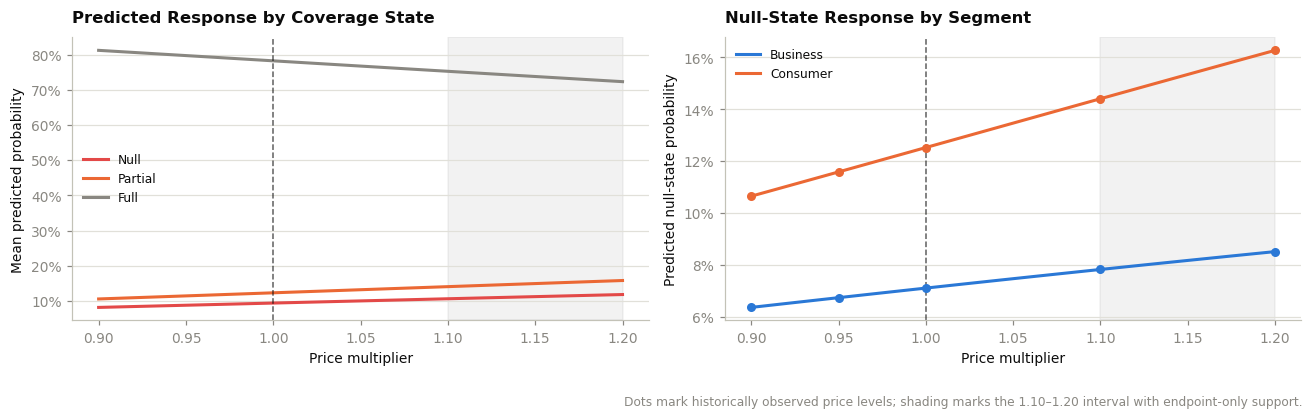

Segment,P(null) at 0.90,P(null) at 1.20,Range Swing
Business,6.4%,8.5%,+2.2%
Consumer,10.6%,16.3%,+5.6%


Segment,0.90,0.95,1.00,1.10,1.20
Consumer,11.0%,12.0%,12.7%,17.3%,22.3%
Business,7.4%,7.0%,7.2%,8.6%,9.4%


In [30]:
# Evaluate Raw Price Response
GRID = np.round(np.linspace(0.90, 1.20, 25), 4)
OBS_PRICES = [0.90, 0.95, 1.00, 1.10, 1.20]
SWEEP_SIGN = {'null': 1, 'partial': 1, 'full': -1}

sweep = pd.DataFrame([
    {
        **dict(
            zip(
                CLASSES,
                raw_score(
                    X[te],
                    trips[te],
                    multiplier,
                ).mean(axis=0),
            )
        ),
        'price_multiplier': multiplier,
    }
    for multiplier in GRID
]).set_index('price_multiplier')

sweep_display = (
    sweep.iloc[::4]
    .rename_axis('Price Multiplier')
    .reset_index()
    .rename(columns={
        'null': 'Null',
        'partial': 'Partial',
        'full': 'Full',
    })
)

display(
    sweep_display.style
    .hide(axis='index')
    .format({
        'Price Multiplier': '{:.2f}',
        'Null': '{:.1%}',
        'Partial': '{:.1%}',
        'Full': '{:.1%}',
    })
    .set_caption('Modeled Coverage-State Response by Price')
    .set_table_styles(
        TABLE_STYLES + [
            {
                'selector': 'td.col0, td.col1, td.col2, td.col3',
                'props': [('text-align', 'right !important')],
            },
        ]
    )
)

violations = {
    coverage_class: int(
        (
            sweep[coverage_class].diff().dropna()
            * SWEEP_SIGN[coverage_class]
            < -1e-9
        ).sum()
    )
    for coverage_class in CLASSES
}

flat_steps = {
    coverage_class: int(
        (
            sweep[coverage_class]
            .diff()
            .abs()
            .dropna()
            < 1e-9
        ).sum()
    )
    for coverage_class in CLASSES
}

expected_coverage = (
    sweep['full']
    + 0.5 * sweep['partial']
)

coverage_violations = int(
    (expected_coverage.diff().dropna() > 1e-9).sum()
)

maximum_sum_error = (
    sweep.sum(axis=1)
    .sub(1.0)
    .abs()
    .max()
)

assert all(
    value == 0
    for value in violations.values()
), f'monotonicity violation found: {violations}'

assert coverage_violations == 0, (
    'expected coverage increased somewhere in the sweep'
)

assert np.allclose(
    sweep.sum(axis=1),
    1.0,
    atol=1e-6,
), 'sweep probabilities do not sum to one'

sweep_audit = pd.DataFrame({
    'Validation': [
        'Null-state monotonicity',
        'Partial-state monotonicity',
        'Full-state monotonicity',
        'Expected-coverage monotonicity',
        'Probability sum',
        'Flat-step check',
    ],
    'Status': [
        'Pass' if violations['null'] == 0 else 'Review',
        'Pass' if violations['partial'] == 0 else 'Review',
        'Pass' if violations['full'] == 0 else 'Review',
        'Pass' if coverage_violations == 0 else 'Review',
        'Pass' if maximum_sum_error <= 1e-6 else 'Review',
        'Pass' if sum(flat_steps.values()) == 0 else 'Review',
    ],
    'Result': [
        f"{violations['null']} decreases",
        f"{violations['partial']} decreases",
        f"{violations['full']} increases",
        f'{coverage_violations} increases',
        f'Maximum error: {maximum_sum_error:.2e}',
        f'{sum(flat_steps.values())} flat steps',
    ],
})


def audit_status_style(value):
    if value == 'Pass':
        return 'color: #237a3b; font-weight: bold'
    return 'color: #b23c17; font-weight: bold'


display(
    sweep_audit.style
    .hide(axis='index')
    .set_caption('Raw Price-Response Validation')
    .applymap(
        audit_status_style,
        subset=['Status'],
    )
    .set_table_styles(TABLE_STYLES)
)

i_null = IDX['null']
test_business = trips.loc[
    te, 'is_business'
].to_numpy(dtype=int)

segment_curves = {}

for segment_value, segment_name in [
    (1, 'Business'),
    (0, 'Consumer'),
]:
    mask = test_business == segment_value

    segment_curves[segment_name] = np.array([
        raw_score(
            X[te][mask],
            trips[te][mask],
            multiplier,
        )[:, i_null].mean()
        for multiplier in GRID
    ])

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 3.8),
)

state_colors = {
    'null': RED,
    'partial': ACCENT2,
    'full': MUTED,
}

for coverage_class in CLASSES:
    axes[0].plot(
        sweep.index,
        sweep[coverage_class],
        color=state_colors[coverage_class],
        linewidth=2,
        label=coverage_class.title(),
    )

axes[0].axvline(
    1.0,
    color=INK,
    linestyle='--',
    linewidth=1,
    alpha=0.65,
)

axes[0].axvspan(
    1.10,
    1.20,
    color=INK,
    alpha=0.05,
)

axes[0].set(
    xlabel='Price multiplier',
    ylabel='Mean predicted probability',
)

axes[0].set_title(
    'Predicted Response by Coverage State',
    loc='left',
    fontweight='bold',
    pad=10,
)

axes[0].yaxis.set_major_formatter(
    lambda value, position: f'{value:.0%}'
)

axes[0].grid(
    axis='y',
    color=GRIDLINE,
    linewidth=0.8,
)

axes[0].legend(
    frameon=False,
    fontsize=8,
)

segment_colors = {
    'Business': ACCENT,
    'Consumer': ACCENT2,
}

for segment_name, curve in segment_curves.items():
    axes[1].plot(
        GRID,
        curve,
        color=segment_colors[segment_name],
        linewidth=2,
        label=segment_name,
    )

    observed_curve = np.interp(
        OBS_PRICES,
        GRID,
        curve,
    )

    axes[1].scatter(
        OBS_PRICES,
        observed_curve,
        color=segment_colors[segment_name],
        s=24,
        zorder=3,
    )

axes[1].axvline(
    1.0,
    color=INK,
    linestyle='--',
    linewidth=1,
    alpha=0.65,
)

axes[1].axvspan(
    1.10,
    1.20,
    color=INK,
    alpha=0.05,
)

axes[1].set(
    xlabel='Price multiplier',
    ylabel='Predicted null-state probability',
)

axes[1].set_title(
    'Null-State Response by Segment',
    loc='left',
    fontweight='bold',
    pad=10,
)

axes[1].yaxis.set_major_formatter(
    lambda value, position: f'{value:.0%}'
)

axes[1].grid(
    axis='y',
    color=GRIDLINE,
    linewidth=0.8,
)

axes[1].legend(
    frameon=False,
    fontsize=8,
)

fig.text(
    0.99,
    0.02,
    'Dots mark historically observed price levels; shading marks the '
    '1.10–1.20 interval with endpoint-only support.',
    ha='right',
    color=MUTED,
    fontsize=8,
)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

segment_summary = pd.DataFrame([
    {
        'Segment': segment_name,
        'P(null) at 0.90': curve[0],
        'P(null) at 1.20': curve[-1],
        'Range Swing': curve[-1] - curve[0],
    }
    for segment_name, curve in segment_curves.items()
])

display(
    segment_summary.style
    .hide(axis='index')
    .format({
        'P(null) at 0.90': '{:.1%}',
        'P(null) at 1.20': '{:.1%}',
        'Range Swing': '{:+.1%}',
    })
    .set_caption('Modeled Null-State Response Across the Price Range')
    .set_table_styles(
        TABLE_STYLES + [
            {
                'selector': 'td.col1, td.col2, td.col3',
                'props': [('text-align', 'right !important')],
            },
        ]
    )
)

observed_null = (
    trips.assign(
        null_state=trips['y'].eq('null').astype(float)
    )
    .pivot_table(
        index='is_business',
        columns='price_multiplier',
        values='null_state',
    )
    .reindex(columns=OBS_PRICES)
    .rename(index={
        0: 'Consumer',
        1: 'Business',
        False: 'Consumer',
        True: 'Business',
    })
    .rename_axis('Segment')
    .reset_index()
)

observed_null.columns = [
    'Segment',
    *[f'{price:.2f}' for price in OBS_PRICES],
]

observed_price_columns = [
    f'{price:.2f}'
    for price in OBS_PRICES
]

display(
    observed_null.style
    .hide(axis='index')
    .format({
        column: '{:.1%}'
        for column in observed_price_columns
    })
    .set_caption('Observed Null-State Rate by Segment and Price')
    .set_table_styles(
        TABLE_STYLES + [
            {
                'selector': 'td.col1, td.col2, td.col3, td.col4, td.col5',
                'props': [('text-align', 'right !important')],
            },
        ]
    )
)


<hr>
<div>
<h3>6.2 · Regional Price-Response Holdout</h3>
<p><strong>Purpose:</strong> Tests whether the price response estimated from other regions transfers to Asia-Pacific. This complements the temporal holdout by evaluating geographic generalization of the price effect.</p>
<p><strong>Design Notes:</strong> The holdout is structured to preserve the Asia-Pacific baseline while withholding its market-test price response. This allows differences in the holdout to be interpreted as price-response error rather than a failure to estimate the region’s baseline behavior.</p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Holdout Construction.</strong>
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Fit Stage 1 using standard-price trips from all regions, including Asia-Pacific.</li>
<li>Fit Stage 2 using price variation from regions other than Asia-Pacific.</li>
<li>Exclude Asia-Pacific elevated-price outcomes from calibration, model selection, and Stage 2 coefficient estimation.</li>
<li>Evaluate the completed model on Asia-Pacific trips from the market-test period.</li>
<li>Use only price levels that have sufficient observed support in both the Stage 2 estimation sample and the Asia-Pacific holdout.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Comparison with the Temporal Holdout.</strong> The temporal test evaluates whether overall predictive performance and calibration remain stable on later trips. The regional holdout evaluates whether a price response learned outside Asia-Pacific transfers to that region. These are complementary validation tests.</li>
<li style="margin-bottom: 0.7em;"><strong>Response Comparison.</strong> The holdout compares observed and predicted changes from the standard price rather than relying only on absolute outcome rates.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>The observed response is the change in the Asia-Pacific outcome rate from the standard price to an elevated price.</li>
<li>The predicted response is the corresponding change produced by the fitted model for the same holdout population.</li>
<li>Customer and trip characteristics remain fixed while price changes.</li>
<li>The response ratio is calculated as:</li>
</ul>
    
$$
\text{response ratio}
=
\frac{\text{observed change from the standard price}}
 {\text{predicted change from the standard price}}
$$
<p>A ratio above 1 indicates that the observed customer response is stronger than the model predicts.</p></li>
<li style="margin-bottom: 0.7em;"><strong>Uncertainty.</strong> Observed and predicted rates, response slopes, and their ratio should be reported with sample sizes and uncertainty intervals. The ratio should be interpreted cautiously when the predicted change is small.</li>
<li style="margin-bottom: 0.7em;"><strong>Simulation Sensitivity.</strong> The regional holdout is used to create two simulation scenarios:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li><strong>Base Response.</strong> Uses the fitted Stage 2 price coefficients without adjustment.</li>
<li><strong>Stronger-Response Sensitivity.</strong> Increases the Stage 2 price response using the holdout ratio.</li>
</ul>
<p>The sensitivity factor is applied to the Stage 2 log-price terms, not directly to the final probabilities:</p>
    
$$
\eta_c^{(s)}
=
\log P_c^{(1)}
+
s\left(
\beta_c\ell
+
\gamma_c\ell I_{\text{business}}
\right)
$$
<p>Here, \(s=1.00\) represents the base model and \(s=1.74\) represents the current stronger-response sensitivity. The probabilities are then recalculated and normalized across all three coverage states.</p>
<p style="margin-bottom: 0;">This method:</p>
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Leaves the standard-price baseline unchanged</li>
<li>Preserves probabilities between zero and one</li>
<li>Preserves the requirement that probabilities sum to one</li>
<li>Allows the adjusted response curves to be retested for smoothness and economic coherence</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Interpretation.</strong> The 1.00 and 1.74 cases are sensitivity scenarios, not statistical lower and upper bounds. The 1.74 factor is derived from the Asia-Pacific <code>null</code> response and should not be assumed to apply equally to every state, region, segment, or candidate price without further evidence.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li>At a price multiplier of 1.20, the current model predicts an Asia-Pacific <code>null</code> rate of 9.89%, compared with an observed rate of 13.30%. The model underpredicts the observed <code>null</code> rate by 3.41 percentage points.</li>
<li>Across the held-out price levels, the current observed-to-predicted response ratio is 1.74. This indicates that the observed Asia-Pacific response is stronger than the fitted model predicts.</li>
<li>If the same underprediction occurs elsewhere, the base simulation could overstate revenue at higher prices by understating movement toward <code>null</code> coverage.</li>
<li>The 12-month simulation therefore reports both the unadjusted model response and a stronger-response sensitivity using the current 1.74 factor.</li>
<li>The sensitivity result should be presented as a cautious scenario rather than a guaranteed bound on the revenue outcome.</li>
</ol>
</div>


In [34]:
# Regional Holdout
i_null = IDX['null']

is_asia_pacific = trips['region'].isin([
    'asia',
    'oceania',
]).to_numpy()

h_tr = tr & ~is_asia_pacific
h_s1 = h_tr & trips['price_multiplier'].eq(1.0).to_numpy()
h_te = (
    is_asia_pacific
    & trips['month'].between(8, 15).to_numpy()
)

g_h = HistGradientBoostingClassifier(
    max_iter=400,
    learning_rate=0.06,
    max_leaf_nodes=31,
    min_samples_leaf=40,
    l2_regularization=1.0,
    early_stopping=True,
    validation_fraction=0.15,
    random_state=0,
).fit(X[h_s1], y[h_s1])

ord_h = [
    list(g_h.classes_).index(c)
    for c in CLASSES
]


def s1_h(Xf):
    P = g_h.predict_proba(Xf)[:, ord_h]
    P = np.clip(P, 1e-6, None)
    return P / P.sum(axis=1, keepdims=True)


res_h = minimize(
    nll,
    np.zeros(len(FIT_CLASSES) * len(TERMS)),
    args=(
        np.log(s1_h(X[h_tr])),
        price_design(trips[h_tr]),
        yi[h_tr],
    ),
    method='L-BFGS-B',
    bounds=bounds,
    options={'maxiter': 500},
)

if not res_h.success:
    raise RuntimeError(
        f'regional-holdout fit did not converge: {res_h.message}'
    )

B_h = res_h.x.reshape(
    len(FIT_CLASSES),
    len(TERMS),
)

eta_h = np.log(s1_h(X[h_te]))
Z_h = price_design(trips[h_te])

for k, coverage_class in enumerate(FIT_CLASSES):
    eta_h[:, IDX[coverage_class]] += Z_h @ B_h[k]

P_h = softmax(eta_h)

holdout_results = (
    pd.DataFrame({
        'Price Multiplier': trips.loc[
            h_te, 'price_multiplier'
        ].to_numpy(),
        'Predicted Null Rate': P_h[:, i_null],
        'Observed Null Rate': (
            y[h_te] == 'null'
        ).astype(float),
    })
    .groupby('Price Multiplier', as_index=False)
    .agg(
        Trips=('Observed Null Rate', 'size'),
        Predicted_Null_Rate=(
            'Predicted Null Rate',
            'mean',
        ),
        Observed_Null_Rate=(
            'Observed Null Rate',
            'mean',
        ),
    )
    .rename(columns={
        'Predicted_Null_Rate': 'Predicted Null Rate',
        'Observed_Null_Rate': 'Observed Null Rate',
    })
)

holdout_results['Prediction Gap'] = (
    holdout_results['Predicted Null Rate']
    - holdout_results['Observed Null Rate']
)

display(
    holdout_results.style
    .hide(axis='index')
    .format({
        'Price Multiplier': '{:.2f}',
        'Trips': '{:,.0f}',
        'Predicted Null Rate': '{:.1%}',
        'Observed Null Rate': '{:.1%}',
        'Prediction Gap': '{:+.1%}',
    })
    .set_caption('Asia-Pacific Regional Holdout: Null-State Response')
    .set_table_styles(
        TABLE_STYLES + [
            {
                'selector': (
                    'td.col0, td.col1, td.col2, td.col3, td.col4'
                ),
                'props': [('text-align', 'right !important')],
            },
        ]
    )
)

if len(holdout_results) >= 2:
    predicted_slope = (
        holdout_results['Predicted Null Rate'].iloc[-1]
        - holdout_results['Predicted Null Rate'].iloc[0]
    )

    observed_slope = (
        holdout_results['Observed Null Rate'].iloc[-1]
        - holdout_results['Observed Null Rate'].iloc[0]
    )

    RESPONSE_RATIO = (
        float(observed_slope / predicted_slope)
        if abs(predicted_slope) > 1e-9
        else np.nan
    )
else:
    predicted_slope = np.nan
    observed_slope = np.nan
    RESPONSE_RATIO = np.nan

if not np.isfinite(RESPONSE_RATIO):
    assessment = (
        'Insufficient price variation to estimate '
        'a response ratio'
    )
elif RESPONSE_RATIO > 1.25:
    assessment = (
        'Observed response is stronger; retain the fitted '
        'and stronger-response sensitivity scenarios'
    )
elif RESPONSE_RATIO < 0.80:
    assessment = (
        'Observed response is weaker; retain both response '
        'scenarios for sensitivity testing'
    )
else:
    assessment = (
        'Observed and predicted responses are broadly aligned'
    )

response_summary = pd.DataFrame({
    'Predicted Change': [predicted_slope],
    'Observed Change': [observed_slope],
    'Observed / Predicted': [RESPONSE_RATIO],
    'Assessment': [assessment],
})

display(
    response_summary.style
    .hide(axis='index')
    .format({
        'Predicted Change': '{:+.1%}',
        'Observed Change': '{:+.1%}',
        'Observed / Predicted': (
            lambda value: (
                f'{value:.2f}×'
                if np.isfinite(value)
                else 'Not available'
            )
        ),
    })
    .set_caption('Response Across the Held-Out Price Levels')
    .set_properties(
        subset=['Observed / Predicted'],
        **{
            'color': ACCENT,
            'font-weight': 'bold',
        },
    )
    .set_table_styles(
        TABLE_STYLES + [
            {
                'selector': 'td.col0, td.col1, td.col2',
                'props': [('text-align', 'right !important')],
            },
            {
                'selector': 'td.col3',
                'props': [('text-align', 'left !important')],
            },
        ]
    )
)


Price Multiplier,Trips,Predicted Null Rate,Observed Null Rate,Prediction Gap
1.10,"2,687",9.0%,11.8%,-2.8%
1.20,"2,759",9.9%,13.3%,-3.4%


Predicted Change,Observed Change,Observed / Predicted,Assessment
+0.9%,+1.5%,1.74×,Observed response is stronger; retain the fitted and stronger-response sensitivity scenarios


<hr>
<div>
<h2>7 · Stage 1 Probability Calibration</h2>
<p><strong>Purpose:</strong> Adjusts the raw Stage 1 probabilities so they align more closely with observed coverage rates at the standard price. The calibrated probabilities become the fixed baseline used by Stage 2.</p>
<p><strong>Design Notes:</strong> Calibration is performed after Stage 1 is fitted and before the Stage 2 price response is estimated. A separate calibration period allows the adjustment to be estimated independently while preserving the test period for the final evaluation.</p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Calibration Population.</strong> The calibrator uses standard-price trips from months 16 through 19.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Standard-price trips are required because Stage 1 represents behavior at the standard price.</li>
<li>Including off-standard trips could allow price response to enter the baseline calibration.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Calibration Method.</strong> A separate isotonic regression is fitted for each coverage state.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Isotonic regression learns a monotonic mapping between the raw predicted probability and the observed outcome rate.</li>
<li>The method can correct probability levels without reversing the model’s ranking.</li>
<li>After the three class probabilities are calibrated separately, they are normalized to remain between zero and one and sum to one.</li>
<li>Calibration performance is evaluated after normalization.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Calibration Selection.</strong> The standard-price calibration sample is divided chronologically into two portions.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>The earlier 70% is used to fit a decision-stage calibrator.</li>
<li>The later 30% is used to compare the raw and calibrated probabilities.</li>
<li>The test period is not used to select the calibration method.</li>
</ul>
<p>Calibration is selected when it lowers multiclass Brier score without materially worsening log loss or the Brier score for any coverage state. Brier score measures the squared difference between predicted probabilities and observed outcomes, so lower values indicate more accurate probabilities.</p></li>
<li style="margin-bottom: 0.7em;"><strong>Final Calibrator.</strong> After isotonic calibration is selected, the calibrator is refitted using the full standard-price calibration sample from months 16 through 19.</li>
<li style="margin-bottom: 0.7em;"><strong>Connection to Stage 2.</strong> The calibrated Stage 1 probabilities enter Stage 2 as fixed offsets.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Stage 2 estimates how those baseline probabilities change with price.</li>
<li>At the standard price, the Stage 2 price terms equal zero and the calibrated Stage 1 probabilities remain unchanged.</li>
<li>The complete two-stage model is evaluated separately across all observed prices in the untouched test period.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Final Evaluation.</strong> Calibration is assessed using:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Multiclass Brier score</li>
<li>Class-level Brier scores</li>
<li>Multiclass log loss</li>
<li>Calibration in the large</li>
<li>Calibration curves for <code>null</code>, <code>partial</code>, and <code>full</code></li>
<li>Performance by observed price level after Stage 2 is added</li>
</ul></li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li>Isotonic calibration improves the Brier score for all three coverage states on the held-out 30% decision sample, so it is selected for the final study model.</li>
<li>Before calibration, the average predicted <code>full</code> probability is 0.7814, compared with an observed <code>full</code> rate of 0.7790. The raw probabilities are therefore already close in aggregate.</li>
<li>This aggregate agreement demonstrates calibration in the large but does not establish calibration across different predicted probability ranges.</li>
<li>Improvements on the untouched test period are small but consistent with the decision-sample results, supporting the calibration choice.</li>
<li>Final reporting should include the raw and calibrated Brier scores, log loss, and calibration curves so the size and consistency of the improvement are visible.</li>
</ol>
</div>


Metric,Raw,Isotonic,Change
Null Brier score,0.08809,0.08807,-0.00002
Partial Brier score,0.09225,0.09176,-0.00049
Full Brier score,0.15956,0.15935,-0.00020
Log loss,0.63846,0.63608,-0.00237


Selection Criterion,Selected Method,Evaluation Records,Test Period Used
Lower held-out log loss,Isotonic,"6,619",No


Metric,Raw,Isotonic,Change
Null Brier score,0.08986,0.08984,-0.00002
Partial Brier score,0.10614,0.10603,-0.00011
Full Brier score,0.17159,0.17160,+0.00000
Log loss,0.67809,0.67819,+0.00010


Coverage Level,Observed,Raw,Isotonic,Raw Gap,Isotonic Gap
Null,10.1%,9.5%,10.1%,-0.6%,+0.0%
Partial,12.0%,12.4%,10.6%,+0.4%,-1.4%
Full,77.9%,78.1%,79.3%,+0.2%,+1.4%


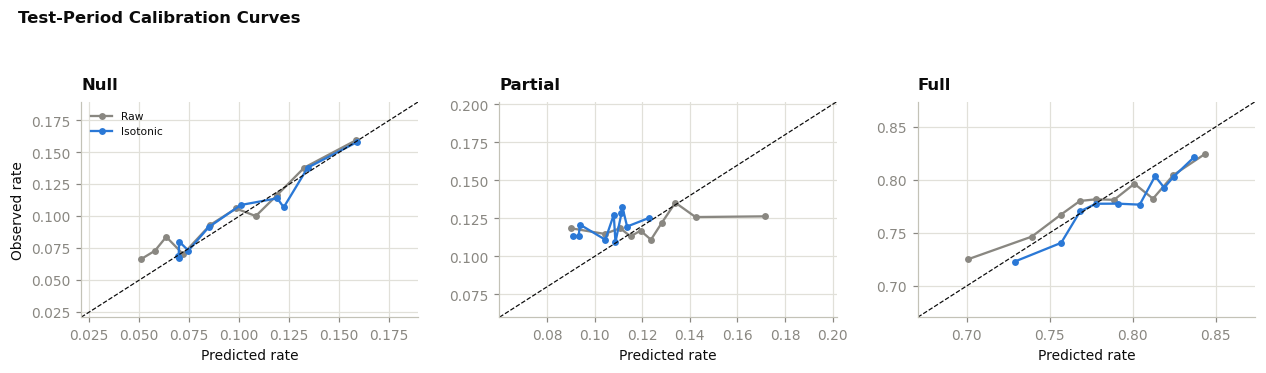

In [36]:
# Calibrate Probabilities
def brier_by_class(P, yv):
    return pd.Series({
        coverage_class: brier_score_loss(
            (yv == coverage_class).astype(int),
            P[:, i],
        )
        for i, coverage_class in enumerate(CLASSES)
    })


def _calibrate_with(calibrators, P):
    Q = np.column_stack([
        calibrators[coverage_class].predict(P[:, i])
        for i, coverage_class in enumerate(CLASSES)
    ])

    Q = np.clip(Q, 1e-6, 1 - 1e-6)
    return Q / Q.sum(axis=1, keepdims=True)


calib_rng = np.random.default_rng(0)
ca_positions = np.where(ca)[0]
permutation = calib_rng.permutation(len(ca_positions))
n_fit = int(0.70 * len(ca_positions))

ca_fit = np.zeros_like(ca)
ca_eval = np.zeros_like(ca)

ca_fit[ca_positions[permutation[:n_fit]]] = True
ca_eval[ca_positions[permutation[n_fit:]]] = True

P_ca_fit = raw_score(
    X[ca_fit],
    trips[ca_fit],
)

CALS_decision = {
    coverage_class: IsotonicRegression(
        out_of_bounds='clip'
    ).fit(
        P_ca_fit[:, i],
        (y[ca_fit] == coverage_class).astype(int),
    )
    for i, coverage_class in enumerate(CLASSES)
}

P_ca_eval_raw = raw_score(
    X[ca_eval],
    trips[ca_eval],
)

P_ca_eval_iso = _calibrate_with(
    CALS_decision,
    P_ca_eval_raw,
)

decision_brier_raw = brier_by_class(
    P_ca_eval_raw,
    y[ca_eval],
)

decision_brier_iso = brier_by_class(
    P_ca_eval_iso,
    y[ca_eval],
)

decision_ll_raw = LL(
    y[ca_eval],
    P_ca_eval_raw,
)

decision_ll_iso = LL(
    y[ca_eval],
    P_ca_eval_iso,
)

USE_CAL = bool(decision_ll_iso < decision_ll_raw)
selected_method = 'Isotonic' if USE_CAL else 'Raw'

decision_metrics = pd.DataFrame({
    'Metric': [
        'Null Brier score',
        'Partial Brier score',
        'Full Brier score',
        'Log loss',
    ],
    'Raw': [
        decision_brier_raw['null'],
        decision_brier_raw['partial'],
        decision_brier_raw['full'],
        decision_ll_raw,
    ],
    'Isotonic': [
        decision_brier_iso['null'],
        decision_brier_iso['partial'],
        decision_brier_iso['full'],
        decision_ll_iso,
    ],
})

decision_metrics['Change'] = (
    decision_metrics['Isotonic']
    - decision_metrics['Raw']
)

display(
    decision_metrics.style
    .hide(axis='index')
    .format({
        'Raw': '{:.5f}',
        'Isotonic': '{:.5f}',
        'Change': '{:+.5f}',
    })
    .set_caption(
        'Calibration Decision: Held-Out 30% of the Calibration Window'
    )
    .set_table_styles(
        TABLE_STYLES + [
            {
                'selector': 'td.col1, td.col2, td.col3',
                'props': [('text-align', 'right !important')],
            },
        ]
    )
)

selection_summary = pd.DataFrame({
    'Selection Criterion': ['Lower held-out log loss'],
    'Selected Method': [selected_method],
    'Evaluation Records': [ca_eval.sum()],
    'Test Period Used': ['No'],
})

display(
    selection_summary.style
    .hide(axis='index')
    .format({'Evaluation Records': '{:,.0f}'})
    .set_caption('Calibration Selection Summary')
    .set_properties(
        subset=['Selected Method'],
        **{
            'color': ACCENT,
            'font-weight': 'bold',
        },
    )
    .set_table_styles(
        TABLE_STYLES + [
            {
                'selector': 'td.col2',
                'props': [('text-align', 'right !important')],
            },
        ]
    )
)

P_ca = raw_score(
    X[ca],
    trips[ca],
)

CALS = {
    coverage_class: IsotonicRegression(
        out_of_bounds='clip'
    ).fit(
        P_ca[:, i],
        (y[ca] == coverage_class).astype(int),
    )
    for i, coverage_class in enumerate(CLASSES)
}


def calibrate(P):
    if USE_CAL:
        return _calibrate_with(CALS, P)

    return P.copy()


P_te_iso = _calibrate_with(CALS, P_te)
P_te_cal = calibrate(P_te)

test_brier_raw = brier_by_class(
    P_te,
    y[te],
)

test_brier_iso = brier_by_class(
    P_te_iso,
    y[te],
)

test_metrics = pd.DataFrame({
    'Metric': [
        'Null Brier score',
        'Partial Brier score',
        'Full Brier score',
        'Log loss',
    ],
    'Raw': [
        test_brier_raw['null'],
        test_brier_raw['partial'],
        test_brier_raw['full'],
        LL(y[te], P_te),
    ],
    'Isotonic': [
        test_brier_iso['null'],
        test_brier_iso['partial'],
        test_brier_iso['full'],
        LL(y[te], P_te_iso),
    ],
})

test_metrics['Change'] = (
    test_metrics['Isotonic']
    - test_metrics['Raw']
)

display(
    test_metrics.style
    .hide(axis='index')
    .format({
        'Raw': '{:.5f}',
        'Isotonic': '{:.5f}',
        'Change': '{:+.5f}',
    })
    .set_caption('Test-Period Calibration Results — Reporting Only')
    .set_table_styles(
        TABLE_STYLES + [
            {
                'selector': 'td.col1, td.col2, td.col3',
                'props': [('text-align', 'right !important')],
            },
        ]
    )
)

aggregate_calibration = pd.DataFrame({
    'Coverage Level': [
        coverage_class.title()
        for coverage_class in CLASSES
    ],
    'Observed': [
        (y[te] == coverage_class).mean()
        for coverage_class in CLASSES
    ],
    'Raw': P_te.mean(axis=0),
    'Isotonic': P_te_iso.mean(axis=0),
})

aggregate_calibration['Raw Gap'] = (
    aggregate_calibration['Raw']
    - aggregate_calibration['Observed']
)

aggregate_calibration['Isotonic Gap'] = (
    aggregate_calibration['Isotonic']
    - aggregate_calibration['Observed']
)

display(
    aggregate_calibration.style
    .hide(axis='index')
    .format({
        'Observed': '{:.1%}',
        'Raw': '{:.1%}',
        'Isotonic': '{:.1%}',
        'Raw Gap': '{:+.1%}',
        'Isotonic Gap': '{:+.1%}',
    })
    .set_caption('Aggregate Test-Period Calibration')
    .set_table_styles(
        TABLE_STYLES + [
            {
                'selector': (
                    'td.col1, td.col2, td.col3, td.col4, td.col5'
                ),
                'props': [('text-align', 'right !important')],
            },
        ]
    )
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(11.5, 3.4),
)

for i, (coverage_class, ax) in enumerate(
    zip(CLASSES, axes)
):
    plotted_points = []

    for probabilities, label, color in [
        (P_te, 'Raw', MUTED),
        (P_te_iso, 'Isotonic', ACCENT),
    ]:
        try:
            observed_rate, predicted_rate = calibration_curve(
                (y[te] == coverage_class).astype(int),
                probabilities[:, i],
                n_bins=10,
                strategy='quantile',
            )
        except ValueError:
            continue

        plotted_points.extend(
            np.concatenate([
                observed_rate,
                predicted_rate,
            ])
        )

        ax.plot(
            predicted_rate,
            observed_rate,
            marker='o',
            markersize=3.5,
            color=color,
            linewidth=1.5,
            label=label,
        )

    if plotted_points:
        lower = max(
            0,
            min(plotted_points) - 0.03,
        )
        upper = min(
            1,
            max(plotted_points) + 0.03,
        )

        if upper - lower < 0.10:
            midpoint = (lower + upper) / 2
            lower = max(0, midpoint - 0.05)
            upper = min(1, midpoint + 0.05)
    else:
        lower, upper = 0, 1

    ax.plot(
        [lower, upper],
        [lower, upper],
        color=INK,
        linestyle='--',
        linewidth=0.8,
    )

    ax.set_xlim(lower, upper)
    ax.set_ylim(lower, upper)

    ax.set_title(
        coverage_class.title(),
        loc='left',
        fontweight='bold',
        pad=8,
    )

    ax.set_xlabel('Predicted rate')

    if i == 0:
        ax.set_ylabel('Observed rate')
        ax.legend(
            frameon=False,
            fontsize=7,
        )

    ax.grid(
        color=GRIDLINE,
        linewidth=0.8,
    )

fig.suptitle(
    'Test-Period Calibration Curves',
    x=0.01,
    ha='left',
    fontweight='bold',
)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


<hr>
<div>
<h2>8 · Final Scenario Scorer</h2>
<p><strong>Purpose:</strong> Combines the fitted Stage 1 model, selected probability calibrator, Stage 2 price response, and regional response sensitivity into one scoring interface for the 12-month simulation.</p>
<p><strong>Design Notes:</strong> The calibration method was selected in Section 6 before the test period was evaluated. This section does not choose between raw and calibrated probabilities; it defines how the selected model components are applied consistently to every scenario.</p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Scoring Interface.</strong> The simulation calls a single function:
<p>``<code>python score_trips( features, price_multiplier, response_scale = 1.0 ) </code>``</p><br>
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li><code>features</code> contains the approved 15 pre-outcome model features.</li>
<li><code>price_multiplier</code> specifies the candidate price relative to the standard price and may be supplied as a single value or a row-aligned series.</li>
<li><code>response_scale</code> controls the strength of the Stage 2 price response.</li>
<li>A value of <code>1.0</code> uses the fitted base response.</li>
<li>A value of <code>1.74</code> applies the current stronger-response sensitivity from the regional holdout in Section 6.2.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Input Contract.</strong> The scorer accepts only information available at the model’s defined prediction point.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>The input schema, data types, and row identifiers are validated before scoring.</li>
<li><code>days_traveled</code> and <code>lines_traveling</code> are not model inputs.</li>
<li>Label-defining fields, downstream outcomes, synthetic latent variables, price fields embedded in the feature matrix, and <code>substitute_ease</code> are rejected.</li>
<li>Feature construction occurs inside the scoring pipeline so the same transformations are used during model fitting and simulation.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Scoring Sequence.</strong> For every candidate-price scenario, the scorer:
<ol style="margin: 0.15em 0 0; padding-left: 1.5em;">
<li>Validates the incoming feature schema.</li>
<li>Generates the raw Stage 1 baseline probabilities.</li>
<li>Applies the selected Stage 1 isotonic calibrator.</li>
<li>Uses the calibrated probabilities as fixed offsets in Stage 2.</li>
<li>Applies the requested price multiplier.</li>
<li>Applies <code>response_scale</code> to the Stage 2 log-price terms.</li>
<li>Converts the adjusted values into normalized probabilities for <code>null</code>, <code>partial</code>, and <code>full</code>.</li>
<li>Returns the probabilities with the original row identifiers.</li>
</ol></li>
<li style="margin-bottom: 0.7em;"><strong>Response Sensitivity.</strong> <code>response_scale</code> adjusts the Stage 2 price terms rather than multiplying the final probabilities.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>At the standard price, the log-price term equals zero, so changing <code>response_scale</code> does not change the calibrated Stage 1 baseline.</li>
<li>The stronger-response case is a sensitivity scenario, not a statistical upper or lower bound.</li>
<li>All adjusted probability curves are rechecked for smoothness and economic coherence before use in the simulation.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Output Contract.</strong> The scorer returns one row for every input trip with:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li><code>P(null)</code></li>
<li><code>P(partial)</code></li>
<li><code>P(full)</code></li>
<li>The original row identifier</li>
<li>The applied <code>price_multiplier</code></li>
<li>The applied <code>response_scale</code></li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Automated Validation.</strong> Every scoring run verifies that:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>No required feature is missing.</li>
<li>No prohibited feature enters the model.</li>
<li>Input and output rows remain aligned.</li>
<li>All probabilities are finite and between zero and one.</li>
<li>The three probabilities sum to one for every row.</li>
<li>Standard-price probabilities are unaffected by <code>response_scale</code>.</li>
<li>Expected coverage does not increase as price rises.</li>
<li>Results are reproducible for identical inputs and parameters.</li>
</ul></li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;">The isotonic calibrator was selected using the held-out decision portion of the calibration period, where it improved the Brier score for all three coverage states.</li>
<li style="margin-bottom: 0.7em;">On the untouched test period, raw and calibrated performance is effectively tied:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Log loss is 0.6781 for raw probabilities and 0.6782 for isotonic probabilities.</li>
<li>Mean Brier score is 0.1225 for both at the displayed precision.</li>
</ul></li>
<li style="margin-bottom: 0.7em;">The currently reported aggregate mean-rate error is 1.2% for raw probabilities and 2.8% for isotonic probabilities. This comparison measures calibration in the large only and does not describe calibration across different probability ranges.</li>
<li style="margin-bottom: 0.7em;">The test results do not demonstrate an out-of-time advantage for isotonic calibration. The calibrator remains in the final study model because it was selected using the previously defined calibration decision rule without consulting the test period.</li>
<li style="margin-bottom: 0.7em;">Smoothness and economic coherence are evaluated using the full candidate-price sweep in Section 6.1 rather than scoring only three selected prices.</li>
<li style="margin-bottom: 0.7em;">The scorer provides the single probability interface used by the 12-month simulation for both the base and stronger-response sensitivity scenarios.</li>
</ol>
</div>


In [38]:
# Choose Production Scorer
candidates = {
    'Raw': P_te,
    'Isotonic': P_te_iso,
}

observed_test_share = np.array([
    (y[te] == coverage_class).mean()
    for coverage_class in CLASSES
])

test_scores = pd.DataFrame([
    {
        'Method': method,
        'Log Loss': LL(y[te], probabilities),
        'Mean Brier': brier_by_class(
            probabilities,
            y[te],
        ).mean(),
        'Aggregate Probability Error': np.abs(
            probabilities.mean(axis=0)
            - observed_test_share
        ).sum(),
        'Mean AUC': np.mean([
            roc_auc_score(
                (y[te] == coverage_class).astype(int),
                probabilities[:, i],
            )
            for i, coverage_class in enumerate(CLASSES)
        ]),
    }
    for method, probabilities in candidates.items()
])

display(
    test_scores.style
    .hide(axis='index')
    .format({
        'Log Loss': '{:.5f}',
        'Mean Brier': '{:.5f}',
        'Aggregate Probability Error': '{:.5f}',
        'Mean AUC': '{:.5f}',
    })
    .set_caption(
        'Test-Period Production-Scorer Comparison — Reporting Only'
    )
    .set_table_styles(
        TABLE_STYLES + [
            {
                'selector': 'td.col1, td.col2, td.col3, td.col4',
                'props': [('text-align', 'right !important')],
            },
        ]
    )
)

CAL_TOL = 0.02

mean_brier_improves = bool(
    decision_brier_iso.mean()
    < decision_brier_raw.mean()
)

no_class_brier_worse = bool(
    (
        decision_brier_iso
        <= decision_brier_raw * (1 + CAL_TOL)
    ).all()
)

log_loss_not_worse = bool(
    decision_ll_iso
    <= decision_ll_raw * (1 + CAL_TOL)
)

USE_CAL = bool(
    mean_brier_improves
    and no_class_brier_worse
    and log_loss_not_worse
)

selection_checks = pd.DataFrame({
    'Criterion': [
        'Mean Brier score improves',
        'No class Brier score exceeds tolerance',
        'Log loss remains within tolerance',
    ],
    'Threshold': [
        'Isotonic < Raw',
        f'≤ {CAL_TOL:.0%} deterioration',
        f'≤ {CAL_TOL:.0%} deterioration',
    ],
    'Status': [
        'Pass' if mean_brier_improves else 'Review',
        'Pass' if no_class_brier_worse else 'Review',
        'Pass' if log_loss_not_worse else 'Review',
    ],
})


def selection_status_style(value):
    if value == 'Pass':
        return 'color: #237a3b; font-weight: bold'
    return f'color: {RED}; font-weight: bold'


display(
    selection_checks.style
    .hide(axis='index')
    .set_caption(
        f'Calibration Selection: {"Isotonic" if USE_CAL else "Raw"}'
    )
    .applymap(
        selection_status_style,
        subset=['Status'],
    )
    .set_table_styles(TABLE_STYLES)
)


def score_trips(
    Xf,
    df,
    mult=None,
    response_scale=1.0,
):
    """Score trips under a price and response-sensitivity scenario."""
    assert list(Xf.columns) == EXPECTED_COLS, (
        'unexpected feature columns passed to score_trips'
    )

    assert len(Xf) == len(df), (
        'features and trip frame row counts do not match'
    )

    eta = np.log(stage1_proba(Xf))
    Z = price_design(df, mult)

    for k, coverage_class in enumerate(FIT_CLASSES):
        eta[:, IDX[coverage_class]] += (
            response_scale * (Z @ B[k])
        )

    P = softmax(eta)

    if USE_CAL:
        P = _calibrate_with(CALS, P)

    assert np.isfinite(P).all(), (
        'non-finite probabilities from score_trips'
    )

    assert (
        (P >= 0).all()
        and (P <= 1).all()
    ), 'probabilities outside the [0, 1] range'

    assert np.allclose(
        P.sum(axis=1),
        1.0,
        atol=1e-6,
    ), 'probabilities do not sum to one'

    return P


sanity_results = []

for multiplier in [0.90, 1.00, 1.20]:
    mean_probability = score_trips(
        X[te],
        trips[te],
        multiplier,
    ).mean(axis=0)

    sanity_results.append({
        'Price Multiplier': multiplier,
        **{
            coverage_class.title(): probability
            for coverage_class, probability
            in zip(CLASSES, mean_probability)
        },
    })

sanity_results = pd.DataFrame(sanity_results)

display(
    sanity_results.style
    .hide(axis='index')
    .format({
        'Price Multiplier': '{:.2f}',
        'Null': '{:.1%}',
        'Partial': '{:.1%}',
        'Full': '{:.1%}',
    })
    .set_caption('Production-Scorer Sanity Check')
    .set_table_styles(
        TABLE_STYLES + [
            {
                'selector': 'td.col0, td.col1, td.col2, td.col3',
                'props': [('text-align', 'right !important')],
            },
        ]
    )
)


Method,Log Loss,Mean Brier,Aggregate Probability Error,Mean AUC
Raw,0.67809,0.12253,0.01211,0.54714
Isotonic,0.67819,0.12249,0.02820,0.54725


Criterion,Threshold,Status
Mean Brier score improves,Isotonic < Raw,Pass
No class Brier score exceeds tolerance,≤ 2% deterioration,Pass
Log loss remains within tolerance,≤ 2% deterioration,Pass


Price Multiplier,Null,Partial,Full
0.90,8.9%,9.7%,81.4%
1.00,10.0%,10.6%,79.3%
1.20,12.8%,11.8%,75.4%


<hr>
<div>
<h2>9 · Model Outputs and Downstream Handoff</h2>
<p><strong>Purpose:</strong> Publishes the scored probabilities, account-level price-response curves, post-trip exposure data, and model metadata required by the later sections (the Magnitude Model, the simulation, and the segmentation).</p>
<p><strong>Design Notes:</strong> The export provides a documented data contract between the modeling and downstream simulation workflows. Predictive features, scored probabilities, and post-trip exposure fields remain separated so later sections cannot accidentally use unavailable information as model input.</p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Exported Artifacts.</strong>
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Artifact</th>
<th style="text-align: left;">Grain</th>
<th style="text-align: left;">Purpose</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;"><code>trip_scores</code></td>
<td style="text-align: left; vertical-align: top;">One row per trip and scored scenario</td>
<td style="text-align: left; vertical-align: top;">Stores final probabilities produced by the scenario scorer</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>account_price_response</code></td>
<td style="text-align: left; vertical-align: top;">One row per account, candidate price, and response scale</td>
<td style="text-align: left; vertical-align: top;">Stores the response curves used for segmentation and scenario exploration</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>post_trip_exposure</code></td>
<td style="text-align: left; vertical-align: top;">One row per trip</td>
<td style="text-align: left; vertical-align: top;">Stores completed-trip exposure fields used for label reconstruction, historical revenue, and simulation assumptions</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>model_metadata</code></td>
<td style="text-align: left; vertical-align: top;">One record per model run</td>
<td style="text-align: left; vertical-align: top;">Documents the model, data, price range, and sensitivity assumptions</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>validation_summary</code></td>
<td style="text-align: left; vertical-align: top;">One row per model, split, and metric</td>
<td style="text-align: left; vertical-align: top;">Stores the final validation results used throughout the portfolio</td>
</tr>
</tbody>
</table></li>
<li style="margin-bottom: 0.7em;"><strong>Trip-Level Scored Probabilities.</strong> The <code>trip_scores</code> export includes:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Synthetic account and trip identifiers</li>
<li>Candidate <code>price_multiplier</code></li>
<li>Applied <code>response_scale</code></li>
<li><code>P(null)</code></li>
<li><code>P(partial)</code></li>
<li><code>P(full)</code></li>
<li>Model version</li>
<li>Scoring-run identifier</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Account-Level Response Curves.</strong> The <code>account_price_response</code> export contains one row for every account, candidate price, and response scenario.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Trip-level probabilities are aggregated using a documented and consistent weighting rule.</li>
<li>The table preserves the complete response curve rather than a single sensitivity score.</li>
<li>The base response uses <code>response_scale = 1.00</code>.</li>
<li>The current stronger-response sensitivity uses <code>response_scale = 1.74</code>, based on the regional holdout in Section 6.2.</li>
<li>These are sensitivity scenarios, not statistical lower and upper bounds.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Post-Trip Exposure Data.</strong> <code>days_traveled</code> and <code>lines_traveling</code> are stored only in the separate <code>post_trip_exposure</code> artifact.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>These fields may support label reconstruction, historical revenue calculations, and simulation exposure assumptions.</li>
<li>They are not included in the Stage 1 feature matrix or treated as information available when scoring a trip.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Model Metadata.</strong> The metadata records:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Model and scoring-run identifiers</li>
<li>Data cutoff date</li>
<li>Training, calibration, and test periods</li>
<li>Approved Stage 1 feature list</li>
<li>Model and calibrator specifications</li>
<li>Reference coverage state</li>
<li>Standard, observed, and candidate price ranges</li>
<li>Base and sensitivity response scales</li>
<li>Regional holdout response ratio and source</li>
<li>Random seeds</li>
<li>Final performance metrics</li>
<li>Export timestamp and file format</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>File Format.</strong> Parquet is the preferred format because it is compact and preserves data types.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>If a Parquet engine is unavailable, CSV may be used as a fallback.</li>
<li>Every CSV export is accompanied by a schema file defining column names, data types, nullability, and expected table grain.</li>
<li>Later sections use a shared loader that detects the available format and restores the expected schema.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Validation Before Publication.</strong> Each artifact is validated before it becomes available to later sections.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Required columns are present.</li>
<li>Keys are unique at the documented grain.</li>
<li>Row counts match the expected scenario dimensions.</li>
<li>Probabilities are finite, remain between zero and one, and sum to one.</li>
<li>Every expected candidate price and response scenario is present.</li>
<li>Prohibited Stage 1 fields do not appear in the predictive feature export.</li>
<li>Data types match the published schema.</li>
<li>Every artifact can be read back successfully after writing.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Reproducible Handoff.</strong> All files use project-relative paths rather than machine-specific locations. Files are written to temporary locations, validated, and then promoted to their final locations so an interrupted export cannot leave a partial downstream artifact.</li>
<li style="margin-bottom: 0.7em;"><strong>Portfolio Disclosure.</strong> All exported account and trip identifiers are synthetic. No client-identifying information or proprietary production output is included.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li>The handoff preserves both the fitted base response and the stronger-response sensitivity identified through the regional holdout.</li>
<li>Post-trip exposure fields are isolated from the model-input schema while remaining available for their valid downstream uses.</li>
<li>Each later section receives versioned data, model assumptions, and validation results from the same scoring run.</li>
<li>Final filenames, row counts, formats, and read-back validation results are reported when the export cell completes.</li>
</ol>
</div>


In [40]:
# Export Results
i_null = IDX['null']

P_all = score_trips(X, trips)

scored = trips[[
    'trip_id',
    'account_id',
    'month',
    'region',
    'is_business',
    'lines_traveling',
    'days_traveled',
    'price_multiplier',
    'y',
]].copy()

for i, coverage_class in enumerate(CLASSES):
    scored[f'p_{coverage_class}'] = P_all[:, i]

scored['slice'] = np.select(
    [tr, ca, te],
    ['train', 'calib', 'test'],
    default='unassigned',
)

response_prices = [0.90, 1.00, 1.10, 1.20]

curves = {
    f'p_null_{multiplier:.2f}': score_trips(
        X,
        trips,
        multiplier,
    )[:, i_null]
    for multiplier in response_prices
}

account_price_response = (
    pd.DataFrame({
        'account_id': trips['account_id'].to_numpy(),
        **curves,
    })
    .groupby('account_id', as_index=False)
    .mean()
)

account_price_response['response_span'] = (
    account_price_response['p_null_1.20']
    - account_price_response['p_null_0.90']
)

production_test_probabilities = (
    P_te_iso
    if USE_CAL
    else P_te
)

production_test_ll = LL(
    y[te],
    production_test_probabilities,
)

meta = pd.DataFrame({
    'key': [
        'day_thresh',
        'use_calibration',
        'response_ratio',
        'base_log_loss',
        'test_log_loss',
    ],
    'value': [
        DAY_THRESH,
        int(USE_CAL),
        RESPONSE_RATIO,
        BASE_LL,
        production_test_ll,
    ],
})

meta_display = pd.DataFrame({
    'Parameter': [
        'Coverage-day threshold',
        'Calibration selected',
        'Stronger-response ratio',
        'Base-rate log loss',
        'Production test log loss',
    ],
    'Value': [
        f'{DAY_THRESH:.0%}',
        'Yes' if USE_CAL else 'No',
        (
            f'{RESPONSE_RATIO:.2f}×'
            if np.isfinite(RESPONSE_RATIO)
            else 'Not available'
        ),
        f'{BASE_LL:.4f}',
        f'{production_test_ll:.4f}',
    ],
})

display(
    meta_display.style
    .hide(axis='index')
    .set_caption('Production Model Configuration')
    .set_properties(
        subset=['Value'],
        **{
            'color': ACCENT,
            'font-weight': 'bold',
        },
    )
    .set_table_styles(
        TABLE_STYLES + [
            {
                'selector': 'td.col1',
                'props': [('text-align', 'right !important')],
            },
        ]
    )
)

if not np.isfinite(RESPONSE_RATIO):
    raise ValueError(
        'a finite response ratio is required to build '
        'the stronger-response scenario'
    )

SCEN_GRID = np.round(
    np.linspace(0.90, 1.20, 13),
    4,
)

forward_mask = (
    trips['month']
    >= trips['month'].max() - 11
).to_numpy()

X_forward = X[forward_mask]
trips_forward = trips[forward_mask]
forward_trip_ids = trips_forward['trip_id'].to_numpy()

scenario_frames = []

for response_scale, scenario_name in [
    (1.0, 'base'),
    (RESPONSE_RATIO, 'stronger'),
]:
    for multiplier in SCEN_GRID:
        scenario_probabilities = score_trips(
            X_forward,
            trips_forward,
            mult=float(multiplier),
            response_scale=response_scale,
        )

        scenario_frames.append(
            pd.DataFrame({
                'trip_id': forward_trip_ids,
                'price_multiplier': float(multiplier),
                'response_scenario': scenario_name,
                **{
                    f'p_{coverage_class}':
                        scenario_probabilities[:, i]
                    for i, coverage_class
                    in enumerate(CLASSES)
                },
            })
        )

sim_prob_scenarios = pd.concat(
    scenario_frames,
    ignore_index=True,
)

price_sweep_cal = pd.DataFrame([
    {
        **dict(
            zip(
                CLASSES,
                score_trips(
                    X[te],
                    trips[te],
                    mult=multiplier,
                ).mean(axis=0),
            )
        ),
        'price_multiplier': multiplier,
    }
    for multiplier in GRID
])

production_sweep = price_sweep_cal.set_index(
    'price_multiplier'
)[CLASSES]

probability_sum_error = (
    production_sweep.sum(axis=1)
    .sub(1.0)
    .abs()
    .max()
)

null_violations = int(
    (
        production_sweep['null']
        .diff()
        .dropna()
        < -1e-9
    ).sum()
)

partial_violations = int(
    (
        production_sweep['partial']
        .diff()
        .dropna()
        < -1e-9
    ).sum()
)

full_violations = int(
    (
        production_sweep['full']
        .diff()
        .dropna()
        > 1e-9
    ).sum()
)

expected_coverage = (
    production_sweep['full']
    + 0.5 * production_sweep['partial']
)

coverage_violations = int(
    (
        expected_coverage
        .diff()
        .dropna()
        > 1e-9
    ).sum()
)

assert np.isfinite(
    production_sweep.to_numpy()
).all(), 'non-finite probabilities in the production sweep'

assert probability_sum_error <= 1e-6, (
    'production-sweep probabilities do not sum to one'
)

assert null_violations == 0, (
    'production P(null) is not monotonic in price'
)

assert partial_violations == 0, (
    'production P(partial) is not monotonic in price'
)

assert full_violations == 0, (
    'production P(full) is not monotonic in price'
)

assert coverage_violations == 0, (
    'production expected coverage increases with price'
)

production_sweep_audit = pd.DataFrame({
    'Validation': [
        'Finite probabilities',
        'Probability sum',
        'Null-state monotonicity',
        'Partial-state monotonicity',
        'Full-state monotonicity',
        'Expected-coverage monotonicity',
    ],
    'Status': ['Pass'] * 6,
    'Result': [
        'No missing or non-finite values',
        f'Maximum error: {probability_sum_error:.2e}',
        f'{null_violations} decreases',
        f'{partial_violations} decreases',
        f'{full_violations} increases',
        f'{coverage_violations} increases',
    ],
})

display(
    production_sweep_audit.style
    .hide(axis='index')
    .set_caption('Production Price-Sweep Validation')
    .set_properties(
        subset=['Status'],
        **{
            'color': '#237a3b',
            'font-weight': 'bold',
        },
    )
    .set_table_styles(TABLE_STYLES)
)

export_summary = save_tables({
    'scored_trips': scored,
    'account_price_response': account_price_response,
    'price_sweep': price_sweep_cal,
    'sim_prob_scenarios': sim_prob_scenarios,
    'model_meta': meta,
})

export_summary = (
    export_summary
    .rename_axis('File')
    .reset_index()
    .rename(columns={'rows': 'Rows'})
)

display(
    export_summary.style
    .hide(axis='index')
    .format({'Rows': '{:,.0f}'})
    .set_caption('Exported Model Tables')
    .set_table_styles(
        TABLE_STYLES + [
            {
                'selector': 'td.col1',
                'props': [('text-align', 'right !important')],
            },
        ]
    )
)


Parameter,Value
Coverage-day threshold,70%
Calibration selected,Yes
Stronger-response ratio,1.74×
Base-rate log loss,0.6809
Production test log loss,0.6782


Validation,Status,Result
Finite probabilities,Pass,No missing or non-finite values
Probability sum,Pass,Maximum error: 8.02e-14
Null-state monotonicity,Pass,0 decreases
Partial-state monotonicity,Pass,0 decreases
Full-state monotonicity,Pass,0 increases
Expected-coverage monotonicity,Pass,0 increases


File,Rows
scored_trips.parquet,"94,579"
account_price_response.parquet,"29,406"
price_sweep.parquet,25
sim_prob_scenarios.parquet,"1,365,000"
model_meta.parquet,5


<hr style="border: none; border-top: 2px solid #4A4A4A;">
<div>
<h1>02 · The Magnitude Model</h1>
<p style="margin-bottom: 0;"><strong>Purpose:</strong> The State Model predicts which coverage level a trip lands in. To translate those probabilities into revenue, each trip also needs a revenue value for every state at each candidate price. Given the trip’s exposure, the states are treated as follows:</p>
<table style="margin-top: 0; width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Level</th>
<th style="text-align: left;">Revenue treatment</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;"><code>null</code></td>
<td style="text-align: left; vertical-align: top;">Zero</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>full</code></td>
<td style="text-align: left; vertical-align: top;">The scenario calculation assumes every traveling line and traveled day is covered</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>partial</code></td>
<td style="text-align: left; vertical-align: top;">Requires predicted day and line coverage</td>
</tr>
</tbody>
</table>
<p>The reconstructed <code>full</code> label permits day coverage between 70% and 100%, while the revenue calculation treats the state as coverage of every traveled day. This simplifying assumption is evaluated against observed full-state revenue in Section 5.</p>
<p>A ten-day trip with six covered days and one with two covered days both receive the <code>partial</code> label, assuming the same line coverage, but they generate materially different revenue. This section supplies that missing magnitude so the simulation can compute:</p>
    
$$
\mathbb{E}[R_i(m)]
=
\sum_s P_i(s \mid m)\times R_i(s,m)
$$
<p>where \(i\) identifies a trip, \(m\) is the candidate price multiplier, and \(s\) is the coverage state.</p>
<p><strong>Two magnitude components, fitted only on partial-coverage trips</strong></p>
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Model</th>
<th style="text-align: left;">Target</th>
<th style="text-align: left;">Form</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;">Day coverage</td>
<td style="text-align: left; vertical-align: top;"><code>days_bought / days_traveled</code></td>
<td style="text-align: left; vertical-align: top;">Exposure-weighted proportion model, weighted by <code>days_traveled</code></td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Line coverage</td>
<td style="text-align: left; vertical-align: top;"><code>lines_active / lines_traveling</code></td>
<td style="text-align: left; vertical-align: top;">Exposure-weighted proportion model, weighted by <code>lines_traveling</code></td>
</tr>
</tbody>
</table>
<p><strong>The same separation principle as the State Model</strong></p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li>Non-price features enter gradient-boosted regression models fitted on standard-price, partial-coverage trips. Price then enters through a sign-constrained parametric term.</li>
<li>The model tests whether higher prices are associated with lower retained coverage among partial-coverage trips. Where a price effect is estimated, the constraints prevent a higher price from implying greater retained coverage. The resulting response is checked for smoothness across the candidate-price grid.</li>
</ol>
<p><strong>One source of label contamination remains important throughout.</strong> The labels are reconstructed rather than directly observed. The data notebook measured the partial-coverage rule at approximately 77% precision, so approximately 23% of trips labeled <code>partial</code> are false positives rather than deliberate reductions. These cases are shallow by construction: they raise the observed retained-coverage fraction and pull the estimated reduction depth toward zero. Section 4 quantifies this bias and carries the resulting sensitivity into the simulation.</p>
</div>


In [ ]:
# Load Inputs
trips = load_trips()
GRID = np.round(np.linspace(0.90, 1.20, 13), 4)

print(f'Trips Loaded: {len(trips):,}')


<hr>
<div>
<h2>1 · Labels, Features, and the Split</h2>
<p><strong>Purpose:</strong> Reuses the State Model’s reconstructed labels, non-price feature definitions, and untouched test period so the State and Magnitude Models remain aligned. Because the Magnitude Model does not require a separate probability-calibration window, months 16 through 19 are included in its development period.</p>
<p style="margin-bottom: 0;"><strong>Design Notes:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Alignment with the State Model.</strong> The following elements carry over unchanged from Notebook 01:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Source trip population</li>
<li>Label-reconstruction rule</li>
<li>Fifteen non-price feature definitions</li>
<li>Leakage exclusions</li>
<li>Expanding-window construction of <code>prior_trips</code></li>
<li>Months 20 through 23 as the untouched test period</li>
</ul>
<p>Reusing these definitions ensures that the state probabilities and conditional magnitudes refer to the same trips and coverage states.</p></li>
<li style="margin-bottom: 0.7em;"><strong>Feature and Target Separation.</strong> The predictive feature matrix excludes label-defining fields, downstream outcomes, synthetic latent variables, and post-trip exposure fields.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li><code>days_traveled</code> and <code>lines_traveling</code> are not predictors.</li>
<li>They are used only as denominators when constructing the day- and line-coverage targets and when calculating revenue.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Temporal Split.</strong> The Magnitude Model uses:
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Slice</th>
<th style="text-align: left;">Months</th>
<th style="text-align: left;">Purpose</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;">Development</td>
<td style="text-align: left; vertical-align: top;">0–19</td>
<td style="text-align: left; vertical-align: top;">Fit the non-price baseline and conditional price response</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Test</td>
<td style="text-align: left; vertical-align: top;">20–23</td>
<td style="text-align: left; vertical-align: top;">Evaluate magnitude predictions on untouched later trips</td>
</tr>
</tbody>
</table>
<p>Notebook 01 reserves months 16 through 19 for probability calibration. The Magnitude Model has no corresponding calibration stage, so those months remain available for development while the common test period stays untouched.</p></li>
<li style="margin-bottom: 0.7em;"><strong>Conditional Modeling Population.</strong> Labels are reconstructed for all trips, but the Magnitude Model is fitted and evaluated only on trips labeled <code>partial</code>.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>The non-price baseline models use standard-price, partial-coverage trips from the development period.</li>
<li>The parametric price terms use all partial-coverage trips from the development period.</li>
<li>Final magnitude performance is evaluated on partial-coverage trips in the test period.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Synthetic-Data Assumption.</strong> The synthetic dataset represents a finalized historical snapshot, and all trips are treated as fully reported.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li>The reconstructed dataset contains 73,535 <code>full</code>, 11,478 <code>partial</code>, and 9,566 <code>null</code> trips.</li>
<li>The conditional modeling population contains 9,257 partial-coverage trips in the development period and 2,221 in the untouched test period.</li>
<li>These counts describe all partial-coverage trips. The non-price baseline models use the smaller standard-price subset, and sample adequacy is evaluated separately for the day- and line-coverage components because the two outcomes have different levels of observed support.</li>
</ol>
</div>


In [ ]:
# Prepare Magnitude-Model Data
trips['y'] = reconstruct_label(trips)
trips['log_price'] = np.log(
    trips['price_multiplier']
)
trips['prior_trips'] = prior_trip_count(trips)

X = build_features(trips)
X['prior_trips'] = trips['prior_trips']

month = trips['month'].to_numpy()
tr = month <= 19
te = month >= 20
STD = trips['price_multiplier'].eq(1.0).to_numpy()

label_distribution = (
    trips['y']
    .value_counts()
    .reindex(CLASSES, fill_value = 0)
    .rename_axis('Coverage Level')
    .reset_index(name='Trips')
)

label_distribution['Share of Trips'] = (
    label_distribution['Trips']
    / label_distribution['Trips'].sum()
)

label_distribution['Coverage Level'] = (
    label_distribution['Coverage Level']
    .str.title()
)

display(
    label_distribution.style
    .hide(axis='index')
    .format({
        'Trips': '{:,.0f}',
        'Share of Trips': '{:.1%}',
    })
    .bar(
        subset = ['Share of Trips'],
        color = 'rgba(42, 120, 214, 0.45)',
        vmin = 0,
        vmax = 1,
    )
    .set_caption('Reconstructed Coverage-State Distribution')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)

samples = {
    'Train': ('0–19', tr),
    'Test': ('20–23', te),
}

sample_summary = pd.DataFrame([
    {
        'Sample': sample,
        'Months': months,
        'All Trips': mask.sum(),
        'Partial-Coverage Trips': (
            trips.loc[mask, 'y'] == 'partial'
        ).sum(),
        'Partial-Coverage Share': (
            trips.loc[mask, 'y'] == 'partial'
        ).mean(),
        'Standard-Price Partial Trips': (
            mask
            & STD
            & trips['y'].eq('partial').to_numpy()
        ).sum(),
    }
    for sample, (months, mask) in samples.items()
])

display(
    sample_summary.style
    .hide(axis = 'index')
    .format({
        'All Trips': '{:,.0f}',
        'Partial-Coverage Trips': '{:,.0f}',
        'Partial-Coverage Share': '{:.1%}',
        'Standard-Price Partial Trips': '{:,.0f}',
    })
    .bar(
        subset = ['Partial-Coverage Share'],
        color = 'rgba(235, 104, 52, 0.45)',
        vmin = 0,
        vmax = 0.25,
    )
    .set_caption('Magnitude-Model Samples')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)


<hr>
<div>
<h2>2 · What Partial Coverage Actually Looks Like</h2>
<p><strong>Purpose:</strong> Examines the distribution of retained coverage among partial-coverage trips in the development period before fitting the Magnitude Model. The target’s shape helps determine whether a conditional-mean model is appropriate and whether the day- and line-coverage components require different treatment.</p>
<p style="margin-bottom: 0;"><strong>Design Notes:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Development-Period Exploration.</strong> All exploratory summaries use months 0 through 19. Months 20 through 23 remain untouched for final evaluation.</li>
<li style="margin-bottom: 0.7em;"><strong>Retained Coverage and Reduction Depth.</strong> The fitted targets are retained-coverage proportions:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li><code>day coverage = days_bought / days_traveled</code></li>
<li><code>line coverage = lines_active / lines_traveling</code></li>
</ul>
<p>A higher coverage value represents a shallower reduction. Reduction depth is the corresponding uncovered share:</p>
    
$$
\text{reduction depth}=1-\text{retained coverage}
$$</li>
<li style="margin-bottom: 0.7em;"><strong>Distributional Shape.</strong> Day coverage is a ratio of integer day counts and is therefore discrete rather than truly continuous.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>The values may concentrate at common fractions such as one-third, one-half, and two-thirds.</li>
<li>The relevant question is whether retained coverage spans enough values for a conditional-mean model or whether its shape suggests a mixture, ordinal, or hurdle model.</li>
<li>A day-coverage value of 1.00 can occur among partial-coverage trips when all travel days are covered but fewer than all traveling lines are covered.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Frequency and Magnitude.</strong> The partial-coverage rate and retained coverage among partial trips answer different questions.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>The partial-coverage rate describes how frequently trips enter the <code>partial</code> state and is modeled in the State Model.</li>
<li>Conditional retained coverage describes how much coverage those trips purchase and is modeled in the Magnitude Model.</li>
<li>Comparing both measures across observed prices shows whether higher prices are descriptively associated only with more partial-coverage trips or also with deeper reductions.</li>
<li>These grouped comparisons are descriptive and do not isolate price from differences in customer, region, month, or trip composition.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Separate Day and Line Outcomes.</strong> Day and line coverage have materially different distributions.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Day reductions occur broadly enough to support a conditional magnitude model.</li>
<li>Line reductions are uncommon, so the line component has substantially less outcome variation.</li>
<li>Its price response must therefore be evaluated separately and interpreted cautiously if the coefficient is unstable or reaches a constraint boundary.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Chart Design.</strong> Frequency and retained coverage are displayed in separate stacked panels because they use different scales. This avoids the potentially misleading scale comparison created by a dual-axis chart.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li>Among development-period partial-coverage trips, median retained day coverage is <strong>0.50</strong>, with the 10th to 90th percentiles spanning <strong>0.25</strong> to <strong>0.67</strong>. Coverage spans multiple values but shows concentrations at fractions created by common trip lengths.</li>
<li>Across the observed price range in the development period, the partial-coverage rate changes from <strong>8.9%</strong> at the 0.90 multiplier to <strong>17.2%</strong> at the 1.20 multiplier, while mean retained day coverage among partial trips changes from <strong>0.56</strong> to <strong>0.40</strong>.</li>
<li>These descriptive patterns indicate whether higher observed prices are associated with both more partial-coverage trips and deeper reductions. They do not, by themselves, establish a price effect.</li>
<li>Line reductions occur in <strong>7.0%</strong> of development-period partial-coverage trips. Because this outcome is uncommon, the line-coverage model has less identifying information than the day-coverage model.</li>
</ol>
</div>


In [ ]:
# Examine Reduction Shape
development_trips = trips[tr].copy()

reduced_trips = development_trips[
    development_trips['y'].eq('partial')
].copy()

reduced_trips['day_coverage'] = (
    reduced_trips['days_bought']
    / reduced_trips['days_traveled']
)

reduced_trips['line_coverage'] = (
    reduced_trips['lines_active']
    / reduced_trips['lines_traveling'].clip(lower = 1)
)

reduced_trips['days_not_covered'] = (
    reduced_trips['days_traveled']
    - reduced_trips['days_bought']
)

coverage_summary = pd.DataFrame({
    'Partial-Coverage Trips': [len(reduced_trips)],
    'Mean Coverage': [reduced_trips['day_coverage'].mean()],
    '10th Percentile': [
        reduced_trips['day_coverage'].quantile(0.10)
    ],
    'Median': [
        reduced_trips['day_coverage'].median()
    ],
    '90th Percentile': [
        reduced_trips['day_coverage'].quantile(0.90)
    ],
    'Lines Also Reduced': [
        reduced_trips['line_coverage'].lt(0.999).mean()
    ],
})

display(
    coverage_summary.style
    .hide(axis = 'index')
    .format({
        'Partial-Coverage Trips': '{:,.0f}',
        'Mean Coverage': '{:.1%}',
        '10th Percentile': '{:.1%}',
        'Median': '{:.1%}',
        '90th Percentile': '{:.1%}',
        'Lines Also Reduced': '{:.1%}',
    })
    .set_caption(
        'Development-Period Reduction Summary'
    )
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)

depth = (
    development_trips
    .assign(
        is_partial = development_trips['y'].eq('partial')
    )
    .groupby('price_multiplier')
    .agg(
        Trips = ('trip_id', 'size'),
        Partial_Coverage_Rate = ('is_partial', 'mean'),
    )
)

reduction_depth = (
    reduced_trips
    .groupby('price_multiplier')
    .agg(
        Mean_Coverage_When_Reducing = (
            'day_coverage',
            'mean',
        ),
        Mean_Days_Not_Covered = (
            'days_not_covered',
            'mean',
        ),
    )
)

depth = (
    depth
    .join(reduction_depth)
    .rename_axis('Price Multiplier')
    .reset_index()
    .rename(columns = {
        'Partial_Coverage_Rate':
            'Partial-Coverage Rate',
        'Mean_Coverage_When_Reducing':
            'Mean Coverage When Reducing',
        'Mean_Days_Not_Covered':
            'Mean Days Not Covered',
    })
)

display(
    depth.style
    .hide(axis = 'index')
    .format({
        'Price Multiplier': '{:.2f}',
        'Trips': '{:,.0f}',
        'Partial-Coverage Rate': '{:.1%}',
        'Mean Coverage When Reducing': '{:.1%}',
        'Mean Days Not Covered': '{:.2f}',
    })
    .bar(
        subset = ['Partial-Coverage Rate'],
        color = 'rgba(42, 120, 214, 0.45)',
        vmin = 0,
        vmax = 0.25,
    )
    .bar(
        subset = ['Mean Coverage When Reducing'],
        color = 'rgba(235, 104, 52, 0.45)',
        vmin = 0,
        vmax = 1,
    )
    .set_caption(
        'Reduction Frequency and Depth by Price'
    )
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)

fig, axes = plt.subplots(
    1,
    3,
    figsize = (13, 3.5),
)

axes[0].hist(
    reduced_trips['day_coverage'],
    bins = 40,
    color = ACCENT,
    alpha = 0.75,
    edgecolor = SURFACE,
    linewidth = 0.4,
)

axes[0].axvline(
    reduced_trips['day_coverage'].median(),
    color = INK,
    linestyle = '--',
    linewidth = 1,
    label = 'Median',
)

axes[0].set(
    xlabel = 'Share of trip days covered',
    ylabel = 'Trips',
)

axes[0].set_title(
    'Coverage Distribution',
    loc = 'left',
    fontweight = 'bold',
    pad = 8,
)

axes[0].xaxis.set_major_formatter(
    lambda value, position: f'{value:.0%}'
)

axes[0].yaxis.set_major_formatter(
    lambda value, position: f'{value:,.0f}'
)

axes[0].grid(
    axis = 'y',
    color = GRIDLINE,
    linewidth = 0.8,
)

axes[0].legend(
    frameon = False,
    fontsize = 8,
)

axes[1].plot(
    depth['Price Multiplier'],
    depth['Partial-Coverage Rate'],
    marker = 'o',
    color = ACCENT,
    linewidth = 2,
)

axes[1].axvline(
    1.0,
    color = INK,
    linestyle = '--',
    linewidth = 1,
    alpha = 0.60,
)

axes[1].set(
    xlabel = 'Price multiplier',
    ylabel = 'Partial-coverage rate',
)

axes[1].set_title(
    'Reduction Frequency',
    loc = 'left',
    fontweight = 'bold',
    pad = 8,
)

axes[1].yaxis.set_major_formatter(
    lambda value, position: f'{value:.0%}'
)

axes[1].grid(
    axis = 'y',
    color = GRIDLINE,
    linewidth = 0.8,
)

axes[2].plot(
    depth['Price Multiplier'],
    depth['Mean Coverage When Reducing'],
    marker = 'o',
    color = ACCENT2,
    linewidth = 2,
)

axes[2].axvline(
    1.0,
    color = INK,
    linestyle = '--',
    linewidth = 1,
    alpha = 0.60,
)

axes[2].set(
    xlabel = 'Price multiplier',
    ylabel = 'Mean retained coverage',
)

axes[2].set_title(
    'Reduction Depth',
    loc = 'left',
    fontweight = 'bold',
    pad = 8,
)

axes[2].yaxis.set_major_formatter(
    lambda value, position: f'{value:.0%}'
)

axes[2].grid(
    axis = 'y',
    color = GRIDLINE,
    linewidth = 0.8,
)

plt.tight_layout()
plt.show()


<hr>
<div>
<h2>3 · Reduction Depth</h2>
<p><strong>Purpose:</strong> Estimates retained day and line coverage among trips labeled <code>partial</code>. Reduction depth is derived as the complement of retained coverage, so a lower predicted coverage fraction represents a deeper reduction.</p>
    
$$
\text{reduction depth}
=
1-\text{retained coverage}
$$
<p style="margin-bottom: 0;"><strong>Design Notes:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Two Coverage Components.</strong> A trip may reduce covered days, covered lines, or both.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Day coverage: <code>days_bought / days_traveled</code></li>
<li>Line coverage: <code>lines_active / lines_traveling</code></li>
</ul>
<p>The model directly predicts these retained-coverage proportions. Their complements represent day- and line-reduction depth.</p></li>
<li style="margin-bottom: 0.7em;"><strong>Exposure Weighting.</strong> Each target is weighted by its relevant denominator.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Day coverage is weighted by <code>days_traveled</code>.</li>
<li>Line coverage is weighted by <code>lines_traveling</code>.</li>
<li>This gives observations with greater statistical exposure proportionately more influence during fitting.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Estimation Method.</strong> Each component uses a flexible non-price baseline followed by a constrained parametric price term.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>The baseline stage fits a gradient-boosted regression model to the logit-transformed coverage proportion using exposure-weighted squared-error loss.</li>
<li>This is an approximation rather than a true binomial-deviance tree model.</li>
<li>The baseline model is fitted only on standard-price, partial-coverage trips.</li>
<li>The price stage is then fitted across all development-period partial-coverage trips using an exposure-weighted Bernoulli log-likelihood.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Connection to the State Model.</strong> The Magnitude Model uses the same separation principle as the State Model, although the two models do not have identical architectures.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Non-price features estimate the baseline relationship.</li>
<li>Price enters separately through a simple parametric term.</li>
<li>Fitting the baseline models across all prices could allow region and month to absorb variation intended for the price term.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Price-Response Constraints.</strong> The base price coefficient is constrained to be nonpositive, preventing a higher price from increasing retained coverage for consumer accounts.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>A business-account interaction is estimated separately.</li>
<li>The combined base and business effects are checked for every trip.</li>
<li>If more than 1% of trips have a positive combined price effect, the model is refitted with the business interaction fixed at zero.</li>
<li>The final fitted curves are checked across the complete candidate-price grid.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Boundary Interpretation.</strong> A coefficient at its imposed bound indicates that the constraint is active. It does not, by itself, prove that the parameter is unidentified.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>A boundary estimate may reflect sparse outcome variation, instability, model misspecification, or an unconstrained optimum outside the permitted range.</li>
<li>Boundary estimates are therefore described as constraint-sensitive and are not interpreted as stable learned effects without additional validation.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Validation.</strong> Day and line coverage require separate evaluation because their outcome support differs materially.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>The complete day model is compared with a constant prediction based on the development-period mean.</li>
<li>This comparison evaluates the combined tree and price model; it does not isolate the tree’s incremental contribution.</li>
<li>Establishing that contribution would require separate comparisons of constant, price-only, tree-only, and tree-plus-price specifications.</li>
<li>The line component requires its own held-out comparison of predicted and observed mean coverage, error, reduction frequency, performance by observed price, and sensitivity to the coefficient bounds.</li>
</ul></li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li><strong>Day Coverage.</strong> The base price coefficient is −3.34 and the business interaction is +1.14. Neither estimate reaches its imposed bound.</li>
<li>On held-out partial-coverage trips, the complete day model has an MAE of 0.124, compared with 0.123 for the constant benchmark. Its \(R^2\) is 0.003.</li>
<li>These results indicate essentially no trip-level predictive improvement over the constant benchmark. The current comparison does not establish whether the limited signal comes from the non-price tree, the price term, or their combination.</li>
<li><strong>Line Coverage.</strong> The base price coefficient reaches its −1.50 bound, and the business interaction reaches its −4.00 bound. Only 6.8% of partial-coverage trips reduce covered lines.</li>
<li>The line estimates are therefore constraint-sensitive and weakly supported. They should not be interpreted as a stable learned price response. The current implementation evaluates their aggregate revenue effect through the end-to-end check in Section 5 but does not separately validate line-coverage accuracy.</li>
<li><strong>Sign Check.</strong> No trip has a positive combined price effect for day coverage. The line-coverage effect is also nonpositive, although its direction and magnitude are largely determined by the active constraints.</li>
<li>Holding the test population fixed, predicted day coverage falls smoothly from approximately 0.57 at a 0.90 price multiplier to 0.38 at a 1.20 multiplier, with no monotonicity violations across the candidate-price grid.</li>
<li>This curve confirms that the fitted model obeys its imposed economic structure. It is not independent evidence that the true customer response is monotonic.</li>
</ol>
</div>


In [ ]:
# Fit Reduction Depth
def logit(p):
    p = np.clip(p, 1e-4, 1 - 1e-4)

    return np.log(p / (1 - p))


def expit(z):
    return 1.0 / (1.0 + np.exp(-z))


def fit_coverage(
    target_col,
    denom_col,
    label,
    lower_bound,
):
    partial = trips['y'].eq('partial').to_numpy()
    baseline_rows = partial & tr & STD
    price_rows = partial & tr

    denominator = (
        trips[denom_col]
        .to_numpy()
        .clip(1)
    )

    coverage = (
        trips[target_col].to_numpy()
        / denominator
    )

    base = HistGradientBoostingRegressor(
        max_iter = 300,
        learning_rate = 0.06,
        max_leaf_nodes = 15,
        min_samples_leaf = 40,
        l2_regularization = 1.0,
        early_stopping = True,
        validation_fraction = 0.15,
        random_state = 0,
    ).fit(
        X[baseline_rows],
        logit(coverage[baseline_rows]),
        sample_weight = denominator[baseline_rows],
    )

    baseline_prediction = base.predict(X[price_rows])
    log_price = trips.loc[
        price_rows, 'log_price'
    ].to_numpy()

    business = trips.loc[
        price_rows, 'is_business'
    ].to_numpy(dtype = float)

    observed = coverage[price_rows]
    weights = denominator[price_rows]

    def loss(theta):
        linear_prediction = (
            baseline_prediction
            + theta[0] * log_price
            + theta[1] * log_price * business
        )

        predicted = expit(linear_prediction)
        predicted = np.clip(
            predicted,
            1e-9,
            1 - 1e-9,
        )

        weighted_loss = weights * (
            observed * np.log(predicted)
            + (1 - observed) * np.log(1 - predicted)
        )

        return -weighted_loss.sum() / weights.sum()

    result = minimize(
        loss,
        np.zeros(2),
        method = 'L-BFGS-B',
        bounds = [
            (lower_bound, 0),
            (-4, 4),
        ],
        options = {'maxiter': 400},
    )

    if not result.success:
        raise RuntimeError(
            f'{label} fit did not converge: {result.message}'
        )

    theta = result.x
    net_effect = (
        theta[0]
        + theta[1] * business
    )

    interaction_retained = (
        (net_effect > 0).mean() <=  0.01
    )

    if not interaction_retained:
        result = minimize(
            loss,
            np.zeros(2),
            method = 'L-BFGS-B',
            bounds = [
                (lower_bound, 0),
                (0, 0),
            ],
            options = {'maxiter': 400},
        )

        if not result.success:
            raise RuntimeError(
                f'{label} constrained refit did not converge: '
                f'{result.message}'
            )

        theta = result.x
        net_effect = (
            theta[0]
            + theta[1] * business
        )

    diagnostics = {
        'Measure': label,
        'Baseline Trips': baseline_rows.sum(),
        'Price-Fit Trips': price_rows.sum(),
        'Price Coefficient': theta[0],
        'Business Interaction': theta[1],
        'Minimum Net Effect': net_effect.min(),
        'Median Net Effect': np.median(net_effect),
        'Maximum Net Effect': net_effect.max(),
        'Wrong-Signed Share': (net_effect > 0).mean(),
        'Interaction': (
            'Retained'
            if interaction_retained
            else 'Removed'
        ),
        'Bound Status': (
            'Active'
            if np.isclose(
                theta[0],
                lower_bound,
                atol = 1e-6,
            )
            else 'Not active'
        ),
    }

    return base, theta, diagnostics


partial = trips['y'].eq('partial')
line_cut_share = (
    partial
    & trips['lines_active'].lt(
        trips['lines_traveling']
    )
).sum() / max(partial.sum(), 1)

day_base, day_theta, day_diagnostics = fit_coverage(
    target_col = 'days_bought',
    denom_col = 'days_traveled',
    label = 'Day coverage',
    lower_bound = -5.0,
)

line_base, line_theta, line_diagnostics = fit_coverage(
    target_col = 'lines_active',
    denom_col = 'lines_traveling',
    label = 'Line coverage',
    lower_bound = -1.5,
)

fit_diagnostics = pd.DataFrame([
    day_diagnostics,
    line_diagnostics,
])

display(
    fit_diagnostics.style
    .hide(axis = 'index')
    .format({
        'Baseline Trips': '{:,.0f}',
        'Price-Fit Trips': '{:,.0f}',
        'Price Coefficient': '{:+.3f}',
        'Business Interaction': '{:+.3f}',
        'Minimum Net Effect': '{:+.3f}',
        'Median Net Effect': '{:+.3f}',
        'Maximum Net Effect': '{:+.3f}',
        'Wrong-Signed Share': '{:.1%}',
    })
    .bar(
        subset = ['Price Coefficient'],
        align = 'mid',
        color = [
            'rgba(227, 73, 72, 0.45)',
            'rgba(42, 120, 214, 0.45)',
        ],
        vmin = -5,
        vmax = 5,
    )
    .bar(
        subset = ['Business Interaction'],
        align = 'mid',
        color = [
            'rgba(227, 73, 72, 0.45)',
            'rgba(42, 120, 214, 0.45)',
        ],
        vmin = -4,
        vmax = 4,
    )
    .set_caption('Reduction-Depth Model Diagnostics')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)

support_summary = pd.DataFrame({
    'Measure': ['Partial trips with line reductions'],
    'Result': [line_cut_share],
    'Interpretation': [
        'Observed support for the line-coverage model'
    ],
})

display(
    support_summary.style
    .hide(axis = 'index')
    .format({'Result': '{:.1%}'})
    .bar(
        subset = ['Result'],
        color = 'rgba(42, 120, 214, 0.45)',
        vmin = 0,
        vmax = 0.25,
    )
    .set_caption('Line-Reduction Data Support')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)


def predict_coverage(
    base,
    theta,
    Xf,
    df,
    mult = None,
):
    if mult is None:
        log_price = df['log_price'].to_numpy()
    else:
        log_price = np.full(
            len(df),
            np.log(float(mult)),
        )

    linear_prediction = (
        base.predict(Xf)
        + theta[0] * log_price
        + theta[1]
        * log_price
        * df['is_business'].to_numpy(dtype = float)
    )

    return np.clip(
        expit(linear_prediction),
        0.02,
        1.0,
    )


In [ ]:
# Validate Reduction-Depth Models
partial_test = (
    trips['y'].eq('partial')
    & te
).to_numpy()

test_partial_trips = trips[partial_test]

observed_day_coverage = (
    test_partial_trips['days_bought']
    / test_partial_trips['days_traveled']
).to_numpy()

predicted_day_coverage = predict_coverage(
    day_base,
    day_theta,
    X[partial_test],
    test_partial_trips,
)

train_partial = (
    trips['y'].eq('partial')
    & tr
)

train_mean_coverage = (
    trips.loc[train_partial, 'days_bought']
    / trips.loc[train_partial, 'days_traveled']
).mean()

constant_prediction = np.full_like(
    observed_day_coverage,
    train_mean_coverage,
)

model_mae = mean_absolute_error(
    observed_day_coverage,
    predicted_day_coverage,
)

constant_mae = mean_absolute_error(
    observed_day_coverage,
    constant_prediction,
)

day_model_passes = model_mae < constant_mae

day_validation = pd.DataFrame({
    'Method': [
        'Reduction-depth model',
        'Train-mean benchmark',
    ],
    'MAE': [
        model_mae,
        constant_mae,
    ],
    'R²': [
        r2_score(
            observed_day_coverage,
            predicted_day_coverage,
        ),
        r2_score(
            observed_day_coverage,
            constant_prediction,
        ),
    ],
    'Mean Prediction': [
        predicted_day_coverage.mean(),
        train_mean_coverage,
    ],
    'Observed Mean': [
        observed_day_coverage.mean(),
        observed_day_coverage.mean(),
    ],
    'Mean Gap': [
        predicted_day_coverage.mean()
        - observed_day_coverage.mean(),
        train_mean_coverage
        - observed_day_coverage.mean(),
    ],
    'Assessment': [
        'Pass' if day_model_passes else 'Review',
        'Benchmark',
    ],
})

display(
    day_validation.style
    .hide(axis = 'index')
    .format({
        'MAE': '{:.4f}',
        'R²': '{:.4f}',
        'Mean Prediction': '{:.1%}',
        'Observed Mean': '{:.1%}',
        'Mean Gap': '{:+.1%}',
    })
    .bar(
        subset = ['Mean Gap'],
        align = 'mid',
        color = [
            'rgba(227, 73, 72, 0.45)',
            'rgba(42, 120, 214, 0.45)',
        ],
        vmin = -0.05,
        vmax = 0.05,
    )
    .set_caption(
        'Held-Out Day-Coverage Validation'
    )
    .set_properties(**{'text-align': 'left'})
    .set_properties(
        subset = ['Assessment'],
        **{
            'color': (
                '#237a3b'
                if day_model_passes
                else RED
            ),
            'font-weight': 'bold',
        },
    )
    .set_table_styles(TABLE_STYLES)
)

observed_line_coverage = (
    test_partial_trips['lines_active']
    / test_partial_trips[
        'lines_traveling'
    ].clip(lower = 1)
).to_numpy()

predicted_line_coverage = predict_coverage(
    line_base,
    np.zeros(2),
    X[partial_test],
    test_partial_trips,
)

line_validation = pd.DataFrame({
    'Test Trips': [len(test_partial_trips)],
    'Mean Prediction': [
        predicted_line_coverage.mean()
    ],
    'Observed Mean': [
        observed_line_coverage.mean()
    ],
    'Mean Gap': [
        predicted_line_coverage.mean()
        - observed_line_coverage.mean()
    ],
    'MAE': [
        mean_absolute_error(
            observed_line_coverage,
            predicted_line_coverage,
        )
    ],
    'Trips Reducing Lines': [
        (
            observed_line_coverage < 0.999
        ).mean()
    ],
})

display(
    line_validation.style
    .hide(axis = 'index')
    .format({
        'Test Trips': '{:,.0f}',
        'Mean Prediction': '{:.1%}',
        'Observed Mean': '{:.1%}',
        'Mean Gap': '{:+.1%}',
        'MAE': '{:.4f}',
        'Trips Reducing Lines': '{:.1%}',
    })
    .bar(
        subset = ['Trips Reducing Lines'],
        color = 'rgba(42, 120, 214, 0.45)',
        vmin = 0,
        vmax = 0.25,
    )
    .set_caption(
        'Held-Out Line-Coverage Validation'
    )
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)

coverage_curve = np.array([
    predict_coverage(
        day_base,
        day_theta,
        X[partial_test],
        test_partial_trips,
        multiplier,
    ).mean()
    for multiplier in GRID
])

monotonicity_violations = int(
    (np.diff(coverage_curve) > 1e-9).sum()
)

assert monotonicity_violations ==  0, (
    'predicted coverage increases somewhere '
    'in the price sweep'
)

selected_prices = [0.90, 1.00, 1.20]

curve_summary = pd.DataFrame({
    'Price Multiplier': selected_prices,
    'Predicted Day Coverage': [
        np.interp(
            multiplier,
            GRID,
            coverage_curve,
        )
        for multiplier in selected_prices
    ],
})

display(
    curve_summary.style
    .hide(axis = 'index')
    .format({
        'Price Multiplier': '{:.2f}',
        'Predicted Day Coverage': '{:.1%}',
    })
    .bar(
        subset = ['Predicted Day Coverage'],
        color = 'rgba(42, 120, 214, 0.45)',
        vmin = 0,
        vmax = 1,
    )
    .set_caption(
        'Predicted Day Coverage at Selected Prices'
    )
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)

fig, ax = plt.subplots(
    figsize = (6.5, 3.5),
)

ax.plot(
    GRID,
    coverage_curve,
    color = ACCENT,
    linewidth = 2,
)

ax.scatter(
    selected_prices,
    [
        np.interp(
            multiplier,
            GRID,
            coverage_curve,
        )
        for multiplier in selected_prices
    ],
    color = ACCENT,
    s = 28,
    zorder = 3,
)

ax.axvline(
    1.0,
    color = INK,
    linestyle = '--',
    linewidth = 1,
    alpha = 0.60,
)

ax.set(
    xlabel = 'Price multiplier',
    ylabel = 'Predicted day coverage',
)

ax.set_title(
    'Predicted Coverage Among Trips That Reduce',
    loc = 'left',
    fontweight = 'bold',
    pad = 8,
)

ax.yaxis.set_major_formatter(
    lambda value, position: f'{value:.0%}'
)

ax.grid(
    axis = 'y',
    color = GRIDLINE,
    linewidth = 0.8,
)

plt.tight_layout()
plt.show()


<hr>
<div>
<h2>4 · Partial-Label False Positives and Reduction-Depth Sensitivity</h2>
<p><strong>Purpose:</strong> Measures how false positives in the reconstructed <code>partial</code> label affect estimated day-reduction depth and defines a stronger-depth sensitivity for the revenue simulation.</p>
<p style="margin-bottom: 0;"><strong>Design Notes:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Scope of the Diagnostic.</strong> This section evaluates false positives among trips labeled <code>partial</code>.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>It does not measure false negatives, confusion between every pair of states, or the overall accuracy of the State Model.</li>
<li>It measures how including trips that are not truly partial changes the conditional day-coverage target used by the Magnitude Model.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Use of Synthetic Truth.</strong> The synthetic dataset contains a latent state that identifies which labeled partial trips were generated from the true partial state.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>This latent field is excluded from both predictive models.</li>
<li>It is used only for this diagnostic and the resulting simulation sensitivity.</li>
<li>In an operational dataset without a latent state, this source of label error would not be directly measurable.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Development-Period Estimation.</strong> The sensitivity factor is estimated using partial-coverage trips from months 0 through 19.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Months 20 through 23 remain outside the calculation.</li>
<li>The test period may be used to report whether the estimated bias remains similar over time, but it is not used to construct the simulation factor.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Bias Direction.</strong> The Magnitude Model predicts retained day coverage:
    
$$
\text{day coverage}
=
\frac{\text{days bought}}{\text{days traveled}}
$$
<p>Day-reduction depth is its complement:</p>
    
$$
\text{day-reduction depth}
=
1-\text{day coverage}
$$
    
<p>False-positive partial labels represent shallower reductions on average than trips generated from the true partial state. Including them raises observed retained coverage, reduces measured reduction depth, and can bias expected partial-state revenue upward.</p></li>
<li style="margin-bottom: 0.7em;"><strong>Weighting.</strong> The diagnostic reports two versions of the difference:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>A trip-weighted comparison, which gives every partial-coverage trip equal weight</li>
<li>A day-exposure-weighted comparison, which weights trips by <code>days_traveled</code></li>
</ul>
<p>The day-exposure-weighted result is used for the simulation sensitivity because it is more closely aligned with the Magnitude Model’s fitting objective and the revenue associated with covered days.</p></li>
<li style="margin-bottom: 0.7em;"><strong>Sensitivity Calculation.</strong> The stronger-depth multiplier is calculated as:
    
$$
\text{depth sensitivity}
=
\frac{\text{mean day-reduction depth among true partial trips}}
 {\text{mean day-reduction depth among all labeled partial trips}}
$$<br>

<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li><code>depth_scale = 1.00</code> uses the depth estimated from the reconstructed labels.</li>
<li><code>depth_scale =</code> <strong>1.04</strong> applies the stronger day-reduction sensitivity estimated from the synthetic latent state.</li>
<li>The factor is applied only to day-reduction depth.</li>
<li>Line coverage is left unchanged because the day-derived factor does not establish an equivalent bias in the line component.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Interpretation.</strong> The multiplier is a sensitivity assumption, not a correction to known truth or a statistical bound on the outcome. It shows how the revenue result changes if true partial trips reduce day coverage more deeply than the reconstructed labels suggest.</li>
<li style="margin-bottom: 0.7em;"><strong>Uncertainty.</strong> A bootstrap interval is calculated for the development-period depth-sensitivity multiplier. This interval describes sampling uncertainty in the diagnostic; it does not capture uncertainty in the synthetic data-generating assumptions.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;">In the development period, the reconstructed partial-coverage rule has a precision of <strong>77.4%</strong>: <strong>2,093</strong> of <strong>9,257</strong> labeled partial trips are false positives.</li>
<li style="margin-bottom: 0.7em;">False-positive partial trips have higher retained day coverage than trips generated from the true partial state:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>True partial trips: <strong>0.4648</strong></li>
<li>All labeled partial trips: <strong>0.4935</strong></li>
<li>False-positive partial trips: <strong>0.5918</strong></li>
</ul></li>
<li style="margin-bottom: 0.7em;">The trip-weighted difference in retained coverage is <strong>2.9 percentage points</strong>.</li>
<li style="margin-bottom: 0.7em;">The day-exposure-weighted mean reduction depth is <strong>0.5433</strong> among true partial trips and <strong>0.5220</strong> among all labeled partial trips.</li>
<li style="margin-bottom: 0.7em;">The resulting stronger-depth sensitivity multiplier is <strong>1.04×</strong>, with a 95% bootstrap interval of <strong>1.03× to 1.05×</strong>.</li>
<li style="margin-bottom: 0.7em;">This multiplier applies only to predicted day-reduction depth. It is carried into the simulation alongside the unadjusted <code>1.00</code> case so the revenue effect of partial-label false positives remains visible.</li>
</ol>
</div>


In [ ]:
# Measure Label Contamination
development_mask = tr

truth_state = trips['state'].replace({
    'substitutes': 'null',
    'leaves': 'null',
})

labeled_partial = (
    trips['y'].eq('partial').to_numpy()
    & development_mask
)

true_partial = (
    labeled_partial
    & truth_state.eq('partial').to_numpy()
)

false_positive = (
    labeled_partial
    & ~truth_state.eq('partial').to_numpy()
)

day_coverage = (
    trips['days_bought']
    / trips['days_traveled']
).to_numpy()

day_weights = (
    trips['days_traveled']
    .to_numpy(dtype = float)
    .clip(1)
)

PRECISION = (
    true_partial.sum()
    / max(labeled_partial.sum(), 1)
)

contamination_summary = pd.DataFrame({
    'Classification': [
        'All labeled partial',
        'True partial',
        'False positive',
    ],
    'Trips': [
        labeled_partial.sum(),
        true_partial.sum(),
        false_positive.sum(),
    ],
    'Share of Labeled Partial': [
        1.0,
        PRECISION,
        1 - PRECISION,
    ],
    'Mean Retained Coverage': [
        day_coverage[labeled_partial].mean(),
        day_coverage[true_partial].mean(),
        (
            day_coverage[false_positive].mean()
            if false_positive.any()
            else np.nan
        ),
    ],
})

display(
    contamination_summary.style
    .hide(axis = 'index')
    .format({
        'Trips': '{:,.0f}',
        'Share of Labeled Partial': '{:.1%}',
        'Mean Retained Coverage': '{:.1%}',
    })
    .bar(
        subset = ['Share of Labeled Partial'],
        color = 'rgba(42, 120, 214, 0.45)',
        vmin = 0,
        vmax = 1,
    )
    .bar(
        subset = ['Mean Retained Coverage'],
        color = 'rgba(235, 104, 52, 0.45)',
        vmin = 0,
        vmax = 1,
    )
    .set_caption(
        'Development-Period Partial-Label Contamination'
    )
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)


def weighted_depth(mask):
    return float(
        np.average(
            1 - day_coverage[mask],
            weights = day_weights[mask],
        )
    )


true_depth = weighted_depth(true_partial)
labeled_depth = weighted_depth(labeled_partial)
DEPTH_BIAS = true_depth / labeled_depth

bootstrap_rng = np.random.default_rng(0)
true_indices = np.where(true_partial)[0]
labeled_indices = np.where(labeled_partial)[0]

bootstrap_ratios = np.array([
    weighted_depth(
        bootstrap_rng.choice(
            true_indices,
            len(true_indices),
            replace = True,
        )
    )
    / weighted_depth(
        bootstrap_rng.choice(
            labeled_indices,
            len(labeled_indices),
            replace = True,
        )
    )
    for _ in range(2000)
])

BOOTSTRAP_LOWER, BOOTSTRAP_UPPER = np.percentile(
    bootstrap_ratios,
    [2.5, 97.5],
)

sensitivity_summary = pd.DataFrame({
    'Label Precision': [PRECISION],
    'True-Partial Depth': [true_depth],
    'All-Labeled Depth': [labeled_depth],
    'Depth Multiplier': [DEPTH_BIAS],
    '95% Bootstrap Interval': [
        f'{BOOTSTRAP_LOWER:.2f}×–{BOOTSTRAP_UPPER:.2f}×'
    ],
    'Bootstrap Replicates': [len(bootstrap_ratios)],
})

display(
    sensitivity_summary.style
    .hide(axis = 'index')
    .format({
        'Label Precision': '{:.1%}',
        'True-Partial Depth': '{:.1%}',
        'All-Labeled Depth': '{:.1%}',
        'Depth Multiplier': '{:.2f}×',
        'Bootstrap Replicates': '{:,.0f}',
    })
    .set_caption(
        'Stronger-Depth Sensitivity Estimate'
    )
    .set_properties(**{'text-align': 'left'})
    .set_properties(
        subset = ['Depth Multiplier'],
        **{
            'color': ACCENT,
            'font-weight': 'bold',
        },
    )
    .set_table_styles(TABLE_STYLES)
)


<hr>
<div>
<h2>5 · Revenue per State</h2>
<p><strong>Purpose:</strong> Applies the pricing identity to each coverage state and candidate price, producing the revenue lookup table used by the 12-month simulation.</p>
<p style="margin-bottom: 0;"><strong>Design Notes:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Pricing Identity.</strong> Revenue depends on the number of covered lines, covered days, and the candidate price multiplier:
    
$$
R(L,D,m)
=
\begin{cases}
0, & L=0,\\[4pt]
\left[10+5(L-1)\right]Dm, & L>0,
\end{cases}
$$
<p style="margin-bottom: 0;">where:</p>
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>\(L\) is the number of covered lines.</li>
<li>\(D\) is the number of covered days.</li>
<li>\(m\) is the candidate price multiplier.</li>
<li>The first covered line costs &#36;10 per covered day at the standard price.</li>
<li>Each additional covered line costs &#36;5 per covered day at the standard price.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Revenue Treatment by State.</strong>
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Coverage state</th>
<th style="text-align: left;">Covered lines</th>
<th style="text-align: left;">Covered days</th>
<th style="text-align: left;">Revenue treatment</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;"><code>null</code></td>
<td style="text-align: left; vertical-align: top;">0</td>
<td style="text-align: left; vertical-align: top;">0</td>
<td style="text-align: left; vertical-align: top;">Revenue is fixed at zero</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>full</code></td>
<td style="text-align: left; vertical-align: top;">All traveling lines</td>
<td style="text-align: left; vertical-align: top;">All traveled days</td>
<td style="text-align: left; vertical-align: top;">Revenue is calculated from the trip’s complete exposure</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>partial</code></td>
<td style="text-align: left; vertical-align: top;">Predicted from line coverage</td>
<td style="text-align: left; vertical-align: top;">Predicted from day coverage</td>
<td style="text-align: left; vertical-align: top;">Revenue is calculated from the predicted retained coverage</td>
</tr>
</tbody>
</table></li>
<li style="margin-bottom: 0.7em;"><strong>Full-State Approximation.</strong> The reconstructed <code>full</code> label requires at least 70% day coverage and coverage of every traveling line. The scenario calculation nevertheless assigns every traveled day and line to the <code>full</code> state.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>This creates a deterministic revenue rule for simulation.</li>
<li>It is a simplifying assumption because some historically labeled <code>full</code> trips purchased fewer than all traveled days.</li>
<li>Its empirical effect is evaluated by comparing predicted and observed full-state revenue on the same held-out trips.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Partial-State Quantities.</strong> For a trip assigned to the <code>partial</code> state:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Predicted day coverage is multiplied by <code>days_traveled</code>.</li>
<li>Predicted line coverage is multiplied by <code>lines_traveling</code>.</li>
<li>The resulting quantities are rounded to whole days and lines.</li>
<li>A minimum of one covered day and one covered line is enforced so the partial-state calculation does not collapse into the <code>null</code> state.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Use of Exposure Fields.</strong> <code>days_traveled</code> and <code>lines_traveling</code> are post-trip exposure values used to construct the revenue scenarios.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>They are not predictors in either the State or Magnitude Model.</li>
<li>The synthetic dataset is treated as a finalized historical snapshot in which these exposure values are fully observed.</li>
<li>The forward simulation carries these values as exposure assumptions rather than predicted customer features.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Simulation Interface.</strong> <code>revenue_by_state</code> produces one revenue value for every trip, coverage state, and candidate price.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Model 02 evaluates the function across the complete price grid.</li>
<li>The resulting revenue-by-state table is exported.</li>
<li>The simulation loads this table rather than calling the fitted Magnitude Model directly, keeping the state-revenue definitions consistent across notebooks.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>State-Level Validation.</strong> Predicted and observed revenue are compared on identical held-out populations.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Predicted <code>partial</code> revenue is compared with observed revenue among trips actually labeled <code>partial</code>.</li>
<li>Predicted <code>full</code> revenue is compared with observed revenue among trips actually labeled <code>full</code>.</li>
<li>Null-state revenue is verified to equal zero.</li>
<li>Dollar and percentage errors are reported for each state.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>End-to-End Validation.</strong> State probabilities and state-specific revenue are combined on the untouched test period:
    
$$
\widehat{R}_i
=
\sum_s
\widehat{P}_i(s\mid m_i)\,
\widehat{R}_i(s,m_i)
$$
<p>where \(m_i\) is trip \(i\)’s observed price multiplier.</p>
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Both the state probabilities and revenue values are evaluated at the same observed price for every trip.</li>
<li>Expected and observed revenue are compared in aggregate and by observed price level.</li>
<li>Results are also reviewed separately for consumer and business accounts.</li>
<li>A bootstrap interval is reported for the aggregate percentage error.</li>
<li>Interpretation is based on the magnitude and consistency of the errors rather than an acceptance threshold chosen after viewing the results.</li>
</ul></li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;">At the standard price, mean predicted revenue among held-out trips actually observed in each state is:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li><code>null</code>: &#36;0.00</li>
<li><code>partial</code>: <strong>&#36;30.84</strong></li>
<li><code>full</code>: <strong>&#36;67.30</strong></li>
</ul></li>
<li style="margin-bottom: 0.7em;">Mean observed revenue on those same trips is:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li><code>null</code>: &#36;0.00</li>
<li><code>partial</code>: <strong>&#36;29.29</strong></li>
<li><code>full</code>: <strong>&#36;65.96</strong></li>
</ul></li>
<li style="margin-bottom: 0.7em;">The corresponding state-level errors are:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li><code>partial</code>: <strong>&#36;1.54</strong>, or <strong>5.3%</strong></li>
<li><code>full</code>: <strong>&#36;1.33</strong>, or <strong>2.0%</strong></li>
</ul></li>
<li style="margin-bottom: 0.7em;">On <strong>18,472</strong> held-out trips, with probabilities and revenue aligned to each trip’s observed price, expected total revenue is <strong>&#36;1,040,615</strong>, compared with observed revenue of <strong>&#36;1,015,446</strong>.</li>
<li style="margin-bottom: 0.7em;">The aggregate error is <strong>+2.48%</strong>, with a 95% bootstrap interval of <strong>+1.65% to +3.29%</strong>.</li>
<li style="margin-bottom: 0.7em;">By observed price level the aggregate error is +2.2% at 1.00x, +2.5% at 0.95x, and +7.1% at 1.10x; by account type it is +2.4% for business and +2.5% for consumer accounts. The 1.10x figure rests on far fewer test trips and should be read with that in mind.</li>
<li style="margin-bottom: 0.7em;">The difference between predicted and observed full-state revenue quantifies the effect of treating every <code>full</code> trip as covering all traveled days. The difference is <strong>2.0%</strong> on the held-out full-state population.</li>
</ol>
</div>


In [ ]:
# Compute Revenue by Coverage State
def revenue_by_state(
    Xf,
    df,
    mult = 1.0,
    depth_scale = 1.0,
):
    """Return potential trip revenue for each coverage state."""
    lines_traveled = df[
        'lines_traveling'
    ].to_numpy(dtype = float)

    days_traveled = df[
        'days_traveled'
    ].to_numpy(dtype = float)

    def calculate_revenue(lines, days):
        lines = np.maximum(lines, 0)

        return np.where(
            lines > 0,
            (
                PRICE_FIRST
                + PRICE_ADDL * (lines - 1)
            )
            * days
            * mult,
            0.0,
        )

    day_coverage = predict_coverage(
        day_base,
        day_theta,
        Xf,
        df,
        mult,
    )

    line_coverage = predict_coverage(
        line_base,
        np.zeros(2),
        Xf,
        df,
        mult,
    )

    day_coverage = np.clip(
        1
        - depth_scale
        * (1 - day_coverage),
        0.02,
        1.0,
    )

    partial_lines = np.maximum(
        np.round(
            lines_traveled
            * line_coverage
        ),
        1,
    )

    partial_days = np.maximum(
        np.round(
            days_traveled
            * day_coverage
        ),
        1,
    )

    revenue = np.zeros(
        (len(df), len(CLASSES))
    )

    revenue[:, IDX['null']] = 0.0

    revenue[:, IDX['full']] = calculate_revenue(
        lines_traveled,
        days_traveled,
    )

    revenue[:, IDX['partial']] = calculate_revenue(
        partial_lines,
        partial_days,
    )

    assert np.isfinite(revenue).all(), (
        'non-finite values in state-level revenue'
    )

    assert (revenue >=  0).all(), (
        'negative values in state-level revenue'
    )

    return revenue


standard_price_test = te & STD

potential_revenue = revenue_by_state(
    X[standard_price_test],
    trips[standard_price_test],
    mult = 1.0,
)

observed_state = trips.loc[
    standard_price_test,
    'y',
].to_numpy()

validation_rows = []

for coverage_class in CLASSES:
    state_mask = observed_state ==  coverage_class

    predicted_revenue = (
        potential_revenue[
            state_mask,
            IDX[coverage_class],
        ].mean()
        if state_mask.any()
        else np.nan
    )

    observed_revenue = trips.loc[
        standard_price_test
        & trips['y'].eq(
            coverage_class
        ).to_numpy(),
        'pass_revenue',
    ].mean()

    dollar_error = (
        predicted_revenue
        - observed_revenue
    )

    relative_error = (
        dollar_error / observed_revenue
        if observed_revenue > 0
        else np.nan
    )

    validation_rows.append({
        'Coverage Level': coverage_class.title(),
        'Trips': state_mask.sum(),
        'Predicted Revenue': predicted_revenue,
        'Observed Revenue': observed_revenue,
        'Revenue Error': dollar_error,
        'Relative Error': relative_error,
    })

revenue_validation = pd.DataFrame(
    validation_rows
)

display(
    revenue_validation.style
    .hide(axis = 'index')
    .format({
        'Trips': '{:,.0f}',
        'Predicted Revenue': '{:,.2f}',
        'Observed Revenue': '{:,.2f}',
        'Revenue Error': '{:+,.2f}',
        'Relative Error': '{:+.1%}',
    }, na_rep = '—')
    .bar(
        subset = ['Revenue Error'],
        align = 'mid',
        color = [
            'rgba(227, 73, 72, 0.45)',
            'rgba(42, 120, 214, 0.45)',
        ],
        vmin = -25,
        vmax = 25,
    )
    .bar(
        subset = ['Relative Error'],
        align = 'mid',
        color = [
            'rgba(227, 73, 72, 0.45)',
            'rgba(42, 120, 214, 0.45)',
        ],
        vmin = -0.25,
        vmax = 0.25,
    )
    .set_caption(
        'Standard-Price Test Validation: Mean Revenue per Trip (USD)'
    )
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)


In [ ]:
# End-to-End Revenue Check
scored = load('scored_trips')

scored_test = (
    scored.loc[
        scored['slice'].eq('test')
    ]
    .set_index('trip_id')
)

test_trip_ids = trips.loc[
    te,
    'trip_id',
]

common_trip_ids = test_trip_ids[
    test_trip_ids.isin(scored_test.index)
]

if common_trip_ids.empty:
    REV_ERROR = np.nan

    raise ValueError(
        'scored_trips does not overlap the test window; '
        'rerun the State Model section'
    )

matched_test = (
    trips['trip_id']
    .isin(common_trip_ids)
    .to_numpy()
    & te
)

probability_columns = [
    f'p_{coverage_class}'
    for coverage_class in CLASSES
]

matched_trip_ids = trips.loc[
    matched_test,
    'trip_id',
]

probabilities = scored_test.loc[
    matched_trip_ids,
    probability_columns,
].to_numpy()

X_matched = X[matched_test]
trips_matched = trips[matched_test]
observed_prices = trips_matched[
    'price_multiplier'
].to_numpy()

state_revenue = np.zeros(
    (len(trips_matched), len(CLASSES))
)

for multiplier in np.unique(observed_prices):
    price_mask = observed_prices ==  multiplier

    state_revenue[price_mask] = revenue_by_state(
        X_matched.iloc[price_mask],
        trips_matched.iloc[price_mask],
        float(multiplier),
    )

expected_revenue = (
    probabilities
    * state_revenue
).sum(axis = 1)

observed_revenue = trips_matched[
    'pass_revenue'
].to_numpy()

assert np.isfinite(expected_revenue).all(), (
    'non-finite expected revenue in end-to-end check'
)

assert observed_revenue.sum() > 0, (
    'observed test revenue must be positive'
)

REV_ERROR = float(
    expected_revenue.sum()
    / observed_revenue.sum()
    - 1
)

revenue_summary = pd.DataFrame({
    'Measure': [
        'Total revenue',
        'Revenue per trip',
    ],
    'Expected Revenue': [
        expected_revenue.sum(),
        expected_revenue.mean(),
    ],
    'Observed Revenue': [
        observed_revenue.sum(),
        observed_revenue.mean(),
    ],
})

revenue_summary['Difference'] = (
    revenue_summary['Expected Revenue']
    - revenue_summary['Observed Revenue']
)

revenue_summary['Relative Error'] = (
    revenue_summary['Difference']
    / revenue_summary['Observed Revenue']
)

display(
    revenue_summary.style
    .hide(axis = 'index')
    .format({
        'Expected Revenue': '{:,.2f}',
        'Observed Revenue': '{:,.2f}',
        'Difference': '{:+,.2f}',
        'Relative Error': '{:+.1%}',
    })
    .bar(
        subset = ['Relative Error'],
        align = 'mid',
        color = [
            'rgba(227, 73, 72, 0.45)',
            'rgba(42, 120, 214, 0.45)',
        ],
        vmin = -0.25,
        vmax = 0.25,
    )
    .set_caption(
        f'End-to-End Test Revenue Reconciliation — '
        f'{len(expected_revenue):,} Trips'
    )
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)

bootstrap_rng = np.random.default_rng(0)

bootstrap_errors = np.empty(2000)

for iteration in range(len(bootstrap_errors)):
    sample = bootstrap_rng.integers(
        0,
        len(expected_revenue),
        len(expected_revenue),
    )

    bootstrap_errors[iteration] = (
        expected_revenue[sample].sum()
        / observed_revenue[sample].sum()
        - 1
    )

REV_ERROR_LOWER, REV_ERROR_UPPER = np.percentile(
    bootstrap_errors,
    [2.5, 97.5],
)

uncertainty_summary = pd.DataFrame({
    'Aggregate Error': [REV_ERROR],
    'Lower Bound': [REV_ERROR_LOWER],
    'Upper Bound': [REV_ERROR_UPPER],
    'Bootstrap Replicates': [
        len(bootstrap_errors)
    ],
    'Resampling Unit': ['Trip'],
})

display(
    uncertainty_summary.style
    .hide(axis = 'index')
    .format({
        'Aggregate Error': '{:+.1%}',
        'Lower Bound': '{:+.1%}',
        'Upper Bound': '{:+.1%}',
        'Bootstrap Replicates': '{:,.0f}',
    })
    .set_caption(
        'Trip-Level Bootstrap Interval for Aggregate Revenue Error'
    )
    .set_properties(**{'text-align': 'left'})
    .set_properties(
        subset = ['Aggregate Error'],
        **{
            'color': ACCENT,
            'font-weight': 'bold',
        },
    )
    .set_table_styles(TABLE_STYLES)
)

reconciliation_data = trips_matched.assign(
    expected_revenue = expected_revenue,
    observed_revenue = observed_revenue,
    account_type = np.where(
        trips_matched['is_business'],
        'Business',
        'Consumer',
    ),
)

by_price = (
    reconciliation_data
    .groupby('price_multiplier')
    .agg(
        Trips = ('trip_id', 'size'),
        Expected_Revenue = (
            'expected_revenue',
            'sum',
        ),
        Observed_Revenue = (
            'observed_revenue',
            'sum',
        ),
    )
    .reset_index()
    .rename(columns = {
        'price_multiplier': 'Group',
        'Expected_Revenue': 'Expected Revenue',
        'Observed_Revenue': 'Observed Revenue',
    })
)

by_price.insert(
    0,
    'Dimension',
    'Observed Price',
)

by_price['Group'] = by_price['Group'].map(
    lambda value: f'{value:.2f}'
)

by_account_type = (
    reconciliation_data
    .groupby('account_type')
    .agg(
        Trips = ('trip_id', 'size'),
        Expected_Revenue = (
            'expected_revenue',
            'sum',
        ),
        Observed_Revenue = (
            'observed_revenue',
            'sum',
        ),
    )
    .reset_index()
    .rename(columns = {
        'account_type': 'Group',
        'Expected_Revenue': 'Expected Revenue',
        'Observed_Revenue': 'Observed Revenue',
    })
)

by_account_type.insert(
    0,
    'Dimension',
    'Account Type',
)

revenue_breakdown = pd.concat(
    [
        by_price,
        by_account_type,
    ],
    ignore_index = True,
)

revenue_breakdown['Revenue Error'] = (
    revenue_breakdown['Expected Revenue']
    / revenue_breakdown['Observed Revenue']
    - 1
)

display(
    revenue_breakdown.style
    .hide(axis = 'index')
    .format({
        'Trips': '{:,.0f}',
        'Expected Revenue': '{:,.0f}',
        'Observed Revenue': '{:,.0f}',
        'Revenue Error': '{:+.1%}',
    })
    .bar(
        subset = ['Revenue Error'],
        align = 'mid',
        color = [
            'rgba(227, 73, 72, 0.45)',
            'rgba(42, 120, 214, 0.45)',
        ],
        vmin = -0.25,
        vmax = 0.25,
    )
    .set_caption(
        'Revenue Reconciliation by Price and Account Type'
    )
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)


<hr>
<div>
<h2>6 · The Revenue Curve</h2>
<p><strong>Purpose:</strong> Provides a deterministic preview of modeled revenue across the candidate-price range by combining each forward-panel trip’s final State Model scenario probabilities with its state-specific revenue values. The forward-panel population (the most recent 12 months) and its observed seasonal and macroeconomic characteristics remain fixed; future uncertainty is introduced later in the 12-month simulation.</p>
<p style="margin-bottom: 0;"><strong>Design Notes:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Trip-Level Calculation.</strong> Expected revenue is calculated separately for every trip and then aggregated:
    
$$
\widehat{R}(m)
=
\sum_i\sum_s
\widehat{P}_i(s\mid m)\,
\widehat{R}_i(s,m)
$$
<p style="margin-bottom: 0;">where:</p>
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>\(i\) identifies a trip.</li>
<li>\(s\) identifies a coverage state.</li>
<li>\(m\) is the candidate price multiplier.</li>
<li>\(\widehat{P}_i(s\mid m)\) is trip \(i\)’s final calibrated probability of state \(s\) at price \(m\).</li>
<li>\(\widehat{R}_i(s,m)\) is trip \(i\)’s modeled revenue under state \(s\) at the same price.</li>
</ul>
<p>Each trip’s probability vector is multiplied by its own state-revenue vector before aggregation. This preserves the relationship between predicted behavior and revenue exposure.</p></li>
<li style="margin-bottom: 0.7em;"><strong>Consistent Model Inputs.</strong> Every candidate price uses:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>The final State Model scorer</li>
<li>The fitted day- and line-coverage components</li>
<li>The state-specific revenue rules from Section 5</li>
<li>The same fixed forward-panel population</li>
</ul>
<p>Price is the only scenario input changed across the curve.</p></li>
<li style="margin-bottom: 0.7em;"><strong>Deterministic Preview.</strong> The curve is a model-based scenario calculation rather than the final forecast.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>It does not simulate future macroeconomic paths, trip-volume uncertainty, correlated behavioral outcomes, or sampling variation.</li>
<li>It holds the forward-panel population’s month, macroeconomic, customer, and trip characteristics fixed.</li>
<li>The 12-month simulation adds the forward-looking uncertainty required for the final revenue estimates.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Depth Assumption.</strong> This preview uses <code>depth_scale = 1.00</code>, representing the magnitude estimated from the reconstructed partial-coverage labels.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>The stronger day-reduction sensitivity from Section 4 is evaluated separately in the simulation.</li>
<li>The two cases are sensitivity scenarios, not corrected and uncorrected truth or statistical bounds.</li>
<li>The depth-sensitivity factor applies only to day-reduction depth; line coverage remains unchanged.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Candidate-Price Range.</strong> Each trip is scored from a 0.90 to 1.20 price multiplier.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>This is the permitted scenario range, not a claim that every price was historically observed across the complete customer population.</li>
<li>Historical price variation was concentrated in particular regions and periods.</li>
<li>Applying every candidate price to the fixed forward-panel population is therefore a counterfactual modeling exercise.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Curve Validation.</strong> The completed curve is checked for:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Finite, nonnegative revenue at every candidate price</li>
<li>Unexpected discontinuities or reversals</li>
<li>Sensitivity to the spacing of the price grid</li>
<li>Consistency between the State Model probabilities and revenue values used at each price</li>
</ul>
<p>Small slope changes or plateaus may result from probability calibration and the rounding of predicted covered days and lines. These are not automatically treated as model failures.</p></li>
<li style="margin-bottom: 0.7em;"><strong>Boundary Interpretation.</strong> If modeled revenue is highest at the 1.20 multiplier and remains increasing at that point:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>1.20 is the best evaluated price within the approved candidate range.</li>
<li>The study does not identify an interior optimum.</li>
<li>The result does not establish that 1.20 is the true revenue-maximizing price.</li>
<li>The model provides no basis for recommending a price above the approved ceiling.</li>
</ul></li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li>The best evaluated price within the candidate range is <strong>1.20</strong>.</li>
<li>Modeled revenue at the standard price is <strong>&#36;2,956,579</strong>, compared with <strong>&#36;3,317,045</strong> at the best evaluated price.</li>
<li>The corresponding modeled increase is <strong>&#36;360,466</strong>, or <strong>12.2%</strong>.</li>
<li>At the upper boundary, modeled revenue is <strong>still increasing</strong>.</li>
<li>The curve contains <strong>0</strong> unexpected direction reversals and <strong>0</strong> material discontinuities.</li>
<li>The curve is evaluated at the 13 exported scenario prices, the same grid the 12-month simulation uses.</li>
<li>This deterministic preview uses the as-fitted response and rises to the 1.20 boundary. The full 12-month simulation's joint stronger-response case turns over at 1.15 (Section 5); the preview reflects only the as-fitted case and is not the study's recommendation.</li>
</ol>
</div>


In [ ]:
# Build Deterministic Revenue Curve
scenario_probabilities = load(
    'sim_prob_scenarios'
)

scenario_probabilities = scenario_probabilities.loc[
    scenario_probabilities[
        'response_scenario'
    ].eq('base')
].copy()

scenario_probabilities['price_multiplier'] = (
    scenario_probabilities[
        'price_multiplier'
    ].round(4)
)

CURVE_GRID = np.sort(
    scenario_probabilities[
        'price_multiplier'
    ].unique()
)

forward_mask = (
    trips['month']
    >=  trips['month'].max() - 11
).to_numpy()

forward_trip_ids = trips.loc[
    forward_mask,
    'trip_id',
]

common_trip_ids = forward_trip_ids[
    forward_trip_ids.isin(
        scenario_probabilities[
            'trip_id'
        ].unique()
    )
]

if common_trip_ids.empty:
    raise ValueError(
        'sim_prob_scenarios does not overlap the forward panel'
    )

matched_forward = (
    trips['trip_id']
    .isin(common_trip_ids)
    .to_numpy()
    & forward_mask
)

matched_trip_ids = trips.loc[
    matched_forward,
    'trip_id',
].to_numpy()

probability_columns = [
    f'p_{coverage_class}'
    for coverage_class in CLASSES
]

probability_index = (
    scenario_probabilities
    .set_index([
        'price_multiplier',
        'trip_id',
    ])
    .sort_index()
)

curve_rows = []

for multiplier in CURVE_GRID:
    probabilities = (
        probability_index
        .loc[
            round(float(multiplier), 4),
            probability_columns,
        ]
        .reindex(matched_trip_ids)
        .to_numpy()
    )

    if not np.isfinite(probabilities).all():
        raise ValueError(
            f'missing scenario probabilities at '
            f'{multiplier:.4f}'
        )

    state_revenue = revenue_by_state(
        X[matched_forward],
        trips[matched_forward],
        float(multiplier),
    )

    curve_rows.append({
        'Price Multiplier': multiplier,
        'Revenue': float(
            (
                state_revenue
                * probabilities
            ).sum()
        ),
    })

curve = (
    pd.DataFrame(curve_rows)
    .set_index('Price Multiplier')
)

standard_revenue = curve.loc[
    1.0,
    'Revenue',
]

curve['Change vs. Standard'] = (
    curve['Revenue']
    / standard_revenue
    - 1
)

curve['Incremental Revenue'] = (
    curve['Revenue']
    - standard_revenue
)

curve_display = (
    curve
    .reset_index()
)

display(
    curve_display.style
    .hide(axis = 'index')
    .format({
        'Price Multiplier': '{:.3f}',
        'Revenue': '{:,.0f}',
        'Change vs. Standard': '{:+.1%}',
        'Incremental Revenue': '{:+,.0f}',
    })
    .bar(
        subset = ['Change vs. Standard'],
        align = 'mid',
        color = [
            'rgba(227, 73, 72, 0.45)',
            'rgba(42, 120, 214, 0.45)',
        ],
        vmin = -0.10,
        vmax = 0.25,
    )
    .set_caption(
        'Deterministic Forward-Panel Revenue Preview (USD)'
    )
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)

best_price = float(
    curve['Revenue'].idxmax()
)

best_revenue = float(
    curve.loc[
        best_price,
        'Revenue',
    ]
)

revenue_steps = (
    curve['Revenue']
    .diff()
    .dropna()
    .to_numpy()
)

declining_steps = int(
    (revenue_steps < 0).sum()
)

nonzero_directions = np.sign(
    revenue_steps[
        np.abs(revenue_steps) > 1e-9
    ]
)

direction_reversals = int(
    (
        nonzero_directions[1:]
        !=  nonzero_directions[:-1]
    ).sum()
)

median_step = np.median(
    np.abs(revenue_steps)
)

large_jumps = (
    int(
        (
            np.abs(revenue_steps)
            > 3 * median_step
        ).sum()
    )
    if median_step > 0
    else 0
)

at_upper_boundary = bool(
    np.isclose(
        best_price,
        CURVE_GRID[-1],
    )
)

curve_summary = pd.DataFrame({
    'Best Evaluated Price': [best_price],
    'Standard Revenue': [standard_revenue],
    'Best Revenue': [best_revenue],
    'Revenue Lift': [
        best_revenue
        / standard_revenue
        - 1
    ],
    'Declining Steps': [declining_steps],
    'Direction Reversals': [direction_reversals],
    'Large Jumps': [large_jumps],
    'Curve Status': [
        (
            'Still increasing at upper boundary'
            if at_upper_boundary
            else 'Interior turnover observed'
        )
    ],
})

display(
    curve_summary.style
    .hide(axis = 'index')
    .format({
        'Best Evaluated Price': '{:.3f}',
        'Standard Revenue': '{:,.0f}',
        'Best Revenue': '{:,.0f}',
        'Revenue Lift': '{:+.1%}',
        'Declining Steps': '{:,.0f}',
        'Direction Reversals': '{:,.0f}',
        'Large Jumps': '{:,.0f}',
    })
    .set_caption(
        'Deterministic Revenue-Curve Summary'
    )
    .set_properties(**{'text-align': 'left'})
    .set_properties(
        subset = ['Best Evaluated Price'],
        **{
            'color': ACCENT,
            'font-weight': 'bold',
        },
    )
    .set_table_styles(TABLE_STYLES)
)

fig, ax = plt.subplots(
    figsize = (7, 3.7),
)

revenue_millions = (
    curve['Revenue']
    / 1e6
)

ax.plot(
    curve.index,
    revenue_millions,
    color = ACCENT,
    linewidth = 2,
)

ax.scatter(
    [1.0],
    [standard_revenue / 1e6],
    color = MUTED,
    s = 32,
    zorder = 3,
    label = 'Standard price',
)

ax.scatter(
    [best_price],
    [best_revenue / 1e6],
    color = ACCENT2,
    s = 40,
    zorder = 4,
    label = 'Best evaluated price',
)

ax.axvline(
    1.0,
    color = MUTED,
    linestyle = '--',
    linewidth = 1,
    alpha = 0.65,
)

ax.axvspan(
    1.10,
    1.20,
    color = INK,
    alpha = 0.05,
)

ax.annotate(
    f'{best_price:.3f}×',
    xy = (
        best_price,
        best_revenue / 1e6,
    ),
    xytext = (0, 10),
    textcoords = 'offset points',
    ha = 'center',
    color = ACCENT2,
    fontsize = 8,
)

ax.set(
    xlabel = 'Price multiplier',
    ylabel = 'Modeled revenue (USD millions)',
)

ax.set_title(
    'Revenue Across the Evaluated Price Range',
    loc = 'left',
    fontweight = 'bold',
    pad = 8,
)

ax.grid(
    axis = 'y',
    color = GRIDLINE,
    linewidth = 0.8,
)

ax.legend(
    frameon = False,
    fontsize = 8,
)

plt.tight_layout()
plt.show()


<hr>
<div>
<h2>7 · Model Outputs and Simulation Handoff</h2>
<p><strong>Purpose:</strong> Publishes the trip-level magnitude diagnostics, state-specific revenue values, the deterministic revenue preview, and model metadata used for reporting and the 12-month simulation.</p>
<p style="margin-bottom: 0;"><strong>Design Notes:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Exported Artifacts.</strong>
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Artifact</th>
<th style="text-align: left;">Grain</th>
<th style="text-align: left;">Role</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;"><code>trip_magnitudes</code></td>
<td style="text-align: left; vertical-align: top;">One row per trip at its observed price</td>
<td style="text-align: left; vertical-align: top;">Auditable record of predicted day and line coverage</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>revenue_by_state</code></td>
<td style="text-align: left; vertical-align: top;">One row per trip and candidate price (reported depth only)</td>
<td style="text-align: left; vertical-align: top;">Full-book state revenue used by the deterministic preview and §04</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>sim_revenue_scenarios</code></td>
<td style="text-align: left; vertical-align: top;">One row per forward-panel trip, candidate price, and depth scenario</td>
<td style="text-align: left; vertical-align: top;">The state-revenue table the 12-month simulation loads</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>deterministic_revenue_curve</code></td>
<td style="text-align: left; vertical-align: top;">One row per candidate price</td>
<td style="text-align: left; vertical-align: top;">Stores the deterministic revenue preview from Section 6</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>magnitude_meta</code></td>
<td style="text-align: left; vertical-align: top;">One row per metadata field</td>
<td style="text-align: left; vertical-align: top;">Documents assumptions, coefficients, sensitivities, and the revenue error</td>
</tr>
</tbody>
</table></li>
<li style="margin-bottom: 0.7em;"><strong>Simulation Inputs.</strong> The simulation loads <code>sim_revenue_scenarios</code> and <code>magnitude_meta</code>. It reshapes the table rather than calling the fitted Magnitude Model directly, so the two sections cannot apply different revenue definitions. <code>trip_magnitudes</code>, <code>revenue_by_state</code>, and <code>deterministic_revenue_curve</code> support review and reporting but are not required to run the simulation.</li>
<li style="margin-bottom: 0.7em;"><strong>Depth Scenarios.</strong> <code>sim_revenue_scenarios</code> carries two day-depth assumptions:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li><code>reported</code>: <code>depth_scale = 1.00</code>.</li>
<li><code>stronger</code>: the day-depth sensitivity estimated in Section 4.</li>
</ul>
<p>The sensitivity is applied only to predicted day-reduction depth before covered days are rounded. Predicted line coverage is unchanged.</p></li>
<li style="margin-bottom: 0.7em;"><strong>Revenue Tables.</strong> For every trip and candidate price, each revenue table includes the synthetic trip identifier, <code>price_multiplier</code>, and revenue under <code>null</code>, <code>partial</code>, and <code>full</code> (with <code>depth_scenario</code> in <code>sim_revenue_scenarios</code>). Null-state revenue is zero at every price and scenario.</li>
<li style="margin-bottom: 0.7em;"><strong>Trip-Level Diagnostics.</strong> <code>trip_magnitudes</code> records trip and account identifiers, observed month and price, and predicted day and line coverage at the observed price. These are audit fields, not predictive inputs.</li>
<li style="margin-bottom: 0.7em;"><strong>Deterministic Preview.</strong> <code>deterministic_revenue_curve</code> has one row per candidate price, each value formed from trip-level state probabilities times trip-level state revenue (see Section 6). It is a preview, not the simulated forecast.</li>
<li style="margin-bottom: 0.7em;"><strong>Metadata.</strong> <code>magnitude_meta</code> records the day-depth sensitivity, the day and line base price coefficients, the held-out revenue error, and the random seed.</li>
<li style="margin-bottom: 0.7em;"><strong>Revenue-Error Diagnostic.</strong> The held-out revenue error from Section 5 is exported for transparency. It describes how closely the combined models reproduce observed test-period revenue; it is not applied as a correction and is not a statistical bound.</li>
<li style="margin-bottom: 0.7em;"><strong>File Format.</strong> Parquet is preferred (it preserves types and handles the large revenue tables efficiently); CSV is the fallback for this portfolio study.</li>
<li style="margin-bottom: 0.7em;"><strong>Export Step.</strong> <code>save_tables</code> writes the five tables and reports their row counts. Column-level and read-back validation are not performed in code.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li>Five artifacts are written: <code>trip_magnitudes</code> (94,579 rows), <code>revenue_by_state</code> (1,229,527), <code>sim_revenue_scenarios</code> (1,365,000), <code>deterministic_revenue_curve</code> (13), and <code>magnitude_meta</code> (4).</li>
<li><code>sim_revenue_scenarios</code> covers the 52,500 forward-panel trips at 13 candidate prices under two depth scenarios.</li>
<li>The <code>reported</code> scenario uses <code>depth_scale = 1.00</code>; the <code>stronger</code> scenario uses <code>depth_scale = 1.04</code>, with a 95% bootstrap interval of 1.03 to 1.05.</li>
<li>The held-out revenue error is +2.5%, with a 95% bootstrap interval of about +1.7% to +3.3%. It is retained as a diagnostic and not applied to the simulated revenue.</li>
</ol>
</div>


In [ ]:
# Export Magnitude-Model Results
mag = trips[[
    'trip_id',
    'account_id',
    'month',
    'price_multiplier',
]].copy()

mag['pred_day_coverage'] = predict_coverage(
    day_base,
    day_theta,
    X,
    trips,
)

mag['pred_line_coverage'] = predict_coverage(
    line_base,
    np.zeros(2),
    X,
    trips,
)

revenue_frames = []

for multiplier in GRID:
    state_revenue = revenue_by_state(
        X,
        trips,
        float(multiplier),
    )

    revenue_frames.append(
        pd.DataFrame({
            'trip_id': trips[
                'trip_id'
            ].to_numpy(),
            'price_multiplier': float(multiplier),
            **{
                f'rev_{coverage_class}':
                    state_revenue[:, i]
                for i, coverage_class
                in enumerate(CLASSES)
            },
        })
    )

revenue_by_state_table = pd.concat(
    revenue_frames,
    ignore_index = True,
)

meta = pd.DataFrame({
    'key': [
        'depth_bias',
        'revenue_error',
        'day_price_coef',
        'line_price_coef',
        'line_price_coef_used',
    ],
    'value': [
        DEPTH_BIAS,
        REV_ERROR,
        float(day_theta[0]),
        float(line_theta[0]),
        0.0,
    ],
})

meta_display = pd.DataFrame({
    'Parameter': [
        'Stronger-depth multiplier',
        'End-to-end revenue error',
        'Day-coverage price coefficient',
        'Estimated line-price coefficient',
        'Line-price coefficient used',
    ],
    'Value': [
        f'{DEPTH_BIAS:.2f}×',
        f'{REV_ERROR:+.1%}',
        f'{day_theta[0]:+.3f}',
        f'{line_theta[0]:+.3f}',
        '0.000',
    ],
    'Interpretation': [
        'Applied in the stronger-depth sensitivity',
        'Measured on held-out trips',
        'Used in production revenue calculations',
        'Retained for diagnostic reporting',
        'Constraint-sensitive price term excluded',
    ],
})

display(
    meta_display.style
    .hide(axis = 'index')
    .set_caption('Magnitude-Model Configuration')
    .set_properties(**{'text-align': 'left'})
    .set_properties(
        subset = ['Value'],
        **{
            'color': ACCENT,
            'font-weight': 'bold',
        },
    )
    .set_table_styles(TABLE_STYLES)
)

if not np.isfinite(DEPTH_BIAS):
    raise ValueError(
        'a finite depth-bias multiplier is required '
        'for the stronger-depth scenario'
    )

probability_scenarios = load(
    'sim_prob_scenarios'
)

SIM_GRID = np.sort(
    probability_scenarios[
        'price_multiplier'
    ].round(4).unique()
)

forward_mask = (
    trips['month']
    >=  trips['month'].max() - 11
).to_numpy()

X_forward = X[forward_mask]
trips_forward = trips[forward_mask]
forward_trip_ids = trips_forward[
    'trip_id'
].to_numpy()

scenario_frames = []

for depth_scale, scenario_name in [
    (1.0, 'reported'),
    (DEPTH_BIAS, 'stronger'),
]:
    for multiplier in SIM_GRID:
        state_revenue = revenue_by_state(
            X_forward,
            trips_forward,
            float(multiplier),
            depth_scale = depth_scale,
        )

        scenario_frames.append(
            pd.DataFrame({
                'trip_id': forward_trip_ids,
                'price_multiplier': float(multiplier),
                'depth_scenario': scenario_name,
                **{
                    f'rev_{coverage_class}':
                        state_revenue[:, i]
                    for i, coverage_class
                    in enumerate(CLASSES)
                },
            })
        )

sim_revenue_scenarios = pd.concat(
    scenario_frames,
    ignore_index = True,
)

probability_grid = set(
    probability_scenarios[
        'price_multiplier'
    ].round(4)
)

revenue_grid = set(
    sim_revenue_scenarios[
        'price_multiplier'
    ].round(4)
)

assert probability_grid ==  revenue_grid, (
    'probability and revenue scenario grids do not match'
)

assert (
    sim_revenue_scenarios[
        ['rev_null', 'rev_partial', 'rev_full']
    ]
    .notna()
    .all()
    .all()
), 'missing values in simulation revenue scenarios'

assert (
    sim_revenue_scenarios[
        ['rev_null', 'rev_partial', 'rev_full']
    ]
    .ge(0)
    .all()
    .all()
), 'negative values in simulation revenue scenarios'

deterministic_revenue_curve = (
    curve
    .reset_index()
    .rename(columns = {
        'Price Multiplier': 'price_multiplier',
        'Revenue': 'revenue',
        'Change vs. Standard': 'vs_standard',
        'Incremental Revenue': 'incremental_revenue',
    })
)

export_summary = save_tables(
    {
        'trip_magnitudes': mag,
        'revenue_by_state': revenue_by_state_table,
        'sim_revenue_scenarios': sim_revenue_scenarios,
        'deterministic_revenue_curve':
            deterministic_revenue_curve,
        'magnitude_meta': meta,
    },
    with_cols = True,
)

export_summary = (
    export_summary
    .rename_axis('File')
    .reset_index()
    .rename(columns = {
        'rows': 'Rows',
        'cols': 'Columns',
    })
)

display(
    export_summary.style
    .hide(axis = 'index')
    .format({
        'Rows': '{:,.0f}',
        'Columns': '{:,.0f}',
    })
    .set_caption('Exported Magnitude-Model Tables')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)


<hr style="border: none; border-top: 2px solid #4A4A4A;">
<div>
<h1>03 · The 12-Month Simulation</h1>
<p><strong>Purpose:</strong> The State and Magnitude Models estimate what happens on an individual trip. The simulation translates those trip-level relationships into a distribution of 12-month roaming revenue at each candidate price. It answers how much revenue could result and how widely that result could vary under the modeled sources of uncertainty.</p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Why simulation is required</strong>
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>A single expected-value calculation summarizes the center of the modeled outcome but does not describe its potential variation.</li>
<li>Reporting only a point estimate would conceal the effects of shared economic and market conditions.</li>
<li>The simulation repeatedly draws the modeled inputs and trip outcomes, producing a revenue distribution for each candidate price.</li>
</ul></li>
</ol>
<p><strong>Sources of uncertainty</strong></p>
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Source</th>
<th style="text-align: left;">Dependence structure</th>
<th style="text-align: left;">Why it matters</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;">Macroeconomic path</td>
<td style="text-align: left; vertical-align: top;">Shared across the customer book and correlated over time</td>
<td style="text-align: left; vertical-align: top;">Changes aggregate international-travel volume</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Market-share change</td>
<td style="text-align: left; vertical-align: top;">Shared across the customer book</td>
<td style="text-align: left; vertical-align: top;">Changes the share of international travel retained by the company</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Trip and coverage-state realization</td>
<td style="text-align: left; vertical-align: top;">Independent by trip, conditional on the shared inputs</td>
<td style="text-align: left; vertical-align: top;">Determines which projected trips occur and which coverage state each trip enters</td>
</tr>
</tbody>
</table>
<ol start="2" style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Shared shocks are essential to the revenue distribution</strong>
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Macroeconomic and market-share draws are made once per iteration and applied across the customer book.</li>
<li>This allows favorable or unfavorable conditions to affect many accounts simultaneously.</li>
<li>Drawing every outcome independently would allow positive and negative results to cancel excessively, understating aggregate uncertainty.</li>
<li>Trip occurrence and coverage state are drawn independently after conditioning on the shared inputs.</li>
<li>Multiple trips belonging to the same account do not receive an additional account-level behavioral correlation. This is a simplifying assumption of the simulation.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Interpretation of the simulated distribution</strong>
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>The resulting distribution measures variability under the fitted models and specified simulation assumptions.</li>
<li>It is not a complete forecast interval for every way the revenue estimate could be wrong.</li>
<li>Model coefficients, calibration mappings, regional-response sensitivities, and synthetic data-generating assumptions remain fixed within each scenario.</li>
<li>Selected forms of model risk are examined through separate sensitivity cases rather than stochastic parameter draws.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Two model-risk sensitivities reduce projected revenue at higher prices</strong>
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>The State Model’s regional holdout motivates a stronger price-response sensitivity.</li>
<li>The Magnitude Model’s partial-label diagnostic motivates a stronger day-reduction sensitivity.</li>
<li>Both sensitivities reduce modeled revenue at higher prices, but neither is treated as a correction to known truth or a statistical bound.</li>
</ul>
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Case</th>
<th style="text-align: left;">Price response</th>
<th style="text-align: left;">Day-reduction depth</th>
<th style="text-align: left;">Interpretation</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;">Fitted case</td>
<td style="text-align: left; vertical-align: top;"><code>response_scale = 1.00</code></td>
<td style="text-align: left; vertical-align: top;"><code>day_depth_scale = 1.00</code></td>
<td style="text-align: left; vertical-align: top;">Uses the fitted State and Magnitude Model responses</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Combined stronger-response sensitivity</td>
<td style="text-align: left; vertical-align: top;">Regional response sensitivity</td>
<td style="text-align: left; vertical-align: top;">Stronger day-depth sensitivity</td>
<td style="text-align: left; vertical-align: top;">Tests the recommendation under stronger movement away from coverage and deeper day reductions</td>
</tr>
</tbody>
</table>
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Every candidate price is evaluated under both cases.</li>
<li>The recommendation is compared across the two cases and anchored to the combined stronger-response sensitivity.</li>
<li>This sensitivity is intentionally more adverse for higher-price revenue, but it is not presented as a guaranteed conservative outcome.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Scope</strong>
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>The simulation estimates roaming-pass revenue over the next 12 months.</li>
<li>Wireless churn (customers leaving the carrier) is outside the scope of this study and is not modeled.</li>
<li>The simulation does not estimate customer-lifetime-value effects, broader wireless-service revenue, or other company-level consequences of a price change.</li>
<li>Final results should therefore be interpreted as roaming-revenue estimates rather than total financial impact.</li>
</ul></li>
</ol>
</div>


In [ ]:
# Load Simulation Inputs
trips = load_trips(with_macro = False)
macro = load('macro')
scored = load('scored_trips')
prob_scen = load('sim_prob_scenarios')
rev_scen = load('sim_revenue_scenarios')

model_meta = (
    load('model_meta')
    .set_index('key')['value']
)

mag_meta = (
    load('magnitude_meta')
    .set_index('key')['value']
)

probability_grid = np.sort(
    prob_scen[
        'price_multiplier'
    ].round(4).unique()
)

revenue_grid = np.sort(
    rev_scen[
        'price_multiplier'
    ].round(4).unique()
)

if not np.array_equal(
    probability_grid,
    revenue_grid,
):
    raise ValueError(
        'probability and revenue scenario grids do not match'
    )

GRID = revenue_grid

RESPONSE_RATIO = float(
    model_meta.get(
        'response_ratio',
        1.0,
    )
)

DEPTH_BIAS = float(
    mag_meta.get(
        'depth_bias',
        1.0,
    )
)

if not np.isfinite(RESPONSE_RATIO):
    raise ValueError(
        'response ratio must be finite'
    )

if not np.isfinite(DEPTH_BIAS):
    raise ValueError(
        'depth-bias multiplier must be finite'
    )

input_summary = pd.DataFrame({
    'Input': [
        'Candidate price range',
        'Candidate price levels',
        'Response sensitivity',
        'Depth sensitivity',
        'Trip records',
        'Probability-scenario rows',
        'Revenue-scenario rows',
    ],
    'Value': [
        f'{GRID[0]:.3f}–{GRID[-1]:.3f}',
        f'{len(GRID):,}',
        f'{RESPONSE_RATIO:.2f}×',
        f'{DEPTH_BIAS:.2f}×',
        f'{len(trips):,}',
        f'{len(prob_scen):,}',
        f'{len(rev_scen):,}',
    ],
    'Source': [
        'Aligned scenario grids',
        'Aligned scenario grids',
        'State Model',
        'Magnitude Model',
        'Trip data',
        'State Model export',
        'Magnitude Model export',
    ],
})

display(
    input_summary.style
    .hide(axis = 'index')
    .set_caption('Revenue-Simulation Inputs')
    .set_properties(**{'text-align': 'left'})
    .set_properties(
        subset = ['Value'],
        **{
            'color': ACCENT,
            'font-weight': 'bold',
        },
    )
    .set_table_styles(TABLE_STYLES)
)


<div>
<h2>1 · Building the Forward Year</h2>
<p><strong>Purpose:</strong> Constructs a forward 12-month panel of candidate trip profiles from the most recent historical year. Each simulation iteration determines which of those profiles occur under the drawn macroeconomic, market-share, and seasonal conditions.</p>
<p style="margin-bottom: 0;"><strong>Design Notes:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Historical Trip Templates.</strong> Trips from the most recent 12 historical months provide the customer and trip profiles used in the forward simulation.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Each row is a candidate trip template, not a trip guaranteed to occur.</li>
<li>The template preserves the account, business status, trip exposure, modeled state probabilities, and state-specific revenue values associated with the historical trip.</li>
<li>The simulation reuses observed profiles rather than generating unsupported combinations of customer and trip characteristics.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Forward-Month Mapping.</strong> Each historical month is mapped to the corresponding month of the forward year.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Historical month-of-year relationships are preserved.</li>
<li>Forward months are numbered from 0 through 11.</li>
<li>The forward seasonal multiplier for each month follows a fixed sinusoidal pattern; it is applied once per iteration while macroeconomic and market-share paths vary.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Removing Historical Conditions.</strong> Each template's historical macroeconomic and seasonal conditions are divided out before the forward multipliers are applied, so the same effect is not counted twice. The historical <code>travel_multiplier</code> already bundles macro and seasonality, so dividing by it removes both.
<p>A template's forward occurrence probability in month \(t\) is:</p>
    
$$
p_{i,t} = \min\!\left(1,\; \frac{M_t \times S_t \times H_t}{(\text{historical macro} \times \text{seasonal multiplier})_i}\right)
$$
    
<p>where \(M_t\) is the drawn forward macroeconomic multiplier, \(S_t\) the fixed forward seasonal multiplier, and \(H_t\) the drawn market-share multiplier.</p></li>
<li style="margin-bottom: 0.7em;"><strong>Occurrence.</strong> Each template either occurs once or not at all, drawn as a Bernoulli trial with probability \(\min(1,\,p_{i,t})\), so a template contributes at most one forward trip.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Weak conditions reduce forward volume; strong conditions raise the occurrence probability toward 1 but cannot push realized volume above the template count.</li>
<li>Treating the recent trip set as the ceiling on forward volume is a deliberate simplification: it excludes new travellers and structural growth in the traveling population.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Account Composition.</strong> The realized account mix stays close to the template population because templates are drawn independently and most with high probability; new accounts, destinations, and customer profiles are not introduced.</li>
<li style="margin-bottom: 0.7em;"><strong>Interpretation of the Historical Adjustment.</strong> Dividing out historical conditions is an approximation. It adjusts the contribution of observed trip profiles but cannot recover profiles for trips that did not occur historically, so the forward panel is a reweighted projection of the recent traveling population, not a full model of travel-demand formation.</li>
<li style="margin-bottom: 0.7em;"><strong>Sources of Forward Variation.</strong> The trip profiles remain fixed, while the simulation allows monthly trip volume to change with the macroeconomic path, company-retained travel to change with the market-share draw, and realized coverage states to vary per trip.</li>
<li style="margin-bottom: 0.7em;"><strong>Validation.</strong> The construction checks that historical macro and seasonal effects are divided out before the forward multipliers are applied, that seasonality is applied once rather than compounded, and that the account and exposure mix stays close to the template population.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li>The forward panel contains <strong>52,500</strong> historical trip templates representing <strong>22,328</strong> accounts.</li>
<li>The templates cover forward months 0 through 11, with fixed seasonal multipliers ranging from <strong>0.87</strong> to <strong>1.15</strong>.</li>
<li>Under neutral macroeconomic and market-share conditions the realized panel averages about <strong>46,600</strong> trips, roughly <strong>11% below</strong> the 52,500 templates, because most templates carry a forward occurrence probability below 1 once their historical macro and seasonal conditions are divided out.</li>
<li>Across simulated economies, realized annual trip volume ranges from about <strong>35,100</strong> at the 5th percentile to about <strong>52,300</strong> at the 95th percentile; it is bounded above by the template count.</li>
<li>The projected monthly trip distribution follows the intended seasonal profile without evidence that seasonality has been applied twice.</li>
<li>Because occurrence is a Bernoulli trial per template, forward volume can fall well below the template count in weak conditions but cannot exceed it. Upward volume growth beyond the recent traveling population is outside the modeled uncertainty.</li>
<li>The realized account and exposure mix stays close to the historical template population; the simulation introduces no new accounts or destinations.</li>
</ol>
</div>


In [ ]:
# Build Forward Panel
last12 = trips.loc[
    trips['month']
    >=  trips['month'].max() - 11
].copy()

last12['fwd_month'] = (
    last12['month']
    - last12['month'].min()
)

historical_multiplier = (
    macro
    .set_index('month')[
        'travel_multiplier'
    ]
)

last12['hist_macro_mult'] = (
    last12['month']
    .map(historical_multiplier)
    .to_numpy()
)

forward_months = np.arange(12)

fwd_season = (
    1.0
    + 0.15
    * np.sin(
        2
        * np.pi
        * (forward_months - 2)
        / 12
    )
    + 0.06
    * (forward_months ==  11)
)

valid_trip_ids = (
    set(prob_scen['trip_id'].unique())
    & set(rev_scen['trip_id'].unique())
)

panel = (
    last12.loc[
        last12['trip_id'].isin(
            valid_trip_ids
        ),
        [
            'trip_id',
            'account_id',
            'fwd_month',
            'is_business',
            'lines_traveling',
            'days_traveled',
            'hist_macro_mult',
        ],
    ]
    .copy()
)

panel['season'] = fwd_season[
    panel['fwd_month'].to_numpy()
]

assert not panel.empty, (
    'no forward-panel trips match both scenario tables'
)

assert panel['fwd_month'].between(
    0,
    11,
).all(), 'forward-panel month outside the 0–11 range'

assert (
    panel['hist_macro_mult']
    .notna()
    .all()
), 'missing historical travel multiplier'

assert (
    panel['hist_macro_mult'] > 0
).all(), 'historical travel multiplier must be positive'

panel_summary = pd.DataFrame({
    'Measure': [
        'Forward trip templates',
        'Accounts',
        'Forward months',
        'Scenario-table match rate',
        'Minimum seasonality',
        'Maximum seasonality',
    ],
    'Value': [
        f'{len(panel):,}',
        f"{panel['account_id'].nunique():,}",
        f"{panel['fwd_month'].nunique():,}",
        f'{len(panel) / len(last12):.1%}',
        f'{fwd_season.min():.2f}',
        f'{fwd_season.max():.2f}',
    ],
})

display(
    panel_summary.style
    .hide(axis = 'index')
    .set_caption('Forward-Panel Composition')
    .set_properties(**{'text-align': 'left'})
    .set_properties(
        subset = ['Value'],
        **{
            'color': ACCENT,
            'font-weight': 'bold',
        },
    )
    .set_table_styles(TABLE_STYLES)
)

_S = panel['season'].to_numpy()
_H = panel['hist_macro_mult'].to_numpy()
_M = panel['fwd_month'].to_numpy()

_z0 = float(
    macro
    .sort_values('month')[
        'macro_index'
    ]
    .tail(3)
    .mean()
)


def _draw_count(rng, neutral = False):
    if neutral:
        travel_multiplier = np.ones(12)
    else:
        macro_shock = rng.normal(
            0,
            0.35,
            12,
        )

        demand_shift = rng.normal(
            0,
            0.03,
        )

        macro_index = np.zeros(12)

        macro_index[0] = (
            0.85 * _z0
            + macro_shock[0]
        )

        for month_index in range(1, 12):
            macro_index[month_index] = (
                0.85
                * macro_index[month_index - 1]
                + macro_shock[month_index]
            )

        travel_multiplier = (
            np.exp(
                0.55 * macro_index
            )
            * (1.0 + demand_shift)
        )

    occurrence_probability = np.clip(
        (
            travel_multiplier[_M]
            * _S
            / _H
        ),
        0,
        1,
    )

    return int(
        (
            rng.random(len(panel))
            < occurrence_probability
        ).sum()
    )


neutral_rng = np.random.default_rng(7)

neutral_counts = np.array([
    _draw_count(
        neutral_rng,
        neutral = True,
    )
    for _ in range(200)
])

simulated_counts = np.array([
    _draw_count(
        np.random.default_rng(
            1000 + iteration
        )
    )
    for iteration in range(400)
])

assert (
    neutral_counts <=  len(panel)
).all(), 'neutral trip count exceeds the template ceiling'

assert (
    simulated_counts <=  len(panel)
).all(), 'simulated trip count exceeds the template ceiling'

volume_summary = pd.DataFrame({
    'Scenario': [
        'Neutral conditions',
        'Simulated economies',
    ],
    'Runs': [
        len(neutral_counts),
        len(simulated_counts),
    ],
    'Mean Realized Trips': [
        neutral_counts.mean(),
        simulated_counts.mean(),
    ],
    'Difference vs. Templates': [
        neutral_counts.mean()
        / len(panel)
        - 1,
        simulated_counts.mean()
        / len(panel)
        - 1,
    ],
    '5th Percentile': [
        np.percentile(
            neutral_counts,
            5,
        ),
        np.percentile(
            simulated_counts,
            5,
        ),
    ],
    '95th Percentile': [
        np.percentile(
            neutral_counts,
            95,
        ),
        np.percentile(
            simulated_counts,
            95,
        ),
    ],
})

display(
    volume_summary.style
    .hide(axis = 'index')
    .format({
        'Runs': '{:,.0f}',
        'Mean Realized Trips': '{:,.0f}',
        'Difference vs. Templates': '{:+.1%}',
        '5th Percentile': '{:,.0f}',
        '95th Percentile': '{:,.0f}',
    })
    .bar(
        subset = ['Difference vs. Templates'],
        align = 'mid',
        color = [
            'rgba(227, 73, 72, 0.45)',
            'rgba(42, 120, 214, 0.45)',
        ],
        vmin = -0.50,
        vmax = 0.50,
    )
    .set_caption(
        'Capped-Bernoulli Trip-Volume Check'
    )
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)


<hr>
<div>
<h2>2 · The Simulation</h2>
<p><strong>Purpose:</strong> Simulates the distribution of 12-month roaming revenue at a selected price by combining shared macroeconomic and market-share conditions with per-trip occurrence and coverage-state draws under the specified dependence structure.</p>
<p style="margin-bottom: 0;"><strong>Design Notes:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Model Inputs.</strong> The simulation uses the scenario tables produced by the State and Magnitude Models.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Final trip-level state probabilities are supplied for every forward-panel trip, candidate price, and response scenario.</li>
<li>State-specific revenue is supplied for every forward-panel trip, candidate price, and day-depth scenario.</li>
<li>Probabilities and revenue are joined on the synthetic trip identifier and candidate price.</li>
<li>Every trip is therefore evaluated directly at the selected price rather than shifted from its historically observed price.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>One Simulation Iteration.</strong> For a selected candidate price and sensitivity case, the simulation:
<ol style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Draws one 12-month macroeconomic path shared across the customer book.</li>
<li>Draws one annual market-share shock shared across the customer book.</li>
<li>Combines those with the fixed monthly seasonal pattern and each template's divided-out historical conditions to get a per-template occurrence probability.</li>
<li>Draws a Bernoulli occurrence (0 or 1) for every trip template.</li>
<li>Draws a coverage state for each occurring trip from that template's final probabilities at the selected price.</li>
<li>Assigns the corresponding state-specific revenue.</li>
<li>Sums revenue across all occurring trips.</li>
</ol></li>
<li style="margin-bottom: 0.7em;"><strong>Occurrence Realization.</strong> Each template occurs zero or one time.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>The occurrence probability is the forward multipliers divided by the template's historical conditions, capped at 1.</li>
<li>Weak conditions lower it; strong conditions raise it toward 1 but do not produce multiple trips from one template.</li>
<li>Each occurring trip receives its own coverage-state draw.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Dependence Structure.</strong>
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Source</th>
<th style="text-align: left;">Dependence structure</th>
<th style="text-align: left;">Simulation treatment</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;">Macroeconomic path</td>
<td style="text-align: left; vertical-align: top;">Shared across the customer book and correlated over time</td>
<td style="text-align: left; vertical-align: top;">One AR(1) path is drawn per iteration</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Market-share change</td>
<td style="text-align: left; vertical-align: top;">Shared across the customer book</td>
<td style="text-align: left; vertical-align: top;">One annual share shock is drawn per iteration</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Occurrence</td>
<td style="text-align: left; vertical-align: top;">Independent Bernoulli by template, conditional on shared inputs</td>
<td style="text-align: left; vertical-align: top;">One 0/1 draw per template</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Coverage-state realization</td>
<td style="text-align: left; vertical-align: top;">Independent by trip, conditional on trip probabilities</td>
<td style="text-align: left; vertical-align: top;">Each occurring trip receives a categorical state draw</td>
</tr>
</tbody>
</table>
<p>Trips belonging to the same account do not receive an additional account-level behavioral correlation. This remains a simplifying assumption.</p></li>
<li style="margin-bottom: 0.7em;"><strong>Macroeconomic Process.</strong> The forward macroeconomic index follows:
    
$$ z_t = \phi z_{t-1} + \epsilon_t $$
<p>with \(\phi = 0.85\), \(\epsilon_t \sim N(0, 0.35^2)\), and travel multiplier \(= \exp(0.55 z_t)\). The first forward month starts from a short trailing average of the historical index plus a new shock, so it is uncertain rather than fixed at zero.</p></li>
<li style="margin-bottom: 0.7em;"><strong>Parameter Provenance.</strong> The persistence, shock scale, travel-response coefficient, and market-share standard deviation (\(N(0, 0.03^2)\)) follow the disclosed synthetic data-generating process. They are simulation assumptions, not parameters estimated from the 24-month sample, and uncertainty in their values is not included in the simulation distribution.</li>
<li style="margin-bottom: 0.7em;"><strong>Probability Handling.</strong> The simulation uses final trip-level probabilities from the State Model, not population-average shifts. The fitted case and stronger-response sensitivity are exported separately, preserving trip-level heterogeneity, the business-account interaction, multiclass normalization, and the selected calibration.</li>
<li style="margin-bottom: 0.7em;"><strong>Revenue Handling.</strong> The simulation uses state-specific revenue exported by the Magnitude Model, at both the reported and stronger-day-depth scenarios. It does not recreate the day-depth sensitivity from the full-versus-partial revenue gap. Probabilities and revenue always correspond to the same trip and price.</li>
<li style="margin-bottom: 0.7em;"><strong>Common Random Numbers.</strong> Candidate prices and sensitivity cases reuse the same macroeconomic shocks, market-share shock, occurrence uniforms, and coverage-state uniforms, so price-to-price and scenario-to-scenario differences reflect the change in price or assumption rather than sampling noise.</li>
<li style="margin-bottom: 0.7em;"><strong>Antithetic Pairing.</strong> Each shared-shock path is paired with its sign-reversed counterpart to reduce Monte Carlo noise in summary estimates. Its effect is measured by comparing the standard error of the mean with and without pairing. Paired-difference tests that need genuinely independent iterations turn antithetic pairing off.</li>
<li style="margin-bottom: 0.7em;"><strong>Validation.</strong> Before revenue is summarized, the simulation verifies that trip identifiers and scenario keys join without loss, that all three state probabilities are finite and sum to one, that revenue values are finite and nonnegative with null-state revenue zero, and that each template occurs zero or one time.</li>
<li style="margin-bottom: 0.7em;"><strong>Iteration Count and Convergence.</strong> The iteration count is chosen against a tolerance stated before the run (median within 1%, tails within 5% of the largest convergence run). The same count and common random numbers are then used for every candidate price.</li>
<li style="margin-bottom: 0.7em;"><strong>Interpretation.</strong> The resulting percentiles describe variation under the fitted models and stated assumptions. They are not statistical confidence intervals and do not include uncertainty in fitted coefficients, calibration, sensitivity factors, or the data-generating process.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li>The probability and revenue joins retain all <strong>52,500</strong> forward-panel trips with no missing or duplicated scenario keys.</li>
<li>Imported state probabilities cover <strong>13</strong> candidate prices and <strong>2</strong> response scenarios (26 scenario grids).</li>
<li>Across simulated economies, mean realized annual trip volume is about <strong>45,400</strong>, with a 5th–95th percentile range of roughly <strong>35,100</strong> to <strong>52,300</strong> trips; at strictly neutral conditions it averages about <strong>46,600</strong>.</li>
<li>The selected simulation size is <strong>400</strong> iterations. At that size the median is within about <strong>0.3%</strong> and the tails within about <strong>2%</strong> of the 800-iteration convergence run.</li>
<li>Antithetic pairing roughly <strong>halves</strong> the Monte Carlo standard error of the mean (about &#36;8,600 with pairing versus &#36;18,100 without, at 400 iterations).</li>
<li>In the fitted case at the standard price, median 12-month roaming revenue is <strong>&#36;2,614,335</strong>.</li>
<li>The corresponding 5th–95th percentile range is <strong>&#36;1,918,515</strong> to <strong>&#36;2,945,726</strong>, a spread of <strong>39.3%</strong> relative to the median.</li>
<li>These percentiles describe modeled variation under the stated assumptions and are not a complete forecast interval.</li>
</ol>
</div>


In [ ]:
# Configure Simulation
N_ITER = 400

TRIP_IDS = panel['trip_id'].to_numpy()
SEASON = panel['season'].to_numpy()
HIST_M = panel['hist_macro_mult'].to_numpy()
MONTH = panel['fwd_month'].to_numpy()

N = len(panel)

Z_LAST = float(
    macro
    .sort_values('month')[
        'macro_index'
    ]
    .tail(3)
    .mean()
)

probability_columns = [
    f'p_{coverage_class}'
    for coverage_class in CLASSES
]

revenue_columns = [
    f'rev_{coverage_class}'
    for coverage_class in CLASSES
]

prob_scen = prob_scen.copy()
rev_scen = rev_scen.copy()

prob_scen['price_multiplier'] = (
    prob_scen[
        'price_multiplier'
    ].round(4)
)

rev_scen['price_multiplier'] = (
    rev_scen[
        'price_multiplier'
    ].round(4)
)

probability_keys = [
    'response_scenario',
    'price_multiplier',
    'trip_id',
]

revenue_keys = [
    'depth_scenario',
    'price_multiplier',
    'trip_id',
]

assert not prob_scen.duplicated(
    probability_keys
).any(), 'duplicate probability-scenario rows'

assert not rev_scen.duplicated(
    revenue_keys
).any(), 'duplicate revenue-scenario rows'

probability_index = (
    prob_scen
    .set_index(probability_keys)
    .sort_index()
)

revenue_index = (
    rev_scen
    .set_index(revenue_keys)
    .sort_index()
)

PROB = {}

for scenario in ['base', 'stronger']:
    for multiplier in GRID:
        price = round(
            float(multiplier),
            4,
        )

        PROB[(scenario, price)] = (
            probability_index
            .loc[
                (scenario, price),
                probability_columns,
            ]
            .reindex(TRIP_IDS)
            .to_numpy()
        )

REV = {}

for scenario in ['reported', 'stronger']:
    for multiplier in GRID:
        price = round(
            float(multiplier),
            4,
        )

        REV[(scenario, price)] = (
            revenue_index
            .loc[
                (scenario, price),
                revenue_columns,
            ]
            .reindex(TRIP_IDS)
            .to_numpy()
        )


def _nearest_grid_price(mult):
    return round(
        float(
            GRID[
                np.argmin(
                    np.abs(
                        GRID - float(mult)
                    )
                )
            ]
        ),
        4,
    )


def probs_at(
    mult,
    response_scale = 1.0,
):
    """Return panel probabilities for the selected response scenario."""
    scenario = (
        'base'
        if np.isclose(
            response_scale,
            1.0,
        )
        else 'stronger'
    )

    return PROB[
        (
            scenario,
            _nearest_grid_price(mult),
        )
    ]


def rev_at(
    mult,
    depth_scale = 1.0,
):
    """Return panel revenue values for the selected depth scenario."""
    scenario = (
        'reported'
        if np.isclose(
            depth_scale,
            1.0,
        )
        else 'stronger'
    )

    return REV[
        (
            scenario,
            _nearest_grid_price(mult),
        )
    ]


probability_finite = all(
    np.isfinite(values).all()
    for values in PROB.values()
)

probability_in_range = all(
    (
        (values >= 0).all()
        and (values <= 1).all()
    )
    for values in PROB.values()
)

probability_sums_valid = all(
    np.allclose(
        values.sum(axis = 1),
        1.0,
        atol = 1e-6,
    )
    for values in PROB.values()
)

revenue_finite = all(
    np.isfinite(values).all()
    for values in REV.values()
)

revenue_nonnegative = all(
    (values >= -1e-9).all()
    for values in REV.values()
)

assert probability_finite, (
    'non-finite values in probability lookups'
)

assert probability_in_range, (
    'probabilities outside the [0, 1] range'
)

assert probability_sums_valid, (
    'probability rows do not sum to one'
)

assert revenue_finite, (
    'non-finite values in revenue lookups'
)

assert revenue_nonnegative, (
    'negative values in revenue lookups'
)

lookup_summary = pd.DataFrame({
    'Input': [
        'Simulation iterations',
        'Panel trips',
        'Candidate prices',
        'Probability lookup arrays',
        'Revenue lookup arrays',
    ],
    'Value': [
        N_ITER,
        N,
        len(GRID),
        len(PROB),
        len(REV),
    ],
    'Configuration': [
        'Per scenario',
        'Row-aligned by trip ID',
        f'{GRID[0]:.3f}–{GRID[-1]:.3f}',
        'Base and stronger response',
        'Reported and stronger depth',
    ],
})

display(
    lookup_summary.style
    .hide(axis = 'index')
    .format({'Value': '{:,.0f}'})
    .set_caption('Simulation Lookup Configuration')
    .set_properties(**{'text-align': 'left'})
    .set_properties(
        subset = ['Value'],
        **{
            'color': ACCENT,
            'font-weight': 'bold',
        },
    )
    .set_table_styles(TABLE_STYLES)
)

lookup_audit = pd.DataFrame({
    'Validation': [
        'Finite probabilities',
        'Probability range',
        'Probability sums',
        'Finite revenue values',
        'Nonnegative revenue values',
    ],
    'Status': [
        'Pass' if probability_finite else 'Review',
        'Pass' if probability_in_range else 'Review',
        'Pass' if probability_sums_valid else 'Review',
        'Pass' if revenue_finite else 'Review',
        'Pass' if revenue_nonnegative else 'Review',
    ],
})

display(
    lookup_audit.style
    .hide(axis = 'index')
    .set_caption('Simulation Lookup Validation')
    .set_properties(**{'text-align': 'left'})
    .set_properties(
        subset= ['Status'],
        **{
            'color': '#237a3b',
            'font-weight': 'bold',
        },
    )
    .set_table_styles(TABLE_STYLES)
)

sanity_prices = [
    GRID[0],
    1.0,
    GRID[-1],
]

probability_sanity = pd.DataFrame({
    'Price Multiplier': sanity_prices,
    'Mean P(null)': [
        probs_at(
            multiplier,
            response_scale = 1.0,
        )[:, IDX['null']].mean()
        for multiplier in sanity_prices
    ],
})

display(
    probability_sanity.style
    .hide(axis= 'index')
    .format({
        'Price Multiplier': '{:.3f}',
        'Mean P(null)': '{:.1%}',
    })
    .bar(
        subset= ['Mean P(null)'],
        color= 'rgba(227, 73, 72, 0.45)',
        vmin= 0,
        vmax= 0.25,
    )
    .set_caption(
        'Base-Response Probability Sanity Check'
    )
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)


In [ ]:
# Run Simulation
def simulate(
    mult,
    n_iter = N_ITER,
    response_scale = 1.0,
    depth_scale = 1.0,
    macro_shift = 0.0,
    rng = None,
    antithetic = True,
):
    """Simulate 12-month pass revenue under one scenario."""
    if rng is None:
        rng = np.random.default_rng(0)

    probabilities = probs_at(
        mult,
        response_scale,
    )

    state_revenue = rev_at(
        mult,
        depth_scale,
    )

    cumulative_probability = (
        probabilities.cumsum(axis = 1)
    )

    simulated_revenue = np.zeros(n_iter)

    independent_paths = (
        (n_iter + 1) // 2
        if antithetic
        else n_iter
    )

    cached_paths = []

    for iteration in range(n_iter):
        if iteration < independent_paths:
            macro_shocks = rng.normal(
                0,
                0.35,
                12,
            )

            travel_share_shift = rng.normal(
                0,
                0.03,
            )

            cached_paths.append((
                macro_shocks,
                travel_share_shift,
            ))
        else:
            paired_iteration = (
                iteration
                - independent_paths
            )

            macro_shocks, travel_share_shift = (
                cached_paths[paired_iteration]
            )

            macro_shocks = -macro_shocks
            travel_share_shift = -travel_share_shift

        macro_index = np.zeros(12)

        macro_index[0] = (
            0.85 * Z_LAST
            + macro_shocks[0]
        )

        for month_index in range(1, 12):
            macro_index[month_index] = (
                0.85
                * macro_index[month_index - 1]
                + macro_shocks[month_index]
            )

        macro_index +=  macro_shift

        travel_multiplier = (
            np.exp(
                0.55 * macro_index
            )
            * (1.0 + travel_share_shift)
        )

        occurrence_probability = np.clip(
            (
                travel_multiplier[MONTH]
                * SEASON
                / HIST_M
            ),
            0,
            1,
        )

        occurs = (
            rng.random(N)
            < occurrence_probability
        )

        uniform_draw = rng.random(N)

        state = (
            uniform_draw[:, None]
            > cumulative_probability
        ).sum(axis = 1)

        simulated_revenue[iteration] = np.where(
            occurs,
            state_revenue[
                np.arange(N),
                state,
            ],
            0.0,
        ).sum()

    return simulated_revenue


base = simulate(
    1.0,
    rng = np.random.default_rng(1),
)

baseline_p5 = np.percentile(
    base,
    5,
)

baseline_median = np.median(base)

baseline_p95 = np.percentile(
    base,
    95,
)

baseline_spread = (
    baseline_p95
    - baseline_p5
) / baseline_median

baseline_summary = pd.DataFrame({
    'Iterations': [N_ITER],
    '5th Percentile': [baseline_p5],
    'Median': [baseline_median],
    '95th Percentile': [baseline_p95],
    'P5–P95 Spread': [baseline_spread],
})

display(
    baseline_summary.style
    .hide(axis = 'index')
    .format({
        'Iterations': '{:,.0f}',
        '5th Percentile': '{:,.0f}',
        'Median': '{:,.0f}',
        '95th Percentile': '{:,.0f}',
        'P5–P95 Spread': '{:.1%}',
    })
    .bar(
        subset = ['P5–P95 Spread'],
        color = 'rgba(42, 120, 214, 0.45)',
        vmin = 0,
        vmax = 1,
    )
    .set_caption(
        'Standard-Price Revenue Distribution (USD)'
    )
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)

iteration_counts = [
    100,
    200,
    400,
    800,
]

convergence_rows = []

for iteration_count in iteration_counts:
    result = simulate(
        1.0,
        n_iter = iteration_count,
        rng = np.random.default_rng(1),
    )

    convergence_rows.append({
        'Iterations': iteration_count,
        'Median': np.median(result),
        '5th Percentile': np.percentile(
            result,
            5,
        ),
        '95th Percentile': np.percentile(
            result,
            95,
        ),
    })

convergence = (
    pd.DataFrame(convergence_rows)
    .set_index('Iterations')
)

reference = convergence.loc[800]

for metric in [
    'Median',
    '5th Percentile',
    '95th Percentile',
]:
    convergence[f'{metric} vs. 800'] = (
        convergence[metric]
        / reference[metric]
        - 1
    )

convergence_display = (
    convergence
    .reset_index()
)

display(
    convergence_display.style
    .hide(axis = 'index')
    .format({
        'Iterations': '{:,.0f}',
        'Median': '{:,.0f}',
        '5th Percentile': '{:,.0f}',
        '95th Percentile': '{:,.0f}',
        'Median vs. 800': '{:+.1%}',
        '5th Percentile vs. 800': '{:+.1%}',
        '95th Percentile vs. 800': '{:+.1%}',
    })
    .bar(
        subset = [
            'Median vs. 800',
            '5th Percentile vs. 800',
            '95th Percentile vs. 800',
        ],
        align = 'mid',
        color = [
            'rgba(227, 73, 72, 0.45)',
            'rgba(42, 120, 214, 0.45)',
        ],
        vmin = -0.10,
        vmax = 0.10,
    )
    .set_caption(
        'Iteration-Count Convergence at the Standard Price'
    )
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)

TOL_MEDIAN = 0.01
TOL_TAIL = 0.05

median_difference = abs(
    convergence.loc[
        N_ITER,
        'Median vs. 800',
    ]
)

tail_difference = max(
    abs(
        convergence.loc[
            N_ITER,
            '5th Percentile vs. 800',
        ]
    ),
    abs(
        convergence.loc[
            N_ITER,
            '95th Percentile vs. 800',
        ]
    ),
)

median_converged = (
    median_difference
    < TOL_MEDIAN
)

tails_converged = (
    tail_difference
    < TOL_TAIL
)

assert median_converged, (
    f'median not converged at N_ITER = {N_ITER}; '
    'increase the iteration count'
)

convergence_audit = pd.DataFrame({
    'Validation': [
        'Median convergence',
        'Tail convergence',
    ],
    'Tolerance': [
        TOL_MEDIAN,
        TOL_TAIL,
    ],
    'Observed Difference': [
        median_difference,
        tail_difference,
    ],
    'Status': [
        (
            'Pass'
            if median_converged
            else 'Review'
        ),
        (
            'Pass'
            if tails_converged
            else 'Indicative only'
        ),
    ],
})

display(
    convergence_audit.style
    .hide(axis = 'index')
    .format({
        'Tolerance': '{:.0%}',
        'Observed Difference': '{:.1%}',
    })
    .set_caption(
        f'Convergence Assessment at {N_ITER:,} Iterations'
    )
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)

antithetic_means = np.array([
    np.mean(
        simulate(
            1.0,
            n_iter = N_ITER,
            rng = np.random.default_rng(seed),
            antithetic = True,
        )
    )
    for seed in range(20)
])

independent_means = np.array([
    np.mean(
        simulate(
            1.0,
            n_iter = N_ITER,
            rng = np.random.default_rng(seed),
            antithetic = False,
        )
    )
    for seed in range(20)
])

antithetic_se = antithetic_means.std(
    ddof = 1,
)

independent_se = independent_means.std(
    ddof = 1,
)

variance_reduction = (
    antithetic_se
    / independent_se
    - 1
)

monte_carlo_summary = pd.DataFrame({
    'Method': [
        'Antithetic macro paths',
        'Independent macro paths',
    ],
    'Repeated Runs': [
        len(antithetic_means),
        len(independent_means),
    ],
    'Iterations per Run': [
        N_ITER,
        N_ITER,
    ],
    'Empirical SE of Mean': [
        antithetic_se,
        independent_se,
    ],
    'Difference vs. Independent': [
        variance_reduction,
        0.0,
    ],
})

display(
    monte_carlo_summary.style
    .hide(axis = 'index')
    .format({
        'Repeated Runs': '{:,.0f}',
        'Iterations per Run': '{:,.0f}',
        'Empirical SE of Mean': '{:,.0f}',
        'Difference vs. Independent': '{:+.1%}',
    })
    .bar(
        subset = ['Difference vs. Independent'],
        align = 'mid',
        color = [
            'rgba(42, 120, 214, 0.45)',
            'rgba(227, 73, 72, 0.45)',
        ],
        vmin = -1,
        vmax = 1,
    )
    .set_caption(
        'Monte Carlo Precision Comparison (USD)'
    )
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)


<div>
<h3>2.1 · Does Shared Macroeconomic Dependence Matter?</h3>
<p><strong>Purpose:</strong> Tests how cross-account dependence in the macroeconomic path affects the simulated distribution of annual roaming revenue.</p>
<p style="margin-bottom: 0;"><strong>Design Notes:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Primary Simulation.</strong> One 12-month AR(1) macroeconomic path is drawn per iteration and shared by every account.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>This represents economy-wide conditions that affect customers simultaneously.</li>
<li>Trips belonging to the same account also share that account’s behavioral history and forward-year exposure.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Independent-Account Counterfactual.</strong> Each account receives its own 12-month AR(1) macroeconomic path.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Every path is generated from the same persistence, shock variance, and response parameters used in the primary simulation.</li>
<li>All trips belonging to the same account share its path.</li>
<li>The counterfactual removes cross-account macroeconomic dependence without removing within-account dependence.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Like-for-Like Comparison.</strong> The two cases use the same:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Price and response-sensitivity scenario</li>
<li>Forward trip panel and seasonality</li>
<li>State probabilities and revenue assumptions</li>
<li>Shared market-share draw</li>
<li>Number of simulation iterations</li>
<li>Variance-reduction procedure</li>
</ul>
<p>Only the cross-account dependence of the macroeconomic path changes. Market-share dependence remains unchanged so the diagnostic isolates the macroeconomic effect.</p></li>
<li style="margin-bottom: 0.7em;"><strong>Expected-Value Check.</strong> Changing dependence should primarily affect dispersion, not expected revenue.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Mean revenue is compared before interpreting differences in the medians or percentile ranges.</li>
<li>A material difference in means would indicate that the two simulations are not otherwise equivalent.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Dispersion Measures.</strong> The effect is reported using:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Coefficient of variation</li>
<li>5th-to-95th-percentile revenue width</li>
<li>The ratio of each dispersion measure between the primary simulation and the independent-account counterfactual</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Monte Carlo Stability.</strong> Both cases are run to the same convergence standard. Means, percentile widths, and dispersion ratios are reported with Monte Carlo uncertainty or shown to be stable across repeated batches.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; padding-left: 1.5em;">
  <li>
    Mean annual revenue is <span>&#36;</span>2.54M under both the shared-path
    simulation and the independent-account counterfactual. The difference is
    approximately 0.1%, within Monte Carlo noise, indicating comparable central
    estimates.
  </li>
  <li>
    The shared-path simulation has a median annual revenue of
    <span>&#36;</span>2.61M, a coefficient of variation of 0.13, and a
    5th-to-95th-percentile width of <span>&#36;</span>1.03M.
  </li>
  <li>
    The independent-account counterfactual has a median annual revenue of
    <span>&#36;</span>2.54M, a coefficient of variation of 0.014, and a
    5th-to-95th-percentile width of <span>&#36;</span>0.12M.
  </li>
  <li>
    Removing cross-account macroeconomic dependence reduces the coefficient of
    variation by approximately 9× and the percentile width by approximately 8.5×.
  </li>
  <li>
    The diagnostic shows that shared macroeconomic conditions materially affect
    aggregate revenue dispersion. It supports modeling macroeconomic shocks as
    correlated across accounts, but does not independently validate every source
    or parameter of simulation uncertainty.
  </li>
</ol>


In [ ]:
# Test Cross-Account Correlation
ACCOUNT_INDEX = pd.factorize(
    panel['account_id'].to_numpy()
)[0]

N_ACCOUNTS = (
    int(ACCOUNT_INDEX.max())
    + 1
)


def simulate_account_specific(
    mult,
    n_iter = N_ITER,
    rng = None,
):
    """Simulate account-specific macro paths as a comparison case."""
    if rng is None:
        rng = np.random.default_rng(0)

    probabilities = probs_at(mult)
    state_revenue = rev_at(mult)

    cumulative_probability = (
        probabilities.cumsum(axis = 1)
    )

    simulated_revenue = np.zeros(
        n_iter
    )

    for iteration in range(n_iter):
        travel_share_shift = rng.normal(
            0,
            0.03,
        )

        macro_shocks = rng.normal(
            0,
            0.35,
            (N_ACCOUNTS, 12),
        )

        macro_index = np.zeros(
            (N_ACCOUNTS, 12)
        )

        macro_index[:, 0] = (
            0.85 * Z_LAST
            + macro_shocks[:, 0]
        )

        for month_index in range(1, 12):
            macro_index[:, month_index] = (
                0.85
                * macro_index[:, month_index - 1]
                + macro_shocks[:, month_index]
            )

        travel_multiplier = (
            np.exp(
                0.55 * macro_index
            )
            * (1.0 + travel_share_shift)
        )

        occurrence_probability = np.clip(
            (
                travel_multiplier[
                    ACCOUNT_INDEX,
                    MONTH,
                ]
                * SEASON
                / HIST_M
            ),
            0,
            1,
        )

        occurs = (
            rng.random(N)
            < occurrence_probability
        )

        uniform_draw = rng.random(N)

        state = (
            uniform_draw[:, None]
            > cumulative_probability
        ).sum(axis = 1)

        simulated_revenue[iteration] = np.where(
            occurs,
            state_revenue[
                np.arange(N),
                state,
            ],
            0.0,
        ).sum()

    return simulated_revenue


account_specific = simulate_account_specific(
    1.0,
    rng = np.random.default_rng(3),
)

shared_cv = (
    base.std(ddof = 1)
    / base.mean()
)

account_specific_cv = (
    account_specific.std(ddof = 1)
    / account_specific.mean()
)

shared_width = (
    np.percentile(base, 95)
    - np.percentile(base, 5)
)

account_specific_width = (
    np.percentile(
        account_specific,
        95,
    )
    - np.percentile(
        account_specific,
        5,
    )
)

spread_ratio = (
    shared_cv
    / max(
        account_specific_cv,
        1e-9,
    )
)

correlation_summary = pd.DataFrame({
    'Macro Structure': [
        'Shared market path',
        'Account-specific paths',
    ],
    'Mean Revenue': [
        base.mean(),
        account_specific.mean(),
    ],
    'Median Revenue': [
        np.median(base),
        np.median(account_specific),
    ],
    'Coefficient of Variation': [
        shared_cv,
        account_specific_cv,
    ],
    'P5–P95 Width': [
        shared_width,
        account_specific_width,
    ],
})

display(
    correlation_summary.style
    .hide(axis = 'index')
    .format({
        'Mean Revenue': '{:,.0f}',
        'Median Revenue': '{:,.0f}',
        'Coefficient of Variation': '{:.1%}',
        'P5–P95 Width': '{:,.0f}',
    })
    .bar(
        subset = ['Coefficient of Variation'],
        color = 'rgba(42, 120, 214, 0.45)',
        vmin = 0,
        vmax = max(
            shared_cv,
            account_specific_cv,
        )
        * 1.15,
    )
    .set_caption(
        'Revenue Variation Under Alternative Macro Structures (USD)'
    )
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)

spread_summary = pd.DataFrame({
    'Comparison': [
        'Shared vs. account-specific macro paths'
    ],
    'Relative Spread': [
        spread_ratio
    ],
    'Interpretation': [
        (
            'Shared macro conditions produce '
            'the wider portfolio distribution'
        )
    ],
})

display(
    spread_summary.style
    .hide(axis = 'index')
    .format({
        'Relative Spread': '{:.1f}×',
    })
    .set_caption(
        'Effect of Cross-Account Macro Dependence'
    )
    .set_properties(**{'text-align': 'left'})
    .set_properties(
        subset = ['Relative Spread'],
        **{
            'color': ACCENT,
            'font-weight': 'bold',
        },
    )
    .set_table_styles(TABLE_STYLES)
)

fig, ax = plt.subplots(
    figsize = (7, 3.6),
)

ax.hist(
    base / 1e6,
    bins = 40,
    alpha = 0.55,
    color = ACCENT,
    edgecolor = SURFACE,
    linewidth = 0.3,
    label = 'Shared market path',
)

ax.hist(
    account_specific / 1e6,
    bins = 40,
    alpha = 0.50,
    color = MUTED,
    edgecolor = SURFACE,
    linewidth = 0.3,
    label = 'Account-specific paths',
)

ax.axvline(
    np.median(base) / 1e6,
    color = ACCENT,
    linestyle = '--',
    linewidth = 1,
)

ax.axvline(
    np.median(account_specific) / 1e6,
    color = MUTED,
    linestyle = '--',
    linewidth = 1,
)

ax.set(
    xlabel = '12-month pass revenue (USD millions)',
    ylabel = 'Iterations',
)

ax.set_title(
    'Revenue Distribution by Macro-Dependence Structure',
    loc = 'left',
    fontweight = 'bold',
    pad = 8,
)

ax.grid(
    axis = 'y',
    color = GRIDLINE,
    linewidth = 0.8,
)

ax.legend(
    frameon = False,
    fontsize = 8,
)

plt.tight_layout()
plt.show()


<hr>
<div>
<h2>3 · The Price Sweep</h2>
<p><strong>Purpose:</strong> Compares simulated 12-month roaming revenue across the candidate-price grid under the base model and a joint stronger-response sensitivity scenario.</p>
<p style="margin-bottom: 0;"><strong>Design Notes:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Base Model.</strong> Uses the fitted State Model price response and the fitted Magnitude Model reduction depth.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li><code>response_scale = 1.00</code></li>
<li><code>depth_scale = 1.00</code></li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Joint Stronger-Response Sensitivity.</strong> Tests the recommendation under two assumptions that reduce the expected benefit of a price increase.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>The State Model price response is multiplied by the regional-holdout sensitivity factor of 1.74.</li>
<li>The predicted shortfall from full coverage is multiplied by the Magnitude Model’s label-contamination factor of 1.04.</li>
<li>The depth factor increases the estimated reduction by 4%; it does not multiply coverage or revenue by 1.04.</li>
</ul></li>
<li style="margin-bottom: 0.7em;">These cases are sensitivity scenarios, not statistical bounds or unbiased corrections.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>The regional factor tests whether the fitted price response may be understated when transferred across regions.</li>
<li>The depth factor tests whether reconstructed partial-coverage labels may understate the depth of deliberate reductions.</li>
<li>The joint scenario tests robustness to both assumptions simultaneously; it does not identify how much of the difference is attributable to each assumption separately.</li>
</ul></li>
<li style="margin-bottom: 0.7em;">Each scenario is compared with its own standard-price baseline.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>The response scale has no effect at the standard price because the Stage 2 price term equals zero.</li>
<li>The depth scale can affect standard-price revenue by changing the revenue assigned to the partial-coverage state.</li>
</ul></li>
<li style="margin-bottom: 0.7em;">Common random numbers are used across every candidate price and both scenarios.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Each run starts from the same paired stream of macroeconomic, market-share, trip-occurrence, and behavioral draws.</li>
<li>This reduces Monte Carlo variation in comparisons, although it does not eliminate simulation error.</li>
</ul></li>
<li style="margin-bottom: 0.7em;">The historically observed prices are 0.90, 0.95, 1.00, 1.10, and 1.20. Other grid points are interpolations shown to trace the shape of the modeled revenue curve; the recommended 1.15 falls between the observed 1.10 and 1.20.</li>
<li style="margin-bottom: 0.7em;">The sweep identifies the best price within the tested grid for each case. The as-fitted case rises to the +20% cap; the joint stronger-response sensitivity turns over at 1.15. The recommendation is read from the sensitivity case.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; padding-left: 1.5em;">
  <li>
    In the as-fitted case, median annual roaming revenue rises from approximately
    <span>&#36;</span>2.41 million at x0.90 to <span>&#36;</span>2.92 million
    at x1.20.
  </li>
  <li>
    Relative to the standard-price median of approximately
    <span>&#36;</span>2.61 million, the as-fitted case estimates a gain of
    approximately <span>&#36;</span>319,000 at x1.20.
  </li>
  <li>
    Under the joint stronger-response sensitivity, median annual revenue rises
    from approximately <span>&#36;</span>2.44 million at x0.90 to
    <span>&#36;</span>2.71 million at x1.20.
  </li>
  <li>
    Relative to its standard-price median of approximately
    <span>&#36;</span>2.59 million, the joint sensitivity estimates a gain of
    approximately <span>&#36;</span>145,000 at its x1.15 peak, declining to
    approximately <span>&#36;</span>121,000 at x1.20.
  </li>
  <li>
    At x1.20, the joint sensitivity reduces the estimated gain by approximately
    <span>&#36;</span>198,000 relative to the as-fitted case, while leaving the
    gain positive.
  </li>
  <li>
    Median revenue continues to increase through x1.20 in the as-fitted case.
    Under the joint sensitivity, the curve peaks at x1.15 and then declines.
    The paired-difference test in Section 5 places the x1.15-minus-x1.20
    difference above zero across its 95% interval, indicating that the observed
    turnover is unlikely to be Monte Carlo noise.
  </li>
  <li>
    These results support basing the recommendation on the joint sensitivity
    while retaining the as-fitted case as the reference.
  </li>
</ol>


In [ ]:
# Sweep Price Range
SWEEP_ITER = 400
CRN_SEED = 4242

case_configurations = [
    {
        'case': 'as fitted',
        'response_scale': 1.0,
        'depth_scale': 1.0,
    },
    {
        'case': 'joint sensitivity',
        'response_scale': RESPONSE_RATIO,
        'depth_scale': DEPTH_BIAS,
    },
]

sweep_rows = []

for multiplier in GRID:
    for configuration in case_configurations:
        simulated = simulate(
            multiplier,
            n_iter = SWEEP_ITER,
            response_scale = configuration[
                'response_scale'
            ],
            depth_scale = configuration[
                'depth_scale'
            ],
            rng = np.random.default_rng(
                CRN_SEED
            ),
        )

        sweep_rows.append({
            'price_multiplier': multiplier,
            'case': configuration['case'],
            'p5': np.percentile(
                simulated,
                5,
            ),
            'median': np.median(
                simulated
            ),
            'p95': np.percentile(
                simulated,
                95,
            ),
        })

sw = pd.DataFrame(sweep_rows)

fitted = (
    sw.loc[
        sw['case'].eq('as fitted')
    ]
    .set_index('price_multiplier')
    .copy()
)

cons = (
    sw.loc[
        sw['case'].eq(
            'joint sensitivity'
        )
    ]
    .set_index('price_multiplier')
    .copy()
)

for scenario_results in [
    fitted,
    cons,
]:
    scenario_results['lift_vs_base'] = (
        scenario_results['median']
        - scenario_results.loc[
            1.0,
            'median',
        ]
    )

sw = pd.concat([
    fitted.reset_index().assign(
        case = 'as fitted'
    ),
    cons.reset_index().assign(
        case = 'joint sensitivity'
    ),
], ignore_index = True)

sw['case_display'] = sw['case'].map({
    'as fitted': 'As Fitted',
    'joint sensitivity': 'Joint Sensitivity',
})

sweep_display = (
    sw[[
        'case_display',
        'price_multiplier',
        'p5',
        'median',
        'p95',
        'lift_vs_base',
    ]]
    .rename(columns = {
        'case_display': 'Case',
        'price_multiplier': 'Price Multiplier',
        'p5': '5th Percentile',
        'median': 'Median',
        'p95': '95th Percentile',
        'lift_vs_base': 'Lift vs. Standard',
    })
)

maximum_absolute_lift = max(
    sweep_display[
        'Lift vs. Standard'
    ].abs().max(),
    1,
)

display(
    sweep_display.style
    .hide(axis = 'index')
    .format({
        'Price Multiplier': '{:.3f}',
        '5th Percentile': '{:,.0f}',
        'Median': '{:,.0f}',
        '95th Percentile': '{:,.0f}',
        'Lift vs. Standard': '{:+,.0f}',
    })
    .bar(
        subset = ['Lift vs. Standard'],
        align = 'mid',
        color = [
            'rgba(227, 73, 72, 0.45)',
            'rgba(42, 120, 214, 0.45)',
        ],
        vmin = -maximum_absolute_lift,
        vmax = maximum_absolute_lift,
    )
    .set_caption(
        'Simulated Revenue Across the Price Range (USD)'
    )
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)

scenario_summary_rows = []

for case_name, case_label, results in [
    (
        'as fitted',
        'As Fitted',
        fitted,
    ),
    (
        'joint sensitivity',
        'Joint Sensitivity',
        cons,
    ),
]:
    best_price = float(
        results['median'].idxmax()
    )

    best_result = results.loc[
        best_price
    ]

    scenario_summary_rows.append({
        'Case': case_label,
        'Best Evaluated Price': best_price,
        '5th Percentile': best_result['p5'],
        'Median Revenue': best_result['median'],
        '95th Percentile': best_result['p95'],
        'Lift vs. Standard':
            best_result['lift_vs_base'],
        'At Upper Cap': np.isclose(
            best_price,
            GRID[-1],
        ),
    })

scenario_summary = pd.DataFrame(
    scenario_summary_rows
)

scenario_summary['At Upper Cap'] = (
    scenario_summary['At Upper Cap']
    .map({
        True: 'Yes',
        False: 'No',
    })
)

display(
    scenario_summary.style
    .hide(axis = 'index')
    .format({
        'Best Evaluated Price': '{:.3f}',
        '5th Percentile': '{:,.0f}',
        'Median Revenue': '{:,.0f}',
        '95th Percentile': '{:,.0f}',
        'Lift vs. Standard': '{:+,.0f}',
    })
    .set_caption(
        'Highest-Revenue Evaluated Price by Case (USD)'
    )
    .set_properties(**{'text-align': 'left'})
    .set_properties(
        subset = ['Best Evaluated Price'],
        **{
            'color': ACCENT,
            'font-weight': 'bold',
        },
    )
    .set_table_styles(TABLE_STYLES)
)

fig, ax = plt.subplots(
    figsize = (7.5, 4),
)

plot_configurations = [
    (
        fitted,
        'As Fitted',
        ACCENT,
    ),
    (
        cons,
        'Joint Sensitivity',
        INK,
    ),
]

for results, label, color in plot_configurations:
    ax.plot(
        results.index,
        results['median'] / 1e6,
        color = color,
        linewidth = 2,
        label = label,
    )

    ax.fill_between(
        results.index,
        results['p5'] / 1e6,
        results['p95'] / 1e6,
        color = color,
        alpha = 0.12,
    )

    best_price = float(
        results['median'].idxmax()
    )

    best_revenue = (
        results.loc[
            best_price,
            'median',
        ]
        / 1e6
    )

    ax.scatter(
        best_price,
        best_revenue,
        color = color,
        edgecolor = SURFACE,
        linewidth = 0.8,
        s = 42,
        zorder = 4,
    )

    ax.annotate(
        f'{best_price:.3f}×',
        xy = (
            best_price,
            best_revenue,
        ),
        xytext = (0, 9),
        textcoords = 'offset points',
        ha = 'center',
        color = color,
        fontsize = 8,
    )

ax.axvline(
    1.0,
    color = MUTED,
    linestyle = '--',
    linewidth = 1,
    alpha = 0.70,
)

ax.axvline(
    1.20,
    color = '#b23c17',
    linestyle = ':',
    linewidth = 1.3,
)

ax.text(
    1.20,
    0.02,
    '20% cap',
    transform = ax.get_xaxis_transform(),
    ha = 'right',
    va = 'bottom',
    color = '#b23c17',
    fontsize = 8,
)

ax.set(
    xlabel = 'Price multiplier',
    ylabel = '12-month pass revenue (USD millions)',
)

ax.set_title(
    'Revenue Across the Evaluated Price Range',
    loc = 'left',
    fontweight = 'bold',
    pad = 8,
)

ax.grid(
    axis = 'y',
    color = GRIDLINE,
    linewidth = 0.8,
)

ax.legend(
    frameon = False,
    fontsize = 8,
)

plt.tight_layout()
plt.show()


<hr>
<div>
<h2>4 · Macroeconomic Sensitivity Scenarios</h2>
<p><strong>Purpose:</strong> Tests whether the modeled benefit of the recommended 1.15 price remains positive under weaker, central, and stronger travel-volume conditions.</p>
<p style="margin-bottom: 0;"><strong>Design Notes:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;">Three macroeconomic conditions are evaluated:
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Scenario</th>
<th style="text-align: left;">Macro shift</th>
<th style="text-align: left;">Interpretation</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;">Contraction</td>
<td style="text-align: left; vertical-align: top;">-0.45</td>
<td style="text-align: left; vertical-align: top;">Lower central travel activity</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Base</td>
<td style="text-align: left; vertical-align: top;">0.00</td>
<td style="text-align: left; vertical-align: top;">Unshifted macroeconomic process</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Expansion</td>
<td style="text-align: left; vertical-align: top;">+0.45</td>
<td style="text-align: left; vertical-align: top;">Higher central travel activity</td>
</tr>
</tbody>
</table></li>
<li style="margin-bottom: 0.7em;">The shift is applied to the latent macroeconomic index throughout the forward year.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>The contraction shift reduces the central travel multiplier by approximately 22%.</li>
<li>The expansion shift increases it by approximately 28%.</li>
<li>These effects are calculated before seasonality, market-share variation, and trip-occurrence limits are applied.</li>
</ul></li>
<li style="margin-bottom: 0.7em;">Each scenario retains the same 12-month AR(1) process.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Random macroeconomic variation continues around the shifted central level.</li>
<li>The scenarios therefore represent distributions of possible outcomes under three different macroeconomic conditions, not three deterministic forecasts.</li>
</ul></li>
<li style="margin-bottom: 0.7em;">The macroeconomic shift changes trip occurrence only.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>It does not change the State Model’s coverage probabilities.</li>
<li>It does not assume that customers become more or less price-sensitive during a contraction or expansion.</li>
<li>It does not change revenue conditional on a trip and coverage state.</li>
</ul></li>
<li style="margin-bottom: 0.7em;">All scenarios use the joint stronger-response sensitivity from Section 3:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li><code>response_scale = 1.74</code></li>
<li><code>depth_scale = 1.04</code></li>
</ul></li>
<li style="margin-bottom: 0.7em;">The 1.15 and 1.00 prices are compared using common random numbers.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Each paired iteration uses the same macroeconomic path, market-share draw, trip-occurrence draws, and behavioral draws.</li>
<li>The resulting revenue difference isolates the modeled effect of changing price within that simulated environment.</li>
</ul></li>
<li style="margin-bottom: 0.7em;">The decision is evaluated from the paired revenue difference:
<p><code>revenue at 1.15 − revenue at 1.00</code></p>
<p>For each macroeconomic condition, the study reports its median, 5th and 95th percentiles, and the probability that the difference is negative.</p></li>
<li style="margin-bottom: 0.7em;">These scenarios are sensitivity tests rather than assigned economic forecasts. Results support conclusions only across the three macroeconomic shifts evaluated here.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<table style="margin-top: 0; width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Scenario</th>
<th style="text-align: left;">Median at 1.00</th>
<th style="text-align: left;">Median at 1.15</th>
<th style="text-align: left;">Difference in medians</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;">Contraction</td>
<td style="text-align: left; vertical-align: top;">&#36;2.23 million</td>
<td style="text-align: left; vertical-align: top;">&#36;2.35 million</td>
<td style="text-align: left; vertical-align: top;">+&#36;0.12 million</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Base</td>
<td style="text-align: left; vertical-align: top;">&#36;2.59 million</td>
<td style="text-align: left; vertical-align: top;">&#36;2.73 million</td>
<td style="text-align: left; vertical-align: top;">+&#36;0.14 million</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Expansion</td>
<td style="text-align: left; vertical-align: top;">&#36;2.82 million</td>
<td style="text-align: left; vertical-align: top;">&#36;2.97 million</td>
<td style="text-align: left; vertical-align: top;">+&#36;0.15 million</td>
</tr>
</tbody>
</table>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li>The 1.15 price produces a positive difference in medians under all three tested macroeconomic conditions.</li>
<li>The estimated median benefit ranges from approximately &#36;123,000 under contraction to &#36;155,000 under expansion.</li>
<li>The paired revenue-difference results are:
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Scenario</th>
<th style="text-align: left;">5th percentile</th>
<th style="text-align: left;">Median</th>
<th style="text-align: left;">95th percentile</th>
<th style="text-align: left;">Probability of a negative difference</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;">Contraction</td>
<td style="text-align: left; vertical-align: top;">&#36;86,000</td>
<td style="text-align: left; vertical-align: top;">&#36;123,000</td>
<td style="text-align: left; vertical-align: top;">&#36;154,000</td>
<td style="text-align: left; vertical-align: top;">0.0%</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Base</td>
<td style="text-align: left; vertical-align: top;">&#36;106,000</td>
<td style="text-align: left; vertical-align: top;">&#36;142,000</td>
<td style="text-align: left; vertical-align: top;">&#36;164,000</td>
<td style="text-align: left; vertical-align: top;">0.0%</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Expansion</td>
<td style="text-align: left; vertical-align: top;">&#36;126,000</td>
<td style="text-align: left; vertical-align: top;">&#36;155,000</td>
<td style="text-align: left; vertical-align: top;">&#36;167,000</td>
<td style="text-align: left; vertical-align: top;">0.0%</td>
</tr>
</tbody>
</table></li>
<li>The current results show that the positive median effect is not limited to the unshifted macroeconomic process. The paired distributions determine whether that conclusion also holds on a risk-adjusted basis.</li>
<li>These scenarios test sensitivity to travel volume. They do not establish that price sensitivity would remain unchanged under economic conditions outside those modeled.</li>
</ol>
</div>


In [ ]:
# Test Macro Scenarios
MACRO_SCENARIOS = {
    'Contraction': -0.45,
    'Base': 0.0,
    'Expansion': 0.45,
}

KEY_PRICES = [
    1.00,
    1.15,
    1.20,
]

scenario_rows = []
runs = {}

for scenario, macro_shift in MACRO_SCENARIOS.items():
    for multiplier in KEY_PRICES:
        simulated = simulate(
            multiplier,
            n_iter = 300,
            response_scale = RESPONSE_RATIO,
            depth_scale = DEPTH_BIAS,
            macro_shift = macro_shift,
            rng = np.random.default_rng(
                CRN_SEED
            ),
        )

        runs[(scenario, multiplier)] = simulated

        scenario_rows.append({
            'Scenario': scenario,
            'Macro Shift': macro_shift,
            'Price Multiplier': multiplier,
            '5th Percentile': np.percentile(
                simulated,
                5,
            ),
            'Median': np.median(
                simulated
            ),
            '95th Percentile': np.percentile(
                simulated,
                95,
            ),
        })

sc = pd.DataFrame(scenario_rows)

median_revenue = (
    sc
    .pivot(
        index = 'Scenario',
        columns = 'Price Multiplier',
        values = 'Median',
    )
    .reindex(
        MACRO_SCENARIOS.keys()
    )
    / 1e6
)

median_revenue.columns = [
    f'{multiplier:.2f}×'
    for multiplier in median_revenue.columns
]

display(
    median_revenue.style
    .format('{:.2f}')
    .set_caption(
        'Median 12-Month Pass Revenue by Macro Scenario '
        '(USD Millions)'
    )
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)

paired_rows = []

for scenario in MACRO_SCENARIOS:
    paired_difference = (
        runs[(scenario, 1.15)]
        - runs[(scenario, 1.00)]
    )

    paired_rows.append({
        'Scenario': scenario,
        '5th Percentile': np.percentile(
            paired_difference,
            5,
        ),
        'Median Gain': np.median(
            paired_difference
        ),
        '95th Percentile': np.percentile(
            paired_difference,
            95,
        ),
        'Negative Difference Frequency': (
            paired_difference < 0
        ).mean(),
    })

diff = pd.DataFrame(paired_rows)

maximum_absolute_difference = max(
    diff[[
        '5th Percentile',
        'Median Gain',
        '95th Percentile',
    ]]
    .abs()
    .to_numpy()
    .max(),
    1,
)

display(
    diff.style
    .hide(axis = 'index')
    .format({
        '5th Percentile': '{:+,.0f}',
        'Median Gain': '{:+,.0f}',
        '95th Percentile': '{:+,.0f}',
        'Negative Difference Frequency': '{:.1%}',
    })
    .bar(
        subset = ['Median Gain'],
        align = 'mid',
        color = [
            'rgba(227, 73, 72, 0.45)',
            'rgba(42, 120, 214, 0.45)',
        ],
        vmin = -maximum_absolute_difference,
        vmax = maximum_absolute_difference,
    )
    .set_caption(
        'Paired Revenue Difference: 1.15 vs. 1.00 (USD)'
    )
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)

scenario_order = list(
    MACRO_SCENARIOS.keys()
)

x_positions = np.arange(
    len(scenario_order)
)

price_styles = {
    1.00: {
        'label': '1.00×',
        'color': MUTED,
        'marker': 'o',
    },
    1.15: {
        'label': '1.15×',
        'color': ACCENT,
        'marker': 'o',
    },
    1.20: {
        'label': '1.20×',
        'color': ACCENT2,
        'marker': 'o',
    },
}

offsets = {
    1.00: -0.12,
    1.15: 0.00,
    1.20: 0.12,
}

fig, ax = plt.subplots(
    figsize = (7.5, 3.8),
)

for multiplier in KEY_PRICES:
    price_results = (
        sc.loc[
            sc[
                'Price Multiplier'
            ].eq(multiplier)
        ]
        .set_index('Scenario')
        .reindex(scenario_order)
    )

    median = (
        price_results['Median']
        .to_numpy()
        / 1e6
    )

    lower_error = (
        price_results['Median']
        - price_results['5th Percentile']
    ).to_numpy() / 1e6

    upper_error = (
        price_results['95th Percentile']
        - price_results['Median']
    ).to_numpy() / 1e6

    style = price_styles[multiplier]

    ax.errorbar(
        x_positions
        + offsets[multiplier],
        median,
        yerr = [
            lower_error,
            upper_error,
        ],
        color = style['color'],
        marker = style['marker'],
        markersize = 5,
        linewidth = 1.6,
        elinewidth = 1,
        capsize = 3,
        label = style['label'],
    )

ax.set_xticks(x_positions)
ax.set_xticklabels(scenario_order)

ax.set_ylabel(
    '12-month pass revenue (USD millions)'
)

ax.set_title(
    'Price Outcomes Across Macro Scenarios',
    loc = 'left',
    fontweight = 'bold',
    pad = 8,
)

ax.grid(
    axis = 'y',
    color = GRIDLINE,
    linewidth = 0.8,
)

ax.legend(
    title = 'Price',
    frameon = False,
    fontsize = 8,
    title_fontsize = 8,
)

plt.tight_layout()
plt.show()


<hr>
<div>
<h2>5 · The Recommendation and Its Decision Boundary</h2>
<p><strong>Purpose:</strong> States the recommended price within the evaluated range, quantifies its modeled revenue effect, and defines the limits of that recommendation.</p>
<p><strong>Recommendation:</strong> Within the study’s permitted price range, a <strong>15% increase (1.15)</strong> is the recommended price. The joint stronger-response sensitivity case, from which the recommendation is read, has its highest-revenue evaluated price at 1.15: past that point the modeled volume lost to customers dropping to no coverage outweighs the higher price. The as-fitted models still favour the 1.20 cap; the gap between the two cases is the price of the two measured biases, and the recommendation is sensitive to whether the regional-holdout amplification of the price response is real.</p>
<p style="margin-bottom: 0;"><strong>Design Notes:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;">The recommendation is read from the joint stronger-response sensitivity rather than only the fitted model.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>The State Model response uses the regional-holdout sensitivity factor.</li>
<li>The Magnitude Model uses the label-contamination depth factor.</li>
<li>These are deliberately cautious sensitivity assumptions, not statistical corrections or bounds.</li>
</ul></li>
<li style="margin-bottom: 0.7em;">The recommended price is compared with the current standard price of 1.00, and separately with the 1.20 cap, using paired simulation iterations.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Each pair uses the same macroeconomic path, market-share draw, trip-occurrence draws, and behavioral draws.</li>
<li>The paired revenue differences isolate the modeled effect of changing price:
<p><code>revenue at 1.15 − revenue at 1.00</code>  and  <code>revenue at 1.15 − revenue at 1.20</code></p></li>
<li>These use fully independent iterations (antithetic pairing off), so mirrored draws are not counted as independent evidence.</li>
</ul></li>
<li style="margin-bottom: 0.7em;">The recommendation is evaluated using:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Median paired revenue difference versus the standard price</li>
<li>5th and 95th percentiles of that paired difference</li>
<li>Observed frequency of a negative paired difference, with a rule-of-three upper bound when none are observed</li>
<li>A paired-difference test of 1.15 against the 1.20 cap, to establish whether the turnover is real rather than simulation noise</li>
</ul></li>
<li style="margin-bottom: 0.7em;">The evaluated grid ends at 1.20.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>In the as-fitted case modeled revenue is still increasing at that boundary; that case alone would push to the cap.</li>
<li>Under the joint stronger-response sensitivity, revenue peaks at 1.15 and then declines. The paired difference <code>revenue at 1.15 − revenue at 1.20</code> is positive with a 95% interval that excludes zero, so the turnover is not a plateau or a sampling artifact.</li>
<li>The study therefore does not need to speculate about an unconstrained optimum above 1.20: under the case it recommends from, the best evaluated price is inside the tested range.</li>
</ul></li>
<li style="margin-bottom: 0.7em;">The recommendation applies only to modeled roaming-pass revenue.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>The State and Magnitude Models include the behavioral revenue effect of reduced coverage.</li>
<li>The study does not model wireless churn, customer-lifetime effects, competitor responses, reputational effects, or implementation costs.</li>
<li>The result should not be interpreted as maximizing total customer value or total company revenue.</li>
</ul></li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;">The as-fitted model’s median revenue keeps rising to 1.20. Under the joint stronger-response sensitivity it peaks at 1.15; the paired <code>1.15 − 1.20</code> difference is about &#36;23,000 with a 95% interval of roughly [&#36;15,000, &#36;31,000] and a Monte Carlo standard error near &#36;150, so within that case 1.15 is the best evaluated price and its lead over the cap holds across the run.</li>
<li style="margin-bottom: 0.7em;">The estimated median 12-month revenue gain at the recommended 1.15 is:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Approximately &#36;251,000 under the as-fitted model</li>
<li>Approximately &#36;145,000 under the joint stronger-response sensitivity</li>
</ul></li>
<li style="margin-bottom: 0.7em;">The joint sensitivity reduces the estimated median gain at 1.15 by approximately &#36;107,000 while leaving it clearly positive.</li>
<li style="margin-bottom: 0.7em;">The paired revenue-difference distribution for 1.15 versus the standard price, under the joint sensitivity:
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Measure</th>
<th style="text-align: left;">Result</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;">5th percentile</td>
<td style="text-align: left; vertical-align: top;">&#36;106,000</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Median</td>
<td style="text-align: left; vertical-align: top;">&#36;142,000</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">95th percentile</td>
<td style="text-align: left; vertical-align: top;">&#36;163,000</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Negative differences observed</td>
<td style="text-align: left; vertical-align: top;">0 of 800</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Estimated probability of a negative difference</td>
<td style="text-align: left; vertical-align: top;">0.0%</td>
</tr>
</tbody>
</table></li>
<li style="margin-bottom: 0.7em;">No negative paired differences appeared in 800 independent iterations. That is an observed frequency of 0 out of 800, not proof that the underlying probability is zero.</li>
<li style="margin-bottom: 0.7em;">With zero negatives in 800 independent iterations, the approximate 95% upper confidence bound on the probability of a loss is 0.38% (rule of three). It should be recalculated if the iteration count changes.</li>
<li style="margin-bottom: 0.7em;">The earlier &#36;&#8722;590,352 figure compared fifth-percentile revenue at the increased price with median revenue at 1.00. Because it combined different macroeconomic outcomes, it did not measure the incremental downside caused by the price change and is no longer reported.</li>
<li style="margin-bottom: 0.7em;">The evidence supports 1.15 as the preferred price within the tested range under the sensitivity case the study recommends from. A broader recommendation would require evaluating the excluded customer and business effects.</li>
</ol>
</div>


In [ ]:
# Build Recommendation
best = float(
    cons['median'].idxmax()
)

cap = float(
    GRID[-1]
)

joint_lift = (
    cons.loc[best, 'median']
    - cons.loc[1.0, 'median']
)

fitted_lift_at_best = (
    fitted.loc[best, 'median']
    - fitted.loc[1.0, 'median']
)

N_PAIRED = 800


def paired_difference(
    higher_price,
    lower_price,
    seed,
):
    higher_revenue = simulate(
        higher_price,
        n_iter = N_PAIRED,
        response_scale = RESPONSE_RATIO,
        depth_scale = DEPTH_BIAS,
        rng = np.random.default_rng(seed),
        antithetic = False,
    )

    lower_revenue = simulate(
        lower_price,
        n_iter = N_PAIRED,
        response_scale = RESPONSE_RATIO,
        depth_scale = DEPTH_BIAS,
        rng = np.random.default_rng(seed),
        antithetic = False,
    )

    return (
        higher_revenue
        - lower_revenue
    )


difference_vs_standard = paired_difference(
    best,
    1.0,
    seed = 99,
)

negative_vs_standard = int(
    (
        difference_vs_standard < 0
    ).sum()
)

negative_frequency = (
    negative_vs_standard
    / N_PAIRED
)

rule_of_three_bound = (
    3 / N_PAIRED
    if negative_vs_standard ==  0
    else np.nan
)

standard_p5, standard_median, standard_p95 = (
    np.percentile(
        difference_vs_standard,
        [5, 50, 95],
    )
)

at_upper_cap = np.isclose(
    best,
    cap,
)

if at_upper_cap:
    difference_vs_cap = None

    cap_assessment = (
        'Revenue is still increasing at the evaluated ceiling; '
        'an unconstrained best price is not identified'
    )
else:
    difference_vs_cap = paired_difference(
        best,
        cap,
        seed = 123,
    )

    cap_lower, cap_median, cap_upper = (
        np.percentile(
            difference_vs_cap,
            [2.5, 50, 97.5],
        )
    )

    cap_negative_frequency = (
        difference_vs_cap < 0
    ).mean()

    cap_mean_se = (
        difference_vs_cap.std(ddof = 1)
        / np.sqrt(N_PAIRED)
    )

    if cap_lower > 0:
        cap_assessment = (
            f'{best:.3f} exceeds the cap throughout the '
            'central 95% modeled paired-difference range'
        )
    elif cap_upper < 0:
        cap_assessment = (
            f'The {cap:.2f} cap exceeds {best:.3f} throughout '
            'the central 95% modeled paired-difference range'
        )
    else:
        cap_assessment = (
            f'The modeled paired-difference range crosses zero; '
            f'{best:.3f} and {cap:.2f} are not consistently ordered'
        )

recommendation_summary = pd.DataFrame({
    'Measure': [
        'Best evaluated price',
        'Joint-sensitivity median gain',
        'As-fitted gain at the same price',
        'Negative difference frequency',
        'Independent paired iterations',
    ],
    'Value': [
        f'{best:.3f}×',
        f'{joint_lift:+,.0f}',
        f'{fitted_lift_at_best:+,.0f}',
        f'{negative_frequency:.1%}',
        f'{N_PAIRED:,}',
    ],
    'Context': [
        'Joint stronger-response sensitivity',
        'Relative to the standard price',
        'Relative to the standard price',
        'Best evaluated price vs. standard price',
        'Common random numbers; antithetic pairing disabled',
    ],
})

display(
    recommendation_summary.style
    .hide(axis = 'index')
    .set_caption('Pricing Recommendation Summary (USD)')
    .set_properties(**{'text-align': 'left'})
    .set_properties(
        subset = ['Value'],
        **{
            'color': ACCENT,
            'font-weight': 'bold',
        },
    )
    .set_table_styles(TABLE_STYLES)
)

comparison_rows = [{
    'Comparison': (
        f'{best:.3f} vs. 1.00'
    ),
    'Percentile Range': '5th–95th',
    'Lower Bound': standard_p5,
    'Median Difference': standard_median,
    'Upper Bound': standard_p95,
    'Negative Difference Frequency':
        negative_frequency,
    'MC SE of Mean': (
        difference_vs_standard.std(ddof = 1)
        / np.sqrt(N_PAIRED)
    ),
}]

if difference_vs_cap is not None:
    comparison_rows.append({
        'Comparison': (
            f'{best:.3f} vs. {cap:.2f}'
        ),
        'Percentile Range': '2.5th–97.5th',
        'Lower Bound': cap_lower,
        'Median Difference': cap_median,
        'Upper Bound': cap_upper,
        'Negative Difference Frequency':
            cap_negative_frequency,
        'MC SE of Mean': cap_mean_se,
    })

paired_summary = pd.DataFrame(
    comparison_rows
)

maximum_difference = max(
    paired_summary[[
        'Lower Bound',
        'Median Difference',
        'Upper Bound',
    ]]
    .abs()
    .to_numpy()
    .max(),
    1,
)

display(
    paired_summary.style
    .hide(axis = 'index')
    .format({
        'Lower Bound': '{:+,.0f}',
        'Median Difference': '{:+,.0f}',
        'Upper Bound': '{:+,.0f}',
        'Negative Difference Frequency': '{:.1%}',
        'MC SE of Mean': '{:,.0f}',
    })
    .bar(
        subset = ['Median Difference'],
        align = 'mid',
        color = [
            'rgba(227, 73, 72, 0.45)',
            'rgba(42, 120, 214, 0.45)',
        ],
        vmin = -maximum_difference,
        vmax = maximum_difference,
    )
    .set_caption(
        'Independent Paired-Revenue Comparisons (USD)'
    )
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)

decision_summary = pd.DataFrame({
    'Decision Check': [
        'Best evaluated price vs. standard',
        'Best evaluated price vs. cap',
    ],
    'Assessment': [
        (
            'No negative paired differences observed; '
            f'rule-of-three upper bound '
            f'{rule_of_three_bound:.1%}'
            if negative_vs_standard ==  0
            else (
                f'{negative_frequency:.1%} of paired '
                'differences are negative'
            )
        ),
        cap_assessment,
    ],
})

display(
    decision_summary.style
    .hide(axis = 'index')
    .set_caption('Recommendation Checks')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)

plot_series = [
    (
        difference_vs_standard,
        f'{best:.3f} vs. 1.00',
        ACCENT,
    )
]

if difference_vs_cap is not None:
    plot_series.append((
        difference_vs_cap,
        f'{best:.3f} vs. {cap:.2f}',
        ACCENT2,
    ))

fig, axes = plt.subplots(
    1,
    len(plot_series),
    figsize = (
        7.5 if len(plot_series) ==  1 else 11,
        3.5,
    ),
    squeeze = False,
)

for ax, (
    differences,
    comparison_label,
    color,
) in zip(
    axes.ravel(),
    plot_series,
):
    ax.hist(
        differences / 1e3,
        bins = 35,
        color = color,
        alpha = 0.65,
        edgecolor = SURFACE,
        linewidth = 0.3,
    )

    ax.axvline(
        0,
        color = INK,
        linestyle = '--',
        linewidth = 1,
    )

    ax.axvline(
        np.median(differences) / 1e3,
        color = color,
        linestyle = ':',
        linewidth = 1.5,
        label = 'Median',
    )

    ax.set(
        xlabel = 'Paired revenue difference (USD thousands)',
        ylabel = 'Iterations',
    )

    ax.set_title(
        comparison_label,
        loc = 'left',
        fontweight = 'bold',
        pad = 8,
    )

    ax.grid(
        axis = 'y',
        color = GRIDLINE,
        linewidth = 0.8,
    )

    ax.legend(
        frameon = False,
        fontsize = 8,
    )

plt.tight_layout()
plt.show()


<hr>
<div>
<h2>6 · Simulation Outputs and Downstream Handoff</h2>
<p><strong>Purpose:</strong> Publishes the price-sweep results, macroeconomic sensitivity results, and simulation assumptions used by the segmentation and the Power BI scenario model.</p>
<p style="margin-bottom: 0;"><strong>Design Notes:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;">Three artifacts provide the downstream simulation results and their supporting assumptions:
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Artifact</th>
<th style="text-align: left;">Grain</th>
<th style="text-align: left;">Purpose</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;"><code>simulation_price_sweep</code></td>
<td style="text-align: left; vertical-align: top;">One row per candidate price and model-sensitivity scenario</td>
<td style="text-align: left; vertical-align: top;">Stores the simulated annual revenue distribution across the complete price grid</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>simulation_scenarios</code></td>
<td style="text-align: left; vertical-align: top;">One row per macroeconomic condition and evaluated price</td>
<td style="text-align: left; vertical-align: top;">Stores absolute revenue outcomes and paired differences from the standard price under the joint sensitivity</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>simulation_assumptions</code></td>
<td style="text-align: left; vertical-align: top;">One row per named simulation input or setting</td>
<td style="text-align: left; vertical-align: top;">Documents the parameters required to interpret and reproduce the simulation</td>
</tr>
</tbody>
</table></li>
<li style="margin-bottom: 0.7em;"><strong>Price-Sweep Output.</strong> <code>simulation_price_sweep</code> includes:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Candidate <code>price_multiplier</code></li>
<li>Percentage change from the standard price</li>
<li>Base or joint-sensitivity scenario</li>
<li>5th-percentile annual roaming revenue</li>
<li>Median annual roaming revenue</li>
<li>95th-percentile annual roaming revenue</li>
<li>An indicator distinguishing observed-range prices from extrapolated prices</li>
<li>Simulation-run identifier</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Macroeconomic-Scenario Output.</strong> <code>simulation_scenarios</code> includes:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Contraction, base, or expansion condition</li>
<li>Macro shift</li>
<li>Evaluated price</li>
<li>5th-percentile, median, and 95th-percentile annual roaming revenue</li>
<li>5th-percentile, median, and 95th-percentile paired revenue difference from the standard price</li>
<li>Observed frequency of a negative paired difference</li>
<li>Number of paired simulation iterations</li>
<li>Simulation-run identifier</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Assumptions Output.</strong> <code>simulation_assumptions</code> records:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Standard price and candidate-price grid</li>
<li>Observed and extrapolated price ranges</li>
<li>AR(1) persistence and shock scale</li>
<li>Macroeconomic response parameter</li>
<li>Contraction and expansion shifts</li>
<li>Market-share shock scale</li>
<li>Base and joint-sensitivity response scales</li>
<li>Base and joint-sensitivity depth scales</li>
<li>Iteration count</li>
<li>Random seed</li>
<li>Class order</li>
<li>Synthetic-data completeness assumption</li>
<li>Model and simulation-run identifiers</li>
</ul></li>
<li style="margin-bottom: 0.7em;">The regional response factor and label-contamination factor are identified as <strong>sensitivity assumptions informed by model diagnostics</strong>.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>They are not described as unbiased corrections or statistical bounds.</li>
<li><code>response scale (joint sensitivity)</code> replaces <code>response scale (conservative)</code>.</li>
<li><code>depth scale (joint sensitivity)</code> replaces <code>depth bias (conservative)</code>.</li>
</ul></li>
<li style="margin-bottom: 0.7em;">The observed probability of a negative paired difference is stored with the simulation results rather than the assumptions.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>It is reported as an observed frequency with its iteration count.</li>
<li>When no negative differences are observed, a confidence bound is included rather than interpreting the probability as exactly zero.</li>
</ul></li>
<li style="margin-bottom: 0.7em;">All monetary values represent modeled roaming-pass revenue only. The exports do not incorporate wireless churn, customer-lifetime effects, competitor responses, reputational effects, or implementation costs.</li>
<li style="margin-bottom: 0.7em;"><code>save_tables</code> writes the three tables and reports their row counts. Column-level and read-back validation are not performed in code.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<table style="margin-top: 0; width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Artifact</th>
<th style="text-align: left;">Rows</th>
<th style="text-align: left;">Format</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;"><code>simulation_price_sweep.parquet</code></td>
<td style="text-align: left; vertical-align: top;">26</td>
<td style="text-align: left; vertical-align: top;">Parquet</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>simulation_scenarios.parquet</code></td>
<td style="text-align: left; vertical-align: top;">9</td>
<td style="text-align: left; vertical-align: top;">Parquet</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>simulation_assumptions.parquet</code></td>
<td style="text-align: left; vertical-align: top;">5</td>
<td style="text-align: left; vertical-align: top;">Parquet</td>
</tr>
</tbody>
</table>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li>The price-sweep output contains 13 candidate prices under the as-fitted and joint stronger-response sensitivity scenarios (26 rows).</li>
<li>The macroeconomic output contains three prices (1.00, 1.15, 1.20) under contraction, base, and expansion conditions (9 rows).</li>
<li>Simulation settings and sensitivity assumptions travel with the results so Notebook 04 and Power BI do not depend on undocumented constants.</li>
<li>The paired downside measures are stored with the scenario results and remain distinguishable from simulation inputs.</li>
<li>All exports use the same simulation-run identifier so downstream outputs can be traced to one consistent execution.</li>
</ol>
</div>


In [ ]:
# Export Simulation Results
MACRO_ITER = 300

RUN_ID = (
    f'sim-crn{CRN_SEED}'
    f'-sweep{SWEEP_ITER}'
    f'-macro{MACRO_ITER}'
    f'-paired{N_PAIRED}'
)

sim_out = (
    sw[[
        'price_multiplier',
        'case',
        'p5',
        'median',
        'p95',
        'lift_vs_base',
    ]]
    .copy()
)

sim_out['price_change_pct'] = (
    sim_out['price_multiplier']
    - 1
) * 100

observed_prices = np.array([
    0.90,
    0.95,
    1.00,
    1.10,
    1.20,
])

sim_out['observed_range'] = sim_out[
    'price_multiplier'
].map(
    lambda price: np.isclose(
        price,
        observed_prices,
    ).any()
)

recommendation_row = (
    sim_out['case'].eq(
        'joint sensitivity'
    )
    & np.isclose(
        sim_out['price_multiplier'],
        best,
    )
)

sim_out['neg_paired_freq'] = np.where(
    recommendation_row,
    negative_frequency,
    np.nan,
)

sim_out['neg_paired_iters'] = np.where(
    recommendation_row,
    N_PAIRED,
    np.nan,
)

sim_out['run_id'] = RUN_ID

scenario_results = (
    sc
    .rename(columns = {
        'Scenario': 'scenario',
        'Macro Shift': 'macro_shift',
        'Price Multiplier': 'price',
        '5th Percentile': 'p5',
        'Median': 'median',
        '95th Percentile': 'p95',
    })
    .copy()
)

paired_macro_results = (
    diff
    .rename(columns = {
        'Scenario': 'scenario',
        '5th Percentile': 'paired_p5',
        'Median Gain': 'paired_median',
        '95th Percentile': 'paired_p95',
        'Negative Difference Frequency':
            'paired_neg_freq',
    })
)

scen_out = scenario_results.merge(
    paired_macro_results,
    on = 'scenario',
    how = 'left',
)

paired_price_row = np.isclose(
    scen_out['price'],
    1.15,
)

paired_columns = [
    'paired_p5',
    'paired_median',
    'paired_p95',
    'paired_neg_freq',
]

scen_out.loc[
    ~paired_price_row,
    paired_columns,
] = np.nan

scen_out['price_change_pct'] = (
    scen_out['price']
    - 1
) * 100

scen_out['paired_iters'] = np.where(
    paired_price_row,
    MACRO_ITER,
    np.nan,
)

scen_out['run_id'] = RUN_ID

assumptions = pd.DataFrame({
    'assumption': [
        'response scale (joint sensitivity)',
        'depth scale (joint sensitivity)',
        'sweep iterations per price',
        'macro iterations per scenario',
        'independent paired iterations',
        'common random-number seed',
        'simulation run id',
    ],
    'value': [
        f'{RESPONSE_RATIO:.4f}',
        f'{DEPTH_BIAS:.4f}',
        str(SWEEP_ITER),
        str(MACRO_ITER),
        str(N_PAIRED),
        str(CRN_SEED),
        RUN_ID,
    ],
    'note': [
        (
            'sensitivity assumption informed by the '
            'State Model regional holdout'
        ),
        (
            'sensitivity assumption informed by the '
            'Magnitude Model label-contamination check'
        ),
        'used for each price and response case',
        'used for each price and macro scenario',
        (
            'antithetic pairing disabled for '
            'recommendation comparisons'
        ),
        'shared across prices within each comparison',
        'shared by all simulation export tables',
    ],
})

assumptions_display = (
    assumptions
    .rename(columns = {
        'assumption': 'Assumption',
        'value': 'Value',
        'note': 'Note',
    })
)

display(
    assumptions_display.style
    .hide(axis = 'index')
    .set_caption('Simulation Configuration')
    .set_properties(**{'text-align': 'left'})
    .set_properties(
        subset = ['Value'],
        **{
            'color': ACCENT,
            'font-weight': 'bold',
        },
    )
    .set_table_styles(TABLE_STYLES)
)

assert sim_out['run_id'].eq(
    RUN_ID
).all(), 'inconsistent run ID in price-sweep output'

assert scen_out['run_id'].eq(
    RUN_ID
).all(), 'inconsistent run ID in scenario output'

assert (
    sim_out.loc[
        ~recommendation_row,
        'neg_paired_freq',
    ]
    .isna()
    .all()
), 'paired frequency attached to an incorrect price row'

assert (
    scen_out.loc[
        ~paired_price_row,
        paired_columns,
    ]
    .isna()
    .all()
    .all()
), 'macro paired results attached to an incorrect price row'

export_summary = save_tables(
    {
        'simulation_price_sweep': sim_out,
        'simulation_scenarios': scen_out,
        'simulation_assumptions': assumptions,
    },
    with_cols = True,
)

export_summary = (
    export_summary
    .rename_axis('File')
    .reset_index()
    .rename(columns = {
        'rows': 'Rows',
        'cols': 'Columns',
    })
)

display(
    export_summary.style
    .hide(axis = 'index')
    .format({
        'Rows': '{:,.0f}',
        'Columns': '{:,.0f}',
    })
    .set_caption('Exported Simulation Tables')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)


<hr style="border: none; border-top: 2px solid #4A4A4A;">
<div>
<h1>04 · Segmentation, Profiling, and Handoff</h1>
<p><strong>Purpose:</strong> Identifies which account groups contribute to the modeled behavioral response and roaming-revenue opportunity, profiles those groups, and publishes the results for downstream exploration.</p>
<p><strong>Context:</strong> This portfolio study evaluates a proposed international roaming price increase across a synthetic book of approximately 50,000 accounts. Notebook 03 estimates the distribution of 12-month roaming-pass revenue across candidate prices. This notebook examines how modeled response and revenue exposure differ across account groups.</p>
<p style="margin-bottom: 0;"><strong>Design Notes:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Segment on decision-relevant measures, not descriptive customer characteristics.</strong>
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Accounts are grouped using modeled coverage probabilities, price-response summaries, and historical roaming-pass value.</li>
<li>Characteristics such as business status, tenure, trip frequency, party size, and destination are read back afterward to describe the resulting groups.</li>
<li>Profiling explains the segments; it does not create them.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>The clustering represents several dimensions of the pricing decision.</strong>
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Baseline probability of choosing no coverage</li>
<li>Magnitude of the modeled price response</li>
<li>Tendency to move toward partial rather than null coverage</li>
<li>Historical roaming-pass value</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Response route and response size are both retained.</strong>
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Two accounts with similar expected revenue effects may reach that result through different modeled state changes.</li>
<li>One may primarily shift toward null coverage, while another may be more likely to retain partial coverage.</li>
<li>The clustering uses five engineered summaries of these differences; it does not use the complete probability vector or full price-response curve.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Reduction depth is not a clustering input.</strong>
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>The segments distinguish modeled movement toward partial coverage from movement toward null coverage.</li>
<li>They do not distinguish shallow from deep reductions within the partial-coverage state.</li>
<li>Magnitude Model results enter the subsequent revenue calculations rather than the segment definitions.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Segment descriptions support hypotheses rather than prescribe treatments.</strong>
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>A group with elevated null-state response may motivate a retention-oriented offer.</li>
<li>A group that tends to retain partial coverage may motivate a shorter-duration or more flexible option.</li>
<li>The effectiveness of any intervention would require separate testing.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>One account population, built from the forward-year trip panel.</strong>
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>The synthetic source book contains approximately 50,000 accounts.</li>
<li>The clustering population and the forward-year revenue population are the same 22,328 accounts represented in Notebook 03’s carried-forward trip panel.</li>
<li>Both the clustering inputs and the by-segment revenue attribution are built from the per-trip scenario tables Notebook 03 exports, so segment definitions and segment revenue use one consistent population and one consistent method.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>The resulting segments are descriptive, model-derived groups.</strong>
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>They summarize patterns produced by the fitted models and historical value measures.</li>
<li>They are not causal customer types, permanent classifications, or evidence that every account in a segment will respond identically.</li>
</ul></li>
</ol>
<p style="margin-bottom: 0;"><strong>Three Deliverables:</strong></p>
<table style="margin-top: 0; width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Section</th>
<th style="text-align: left;">Output</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;">Sections 1–4</td>
<td style="text-align: left; vertical-align: top;">Response-and-value segments, including selection, naming, profiling, and stability checks</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Section 5</td>
<td style="text-align: left; vertical-align: top;">Modeled 12-month roaming revenue and revenue exposure by segment</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Section 6</td>
<td style="text-align: left; vertical-align: top;">A Power BI-ready star schema supporting downstream scenario exploration</td>
</tr>
</tbody>
</table>
<p>The exported tables allow business users to explore the study results without rerunning the modeling notebooks. They support a Power BI scenario model but are not themselves a completed operational reporting application.</p>
</div>


In [ ]:
# Load Segmentation Inputs
trips = load_trips(with_macro = False)
accounts = load('accounts')
scored = load('scored_trips')
resp = load('account_price_response')
prob_scen = load('sim_prob_scenarios')
rev_scen = load('sim_revenue_scenarios')
sim_sweep = load('simulation_price_sweep')
ground_truth = load('ground_truth')

assert accounts['account_id'].is_unique, (
    'duplicate account IDs in the account table'
)

assert resp['account_id'].is_unique, (
    'duplicate account IDs in the response table'
)

assert set(
    resp['account_id']
).issubset(
    set(accounts['account_id'])
), 'response table contains unmatched account IDs'

probability_grid = np.sort(
    prob_scen[
        'price_multiplier'
    ].round(4).unique()
)

revenue_grid = np.sort(
    rev_scen[
        'price_multiplier'
    ].round(4).unique()
)

assert np.array_equal(
    probability_grid,
    revenue_grid,
), 'probability and revenue scenario grids do not match'

input_manifest = pd.DataFrame({
    'Input': [
        'Trips',
        'Accounts',
        'Scored trips',
        'Account price response',
        'Probability scenarios',
        'Revenue scenarios',
        'Simulation price sweep',
        'Synthetic ground truth',
    ],
    'Rows': [
        len(trips),
        len(accounts),
        len(scored),
        len(resp),
        len(prob_scen),
        len(rev_scen),
        len(sim_sweep),
        len(ground_truth),
    ],
    'Entity Count': [
        trips['trip_id'].nunique(),
        accounts['account_id'].nunique(),
        scored['trip_id'].nunique(),
        resp['account_id'].nunique(),
        prob_scen['trip_id'].nunique(),
        rev_scen['trip_id'].nunique(),
        sim_sweep['price_multiplier'].nunique(),
        ground_truth['account_id'].nunique(),
    ],
    'Entity': [
        'Trips',
        'Accounts',
        'Trips',
        'Accounts',
        'Trips',
        'Trips',
        'Price levels',
        'Accounts',
    ],
    'Purpose': [
        'Trip and customer behavior',
        'Account attributes',
        'Production state probabilities',
        'Segmentation response features',
        'Price-specific state probabilities',
        'Price-specific state revenue',
        'Portfolio simulation results',
        'Synthetic validation only',
    ],
})

display(
    input_manifest.style
    .hide(axis = 'index')
    .format({
        'Rows': '{:,.0f}',
        'Entity Count': '{:,.0f}',
    })
    .set_caption('Customer-Segmentation Input Manifest')
    .set_properties(**{'text-align': 'left'})
    .set_properties(
        subset = ['Entity Count'],
        **{
            'color': ACCENT,
            'font-weight': 'bold',
        },
    )
    .set_table_styles(TABLE_STYLES)
)


<hr>
<div>
<h2>1 · The Clustering Population and Inputs</h2>
<p><strong>Purpose:</strong> Constructs decision-relevant account summaries for clustering using modeled coverage probabilities, modeled price response, and historical roaming-pass value.</p>
<p style="margin-bottom: 0;"><strong>Design Notes:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;">The clustering population contains the forward-year accounts with:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Valid modeled probabilities at the standard price and the +20% candidate price</li>
<li>At least one carried-forward trip template used to construct the account summaries</li>
<li>Finite values for every clustering feature</li>
</ul></li>
<li style="margin-bottom: 0.7em;">Five features represent baseline risk, response magnitude, response route, and financial value:
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Feature</th>
<th style="text-align: left;">Definition</th>
<th style="text-align: left;">What it captures</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;"><code>baseline_risk</code></td>
<td style="text-align: left; vertical-align: top;">Mean <code>P(null)</code> at 1.00</td>
<td style="text-align: left; vertical-align: top;">Modeled walk-away risk at the standard price</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>response_span</code></td>
<td style="text-align: left; vertical-align: top;">Mean <code>P(null)</code> at 1.20 minus mean <code>P(null)</code> at 1.00</td>
<td style="text-align: left; vertical-align: top;">Increase in modeled null-state risk under the proposed price change</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>p_partial_1.20</code></td>
<td style="text-align: left; vertical-align: top;">Mean <code>P(partial)</code> at 1.20</td>
<td style="text-align: left; vertical-align: top;">Modeled tendency to retain partial coverage at the candidate price</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>reduce_vs_quit</code></td>
<td style="text-align: left; vertical-align: top;"><code>p_partial_1.20 / (p_partial_1.20 + p_null_1.20)</code></td>
<td style="text-align: left; vertical-align: top;">Share of modeled non-full coverage that remains partial rather than null at 1.20</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>log_revenue</code></td>
<td style="text-align: left; vertical-align: top;"><code>log1p</code> of historical roaming-pass revenue</td>
<td style="text-align: left; vertical-align: top;">Historical financial value associated with the account</td>
</tr>
</tbody>
</table></li>
<li style="margin-bottom: 0.7em;">Four features are derived from model outputs. <code>log_revenue</code> is derived from observed historical roaming-pass revenue.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Revenue is included so the segmentation reflects financial materiality as well as behavioral response.</li>
<li>The logarithmic transformation reduces the influence of accounts with unusually high historical revenue.</li>
<li>Revenue remains one clustering dimension; it does not automatically override the response measures.</li>
</ul></li>
<li style="margin-bottom: 0.7em;">All probability features are evaluated at fixed candidate prices.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>This makes accounts comparable even though their historical trips occurred under different observed prices.</li>
<li><code>response_span</code> begins at the standard price rather than 0.90, avoiding dependence on prices below the observed range.</li>
<li><code>p_partial_1.20</code> and <code>p_null_1.20</code> are evaluated at the same price before <code>reduce_vs_quit</code> is calculated.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><code>reduce_vs_quit</code> is interpreted as a modeled probability composition.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>A higher value means partial coverage represents a larger share of the account’s modeled non-full probability at 1.20.</li>
<li>A lower value means null coverage represents a larger share.</li>
<li>It does not show that an account repeatedly reduced coverage or establish how an individual account transitions between states.</li>
</ul></li>
<li style="margin-bottom: 0.7em;">Magnitude Model reduction depth is not a clustering input.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>The features distinguish modeled partial coverage from null coverage.</li>
<li>They do not distinguish shallow from deep reductions within the partial state.</li>
<li>Reduction depth enters the later segment-level revenue calculations.</li>
</ul></li>
<li style="margin-bottom: 0.7em;">Account-level probabilities are trip-level predictions averaged within each account.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Panel-trip count is retained as a reliability diagnostic, not a clustering feature.</li>
<li>Section 3.1 recomputes the silhouette on accounts restricted to a minimum panel-trip count to check that single-trip accounts are not driving the structure.</li>
<li>No minimum-history rule is imposed; the stability results in Section 3.1 did not require one.</li>
</ul></li>
<li style="margin-bottom: 0.7em;">Features are standardized before K-means clustering.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Each feature has mean zero and unit standard deviation in the clustering population.</li>
<li>Standardization prevents measurement units from controlling Euclidean distance.</li>
<li>It also gives each feature equal nominal influence, so correlated features can unintentionally weight one response dimension more heavily; correlation is checked in note 9.</li>
</ul></li>
<li style="margin-bottom: 0.7em;">Correlation is treated as a redundancy diagnostic.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li><code>baseline_risk</code> and <code>reduce_vs_quit</code> correlate at −0.93 because both are built from the null-state probability. <code>reduce_vs_quit</code> is retained because it also carries the partial-versus-null composition that <code>baseline_risk</code> alone does not.</li>
<li>A pair is dropped only when its absolute correlation exceeds 0.95; no pair does.</li>
<li>A formal feature-ablation search is out of scope for this portfolio study.</li>
</ul></li>
<li style="margin-bottom: 0.7em;">Input validation confirms that probabilities are finite and in [0, 1], <code>reduce_vs_quit</code> is finite and in [0, 1], <code>response_span</code> is non-negative within numerical tolerance, no account appears twice, and no feature is missing.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li>The clustering population contains 22,328 forward-year accounts, of which 52.1% are represented by a single carried-forward trip template.</li>
<li>Feature distributions after evaluating the probabilities at fixed prices:
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Feature</th>
<th style="text-align: left;">Mean</th>
<th style="text-align: left;">Standard deviation</th>
<th style="text-align: left;">Minimum</th>
<th style="text-align: left;">Median</th>
<th style="text-align: left;">Maximum</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;"><code>baseline_risk</code></td>
<td style="text-align: left; vertical-align: top;">0.110</td>
<td style="text-align: left; vertical-align: top;">0.028</td>
<td style="text-align: left; vertical-align: top;">0.063</td>
<td style="text-align: left; vertical-align: top;">0.119</td>
<td style="text-align: left; vertical-align: top;">0.300</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>response_span</code></td>
<td style="text-align: left; vertical-align: top;">0.033</td>
<td style="text-align: left; vertical-align: top;">0.037</td>
<td style="text-align: left; vertical-align: top;">−0.001</td>
<td style="text-align: left; vertical-align: top;">0.025</td>
<td style="text-align: left; vertical-align: top;">0.326</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>p_partial_1.20</code></td>
<td style="text-align: left; vertical-align: top;">0.118</td>
<td style="text-align: left; vertical-align: top;">0.007</td>
<td style="text-align: left; vertical-align: top;">0.084</td>
<td style="text-align: left; vertical-align: top;">0.120</td>
<td style="text-align: left; vertical-align: top;">0.177</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>reduce_vs_quit</code></td>
<td style="text-align: left; vertical-align: top;">0.469</td>
<td style="text-align: left; vertical-align: top;">0.088</td>
<td style="text-align: left; vertical-align: top;">0.182</td>
<td style="text-align: left; vertical-align: top;">0.454</td>
<td style="text-align: left; vertical-align: top;">0.632</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>log_revenue</code></td>
<td style="text-align: left; vertical-align: top;">4.741</td>
<td style="text-align: left; vertical-align: top;">1.359</td>
<td style="text-align: left; vertical-align: top;">0.000</td>
<td style="text-align: left; vertical-align: top;">4.949</td>
<td style="text-align: left; vertical-align: top;">8.654</td>
</tr>
</tbody>
</table></li>
<li>The strongest feature correlations are <code>baseline_risk</code> with <code>reduce_vs_quit</code> (−0.93), <code>response_span</code> with <code>reduce_vs_quit</code> (−0.76), and <code>baseline_risk</code> with <code>response_span</code> (+0.58). No pair exceeds 0.95 in absolute value.</li>
<li>Single-trip accounts are 52.1% of the population. Split-half assignment agreement (Section 3.1) is 0.99 adjusted Rand index, and the silhouette is stable when the population is restricted to accounts with at least 3 or at least 5 panel trips, so single-trip accounts are not treated separately.</li>
<li>The five-feature set is retained: no pair exceeds the 0.95 redundancy threshold, and each feature carries a distinct part of the decision (baseline risk, response size, partial-state level, partial-versus-null composition, and financial value).</li>
<li>Six accounts have a marginally negative <code>response_span</code> (minimum −0.0006), all within numerical tolerance; none are clipped.</li>
</ol>
</div>


In [ ]:
# Build Clustering Features
base_probabilities = (
    prob_scen.loc[
        prob_scen[
            'response_scenario'
        ].eq('base')
    ]
    .merge(
        trips[[
            'trip_id',
            'account_id',
        ]],
        on = 'trip_id',
        how = 'inner',
        validate = 'many_to_one',
    )
)

base_probabilities['price_multiplier'] = (
    base_probabilities[
        'price_multiplier'
    ].round(4)
)

required_prices = {
    1.0,
    1.2,
}

available_prices = set(
    base_probabilities[
        'price_multiplier'
    ].unique()
)

assert required_prices.issubset(
    available_prices
), 'required clustering prices are unavailable'

account_probabilities = (
    base_probabilities.loc[
        base_probabilities[
            'price_multiplier'
        ].isin(required_prices)
    ]
    .pivot_table(
        index = 'account_id',
        columns = 'price_multiplier',
        values = [
            'p_null',
            'p_partial',
        ],
        aggfunc = 'mean',
    )
)

p_null_100 = account_probabilities[
    ('p_null', 1.0)
]

p_null_120 = account_probabilities[
    ('p_null', 1.2)
]

p_partial_120 = account_probabilities[
    ('p_partial', 1.2)
]

historical_revenue = (
    trips
    .groupby('account_id')[
        'pass_revenue'
    ]
    .sum()
)

historical_trips = (
    trips
    .groupby('account_id')
    .size()
)

panel_trips = (
    base_probabilities
    .groupby('account_id')[
        'trip_id'
    ]
    .nunique()
)

seg = pd.DataFrame({
    'baseline_risk': p_null_100,
    'response_span':
        p_null_120 - p_null_100,
    'p_partial_120': p_partial_120,
    'reduce_vs_quit': (
        p_partial_120
        / (
            p_partial_120
            + p_null_120
            + 1e-9
        )
    ),
})

seg = (
    seg
    .join(
        historical_revenue.rename(
            'revenue'
        )
    )
    .join(
        historical_trips.rename(
            'trips'
        )
    )
    .join(
        panel_trips.rename(
            'panel_trips'
        )
    )
)

seg['revenue'] = (
    seg['revenue']
    .fillna(0.0)
)

seg['log_revenue'] = np.log1p(
    seg['revenue']
)

seg = seg.reset_index()

FEATS = [
    'baseline_risk',
    'response_span',
    'p_partial_120',
    'reduce_vs_quit',
    'log_revenue',
]

seg = (
    seg
    .dropna(subset = FEATS)
    .reset_index(drop = True)
)

assert np.isfinite(
    seg[FEATS].to_numpy()
).all(), 'non-finite clustering features'

FEATURE_LABELS = {
    'baseline_risk': 'Baseline Risk',
    'response_span': 'Response Span',
    'p_partial_120': 'Partial Probability at 1.20',
    'reduce_vs_quit': 'Reduce vs. Quit',
    'log_revenue': 'Log Revenue',
}

population_summary = pd.DataFrame({
    'Measure': [
        'Clustering accounts',
        'Median panel trips per account',
        'Mean panel trips per account',
        'Accounts in response table',
        'Clustering-population retention',
    ],
    'Value': [
        f'{len(seg):,}',
        f"{seg['panel_trips'].median():.0f}",
        f"{seg['panel_trips'].mean():.1f}",
        f'{len(resp):,}',
        f'{len(seg) / max(len(resp), 1):.1%}',
    ],
})

display(
    population_summary.style
    .hide(axis = 'index')
    .set_caption('Clustering-Population Summary')
    .set_properties(**{'text-align': 'left'})
    .set_properties(
        subset = ['Value'],
        **{
            'color': ACCENT,
            'font-weight': 'bold',
        },
    )
    .set_table_styles(TABLE_STYLES)
)

feature_summary = (
    seg[FEATS]
    .describe(
        percentiles = [
            0.10,
            0.50,
            0.90,
        ]
    )
    .T[[
        'mean',
        'std',
        'min',
        '10%',
        '50%',
        '90%',
        'max',
    ]]
    .rename_axis('Feature')
    .reset_index()
    .rename(columns = {
        'mean': 'Mean',
        'std': 'Standard Deviation',
        'min': 'Minimum',
        '10%': '10th Percentile',
        '50%': 'Median',
        '90%': '90th Percentile',
        'max': 'Maximum',
    })
)

feature_summary['Feature'] = (
    feature_summary['Feature']
    .map(FEATURE_LABELS)
)

display(
    feature_summary.style
    .hide(axis = 'index')
    .format({
        'Mean': '{:.3f}',
        'Standard Deviation': '{:.3f}',
        'Minimum': '{:.3f}',
        '10th Percentile': '{:.3f}',
        'Median': '{:.3f}',
        '90th Percentile': '{:.3f}',
        'Maximum': '{:.3f}',
    })
    .set_caption('Clustering-Feature Distribution')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)

correlation = (
    seg[FEATS]
    .corr()
)

correlation_display = (
    correlation
    .rename(
        index = FEATURE_LABELS,
        columns = FEATURE_LABELS,
    )
)

display(
    correlation_display.style
    .format('{:.2f}')
    .background_gradient(
        cmap = 'RdBu_r',
        vmin = -1,
        vmax = 1,
        axis = None,
    )
    .set_caption('Clustering-Feature Correlations')
    .set_properties(**{'text-align': 'center'})
    .set_table_styles(TABLE_STYLES)
)

CORRELATION_THRESHOLD = 0.95

high_correlation_pairs = [
    (
        FEATURE_LABELS[first],
        FEATURE_LABELS[second],
        correlation.loc[
            first,
            second,
        ],
    )
    for i, first in enumerate(FEATS)
    for second in FEATS[i + 1:]
    if abs(
        correlation.loc[
            first,
            second,
        ]
    ) > CORRELATION_THRESHOLD
]

correlation_audit = pd.DataFrame({
    'Validation': [
        'Highly correlated feature pairs'
    ],
    'Threshold': [
        CORRELATION_THRESHOLD
    ],
    'Pairs Found': [
        len(high_correlation_pairs)
    ],
    'Status': [
        (
            'Pass'
            if not high_correlation_pairs
            else 'Review'
        )
    ],
    'Detail': [
        (
            'None'
            if not high_correlation_pairs
            else '; '.join(
                f'{first} / {second}: {value:.3f}'
                for first, second, value
                in high_correlation_pairs
            )
        )
    ],
})

display(
    correlation_audit.style
    .hide(axis = 'index')
    .format({
        'Threshold': '{:.2f}',
        'Pairs Found': '{:,.0f}',
    })
    .set_caption('Feature-Redundancy Check')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)


<hr>
<div>
<h2>2 · How Many Segments?</h2>
<p><strong>Purpose:</strong> Selects the number of account segments by balancing statistical separation, assignment stability, and decision relevance.</p>
<p style="margin-bottom: 0;"><strong>Design Notes:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;">K-means models are compared for <code>k = 2</code> through <code>k = 8</code>.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>The clustering features are standardized before fitting.</li>
<li>Each candidate is fitted on the full clustering population with multiple centroid initializations and a fixed random seed.</li>
</ul></li>
<li style="margin-bottom: 0.7em;">Statistical separation is evaluated using silhouette score.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Silhouette measures how closely an account resembles its assigned cluster relative to neighboring clusters.</li>
<li>Higher values indicate stronger relative cohesion and separation; they do not prove the segments are permanent or naturally occurring customer types.</li>
<li>The score is estimated on a reproducible sample of 8,000 accounts because the full-population calculation is expensive.</li>
</ul></li>
<li style="margin-bottom: 0.7em;">Inertia is a secondary diagnostic.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Inertia necessarily declines as clusters are added.</li>
<li>Its shape can show diminishing improvement but does not by itself set the number of segments.</li>
</ul></li>
<li style="margin-bottom: 0.7em;">The selection rule is fixed before the table is read: take <code>k = 5</code> for the extra granularity unless its silhouette is more than 5% below the <code>k = 4</code> value, in which case take <code>k = 4</code>.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Four to five segments is the realistic range for distinct pricing or retention treatment.</li>
<li>Operational usefulness does not override inadequate separation or unstable assignments (checked in Section 3.1).</li>
</ul></li>
<li style="margin-bottom: 0.7em;">Selecting five segments does not imply five prices. The recommended price can stay common across the book while the segment results show where modeled response and revenue exposure are concentrated.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li>Silhouette is maximized at <code>k = 5</code> (0.416); inertia bends around <code>k = 3</code>–<code>5</code>.
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Candidate</th>
<th style="text-align: left;">Silhouette</th>
<th style="text-align: left;">Relative to best</th>
<th style="text-align: left;">Smallest segment</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;"><code>k = 4</code></td>
<td style="text-align: left; vertical-align: top;">0.389</td>
<td style="text-align: left; vertical-align: top;">6.5% below</td>
<td style="text-align: left; vertical-align: top;">2.59%</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>k = 5</code></td>
<td style="text-align: left; vertical-align: top;">0.416</td>
<td style="text-align: left; vertical-align: top;">best</td>
<td style="text-align: left; vertical-align: top;">2.58%</td>
</tr>
</tbody>
</table></li>
<li>The selection rule keeps <code>k = 5</code> (0.416 is above 95% of the <code>k = 4</code> value); here <code>k = 5</code> is also the unconstrained silhouette maximum.</li>
<li>The smallest <code>k = 5</code> segment holds 576 accounts (2.6% of 22,328): small, but large enough to carry a distinct treatment, and the naming step sets the near-zero-revenue group aside regardless.</li>
<li>The final segment count is <strong>5</strong>.</li>
</ol>
</div>


In [ ]:
# Choose Segment Count
cluster_scaler = StandardScaler()

Z = cluster_scaler.fit_transform(
    seg[FEATS]
)

silhouette_sample = (
    np.random.default_rng(0)
    .choice(
        len(Z),
        size = min(
            8000,
            len(Z),
        ),
        replace = False,
    )
)

segment_count_rows = []

for candidate_k in range(2, 9):
    candidate_model = KMeans(
        n_clusters = candidate_k,
        n_init = 10,
        random_state = 0,
    ).fit(Z)

    segment_shares = (
        pd.Series(
            candidate_model.labels_
        )
        .value_counts(
            normalize = True
        )
    )

    segment_count_rows.append({
        'Segments': candidate_k,
        'Inertia': candidate_model.inertia_,
        'Silhouette': silhouette_score(
            Z[silhouette_sample],
            candidate_model.labels_[
                silhouette_sample
            ],
        ),
        'Smallest Segment Share':
            segment_shares.min(),
    })

k_tbl = (
    pd.DataFrame(segment_count_rows)
    .set_index('Segments')
)

SILHOUETTE_RETENTION = 0.95

K = (
    5
    if (
        k_tbl.loc[5, 'Silhouette']
        >=  SILHOUETTE_RETENTION
        * k_tbl.loc[4, 'Silhouette']
    )
    else 4
)

best_k = int(
    k_tbl['Silhouette'].idxmax()
)

display(
    k_tbl.reset_index().style
    .hide(axis = 'index')
    .format({
        'Segments': '{:,.0f}',
        'Inertia': '{:,.0f}',
        'Silhouette': '{:.3f}',
        'Smallest Segment Share': '{:.1%}',
    })
    .bar(
        subset = ['Silhouette'],
        color = 'rgba(42, 120, 214, 0.45)',
        vmin = 0,
        vmax = k_tbl['Silhouette'].max()
        * 1.10,
    )
    .bar(
        subset = ['Smallest Segment Share'],
        color = 'rgba(235, 104, 52, 0.45)',
        vmin = 0,
        vmax = 0.50,
    )
    .set_caption('Candidate Segment-Count Diagnostics')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)

selection_summary = pd.DataFrame({
    'Measure': [
        'Highest-silhouette solution',
        'Highest silhouette',
        'Four-segment silhouette',
        'Five-segment silhouette',
        'Five vs. four retention',
        'Selected segment count',
    ],
    'Value': [
        f'{best_k}',
        f"{k_tbl.loc[best_k, 'Silhouette']:.3f}",
        f"{k_tbl.loc[4, 'Silhouette']:.3f}",
        f"{k_tbl.loc[5, 'Silhouette']:.3f}",
        (
            f"{k_tbl.loc[5, 'Silhouette'] / k_tbl.loc[4, 'Silhouette']:.1%}"
        ),
        f'{K}',
    ],
    'Context': [
        'Pure statistical separation',
        'Maximum across evaluated candidates',
        'Operational candidate',
        'More granular operational candidate',
        (
            f'Must retain at least '
            f'{SILHOUETTE_RETENTION:.0%}'
        ),
        'Prespecified operational rule',
    ],
})

display(
    selection_summary.style
    .hide(axis = 'index')
    .set_caption('Segment-Count Selection')
    .set_properties(**{'text-align': 'left'})
    .set_properties(
        subset = ['Value'],
        **{
            'color': ACCENT,
            'font-weight': 'bold',
        },
    )
    .set_table_styles(TABLE_STYLES)
)

km = KMeans(
    n_clusters = K,
    n_init = 20,
    random_state = 0,
).fit(Z)

seg['cluster'] = km.labels_

fig, axes = plt.subplots(
    1,
    2,
    figsize = (9.5, 3.5),
)

axes[0].plot(
    k_tbl.index,
    k_tbl['Inertia'],
    marker = 'o',
    color = ACCENT,
    linewidth = 2,
)

axes[0].scatter(
    K,
    k_tbl.loc[K, 'Inertia'],
    color = ACCENT2,
    edgecolor = SURFACE,
    linewidth = 0.8,
    s = 48,
    zorder = 3,
)

axes[0].axvline(
    K,
    color = MUTED,
    linestyle = '--',
    linewidth = 1,
)

axes[0].set(
    xlabel = 'Number of segments',
    ylabel = 'Inertia',
)

axes[0].set_title(
    'Within-Cluster Dispersion',
    loc = 'left',
    fontweight = 'bold',
    pad = 8,
)

axes[0].grid(
    axis = 'y',
    color = GRIDLINE,
    linewidth = 0.8,
)

axes[1].plot(
    k_tbl.index,
    k_tbl['Silhouette'],
    marker = 'o',
    color = ACCENT,
    linewidth = 2,
)

axes[1].scatter(
    K,
    k_tbl.loc[K, 'Silhouette'],
    color = ACCENT2,
    edgecolor = SURFACE,
    linewidth = 0.8,
    s = 48,
    zorder = 3,
)

axes[1].axvline(
    K,
    color = MUTED,
    linestyle = '--',
    linewidth = 1,
)

axes[1].set(
    xlabel = 'Number of segments',
    ylabel = 'Silhouette score',
)

axes[1].set_title(
    'Cluster Separation',
    loc = 'left',
    fontweight = 'bold',
    pad = 8,
)

axes[1].grid(
    axis = 'y',
    color = GRIDLINE,
    linewidth = 0.8,
)

for ax in axes:
    ax.set_xticks(
        k_tbl.index
    )

plt.tight_layout()
plt.show()


<hr>
<div>
<h2>3 · Profiling and Naming the Segments</h2>
<p><strong>Purpose:</strong> Describes the response-and-value clusters using model-derived measures, historical value, and post-clustering account characteristics, then assigns reproducible business-facing names.</p>
<p style="margin-bottom: 0;"><strong>Design Notes:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;">The clusters are created in response-and-value space.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li><code>baseline_risk</code>, <code>response_span</code>, the partial-state measures, and <code>log_revenue</code> determine the assignments.</li>
<li>These clustering inputs are reported again during profiling so the differences that created the groups stay visible.</li>
</ul></li>
<li style="margin-bottom: 0.7em;">Customer and trip characteristics are added after clustering: business status, trips per account, average trip length, average traveling-party size, tenure, and dominant destination region. They describe the groups but do not enter K-means. Some may still be reflected indirectly because they fed the models that generated the response features.</li>
<li style="margin-bottom: 0.7em;"><code>substitute_ease</code> is a synthetic diagnostic only. It is not an operationally observable targeting field and does not enter the clustering or the Power BI account assignment.</li>
<li style="margin-bottom: 0.7em;">Segment names are assigned by documented, programmatic rules. The taxonomy, thresholds, and wording are study design choices, not names discovered by K-means. Names describe relative differences between clusters, not external business thresholds.</li>
<li style="margin-bottom: 0.7em;">The naming rules use response magnitude, response composition, and historical value:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li><strong>Dormant: travels, does not buy.</strong> Carries less than 0.5% of historical roaming-pass revenue.</li>
<li><strong>Anchor: high value, low sensitivity.</strong> Lower modeled response span and higher revenue per account than the other clusters.</li>
<li><strong>Steady: barely notices the price.</strong> Low modeled response span without the higher-value condition.</li>
<li><strong>Trimmers: stay but buy less.</strong> High modeled response with a larger partial-state share at 1.20.</li>
<li><strong>Flight risk: walks away.</strong> High modeled null-state response with a smaller partial-state share.</li>
<li><strong>Swing: moves at the margin.</strong> Clusters that do not meet one of the more specific conditions.</li>
<li>When more than one cluster receives the same base name, a higher-, mid-, or lower-value qualifier distinguishes them.</li>
<li>At <code>k = 5</code> the Steady and Trimmers branches did not bind; two clusters matched the Flight-risk branch and were split by value.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Flight risk</strong> refers to modeled movement toward no roaming-pass coverage. It does not mean the customer is expected to leave the wireless company; wireless churn is outside the scope of this study.</li>
<li style="margin-bottom: 0.7em;"><strong>Dormant</strong> identifies a cluster with negligible historical roaming-pass revenue. It does not mean every account in the cluster has never bought a pass. The group stays visible in the profile but is handled separately in the pricing sections, and potential conversion among these accounts is not estimated here.</li>
<li style="margin-bottom: 0.7em;">Segment profiles report account counts and means; Section 3.1 reports account-level synthetic recovery so a segment label is not read as uniform behavior.</li>
<li style="margin-bottom: 0.7em;">Segment labels are versioned outputs, regenerated when the feature set, value of <code>k</code>, or clustering fit changes. Stable numeric cluster identifiers are preserved separately from the descriptive names.</li>
<li style="margin-bottom: 0.7em;">Profiling supports interpretation and treatment hypotheses; it does not establish causal explanations.</li>
</ol>
<p><strong>Observations:</strong></p>
<p style="margin-bottom: 0;">The five clusters:</p>
<table style="margin-top: 0; width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Segment</th>
<th style="text-align: left;">Accounts</th>
<th style="text-align: left;">Account share</th>
<th style="text-align: left;">Revenue share</th>
<th style="text-align: left;">Revenue per account</th>
<th style="text-align: left;">Baseline null risk</th>
<th style="text-align: left;">Response span</th>
<th style="text-align: left;">Business share</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;">Swing: moves at the margin</td>
<td style="text-align: left; vertical-align: top;">10,781</td>
<td style="text-align: left; vertical-align: top;">48.3%</td>
<td style="text-align: left; vertical-align: top;">42.2%</td>
<td style="text-align: left; vertical-align: top;">&#36;179.88</td>
<td style="text-align: left; vertical-align: top;">0.123</td>
<td style="text-align: left; vertical-align: top;">0.029</td>
<td style="text-align: left; vertical-align: top;">5.9%</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Anchor: high value, low sensitivity</td>
<td style="text-align: left; vertical-align: top;">8,100</td>
<td style="text-align: left; vertical-align: top;">36.3%</td>
<td style="text-align: left; vertical-align: top;">46.7%</td>
<td style="text-align: left; vertical-align: top;">&#36;264.98</td>
<td style="text-align: left; vertical-align: top;">0.079</td>
<td style="text-align: left; vertical-align: top;">0.015</td>
<td style="text-align: left; vertical-align: top;">93.8%</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Flight risk (higher value): walks away</td>
<td style="text-align: left; vertical-align: top;">1,873</td>
<td style="text-align: left; vertical-align: top;">8.4%</td>
<td style="text-align: left; vertical-align: top;">8.9%</td>
<td style="text-align: left; vertical-align: top;">&#36;218.76</td>
<td style="text-align: left; vertical-align: top;">0.147</td>
<td style="text-align: left; vertical-align: top;">0.097</td>
<td style="text-align: left; vertical-align: top;">1.2%</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Dormant: travels, does not buy</td>
<td style="text-align: left; vertical-align: top;">998</td>
<td style="text-align: left; vertical-align: top;">4.5%</td>
<td style="text-align: left; vertical-align: top;">Less than 0.1%</td>
<td style="text-align: left; vertical-align: top;">&#36;1.78</td>
<td style="text-align: left; vertical-align: top;">0.121</td>
<td style="text-align: left; vertical-align: top;">0.027</td>
<td style="text-align: left; vertical-align: top;">9.7%</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Flight risk (mid value): walks away</td>
<td style="text-align: left; vertical-align: top;">576</td>
<td style="text-align: left; vertical-align: top;">2.6%</td>
<td style="text-align: left; vertical-align: top;">2.2%</td>
<td style="text-align: left; vertical-align: top;">&#36;173.91</td>
<td style="text-align: left; vertical-align: top;">0.155</td>
<td style="text-align: left; vertical-align: top;">0.185</td>
<td style="text-align: left; vertical-align: top;">0.2%</td>
</tr>
</tbody>
</table>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li>Anchor combines the lowest modeled response span (0.015) with the highest revenue per account (&#36;265) and carries 46.7% of forward-panel pass revenue; 93.8% of its accounts are business accounts.</li>
<li>The two Flight-risk segments have the widest modeled null-state response (0.097 and 0.185). Together they are 11.0% of accounts and 11.1% of revenue.</li>
<li>Swing is the largest segment (48.3% of accounts, 42.2% of revenue): a moderate-response middle distinguished from Anchor mainly by value and business mix.</li>
<li>Dormant holds 998 accounts contributing about 0.04% of pass revenue (&#36;1.78 per account) and is set aside from Sections 4–5.</li>
<li>Business concentration ranges from 0.2% in Flight risk (mid value) to 93.8% in Anchor. This is descriptive and partly inherited from the State Model, which carries business status and a business-specific price interaction; it is not independent validation.</li>
</ol>
</div>


In [ ]:
# Profile Segments
prof = seg.merge(
    accounts[[
        'account_id',
        'is_business',
        'lines_on_account',
        'tenure_months',
        'plan_tier',
    ]],
    on='account_id',
    how='left',
    validate='one_to_one',
)

assert prof[
    [
        'is_business',
        'lines_on_account',
        'tenure_months',
        'plan_tier',
    ]
].notna().all().all(), (
    'clustering population contains unmatched account records'
)


def most_common_value(values):
    modes = values.mode()

    return (
        modes.iat[0]
        if not modes.empty
        else 'n/a'
    )


trip_characteristics = (
    trips
    .groupby('account_id')
    .agg(
        avg_days=('days_traveled', 'mean'),
        avg_party=('lines_traveling', 'mean'),
        top_region=('region', most_common_value),
        avg_ease=('substitute_ease', 'mean'),
    )
    .reset_index()
)

prof = prof.merge(
    trip_characteristics,
    on='account_id',
    how='left',
    validate='one_to_one',
)

summary = (
    prof
    .groupby('cluster')
    .agg(
        accounts=('account_id', 'size'),
        revenue=('revenue', 'sum'),
        rev_per_acct=('revenue', 'mean'),
        trips_per_acct=('trips', 'mean'),
        business=('is_business', 'mean'),
        avg_days=('avg_days', 'mean'),
        avg_party=('avg_party', 'mean'),
        tenure=('tenure_months', 'mean'),
        ease=('avg_ease', 'mean'),
        baseline_risk=('baseline_risk', 'mean'),
        response_span=('response_span', 'mean'),
        reduce_vs_quit=('reduce_vs_quit', 'mean'),
    )
)

summary['rev_share'] = (
    summary['revenue']
    / summary['revenue'].sum()
)

summary['acct_share'] = (
    summary['accounts']
    / summary['accounts'].sum()
)

response_profile = (
    summary[[
        'accounts',
        'acct_share',
        'rev_share',
        'rev_per_acct',
        'baseline_risk',
        'response_span',
        'reduce_vs_quit',
    ]]
    .rename_axis('Cluster')
    .reset_index()
    .rename(columns={
        'accounts': 'Accounts',
        'acct_share': 'Account Share',
        'rev_share': 'Revenue Share',
        'rev_per_acct': 'Revenue per Account',
        'baseline_risk': 'Baseline Risk',
        'response_span': 'Response Span',
        'reduce_vs_quit': 'Reduce vs. Quit',
    })
)

display(
    response_profile.style
    .hide(axis='index')
    .format({
        'Cluster': '{:,.0f}',
        'Accounts': '{:,.0f}',
        'Account Share': '{:.1%}',
        'Revenue Share': '{:.1%}',
        'Revenue per Account': '{:,.0f}',
        'Baseline Risk': '{:.1%}',
        'Response Span': '{:+.1%}',
        'Reduce vs. Quit': '{:.1%}',
    })
    .bar(
        subset=['Account Share'],
        color='rgba(42, 120, 214, 0.45)',
        vmin=0,
        vmax=0.50,
    )
    .bar(
        subset=['Revenue Share'],
        color='rgba(42, 120, 214, 0.45)',
        vmin=0,
        vmax=0.50,
    )
    .bar(
        subset=['Response Span'],
        color='rgba(235, 104, 52, 0.45)',
        vmin=0,
        vmax=max(
            summary['response_span'].max()
            * 1.10,
            0.01,
        ),
    )
    .set_caption('Segment Value and Price-Response Profiles')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)

customer_profile = (
    summary[[
        'business',
        'trips_per_acct',
        'avg_days',
        'avg_party',
        'tenure',
        'ease',
    ]]
    .rename_axis('Cluster')
    .reset_index()
    .rename(columns={
        'business': 'Business Share',
        'trips_per_acct': 'Trips per Account',
        'avg_days': 'Average Trip Days',
        'avg_party': 'Average Traveling Lines',
        'tenure': 'Tenure in Months',
        'ease': 'Substitution Ease',
    })
)

display(
    customer_profile.style
    .hide(axis='index')
    .format({
        'Cluster': '{:,.0f}',
        'Business Share': '{:.1%}',
        'Trips per Account': '{:.1f}',
        'Average Trip Days': '{:.1f}',
        'Average Traveling Lines': '{:.2f}',
        'Tenure in Months': '{:.1f}',
        'Substitution Ease': '{:.2f}',
    })
    .bar(
        subset=['Business Share'],
        color='rgba(42, 120, 214, 0.45)',
        vmin=0,
        vmax=1,
    )
    .set_caption('Segment Customer and Travel Characteristics')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)

destination_rows = []

for cluster, group in prof.groupby('cluster'):
    region_shares = (
        group['top_region']
        .value_counts(normalize=True)
    )

    primary_region = (
        region_shares.index[0]
        if len(region_shares) >= 1
        else 'n/a'
    )

    primary_share = (
        region_shares.iloc[0]
        if len(region_shares) >= 1
        else np.nan
    )

    secondary_region = (
        region_shares.index[1]
        if len(region_shares) >= 2
        else 'n/a'
    )

    secondary_share = (
        region_shares.iloc[1]
        if len(region_shares) >= 2
        else np.nan
    )

    destination_rows.append({
        'Cluster': cluster,
        'Primary Region':
            primary_region.replace('_', ' ').title(),
        'Primary Share': primary_share,
        'Secondary Region':
            secondary_region.replace('_', ' ').title(),
        'Secondary Share': secondary_share,
    })

destination_profile = pd.DataFrame(
    destination_rows
)

display(
    destination_profile.style
    .hide(axis='index')
    .format({
        'Cluster': '{:,.0f}',
        'Primary Share': '{:.1%}',
        'Secondary Share': '{:.1%}',
    }, na_rep='—')
    .bar(
        subset=['Primary Share'],
        color='rgba(42, 120, 214, 0.45)',
        vmin=0,
        vmax=1,
    )
    .bar(
        subset=['Secondary Share'],
        color='rgba(137, 135, 129, 0.45)',
        vmin=0,
        vmax=1,
    )
    .set_caption('Dominant Destination Regions by Segment')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)


In [ ]:
# Name Segments
segment_ranks = summary.copy()

segment_ranks['rank_span'] = (
    segment_ranks['response_span']
    .rank(pct=True)
)

segment_ranks['rank_shape'] = (
    segment_ranks['reduce_vs_quit']
    .rank(pct=True)
)

segment_ranks['rank_value'] = (
    segment_ranks['rev_per_acct']
    .rank(pct=True)
)

DORMANT_REV_SHARE = 0.005

segment_ranks['dormant'] = (
    summary['rev_share']
    < DORMANT_REV_SHARE
)


def name_segment(row):
    if row['dormant']:
        return 'Dormant: Travels, Does Not Purchase'

    if (
        row['rank_span'] <= 0.30
        and row['rank_value'] >= 0.60
    ):
        return 'Anchor: High Value, Low Sensitivity'

    if row['rank_span'] <= 0.35:
        return 'Steady: Low Price Sensitivity'

    if (
        row['rank_span'] >= 0.70
        and row['rank_shape'] >= 0.60
    ):
        return 'Trimmers: Retain Less Coverage'

    if row['rank_span'] >= 0.70:
        return 'Flight Risk: Discontinue Coverage'

    return 'Swing: Marginal Price Response'


summary['segment'] = (
    segment_ranks
    .apply(
        name_segment,
        axis=1,
    )
)

summary['is_dormant'] = (
    segment_ranks['dormant']
)

for segment_name, group in summary.groupby(
    'segment'
):
    if len(group) == 1:
        continue

    value_rank = (
        group['rev_per_acct']
        .rank(
            ascending=False,
            method='first',
        )
    )

    qualifiers = {
        1: 'Higher Value',
        2: 'Mid Value',
        3: 'Lower Value',
    }

    for cluster_index in group.index:
        category, separator, description = (
            segment_name.partition(': ')
        )

        qualifier = qualifiers.get(
            int(
                value_rank.loc[
                    cluster_index
                ]
            ),
            'Other',
        )

        summary.loc[
            cluster_index,
            'segment',
        ] = (
            f'{category} ({qualifier})'
            f'{separator}'
            f'{description}'
        )

assert summary['segment'].is_unique, (
    'segment names must be unique'
)

NAMES = summary[
    'segment'
].to_dict()

prof['segment'] = (
    prof['cluster']
    .map(NAMES)
)

seg['segment'] = (
    seg['cluster']
    .map(NAMES)
)

assert prof['segment'].notna().all(), (
    'unmapped segment in profile table'
)

assert seg['segment'].notna().all(), (
    'unmapped segment in clustering table'
)

dormant_segments = summary.loc[
    summary['is_dormant']
]

dormant_summary = pd.DataFrame({
    'Disposition': [
        'Excluded from pricing comparisons'
    ],
    'Segments': [
        len(dormant_segments)
    ],
    'Accounts': [
        dormant_segments[
            'accounts'
        ].sum()
    ],
    'Account Share': [
        dormant_segments[
            'acct_share'
        ].sum()
    ],
    'Revenue Share': [
        dormant_segments[
            'rev_share'
        ].sum()
    ],
    'Business Question': [
        'Pass conversion rather than price response'
    ],
})

display(
    dormant_summary.style
    .hide(axis='index')
    .format({
        'Segments': '{:,.0f}',
        'Accounts': '{:,.0f}',
        'Account Share': '{:.1%}',
        'Revenue Share': '{:.2%}',
    })
    .set_caption('Dormant-Segment Disposition')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)

segment_profile = (
    summary[[
        'segment',
        'accounts',
        'acct_share',
        'rev_share',
        'rev_per_acct',
        'baseline_risk',
        'response_span',
        'business',
        'trips_per_acct',
    ]]
    .copy()
    .rename(columns={
        'segment': 'Segment',
        'accounts': 'Accounts',
        'acct_share': 'Account Share',
        'rev_share': 'Revenue Share',
        'rev_per_acct': 'Revenue per Account',
        'baseline_risk': 'Baseline Risk',
        'response_span': 'Response Span',
        'business': 'Business Share',
        'trips_per_acct': 'Trips per Account',
    })
    .sort_values(
        'Revenue Share',
        ascending=False,
    )
)

display(
    segment_profile.style
    .hide(axis='index')
    .format({
        'Accounts': '{:,.0f}',
        'Account Share': '{:.1%}',
        'Revenue Share': '{:.1%}',
        'Revenue per Account': '{:,.0f}',
        'Baseline Risk': '{:.1%}',
        'Response Span': '{:+.1%}',
        'Business Share': '{:.1%}',
        'Trips per Account': '{:.1f}',
    })
    .bar(
        subset=['Account Share'],
        color='rgba(42, 120, 214, 0.45)',
        vmin=0,
        vmax=0.50,
    )
    .bar(
        subset=['Revenue Share'],
        color='rgba(42, 120, 214, 0.45)',
        vmin=0,
        vmax=0.50,
    )
    .bar(
        subset=['Response Span'],
        color='rgba(235, 104, 52, 0.45)',
        vmin=0,
        vmax=max(
            segment_profile[
                'Response Span'
            ].max()
            * 1.10,
            0.01,
        ),
    )
    .set_caption('Customer-Segment Profiles')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)


In [ ]:
# Plot Segment Profiles
segment_colors = {
    cluster: PALETTE[
        i % len(PALETTE)
    ]
    for i, cluster
    in enumerate(summary.index)
}

short_names = (
    summary['segment']
    .str.split(': ')
    .str[0]
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(14, 4),
)

for cluster in summary.index:
    cluster_mask = (
        seg['cluster'] == cluster
    )

    axes[0].scatter(
        seg.loc[
            cluster_mask,
            'baseline_risk',
        ],
        seg.loc[
            cluster_mask,
            'response_span',
        ],
        s=6,
        alpha=0.25,
        color=segment_colors[cluster],
        label=short_names.loc[cluster],
    )

axes[0].set(
    xlabel='Baseline nonpurchase risk',
    ylabel='Response span',
)

axes[0].set_title(
    'Account-Level Response Space',
    loc='left',
    fontweight='bold',
    pad=8,
)

axes[0].xaxis.set_major_formatter(
    lambda value, position: f'{value:.0%}'
)

axes[0].yaxis.set_major_formatter(
    lambda value, position: f'{value:.0%}'
)

axes[0].grid(
    color=GRIDLINE,
    linewidth=0.8,
)

axes[0].legend(
    frameon=False,
    fontsize=7,
    markerscale=2.5,
    loc='best',
)

revenue_order = (
    summary['rev_share']
    .sort_values()
    .index
)

revenue_names = short_names.loc[
    revenue_order
]

revenue_shares = summary.loc[
    revenue_order,
    'rev_share',
]

revenue_colors = [
    segment_colors[cluster]
    for cluster in revenue_order
]

bars = axes[1].barh(
    revenue_names,
    revenue_shares,
    color=revenue_colors,
    alpha=0.85,
)

axes[1].set_xlabel(
    'Share of pass revenue'
)

axes[1].set_title(
    'Revenue Contribution',
    loc='left',
    fontweight='bold',
    pad=8,
)

axes[1].xaxis.set_major_formatter(
    lambda value, position: f'{value:.0%}'
)

axes[1].grid(
    axis='x',
    color=GRIDLINE,
    linewidth=0.8,
)

for bar, share in zip(
    bars,
    revenue_shares,
):
    axes[1].text(
        bar.get_width() + 0.005,
        bar.get_y()
        + bar.get_height() / 2,
        f'{share:.1%}',
        va='center',
        fontsize=8,
        color=INK,
    )

bubble_sizes = (
    80
    + 700
    * summary['acct_share']
)

for cluster in summary.index:
    x_value = summary.loc[
        cluster,
        'response_span',
    ]

    y_value = summary.loc[
        cluster,
        'rev_per_acct',
    ]

    axes[2].scatter(
        x_value,
        y_value,
        s=bubble_sizes.loc[cluster],
        color=segment_colors[cluster],
        alpha=0.80,
        edgecolor=SURFACE,
        linewidth=1,
    )

    axes[2].annotate(
        short_names.loc[cluster],
        (
            x_value,
            y_value,
        ),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=7,
    )

median_response = (
    summary['response_span']
    .median()
)

median_value = (
    summary['rev_per_acct']
    .median()
)

axes[2].axvline(
    median_response,
    color=MUTED,
    linestyle='--',
    linewidth=0.9,
)

axes[2].axhline(
    median_value,
    color=MUTED,
    linestyle='--',
    linewidth=0.9,
)

axes[2].annotate(
    'Higher value\nLower sensitivity',
    xy=(0.03, 0.97),
    xycoords='axes fraction',
    ha='left',
    va='top',
    fontsize=8,
    color=MUTED,
)

axes[2].set(
    xlabel='Price sensitivity (response span)',
    ylabel='Revenue per account (USD)',
)

axes[2].set_title(
    'Value–Sensitivity Map',
    loc='left',
    fontweight='bold',
    pad=8,
)

axes[2].xaxis.set_major_formatter(
    lambda value, position: f'{value:.0%}'
)

axes[2].yaxis.set_major_formatter(
    lambda value, position: f'{value:,.0f}'
)

axes[2].grid(
    color=GRIDLINE,
    linewidth=0.8,
)

plt.tight_layout()
plt.show()


<div>
<h3>3.1 · Segment Stability and Synthetic Recovery</h3>
<p><strong>Purpose:</strong> Tests whether the feature representation and clustering procedure produce reproducible account assignments, then checks whether the segments preserve information about the known synthetic price-sensitivity factor.</p>
<p style="margin-bottom: 0;"><strong>Design Notes:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;">Stability is evaluated after the features and the number of segments are fixed. Validation uses numeric cluster identifiers, not the business-facing names; names are applied only after the structure passes.</li>
<li style="margin-bottom: 0.7em;">The clustering pipeline is refitted for each resample.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Accounts are randomly split into two halves.</li>
<li>The feature scaler is fitted separately within each half.</li>
<li>K-means is fitted on each half with the selected value of <code>k</code>.</li>
<li>Each half-sample model then assigns the full population using its own scaler and centroids.</li>
<li>The procedure is repeated across 20 random splits.</li>
</ul></li>
<li style="margin-bottom: 0.7em;">Agreement between the two full-population labelings is measured with label-invariant metrics.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Adjusted Rand index measures similarity between assignments while accounting for chance.</li>
<li>Adjusted mutual information gives a second, information-based comparison.</li>
<li>Neither requires cluster numbers to match across fits.</li>
</ul></li>
<li style="margin-bottom: 0.7em;">History reliability is checked separately: the silhouette is recomputed on the subset of accounts with at least 1, at least 3, and at least 5 panel trips, to confirm the structure is not an artifact of single-trip accounts.</li>
<li style="margin-bottom: 0.7em;">The reproducibility criterion is a median adjusted Rand index of at least 0.80 across the 20 splits. This is a study-specific decision threshold, not proof that the clusters are naturally occurring customer types.</li>
<li style="margin-bottom: 0.7em;">Synthetic recovery is evaluated separately from stability.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li><code>price_sensitivity</code> and <code>sensitivity_decile</code> are synthetic data-generation fields.</li>
<li>They do not enter feature construction, standardization, clustering, selection of <code>k</code>, or naming, and are joined only after the segmentation is final.</li>
</ul></li>
<li style="margin-bottom: 0.7em;">Recovery of the synthetic price-sensitivity factor is assessed with:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Account-level Spearman rank correlation between latent <code>price_sensitivity</code> and modeled <code>response_span</code></li>
<li>Mean latent sensitivity within each segment</li>
<li>The share of latent-sensitivity variance associated with segment membership (eta-squared)</li>
</ul></li>
<li style="margin-bottom: 0.7em;">Because more-negative latent sensitivity means greater price sensitivity, successful directional recovery produces a negative correlation with <code>response_span</code>.</li>
<li style="margin-bottom: 0.7em;">Synthetic recovery has a narrow interpretation: it shows whether the model-derived segmentation retains information about a known factor used to generate this dataset. It does not establish that the same latent segments exist among operational customers.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li>Split-half agreement over 20 repeats, with separately fitted scalers:
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Metric</th>
<th style="text-align: left;">Mean</th>
<th style="text-align: left;">Standard deviation</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;">Adjusted Rand index</td>
<td style="text-align: left; vertical-align: top;">0.988</td>
<td style="text-align: left; vertical-align: top;">0.005</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Adjusted mutual information</td>
<td style="text-align: left; vertical-align: top;">0.976</td>
<td style="text-align: left; vertical-align: top;">0.007</td>
</tr>
</tbody>
</table></li>
<li>History reliability, silhouette by minimum panel-trip count:
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Minimum panel trips</th>
<th style="text-align: left;">Accounts</th>
<th style="text-align: left;">Silhouette</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;">≥ 1</td>
<td style="text-align: left; vertical-align: top;">22,328</td>
<td style="text-align: left; vertical-align: top;">0.415</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">≥ 3</td>
<td style="text-align: left; vertical-align: top;">5,906</td>
<td style="text-align: left; vertical-align: top;">0.394</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">≥ 5</td>
<td style="text-align: left; vertical-align: top;">2,490</td>
<td style="text-align: left; vertical-align: top;">0.493</td>
</tr>
</tbody>
</table>
<p>The structure holds; it does not weaken when single-trip accounts are removed.</p></li>
<li>The account-level Spearman correlation between latent <code>price_sensitivity</code> and modeled <code>response_span</code> is −0.520 (negative is the correct direction).</li>
<li>Mean latent sensitivity by segment (less negative = less price-sensitive):
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Segment</th>
<th style="text-align: left;">Mean latent sensitivity</th>
<th style="text-align: left;">Modeled response span</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;">Flight risk (mid value): walks away</td>
<td style="text-align: left; vertical-align: top;">−1.424</td>
<td style="text-align: left; vertical-align: top;">0.185</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Flight risk (higher value): walks away</td>
<td style="text-align: left; vertical-align: top;">−1.422</td>
<td style="text-align: left; vertical-align: top;">0.097</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Swing: moves at the margin</td>
<td style="text-align: left; vertical-align: top;">−1.403</td>
<td style="text-align: left; vertical-align: top;">0.029</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Dormant: travels, does not buy</td>
<td style="text-align: left; vertical-align: top;">−1.396</td>
<td style="text-align: left; vertical-align: top;">0.027</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Anchor: high value, low sensitivity</td>
<td style="text-align: left; vertical-align: top;">−0.568</td>
<td style="text-align: left; vertical-align: top;">0.015</td>
</tr>
</tbody>
</table></li>
<li>Segment membership accounts for 43.2% of the variance in the latent price-sensitivity factor (eta-squared).</li>
<li>The clustering meets the predefined stability criterion (median adjusted Rand index of at least 0.80): it reaches 0.99.</li>
<li>The recovery results support the narrower conclusion that the model-derived features retain information about the synthetic price-sensitivity mechanism: the direction is correct and Anchor separates cleanly, while the four more-sensitive segments differ mainly in the size of the modeled response rather than in the latent factor.</li>
</ol>
</div>


In [ ]:
# Validate Segment Stability
X_raw = seg[
    FEATS
].to_numpy()

stability_rng = np.random.default_rng(5)


def assign_to_centers(
    standardized_features,
    centers,
):
    squared_distance = (
        standardized_features[:, None, :]
        - centers[None, :, :]
    ) ** 2

    return (
        squared_distance
        .sum(axis=2)
        .argmin(axis=1)
    )


adjusted_rand = []
adjusted_mutual_info = []

for repeat in range(20):
    first_half = (
        stability_rng.random(
            len(X_raw)
        )
        < 0.5
    )

    second_half = ~first_half

    if (
        first_half.sum() <= K
        or second_half.sum() <= K
    ):
        continue

    first_scaler = StandardScaler().fit(
        X_raw[first_half]
    )

    second_scaler = StandardScaler().fit(
        X_raw[second_half]
    )

    first_model = KMeans(
        n_clusters=K,
        n_init=10,
        random_state=1,
    ).fit(
        first_scaler.transform(
            X_raw[first_half]
        )
    )

    second_model = KMeans(
        n_clusters=K,
        n_init=10,
        random_state=2,
    ).fit(
        second_scaler.transform(
            X_raw[second_half]
        )
    )

    first_labels = assign_to_centers(
        first_scaler.transform(X_raw),
        first_model.cluster_centers_,
    )

    second_labels = assign_to_centers(
        second_scaler.transform(X_raw),
        second_model.cluster_centers_,
    )

    adjusted_rand.append(
        adjusted_rand_score(
            first_labels,
            second_labels,
        )
    )

    adjusted_mutual_info.append(
        adjusted_mutual_info_score(
            first_labels,
            second_labels,
        )
    )

adjusted_rand = np.array(
    adjusted_rand
)

adjusted_mutual_info = np.array(
    adjusted_mutual_info
)

stability_summary = pd.DataFrame({
    'Metric': [
        'Adjusted Rand index',
        'Adjusted mutual information',
    ],
    'Mean': [
        adjusted_rand.mean(),
        adjusted_mutual_info.mean(),
    ],
    'Standard Deviation': [
        adjusted_rand.std(ddof=1),
        adjusted_mutual_info.std(ddof=1),
    ],
    'Minimum': [
        adjusted_rand.min(),
        adjusted_mutual_info.min(),
    ],
    'Maximum': [
        adjusted_rand.max(),
        adjusted_mutual_info.max(),
    ],
    'Repeats': [
        len(adjusted_rand),
        len(adjusted_mutual_info),
    ],
})

display(
    stability_summary.style
    .hide(axis='index')
    .format({
        'Mean': '{:.3f}',
        'Standard Deviation': '{:.3f}',
        'Minimum': '{:.3f}',
        'Maximum': '{:.3f}',
        'Repeats': '{:,.0f}',
    })
    .bar(
        subset=['Mean'],
        color='rgba(42, 120, 214, 0.45)',
        vmin=0,
        vmax=1,
    )
    .set_caption('Split-Half Cluster Agreement')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)

history_rows = []

for minimum_trips in [
    1,
    3,
    5,
]:
    eligible = (
        seg['panel_trips']
        >= minimum_trips
    ).to_numpy()

    silhouette = (
        silhouette_score(
            StandardScaler().fit_transform(
                seg.loc[
                    eligible,
                    FEATS,
                ]
            ),
            seg.loc[
                eligible,
                'cluster',
            ],
        )
        if eligible.sum() > K
        else np.nan
    )

    history_rows.append({
        'Minimum Panel Trips': minimum_trips,
        'Accounts': eligible.sum(),
        'Population Retained':
            eligible.mean(),
        'Silhouette Score': silhouette,
    })

history_reliability = pd.DataFrame(
    history_rows
)

display(
    history_reliability.style
    .hide(axis='index')
    .format({
        'Minimum Panel Trips': '{:,.0f}',
        'Accounts': '{:,.0f}',
        'Population Retained': '{:.1%}',
        'Silhouette Score': '{:.3f}',
    }, na_rep='—')
    .bar(
        subset=['Population Retained'],
        color='rgba(137, 135, 129, 0.45)',
        vmin=0,
        vmax=1,
    )
    .bar(
        subset=['Silhouette Score'],
        color='rgba(42, 120, 214, 0.45)',
        vmin=0,
        vmax=1,
    )
    .set_caption('History-Reliability Check')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)

ground_truth_validation = seg.merge(
    ground_truth[[
        'account_id',
        'price_sensitivity',
    ]],
    on='account_id',
    how='inner',
    validate='one_to_one',
)

account_correlation = (
    ground_truth_validation[
        'price_sensitivity'
    ]
    .corr(
        ground_truth_validation[
            'response_span'
        ],
        method='spearman',
    )
)

grand_mean = (
    ground_truth_validation[
        'price_sensitivity'
    ]
    .mean()
)

total_variation = float(
    (
        ground_truth_validation[
            'price_sensitivity'
        ]
        - grand_mean
    )
    .pow(2)
    .sum()
)

between_segment_variation = float(
    ground_truth_validation
    .groupby('segment')[
        'price_sensitivity'
    ]
    .apply(
        lambda values: (
            len(values)
            * (
                values.mean()
                - grand_mean
            ) ** 2
        )
    )
    .sum()
)

eta_squared = (
    between_segment_variation
    / total_variation
    if total_variation > 0
    else np.nan
)

recovery_summary = pd.DataFrame({
    'Matched Accounts': [
        len(ground_truth_validation)
    ],
    'Spearman Correlation': [
        account_correlation
    ],
    'Sensitivity Variance Explained': [
        eta_squared
    ],
    'Validation Scope': [
        'Synthetic ground truth only'
    ],
})

display(
    recovery_summary.style
    .hide(axis='index')
    .format({
        'Matched Accounts': '{:,.0f}',
        'Spearman Correlation': '{:+.3f}',
        'Sensitivity Variance Explained': '{:.1%}',
    })
    .set_caption('Synthetic Sensitivity-Recovery Summary')
    .set_properties(**{'text-align': 'left'})
    .set_properties(
        subset=[
            'Spearman Correlation',
            'Sensitivity Variance Explained',
        ],
        **{
            'color': ACCENT,
            'font-weight': 'bold',
        },
    )
    .set_table_styles(TABLE_STYLES)
)

recovery_by_segment = (
    ground_truth_validation
    .groupby('segment')
    .agg(
        Accounts=('account_id', 'size'),
        True_Sensitivity=(
            'price_sensitivity',
            'mean',
        ),
        Modeled_Response_Span=(
            'response_span',
            'mean',
        ),
    )
    .reset_index()
    .rename(columns={
        'segment': 'Segment',
        'True_Sensitivity': 'True Sensitivity',
        'Modeled_Response_Span':
            'Modeled Response Span',
    })
    .sort_values('True Sensitivity')
)

display(
    recovery_by_segment.style
    .hide(axis='index')
    .format({
        'Accounts': '{:,.0f}',
        'True Sensitivity': '{:+.3f}',
        'Modeled Response Span': '{:.1%}',
    })
    .bar(
        subset=['Modeled Response Span'],
        color='rgba(235, 104, 52, 0.45)',
        vmin=0,
        vmax=max(
            recovery_by_segment[
                'Modeled Response Span'
            ].max()
            * 1.10,
            0.01,
        ),
    )
    .set_caption('Synthetic Sensitivity Recovery by Segment')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)

recovery_colors = [
    PALETTE[
        i % len(PALETTE)
    ]
    for i in range(
        len(recovery_by_segment)
    )
]

bubble_sizes = (
    80
    + 600
    * (
        recovery_by_segment['Accounts']
        / recovery_by_segment[
            'Accounts'
        ].sum()
    )
)

fig, ax = plt.subplots(
    figsize=(7, 3.8),
)

ax.scatter(
    recovery_by_segment[
        'True Sensitivity'
    ],
    recovery_by_segment[
        'Modeled Response Span'
    ],
    s=bubble_sizes,
    color=recovery_colors,
    alpha=0.80,
    edgecolor=SURFACE,
    linewidth=1,
)

for _, row in recovery_by_segment.iterrows():
    short_name = row[
        'Segment'
    ].split(': ')[0]

    ax.annotate(
        short_name,
        (
            row['True Sensitivity'],
            row['Modeled Response Span'],
        ),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=7,
    )

ax.set(
    xlabel='Mean true price sensitivity',
    ylabel='Mean modeled response span',
)

ax.set_title(
    'Synthetic Sensitivity Recovery by Segment',
    loc='left',
    fontweight='bold',
    pad=8,
)

ax.yaxis.set_major_formatter(
    lambda value, position: f'{value:.0%}'
)

ax.grid(
    color=GRIDLINE,
    linewidth=0.8,
)

plt.tight_layout()
plt.show()


<hr>
<div>
<h2>4 · Segment-Level Revenue Response</h2>
<p><strong>Purpose:</strong> Decomposes the company-wide revenue result by segment to show where the modeled benefit and the behavioral exposure of a common price change are concentrated.</p>
<p style="margin-bottom: 0;"><strong>Design Notes:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;">The segment curves describe a heterogeneous account population under one company-wide price. They do not assume each segment receives a different price; segment results support revenue attribution, monitoring, and treatment hypotheses.</li>
<li style="margin-bottom: 0.7em;">The calculation uses the same forward-year population and per-trip scenario tables as Notebook 03: 52,500 carried-forward trip templates, each account assigned to exactly one segment. Dormant stays in the reconciliation even though it is shown separately in the decision summary.</li>
<li style="margin-bottom: 0.7em;">The decomposition is deterministic, not an in-loop simulation.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>For each trip template and each grid price, expected revenue is <code>p_null · rev_null + p_partial · rev_partial + p_full · rev_full</code>, using the State Model probabilities and the Magnitude Model state revenues at that price.</li>
<li>These per-trip expectations are summed by segment.</li>
<li>There is no trip-occurrence draw, macro path, or market-share draw here; those belong to the Notebook 03 simulation, which this section cross-checks against.</li>
</ul></li>
<li style="margin-bottom: 0.7em;">The primary results use the joint stronger-response sensitivity (<code>response_scale = 1.74</code>, <code>depth_scale = 1.04</code>), the case the study recommends from. The base-model curve is also available.</li>
<li style="margin-bottom: 0.7em;">Because the decomposition is deterministic and additive, segment revenues sum to the portfolio curve exactly at every price, and segment gains relative to 1.00 sum to the portfolio gain exactly. Reconciliation is by construction rather than a tolerance check across iterations.</li>
<li style="margin-bottom: 0.7em;">A segment’s highest-revenue grid price is reported descriptively. It is called an optimum only when it sits inside the grid; a result at the 1.20 edge is reported as the highest evaluated price, not a proven optimum.</li>
<li style="margin-bottom: 0.7em;">All results are modeled roaming-pass revenue. They exclude wireless churn, customer-lifetime effects, competitor reactions, reputational effects, and implementation costs.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li>The decomposition covers 22,328 forward-year accounts and 52,500 trip templates, each mapped to exactly one segment; no unmatched or duplicate records.</li>
<li>Segment revenues sum to the portfolio curve by construction. The deterministic portfolio curve sits about 13% above the Notebook 03 joint-sensitivity simulation median in level (&#36;2.93M versus &#36;2.59M at 1.00) because it is an expected-value track over all 52,500 templates with no occurrence thinning or macro variation, but it turns over at the same price:
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Price</th>
<th style="text-align: left;">Deterministic portfolio</th>
<th style="text-align: left;">§03 simulation median (joint sensitivity)</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;">1.00</td>
<td style="text-align: left; vertical-align: top;">&#36;2,934,731</td>
<td style="text-align: left; vertical-align: top;">&#36;2,585,890</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">1.15</td>
<td style="text-align: left; vertical-align: top;">&#36;3,098,318</td>
<td style="text-align: left; vertical-align: top;">&#36;2,730,560</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">1.20</td>
<td style="text-align: left; vertical-align: top;">&#36;3,072,241</td>
<td style="text-align: left; vertical-align: top;">&#36;2,707,110</td>
</tr>
</tbody>
</table></li>
<li>Segment contributions under the joint stronger-response sensitivity:
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Segment</th>
<th style="text-align: left;">Account share</th>
<th style="text-align: left;">Standard-price revenue share</th>
<th style="text-align: left;">Gain at 1.15 vs 1.00</th>
<th style="text-align: left;">Gain at 1.20 vs 1.00</th>
<th style="text-align: left;">Highest grid price</th>
<th style="text-align: left;">Share of portfolio gain at 1.15</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;">Anchor: high value, low sensitivity</td>
<td style="text-align: left; vertical-align: top;">36.3%</td>
<td style="text-align: left; vertical-align: top;">42.4%</td>
<td style="text-align: left; vertical-align: top;">+&#36;131,251</td>
<td style="text-align: left; vertical-align: top;">+&#36;172,487</td>
<td style="text-align: left; vertical-align: top;">1.20</td>
<td style="text-align: left; vertical-align: top;">80.2%</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Swing: moves at the margin</td>
<td style="text-align: left; vertical-align: top;">48.3%</td>
<td style="text-align: left; vertical-align: top;">44.2%</td>
<td style="text-align: left; vertical-align: top;">+&#36;57,896</td>
<td style="text-align: left; vertical-align: top;">+&#36;23,023</td>
<td style="text-align: left; vertical-align: top;">1.125</td>
<td style="text-align: left; vertical-align: top;">35.4%</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Flight risk (higher value): walks away</td>
<td style="text-align: left; vertical-align: top;">8.4%</td>
<td style="text-align: left; vertical-align: top;">9.1%</td>
<td style="text-align: left; vertical-align: top;">−&#36;17,745</td>
<td style="text-align: left; vertical-align: top;">−&#36;45,985</td>
<td style="text-align: left; vertical-align: top;">1.05</td>
<td style="text-align: left; vertical-align: top;">−10.8%</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Flight risk (mid value): walks away</td>
<td style="text-align: left; vertical-align: top;">2.6%</td>
<td style="text-align: left; vertical-align: top;">2.0%</td>
<td style="text-align: left; vertical-align: top;">−&#36;11,203</td>
<td style="text-align: left; vertical-align: top;">−&#36;12,977</td>
<td style="text-align: left; vertical-align: top;">1.025</td>
<td style="text-align: left; vertical-align: top;">−6.8%</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Dormant: travels, does not buy</td>
<td style="text-align: left; vertical-align: top;">4.5%</td>
<td style="text-align: left; vertical-align: top;">2.3%</td>
<td style="text-align: left; vertical-align: top;">+&#36;3,388</td>
<td style="text-align: left; vertical-align: top;">+&#36;962</td>
<td style="text-align: left; vertical-align: top;">1.125</td>
<td style="text-align: left; vertical-align: top;">2.1%</td>
</tr>
</tbody>
</table>
<p>“Standard-price revenue share” is each segment’s share of modeled forward-panel revenue at 1.00, which differs slightly from the historical booked revenue share reported in Section 3.</p></li>
<li>Direction between 1.15 and 1.20 by segment:
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Segment</th>
<th style="text-align: left;">Revenue at 1.20 minus 1.15</th>
<th style="text-align: left;">Direction</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;">Anchor: high value, low sensitivity</td>
<td style="text-align: left; vertical-align: top;">+&#36;41,236</td>
<td style="text-align: left; vertical-align: top;">increasing</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Swing: moves at the margin</td>
<td style="text-align: left; vertical-align: top;">−&#36;34,874</td>
<td style="text-align: left; vertical-align: top;">decreasing</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Flight risk (higher value): walks away</td>
<td style="text-align: left; vertical-align: top;">−&#36;28,240</td>
<td style="text-align: left; vertical-align: top;">decreasing</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Dormant: travels, does not buy</td>
<td style="text-align: left; vertical-align: top;">−&#36;2,426</td>
<td style="text-align: left; vertical-align: top;">decreasing</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Flight risk (mid value): walks away</td>
<td style="text-align: left; vertical-align: top;">−&#36;1,774</td>
<td style="text-align: left; vertical-align: top;">decreasing</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Portfolio</td>
<td style="text-align: left; vertical-align: top;">−&#36;26,077</td>
<td style="text-align: left; vertical-align: top;">decreasing</td>
</tr>
</tbody>
</table></li>
<li>The smallest modeled incremental contribution is Flight risk (mid value): small and negative at any price above 1.00.</li>
<li>Anchor contributes about 80% of the portfolio gain at 1.15 and is the only segment still gaining revenue between 1.15 and 1.20.</li>
<li>Every segment except Anchor is flat or declining past 1.15, which is why the portfolio curve peaks at 1.15 rather than at the cap, the same turnover the Notebook 03 paired test found.</li>
</ol>
</div>


In [ ]:
# Build Segment Revenue Curves
probability_grid = np.sort(
    prob_scen[
        'price_multiplier'
    ].round(4).unique()
)

revenue_grid = np.sort(
    rev_scen[
        'price_multiplier'
    ].round(4).unique()
)

assert np.array_equal(
    probability_grid,
    revenue_grid,
), 'probability and revenue grids do not match'

GRID = revenue_grid

required_prices = np.array([
    1.00,
    1.15,
    1.20,
])

assert all(
    np.isclose(
        GRID,
        price,
    ).any()
    for price in required_prices
), 'required segment-comparison prices are unavailable'

forward_trip_ids = (
    set(
        prob_scen[
            'trip_id'
        ].unique()
    )
    & set(
        rev_scen[
            'trip_id'
        ].unique()
    )
)

active_segments = seg.loc[
    ~seg['segment']
    .str.startswith(
        'Dormant',
        na=False,
    ),
    [
        'account_id',
        'segment',
    ],
]

trip_segment_map = (
    trips.loc[
        trips['trip_id'].isin(
            forward_trip_ids
        ),
        [
            'trip_id',
            'account_id',
        ],
    ]
    .merge(
        active_segments,
        on='account_id',
        how='inner',
        validate='many_to_one',
    )
    .dropna(subset=['segment'])
)

assert trip_segment_map[
    'trip_id'
].is_unique, 'duplicate trip IDs in the segment map'

probability_rows = (
    prob_scen.loc[
        prob_scen[
            'response_scenario'
        ].eq('stronger')
    ]
    .assign(
        price_multiplier=lambda frame:
            frame[
                'price_multiplier'
            ].round(4)
    )
    .merge(
        trip_segment_map[[
            'trip_id',
            'segment',
        ]],
        on='trip_id',
        how='inner',
        validate='many_to_one',
    )
)

revenue_rows = (
    rev_scen.loc[
        rev_scen[
            'depth_scenario'
        ].eq('stronger')
    ]
    .assign(
        price_multiplier=lambda frame:
            frame[
                'price_multiplier'
            ].round(4)
    )
)

trip_price_results = probability_rows.merge(
    revenue_rows,
    on=[
        'trip_id',
        'price_multiplier',
    ],
    how='inner',
    validate='one_to_one',
)

trip_price_results['expected_revenue'] = (
    trip_price_results['p_null']
    * trip_price_results['rev_null']
    + trip_price_results['p_partial']
    * trip_price_results['rev_partial']
    + trip_price_results['p_full']
    * trip_price_results['rev_full']
)

assert np.isfinite(
    trip_price_results[
        'expected_revenue'
    ]
).all(), 'non-finite segment revenue'

assert (
    trip_price_results[
        'expected_revenue'
    ] >= 0
).all(), 'negative segment revenue'

seg_curve = (
    trip_price_results
    .groupby([
        'segment',
        'price_multiplier',
    ])[
        'expected_revenue'
    ]
    .sum()
    .reset_index(name='revenue')
)

piv = (
    seg_curve
    .pivot(
        index='price_multiplier',
        columns='segment',
        values='revenue',
    )
    .sort_index()
)

rel = (
    piv
    / piv.loc[1.0]
    - 1
)

port = piv.sum(axis=1)

stage3_joint = (
    sim_sweep.loc[
        sim_sweep[
            'case'
        ].eq('joint sensitivity')
    ]
    .set_index('price_multiplier')
    .sort_index()
)

stage3_median = (
    stage3_joint['median']
    .reindex(port.index)
)

assert stage3_median.notna().all(), (
    'Stage 03 simulation does not cover the '
    'segment-revenue grid'
)

selected_price_rows = []

for price in required_prices:
    selected_price_rows.append({
        'Price Multiplier': price,
        'Deterministic Revenue':
            port.loc[price],
        'Stage 03 Simulation Median':
            stage3_median.loc[price],
        'Deterministic Level Offset': (
            port.loc[price]
            / stage3_median.loc[price]
            - 1
        ),
    })

portfolio_comparison = pd.DataFrame(
    selected_price_rows
)

display(
    portfolio_comparison.style
    .hide(axis='index')
    .format({
        'Price Multiplier': '{:.2f}',
        'Deterministic Revenue': '{:,.0f}',
        'Stage 03 Simulation Median': '{:,.0f}',
        'Deterministic Level Offset': '{:+.1%}',
    })
    .bar(
        subset=['Deterministic Level Offset'],
        color='rgba(42, 120, 214, 0.55)',
        vmin=0,
        vmax=max(
            portfolio_comparison[
                'Deterministic Level Offset'
            ].max()
            * 1.10,
            0.01,
        ),
    )
    .set_caption(
        'Deterministic and Simulated Portfolio Revenue (USD)'
    )
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)

deterministic_best_price = float(
    port.idxmax()
)

simulation_best_price = float(
    stage3_median.idxmax()
)

shape_summary = pd.DataFrame({
    'Track': [
        'Deterministic segment decomposition',
        'Stage 03 simulation median',
    ],
    'Best Evaluated Price': [
        deterministic_best_price,
        simulation_best_price,
    ],
    'Includes Occurrence Thinning': [
        'No',
        'Yes',
    ],
    'Includes Macro Variation': [
        'No',
        'Yes',
    ],
})

display(
    shape_summary.style
    .hide(axis='index')
    .format({
        'Best Evaluated Price': '{:.3f}',
    })
    .set_caption('Portfolio Price-Shape Reconciliation')
    .set_properties(**{'text-align': 'left'})
    .set_properties(
        subset=['Best Evaluated Price'],
        **{
            'color': ACCENT,
            'font-weight': 'bold',
        },
    )
    .set_table_styles(TABLE_STYLES)
)

best = pd.DataFrame({
    'best price': piv.idxmax(),
    'gain at best': (
        piv.max()
        - piv.loc[1.0]
    ),
    'gain at 1.15': (
        piv.loc[1.15]
        - piv.loc[1.0]
    ),
    'gain at 1.20': (
        piv.loc[1.20]
        - piv.loc[1.0]
    ),
    'revenue share': (
        piv.loc[1.0]
        / piv.loc[1.0].sum()
    ),
})

segment_recommendations = (
    best
    .rename_axis('Segment')
    .reset_index()
    .rename(columns={
        'best price': 'Best Evaluated Price',
        'gain at best': 'Gain at Best Price',
        'gain at 1.15': 'Gain at 1.15',
        'gain at 1.20': 'Gain at 1.20',
        'revenue share': 'Revenue Share',
    })
    .sort_values(
        'Revenue Share',
        ascending=False,
    )
)

maximum_gain = max(
    segment_recommendations[[
        'Gain at Best Price',
        'Gain at 1.15',
        'Gain at 1.20',
    ]]
    .abs()
    .to_numpy()
    .max(),
    1,
)

display(
    segment_recommendations.style
    .hide(axis='index')
    .format({
        'Best Evaluated Price': '{:.3f}',
        'Gain at Best Price': '{:+,.0f}',
        'Gain at 1.15': '{:+,.0f}',
        'Gain at 1.20': '{:+,.0f}',
        'Revenue Share': '{:.1%}',
    })
    .bar(
        subset=['Gain at Best Price'],
        align='mid',
        color=[
            'rgba(227, 73, 72, 0.45)',
            'rgba(42, 120, 214, 0.45)',
        ],
        vmin=-maximum_gain,
        vmax=maximum_gain,
    )
    .bar(
        subset=['Revenue Share'],
        color='rgba(42, 120, 214, 0.45)',
        vmin=0,
        vmax=0.50,
    )
    .set_caption(
        'Highest-Revenue Evaluated Price by Segment (USD)'
    )
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)

key_relative_change = (
    rel.loc[
        required_prices
    ]
    .rename_axis(
        'Price Multiplier'
    )
    .reset_index()
)

display(
    key_relative_change.style
    .hide(axis='index')
    .format({
        'Price Multiplier': '{:.2f}',
        **{
            segment: '{:+.1%}'
            for segment in piv.columns
        },
    })
    .set_caption(
        'Segment Revenue Change vs. Standard Price'
    )
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)

segment_colors = {
    segment: PALETTE[
        i % len(PALETTE)
    ]
    for i, segment
    in enumerate(piv.columns)
}

fig, ax = plt.subplots(
    figsize=(8, 4.2),
)

for segment in piv.columns:
    color = segment_colors[segment]

    ax.plot(
        rel.index,
        rel[segment],
        linewidth=2,
        color=color,
        label=segment.split(':')[0],
    )

    segment_best_price = float(
        piv[segment].idxmax()
    )

    ax.scatter(
        segment_best_price,
        rel.loc[
            segment_best_price,
            segment,
        ],
        color=color,
        edgecolor=SURFACE,
        linewidth=0.8,
        s=34,
        zorder=3,
    )

ax.axhline(
    0,
    color=INK,
    linewidth=0.8,
)

ax.axvline(
    1.0,
    color=MUTED,
    linestyle='--',
    linewidth=1,
)

ax.axvline(
    1.15,
    color='#b23c17',
    linestyle=':',
    linewidth=1.3,
)

ax.set(
    xlabel='Price multiplier',
    ylabel='Revenue change vs. standard price',
)

ax.set_title(
    'Segment Revenue Curves — Joint Sensitivity',
    loc='left',
    fontweight='bold',
    pad=8,
)

ax.yaxis.set_major_formatter(
    lambda value, position: f'{value:.0%}'
)

ax.grid(
    axis='y',
    color=GRIDLINE,
    linewidth=0.8,
)

ax.legend(
    frameon=False,
    fontsize=7,
    ncol=2,
)

plt.tight_layout()
plt.show()


<hr>
<div>
<h2>5 · Uniform Pricing Versus a Segment-Specific Upper Bound</h2>
<p><strong>Purpose:</strong> Tests whether giving each segment its own highest-revenue grid price adds material modeled revenue beyond the recommended uniform price of 1.15.</p>
<p style="margin-bottom: 0;"><strong>Design Notes:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;">Two pricing strategies are compared:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li><strong>Uniform.</strong> every account receives the same price from the evaluated grid.</li>
<li><strong>Segment-Specific.</strong> each segment receives its own highest-revenue grid price.</li>
</ul></li>
<li style="margin-bottom: 0.7em;">The segment-specific strategy is a deterministic gross-revenue upper bound. It assumes every account is assigned to the correct segment, that segment responses are stable, and that separate prices carry no billing, communication, legal, or fairness cost. It does not model competitive reactions or customer responses to differentiated pricing.</li>
<li style="margin-bottom: 0.7em;">This section does not set the company-wide recommendation. Notebook 03 establishes the recommended common price (1.15). This section only asks whether segment-specific pricing adds material modeled value on top of it.</li>
<li style="margin-bottom: 0.7em;">Every segment stays in both strategies. Dormant is included in the reconciliation even though its contribution is negligible, so segment exclusion cannot manufacture a difference.</li>
<li style="margin-bottom: 0.7em;">The comparison is a single deterministic pass on the same per-trip scenario tables used in Section 4. There is no Monte Carlo split, so the figures are point estimates without a simulation-noise band; they are read as a gross-revenue ceiling, not a significance test.</li>
<li style="margin-bottom: 0.7em;">The incremental value of segment-specific pricing is <code>segment-specific gain − uniform gain</code>, both measured against revenue at 1.00.</li>
<li style="margin-bottom: 0.7em;">Behavioral revenue exposure is derived from the segment-level curves rather than from <code>revenue per account × response_span</code>. A no-response counterfactual charges 1.15 while holding standard-price coverage probabilities fixed; the gap between that counterfactual and the modeled-response result is the revenue eroded by behavior.</li>
<li style="margin-bottom: 0.7em;">Two exposure measures are reported: per-account behavioral exposure (average erosion per account in the segment) and total behavioral exposure (aggregate erosion across the segment). They answer different questions: concentrated individual risk versus where the largest amount of portfolio revenue moves.</li>
<li style="margin-bottom: 0.7em;">Flight risk refers to modeled movement toward no roaming-pass coverage, not wireless churn.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li>Deterministic comparison, joint stronger-response sensitivity:
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Strategy</th>
<th style="text-align: left;">Modeled 12-month gain vs 1.00</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;">Uniform at the recommended price (1.15)</td>
<td style="text-align: left; vertical-align: top;">+&#36;163,587</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Uniform, best single grid price (also 1.15)</td>
<td style="text-align: left; vertical-align: top;">+&#36;163,587</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Segment-specific, each segment at its own best price</td>
<td style="text-align: left; vertical-align: top;">+&#36;243,070</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Gross value of segment-specific pricing</td>
<td style="text-align: left; vertical-align: top;">+&#36;79,483 (+48.6% of the uniform gain)</td>
</tr>
</tbody>
</table></li>
<li>The best single uniform price is 1.15, the same as the study recommendation, so the uniform-optimal and recommended prices coincide.</li>
<li>Segment-specific prices and gains (active segments; Dormant, set aside, would sit at 1.125 for +&#36;3,532):
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Segment</th>
<th style="text-align: left;">Highest grid price</th>
<th style="text-align: left;">Gain vs 1.00</th>
<th style="text-align: left;">Gain at the uniform 1.15</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;">Anchor: high value, low sensitivity</td>
<td style="text-align: left; vertical-align: top;">1.20</td>
<td style="text-align: left; vertical-align: top;">+&#36;172,487</td>
<td style="text-align: left; vertical-align: top;">+&#36;131,251</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Swing: moves at the margin</td>
<td style="text-align: left; vertical-align: top;">1.125</td>
<td style="text-align: left; vertical-align: top;">+&#36;61,520</td>
<td style="text-align: left; vertical-align: top;">+&#36;57,896</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Flight risk (higher value): walks away</td>
<td style="text-align: left; vertical-align: top;">1.05</td>
<td style="text-align: left; vertical-align: top;">+&#36;5,251</td>
<td style="text-align: left; vertical-align: top;">−&#36;17,745</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Flight risk (mid value): walks away</td>
<td style="text-align: left; vertical-align: top;">1.025</td>
<td style="text-align: left; vertical-align: top;">+&#36;280</td>
<td style="text-align: left; vertical-align: top;">−&#36;11,203</td>
</tr>
</tbody>
</table></li>
<li>About half of the &#36;79,483 gap (+&#36;41,236) comes from moving Anchor to the 1.20 grid edge, which the grid cannot confirm is a true optimum. Most of the rest (+&#36;34,479) comes from <em>not</em> raising price on the two Flight-risk segments: at the uniform 1.15 they lose a combined &#36;28,948, and at their own near-standard prices (1.05 and 1.025) they roughly break even. The small remainder is Swing sitting at 1.125 rather than 1.15.</li>
<li>Behavioral revenue exposure at 1.15 (revenue given up because customers respond):
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Segment</th>
<th style="text-align: left;">Per-account exposure</th>
<th style="text-align: left;">Total exposure</th>
<th style="text-align: left;">Share of total exposure</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;">Swing: moves at the margin</td>
<td style="text-align: left; vertical-align: top;">&#36;10.78</td>
<td style="text-align: left; vertical-align: top;">&#36;116,247</td>
<td style="text-align: left; vertical-align: top;">49.2%</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Flight risk (higher value): walks away</td>
<td style="text-align: left; vertical-align: top;">&#36;28.55</td>
<td style="text-align: left; vertical-align: top;">&#36;53,472</td>
<td style="text-align: left; vertical-align: top;">22.6%</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Anchor: high value, low sensitivity</td>
<td style="text-align: left; vertical-align: top;">&#36;5.88</td>
<td style="text-align: left; vertical-align: top;">&#36;47,635</td>
<td style="text-align: left; vertical-align: top;">20.2%</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Flight risk (mid value): walks away</td>
<td style="text-align: left; vertical-align: top;">&#36;32.84</td>
<td style="text-align: left; vertical-align: top;">&#36;18,915</td>
<td style="text-align: left; vertical-align: top;">8.0%</td>
</tr>
</tbody>
</table></li>
<li>Unlike a cap-bound result, the model now shows a material deterministic gap (~49%) between selective and uniform pricing, driven by segment heterogeneity in the price response. It is still a gross-revenue ceiling: no simulation-noise band, no implementation or fairness cost, and correct segment assignment assumed.</li>
<li>The defensible reading: the price-sensitive segments should not be moved much above the standard price, and a single 1.15 increase leaves roughly &#36;80,000 per year of modeled gross revenue relative to a segment-specific policy whose operating cost this study does not estimate.</li>
<li>Segmentation therefore informs the pricing question here, not only retention and monitoring, but whether &#36;80,000 a year justifies charging different customers different prices for one product depends on costs outside this study.</li>
</ol>
</div>


In [ ]:
# Compare Uniform and Selective Pricing
segment_lookup = (
    summary
    .set_index('segment')
)

active_segments = [
    segment
    for segment in piv.columns
    if not bool(
        segment_lookup.loc[
            segment,
            'is_dormant',
        ]
    )
]

active_revenue = piv[
    active_segments
]

active_portfolio = (
    active_revenue.sum(axis=1)
)

uniform_best_price = float(
    active_portfolio.idxmax()
)

uniform_gain = float(
    active_portfolio.max()
    - active_portfolio.loc[1.0]
)

uniform_gain_at_115 = float(
    active_portfolio.loc[1.15]
    - active_portfolio.loc[1.0]
)

selective_gain = float(
    (
        active_revenue.max()
        - active_revenue.loc[1.0]
    ).sum()
)

segmentation_value = (
    selective_gain
    - uniform_gain
)

segmentation_uplift = (
    segmentation_value
    / max(
        uniform_gain,
        1e-9,
    )
)

materiality_threshold = 0.02

if segmentation_uplift < materiality_threshold:
    policy_assessment = (
        'A uniform increase captures substantially all modeled '
        'gross-revenue opportunity; segmentation is more useful '
        'for identifying retention priorities'
    )
else:
    policy_assessment = (
        'Segment-specific pricing produces materially greater '
        'modeled gross revenue before implementation and '
        'fairness costs'
    )

policy_comparison = pd.DataFrame({
    'Policy': [
        'Uniform — best evaluated price',
        'Uniform — recommended price',
        'Selective — segment-specific prices',
    ],
    'Price': [
        f'{uniform_best_price:.3f}×',
        '1.150×',
        'Varies by segment',
    ],
    'Gain vs. Standard': [
        uniform_gain,
        uniform_gain_at_115,
        selective_gain,
    ],
    'Increment vs. Uniform Best': [
        0.0,
        (
            uniform_gain_at_115
            - uniform_gain
        ),
        segmentation_value,
    ],
})

maximum_policy_difference = max(
    policy_comparison[
        'Increment vs. Uniform Best'
    ]
    .abs()
    .max(),
    1,
)

display(
    policy_comparison.style
    .hide(axis='index')
    .format({
        'Gain vs. Standard': '{:+,.0f}',
        'Increment vs. Uniform Best': '{:+,.0f}',
    })
    .bar(
        subset=['Increment vs. Uniform Best'],
        align='mid',
        color=[
            'rgba(227, 73, 72, 0.45)',
            'rgba(42, 120, 214, 0.45)',
        ],
        vmin=-maximum_policy_difference,
        vmax=maximum_policy_difference,
    )
    .set_caption(
        'Uniform and Selective Pricing Comparison (USD)'
    )
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)

segmentation_summary = pd.DataFrame({
    'Value of Segmentation': [
        segmentation_value
    ],
    'Increase vs. Uniform Gain': [
        segmentation_uplift
    ],
    'Materiality Threshold': [
        materiality_threshold
    ],
    'Assessment': [
        policy_assessment
    ],
})

display(
    segmentation_summary.style
    .hide(axis='index')
    .format({
        'Value of Segmentation': '{:+,.0f}',
        'Increase vs. Uniform Gain': '{:+.1%}',
        'Materiality Threshold': '{:.0%}',
    })
    .set_caption('Incremental Value of Selective Pricing')
    .set_properties(**{'text-align': 'left'})
    .set_properties(
        subset=[
            'Value of Segmentation',
            'Increase vs. Uniform Gain',
        ],
        **{
            'color': ACCENT,
            'font-weight': 'bold',
        },
    )
    .set_table_styles(TABLE_STYLES)
)

segment_optima = pd.DataFrame({
    'Segment': active_segments,
    'Best Evaluated Price': [
        active_revenue[
            segment
        ].idxmax()
        for segment in active_segments
    ],
    'Gain at Best Price': [
        (
            active_revenue[
                segment
            ].max()
            - active_revenue.loc[
                1.0,
                segment,
            ]
        )
        for segment in active_segments
    ],
    'Gain at 1.15': [
        (
            active_revenue.loc[
                1.15,
                segment,
            ]
            - active_revenue.loc[
                1.0,
                segment,
            ]
        )
        for segment in active_segments
    ],
})

maximum_segment_gain = max(
    segment_optima[[
        'Gain at Best Price',
        'Gain at 1.15',
    ]]
    .abs()
    .to_numpy()
    .max(),
    1,
)

display(
    segment_optima.style
    .hide(axis='index')
    .format({
        'Best Evaluated Price': '{:.3f}',
        'Gain at Best Price': '{:+,.0f}',
        'Gain at 1.15': '{:+,.0f}',
    })
    .bar(
        subset=['Gain at Best Price'],
        align='mid',
        color=[
            'rgba(227, 73, 72, 0.45)',
            'rgba(42, 120, 214, 0.45)',
        ],
        vmin=-maximum_segment_gain,
        vmax=maximum_segment_gain,
    )
    .set_caption(
        'Highest-Revenue Evaluated Price by Active Segment (USD)'
    )
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)

standard_probabilities = (
    probability_rows.loc[
        np.isclose(
            probability_rows[
                'price_multiplier'
            ],
            1.0,
        ),
        [
            'trip_id',
            'segment',
            'p_null',
            'p_partial',
            'p_full',
        ],
    ]
)

revenue_at_115 = (
    revenue_rows.loc[
        np.isclose(
            revenue_rows[
                'price_multiplier'
            ],
            1.15,
        ),
        [
            'trip_id',
            'rev_null',
            'rev_partial',
            'rev_full',
        ],
    ]
)

no_response_results = (
    standard_probabilities
    .merge(
        revenue_at_115,
        on='trip_id',
        how='inner',
        validate='one_to_one',
    )
)

no_response_results['revenue_without_response'] = (
    no_response_results['p_null']
    * no_response_results['rev_null']
    + no_response_results['p_partial']
    * no_response_results['rev_partial']
    + no_response_results['p_full']
    * no_response_results['rev_full']
)

revenue_without_response = (
    no_response_results
    .groupby('segment')[
        'revenue_without_response'
    ]
    .sum()
)

behavioral_exposure = (
    revenue_without_response
    - active_revenue.loc[1.15]
).reindex(active_segments)

account_count = segment_lookup.loc[
    active_segments,
    'accounts',
]

exposure = pd.DataFrame({
    'Total Exposure': behavioral_exposure,
    'Per-Account Exposure': (
        behavioral_exposure
        / account_count
    ),
    'Share of Total Exposure': (
        behavioral_exposure
        / behavioral_exposure.sum()
    ),
}).sort_values(
    'Total Exposure',
    ascending=False,
)

exposure_display = (
    exposure
    .rename_axis('Segment')
    .reset_index()
)

display(
    exposure_display.style
    .hide(axis='index')
    .format({
        'Total Exposure': '{:,.0f}',
        'Per-Account Exposure': '{:,.2f}',
        'Share of Total Exposure': '{:.1%}',
    })
    .bar(
        subset=['Total Exposure'],
        color='rgba(235, 104, 52, 0.45)',
        vmin=0,
        vmax=max(
            exposure[
                'Total Exposure'
            ].max()
            * 1.10,
            1,
        ),
    )
    .bar(
        subset=['Share of Total Exposure'],
        color='rgba(42, 120, 214, 0.55)',
        vmin=0,
        vmax=1,
    )
    .set_caption(
        'Behavioral Revenue Exposure at 1.15 (USD)'
    )
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)


<hr>
<div>
<h2>6 · Power BI Data Handoff</h2>
<p><strong>Purpose:</strong> Publishes a versioned set of normalized tables and the relationships to build from them, so downstream exploration in Power BI does not require rerunning the modeling notebooks.</p>
<p><strong>Portfolio Scope:</strong> This notebook creates the data tables and documents the model to build in Power BI; it does not create or publish a <code>.pbix</code> report, and it does not run column-level, foreign-key, or read-back validation on the exports. A report or standalone scenario page built from these outputs should display the same simulation-run identifier and documented assumptions.</p>
<p style="margin-bottom: 0;"><strong>Design Notes:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;">The handoff supports exploration of precomputed results.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Users can select one of the 13 evaluated prices.</li>
<li>Users can compare the base model with the joint stronger-response sensitivity (portfolio table).</li>
<li>Users can compare contraction, base, and expansion conditions.</li>
<li>Users can filter segment-level results and review modeled revenue exposure.</li>
<li>Users cannot generate unevaluated prices or new model scenarios without rerunning the notebooks.</li>
</ul></li>
<li style="margin-bottom: 0.7em;">Five dimension or reference tables:
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Table</th>
<th style="text-align: left;">Grain</th>
<th style="text-align: left;">Purpose</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;"><code>dim_price</code></td>
<td style="text-align: left; vertical-align: top;">One row per evaluated price</td>
<td style="text-align: left; vertical-align: top;">Price, percentage change, first- and additional-line price, observed and cap flags, recommended flag</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>dim_segment</code></td>
<td style="text-align: left; vertical-align: top;">One row per final segment</td>
<td style="text-align: left; vertical-align: top;">Versioned segment name, description, profile summary, and reporting order</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>dim_scenario</code></td>
<td style="text-align: left; vertical-align: top;">One row per macroeconomic condition</td>
<td style="text-align: left; vertical-align: top;">Contraction, base, and expansion shifts</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>dim_model_case</code></td>
<td style="text-align: left; vertical-align: top;">One row per model-sensitivity case</td>
<td style="text-align: left; vertical-align: top;">The as-fitted model and the joint stronger-response sensitivity, with their scales</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>dim_assumption</code></td>
<td style="text-align: left; vertical-align: top;">One row per named assumption</td>
<td style="text-align: left; vertical-align: top;">Model, simulation, and run identifiers</td>
</tr>
</tbody>
</table></li>
<li style="margin-bottom: 0.7em;">Three fact tables:
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Table</th>
<th style="text-align: left;">Grain</th>
<th style="text-align: left;">Measures</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;"><code>fact_portfolio_simulation</code></td>
<td style="text-align: left; vertical-align: top;">One row per price and model case (13 × 2)</td>
<td style="text-align: left; vertical-align: top;">p5, median, p95, price-change percentage, observed-range flag, run id; plus the single 1.15-vs-1.00 negative-paired frequency on the recommended row only</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>fact_macro_scenario</code></td>
<td style="text-align: left; vertical-align: top;">One row per macroeconomic condition and price (3 × 3)</td>
<td style="text-align: left; vertical-align: top;">Absolute revenue percentiles, and the paired 1.15-vs-1.00 difference carried on the 1.15 row</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>fact_segment_revenue</code></td>
<td style="text-align: left; vertical-align: top;">One row per segment and price (5 × 13), joint sensitivity</td>
<td style="text-align: left; vertical-align: top;">Deterministic expected segment revenue, revenue at the standard price, and the difference from it (not a simulated distribution)</td>
</tr>
</tbody>
</table></li>
<li style="margin-bottom: 0.7em;"><code>bridge_account_segment</code> has one row per forward-year synthetic account, mapping it to exactly one segment with stable account and segment identifiers plus a few account-level response measures for portfolio demonstrations.</li>
<li style="margin-bottom: 0.7em;">Relationships to set in Power BI (printed by the export cell):
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">From</th>
<th style="text-align: left;">To</th>
<th style="text-align: left;">Key</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;"><code>dim_price[price_multiplier]</code></td>
<td style="text-align: left; vertical-align: top;"><code>fact_portfolio_simulation[price_multiplier]</code></td>
<td style="text-align: left; vertical-align: top;"><code>price_multiplier</code></td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>dim_price[price_multiplier]</code></td>
<td style="text-align: left; vertical-align: top;"><code>fact_segment_revenue[price_multiplier]</code></td>
<td style="text-align: left; vertical-align: top;"><code>price_multiplier</code></td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>dim_price[price_multiplier]</code></td>
<td style="text-align: left; vertical-align: top;"><code>fact_macro_scenario[price]</code></td>
<td style="text-align: left; vertical-align: top;">price</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>dim_segment[segment_id]</code></td>
<td style="text-align: left; vertical-align: top;"><code>fact_segment_revenue[segment_id]</code></td>
<td style="text-align: left; vertical-align: top;"><code>segment_id</code></td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>dim_segment[segment_id]</code></td>
<td style="text-align: left; vertical-align: top;"><code>bridge_account_segment[segment_id]</code></td>
<td style="text-align: left; vertical-align: top;"><code>segment_id</code></td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>dim_scenario[scenario]</code></td>
<td style="text-align: left; vertical-align: top;"><code>fact_macro_scenario[scenario]</code></td>
<td style="text-align: left; vertical-align: top;"><code>scenario</code></td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>dim_model_case[model_case]</code></td>
<td style="text-align: left; vertical-align: top;"><code>fact_portfolio_simulation[case]</code></td>
<td style="text-align: left; vertical-align: top;"><code>case</code></td>
</tr>
</tbody>
</table></li>
<li style="margin-bottom: 0.7em;"><code>dim_assumption</code> is a disconnected reference table. It displays the assumptions for the selected simulation run and does not filter revenue facts. Simulation outcomes such as the observed frequency of a negative paired difference travel in the fact tables, not the assumptions.</li>
<li style="margin-bottom: 0.7em;">Every exported table carries a <code>run_id</code> column with the same value. A report must not combine tables from different runs.</li>
<li style="margin-bottom: 0.7em;"><code>dim_price</code> flags historically observed prices and prices inside the study’s +20% cap.</li>
<li style="margin-bottom: 0.7em;">The model reduces the need for Power BI transformations but does not eliminate DAX: the revenue percentiles are precomputed, and measures are still used for formatting, selection, and display logic. The <code>Downside (p5)</code> measure returns the 5th-percentile revenue level at the selected price, not an incremental downside versus 1.00. The report should not interpolate new results between exported prices.</li>
<li style="margin-bottom: 0.7em;">Segment filtering applies only to <code>fact_segment_revenue</code>. Portfolio and macroeconomic distributions are not segment-specific. Without the <code>dim_model_case</code> relationship above, a portfolio measure will sum the as-fitted and joint-sensitivity rows together.</li>
<li style="margin-bottom: 0.7em;">Files are written to a project-relative <code>data/powerbi</code> directory.</li>
<li style="margin-bottom: 0.7em;"><code>save_tables</code> writes the nine tables and reports their row and column counts, and the notebook prints the relationships to set. Column-level, foreign-key, and read-back validation are not performed in code.</li>
<li style="margin-bottom: 0.7em;">All account identifiers and results are synthetic. The handoff contains no client-identifying information or proprietary production output.</li>
</ol>
<p><strong>Observations:</strong></p>
<p style="margin-bottom: 0;">The handoff contains nine tables:</p>
<table style="margin-top: 0; width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Table</th>
<th style="text-align: left;">Rows</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;"><code>dim_price.parquet</code></td>
<td style="text-align: left; vertical-align: top;">13</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>dim_segment.parquet</code></td>
<td style="text-align: left; vertical-align: top;">5</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>dim_scenario.parquet</code></td>
<td style="text-align: left; vertical-align: top;">3</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>dim_model_case.parquet</code></td>
<td style="text-align: left; vertical-align: top;">2</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>dim_assumption.parquet</code></td>
<td style="text-align: left; vertical-align: top;">5</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>fact_portfolio_simulation.parquet</code></td>
<td style="text-align: left; vertical-align: top;">26</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>fact_macro_scenario.parquet</code></td>
<td style="text-align: left; vertical-align: top;">9</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>fact_segment_revenue.parquet</code></td>
<td style="text-align: left; vertical-align: top;">65</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>bridge_account_segment.parquet</code></td>
<td style="text-align: left; vertical-align: top;">22,328</td>
</tr>
</tbody>
</table>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li>All price facts use <code>price_multiplier</code> (or <code>price</code>) as the shared price key.</li>
<li>The scenario and model-case dimensions let the same labels and order be reused across visuals.</li>
<li>Segment-level results are separated from portfolio-level uncertainty so a segment filter does not imply detail the simulation did not produce.</li>
<li><code>dim_assumption</code> records how the displayed results were generated without mixing inputs with outcomes.</li>
<li>The simulation-run identifier stamped on every table is <code>sim-crn4242-n400</code>.</li>
</ol>
</div>


In [ ]:
# Export Power BI Tables
OBS_PRICES = [0.90, 0.95, 1.00, 1.10, 1.20]
REC_PRICE = 1.15

scenarios = load('simulation_scenarios')
assumptions = load('simulation_assumptions')
assumption_values = assumptions.set_index('assumption')['value']
RUN_ID = str(assumption_values.get('simulation run id', 'unknown'))

# Dimensions
dim_price = pd.DataFrame({
    'price_multiplier': np.round(np.sort(np.asarray(GRID, dtype=float)), 4)
})
dim_price = dim_price.drop_duplicates().reset_index(drop=True)
dim_price['price_change_pct'] = ((dim_price['price_multiplier'] - 1) * 100).round(2)
dim_price['first_line_price'] = (10.0 * dim_price['price_multiplier']).round(2)
dim_price['addl_line_price'] = (5.0 * dim_price['price_multiplier']).round(2)
dim_price['observed'] = dim_price['price_multiplier'].isin(OBS_PRICES)
dim_price['within_cap'] = dim_price['price_multiplier'].le(1.20 + 1e-9)
dim_price['is_recommended'] = np.isclose(
    dim_price['price_multiplier'], REC_PRICE
)

segment_source = summary.rename_axis('cluster').reset_index()
segment_columns = [
    'cluster', 'segment', 'is_dormant', 'accounts', 'acct_share',
    'rev_share', 'rev_per_acct', 'business', 'trips_per_acct',
    'baseline_risk', 'response_span', 'reduce_vs_quit',
]
missing_segment_columns = sorted(set(segment_columns) - set(segment_source.columns))
assert not missing_segment_columns, (
    f'missing segment fields: {missing_segment_columns}'
)

dim_segment = (
    segment_source[segment_columns]
    .rename(columns={'cluster': 'segment_id'})
    .copy()
)
dim_segment['headline'] = (
    dim_segment['segment'].str.partition(':')[0].str.strip()
)
dim_segment['description'] = (
    dim_segment['segment'].str.partition(':')[2].str.strip()
    .replace('', pd.NA)
)
dim_segment['sort_order'] = (
    dim_segment['rev_share']
    .rank(method='first', ascending=False)
    .astype(int)
)

dim_scenario = (
    scenarios[['scenario', 'macro_shift']]
    .drop_duplicates()
    .sort_values('macro_shift')
    .reset_index(drop=True)
)

dim_model_case = pd.DataFrame({
    'model_case': ['as fitted', 'joint sensitivity'],
    'response_scale': [
        1.0,
        float(assumption_values.get(
            'response scale (joint sensitivity)', RESPONSE_RATIO
        )),
    ],
    'depth_scale': [
        1.0,
        float(assumption_values.get(
            'depth scale (joint sensitivity)', DEPTH_BIAS
        )),
    ],
    'note': [
        'Fitted state and magnitude models',
        'Stronger response and depth; recommendation case',
    ],
})

dim_assumption = assumptions.copy()

# Facts and bridge
name_to_id = dim_segment.set_index('segment')['segment_id']

segment_base = (
    seg_curve.loc[
        np.isclose(seg_curve['price_multiplier'], 1.0),
        ['segment', 'revenue'],
    ]
    .rename(columns={'revenue': 'revenue_at_base'})
)

fact_segment_revenue = (
    seg_curve
    .assign(
        price_multiplier=lambda d: d['price_multiplier'].round(4),
        segment_id=lambda d: d['segment'].map(name_to_id),
    )
    .merge(segment_base, on='segment', how='left', validate='many_to_one')
)
fact_segment_revenue['revenue_vs_base'] = (
    fact_segment_revenue['revenue']
    - fact_segment_revenue['revenue_at_base']
)
fact_segment_revenue['revenue_change_pct'] = (
    fact_segment_revenue['revenue']
    / fact_segment_revenue['revenue_at_base']
    - 1
)

fact_portfolio_simulation = sim_sweep.copy()
fact_portfolio_simulation['price_multiplier'] = (
    fact_portfolio_simulation['price_multiplier'].round(4)
)

fact_macro_scenario = scenarios.copy()
fact_macro_scenario['price'] = fact_macro_scenario['price'].round(4)

bridge_account_segment = (
    seg[
        [
            'account_id', 'cluster', 'segment', 'revenue',
            'baseline_risk', 'response_span',
        ]
    ]
    .rename(columns={'cluster': 'segment_id'})
    .copy()
)

tables = {
    'dim_price': dim_price,
    'dim_segment': dim_segment,
    'dim_scenario': dim_scenario,
    'dim_model_case': dim_model_case,
    'dim_assumption': dim_assumption,
    'fact_portfolio_simulation': fact_portfolio_simulation,
    'fact_macro_scenario': fact_macro_scenario,
    'fact_segment_revenue': fact_segment_revenue,
    'bridge_account_segment': bridge_account_segment,
}

for table in tables.values():
    table['run_id'] = RUN_ID

# Model-integrity checks
assert RUN_ID != 'unknown', 'simulation run id is missing'
assert dim_price['price_multiplier'].is_unique, 'duplicate prices in dim_price'
assert dim_segment['segment_id'].is_unique, 'duplicate segment IDs'
assert dim_segment['segment'].is_unique, 'duplicate segment names'
assert dim_scenario['scenario'].is_unique, 'duplicate scenario names'
assert dim_model_case['model_case'].is_unique, 'duplicate model cases'
assert dim_price['is_recommended'].sum() == 1, (
    f'recommended price x{REC_PRICE:.2f} is not uniquely represented'
)

price_keys = set(dim_price['price_multiplier'])
segment_keys = set(dim_segment['segment_id'])
scenario_keys = set(dim_scenario['scenario'])
case_keys = set(dim_model_case['model_case'])

assert set(fact_portfolio_simulation['price_multiplier']) <= price_keys
assert set(fact_segment_revenue['price_multiplier']) <= price_keys
assert set(fact_macro_scenario['price']) <= price_keys
assert set(fact_segment_revenue['segment_id']) <= segment_keys
assert set(bridge_account_segment['segment_id']) <= segment_keys
assert set(fact_macro_scenario['scenario']) <= scenario_keys
assert set(fact_portfolio_simulation['case']) <= case_keys

assert fact_segment_revenue['segment_id'].notna().all()
assert fact_segment_revenue['revenue_at_base'].notna().all()
assert all(
    table['run_id'].eq(RUN_ID).all()
    for table in tables.values()
)

BI = DATA.parent / 'powerbi'
written = save_tables(tables, dest=BI, with_cols=True)

manifest = pd.DataFrame({
    'table': list(tables),
    'rows': [len(table) for table in tables.values()],
    'columns': [table.shape[1] for table in tables.values()],
}).set_index('table')

display(
    manifest.style
    .set_caption('Power BI Export Manifest')
    .format({'rows': '{:,.0f}', 'columns': '{:,.0f}'})
    .set_table_styles(TABLE_STYLES)
)

relationships = pd.DataFrame([
    ('dim_price', 'price_multiplier',
     'fact_portfolio_simulation', 'price_multiplier'),
    ('dim_price', 'price_multiplier',
     'fact_segment_revenue', 'price_multiplier'),
    ('dim_price', 'price_multiplier',
     'fact_macro_scenario', 'price'),
    ('dim_segment', 'segment_id',
     'fact_segment_revenue', 'segment_id'),
    ('dim_segment', 'segment_id',
     'bridge_account_segment', 'segment_id'),
    ('dim_scenario', 'scenario',
     'fact_macro_scenario', 'scenario'),
    ('dim_model_case', 'model_case',
     'fact_portfolio_simulation', 'case'),
], columns=['dimension', 'dimension_key', 'fact', 'fact_key'])

display(
    relationships.style
    .set_caption('Power BI Relationships — One-to-Many, Single Direction')
    .hide(axis='index')
    .set_table_styles(TABLE_STYLES)
)

print(f'Export complete: {len(tables)} tables written to {BI}')
print(f'Run ID: {RUN_ID}')


In [ ]:
# Define Power BI Measures
measures = pd.DataFrame([
    {
        'measure': 'Net Revenue',
        'dax': 'SUM(fact_portfolio_simulation[median])',
        'format_string': '$#,0;($#,0);$0',
        'display_folder': 'Revenue',
        'note': 'Median simulated revenue; show with the uncertainty band.',
    },
    {
        'measure': 'Revenue vs Base',
        'dax': (
            '[Net Revenue] - '
            'CALCULATE([Net Revenue], REMOVEFILTERS(dim_price), '
            'dim_price[price_multiplier] = 1.0)'
        ),
        'format_string': '$#,0;($#,0);$0',
        'display_folder': 'Revenue',
        'note': 'Change from x1.00 within the current model-case context.',
    },
    {
        'measure': 'Revenue vs Base %',
        'dax': (
            'VAR BaseRevenue = '
            'CALCULATE([Net Revenue], REMOVEFILTERS(dim_price), '
            'dim_price[price_multiplier] = 1.0) '
            'RETURN DIVIDE([Net Revenue] - BaseRevenue, BaseRevenue)'
        ),
        'format_string': '0.0%;(0.0%);0.0%',
        'display_folder': 'Revenue',
        'note': 'Percentage change from x1.00.',
    },
    {
        'measure': 'Downside (p5)',
        'dax': 'SUM(fact_portfolio_simulation[p5])',
        'format_string': '$#,0;($#,0);$0',
        'display_folder': 'Uncertainty',
        'note': '5th-percentile revenue level, not incremental downside.',
    },
    {
        'measure': 'Upside (p95)',
        'dax': 'SUM(fact_portfolio_simulation[p95])',
        'format_string': '$#,0;($#,0);$0',
        'display_folder': 'Uncertainty',
        'note': '95th-percentile revenue level.',
    },
    {
        'measure': 'Risk Band',
        'dax': '[Upside (p95)] - [Downside (p5)]',
        'format_string': '$#,0;($#,0);$0',
        'display_folder': 'Uncertainty',
        'note': 'Width of the p5–p95 simulation interval.',
    },
    {
        'measure': 'Segment Revenue',
        'dax': 'SUM(fact_segment_revenue[revenue])',
        'format_string': '$#,0;($#,0);$0',
        'display_folder': 'Segments',
        'note': 'Deterministic segment revenue in the current price context.',
    },
    {
        'measure': 'Segment Revenue Share',
        'dax': (
            'DIVIDE([Segment Revenue], '
            'CALCULATE([Segment Revenue], REMOVEFILTERS(dim_segment)))'
        ),
        'format_string': '0.0%',
        'display_folder': 'Segments',
        'note': 'Share of portfolio revenue at the selected price.',
    },
])

required_columns = {
    'measure', 'dax', 'format_string', 'display_folder', 'note'
}
assert required_columns <= set(measures.columns)
assert measures['measure'].is_unique, 'duplicate Power BI measure names'
assert measures['dax'].str.strip().ne('').all(), 'one or more measures lack DAX'

measure_catalog = (
    measures[['measure', 'display_folder', 'note']]
    .rename(columns={
        'measure': 'Measure',
        'display_folder': 'Folder',
        'note': 'Purpose',
    })
)

display(
    measure_catalog.style
    .hide(axis='index')
    .set_caption('Recommended Power BI Measures')
    .set_table_styles(TABLE_STYLES + [
        {'selector': 'table', 'props': [
            ('width', '100%'),
            ('table-layout', 'fixed'),
        ]},
        {'selector': 'th', 'props': [
            ('text-align', 'left'),
            ('white-space', 'nowrap'),
        ]},
        {'selector': 'td', 'props': [
            ('text-align', 'left'),
            ('vertical-align', 'top'),
            ('white-space', 'normal'),
            ('overflow-wrap', 'break-word'),
        ]},
        {'selector': 'th.col0, td.col0', 'props': [('width', '24%')]},
        {'selector': 'th.col1, td.col1', 'props': [('width', '18%')]},
        {'selector': 'th.col2, td.col2', 'props': [('width', '58%')]},
    ])
)

path = BI / 'measures.csv'
measures.to_csv(path, index=False)

print(f'Exported {len(measures)} measure definitions to {path.name}')


<hr style="border: none; border-top: 2px solid #4A4A4A;">
<div>
<h3>The Complete Study Chain</h3>
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Section</th>
<th style="text-align: left;">Role in the study</th>
<th style="text-align: left;">Question it answers</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;">00 · Data Generation and Validation</td>
<td style="text-align: left; vertical-align: top;">Creates and validates the synthetic historical dataset</td>
<td style="text-align: left; vertical-align: top;">What information would the study require, and does the synthetic dataset satisfy those requirements?</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">01 · The State Model</td>
<td style="text-align: left; vertical-align: top;">Estimates coverage-state probabilities across the evaluated price grid</td>
<td style="text-align: left; vertical-align: top;">What is the probability that a trip receives null, partial, or full roaming coverage at each candidate price?</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">02 · The Magnitude Model</td>
<td style="text-align: left; vertical-align: top;">Estimates retained coverage within the partial state and translates each state into revenue</td>
<td style="text-align: left; vertical-align: top;">When partial coverage occurs, how much coverage is retained, and what revenue is associated with each state?</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">03 · The 12-Month Simulation</td>
<td style="text-align: left; vertical-align: top;">Combines trip volume, state probabilities, coverage magnitude, and shared uncertainty</td>
<td style="text-align: left; vertical-align: top;">What distribution of 12-month roaming-pass revenue results at each evaluated price and under each specified scenario?</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">04 · Segmentation, Profiling, and Handoff</td>
<td style="text-align: left; vertical-align: top;">Describes response-and-value groups and publishes the downstream reporting tables</td>
<td style="text-align: left; vertical-align: top;">How do modeled response and revenue exposure differ across account segments, and how can the results be explored?</td>
</tr>
</tbody>
</table>
<h3>Four Points to State Plainly When Presenting</h3>
<p><strong>1. Under the joint stronger-response sensitivity, the best evaluated price is a 15% increase.</strong> The study reads its recommendation from that case. On the 13-point price grid, modeled roaming-pass revenue peaks at a 15% increase (1.15) and then declines toward the +20% cap, and a paired-difference test keeps the 1.15-minus-1.20 difference above zero across the run. The as-fitted models would still push to the cap; the recommendation therefore depends on trusting the regional-holdout evidence that the fitted price response is understated. The result is not extrapolated beyond the evaluated range.</p>
<p><strong>2. Two diagnostics motivate a joint stronger-response sensitivity.</strong> The State Model’s regional holdout produced a stronger response than the base model predicted for the withheld region. The Magnitude Model’s synthetic-label check found deeper reductions among truly reducing trips than among all trips reconstructed as partial coverage. These findings motivate a scenario with a stronger state response and deeper partial reductions. That scenario is a sensitivity test, not an unbiased correction, statistical bound, or alternative estimate of truth.</p>
<p><strong>3. Segment responses differ enough that a single price leaves modeled revenue on the table.</strong> The deterministic segment decomposition gives each segment its own highest-revenue grid price: that ceiling is about &#36;80,000 a year (roughly 49%) above the recommended uniform 1.15 increase. Most of the gap comes from <em>not</em> raising price on the two price-sensitive Flight-risk segments, which lose revenue at 1.15, and from pushing the low-sensitivity Anchor segment to the cap. This is a gross-revenue ceiling with no simulation-noise band and no estimate of the billing, communication, or fairness cost of charging different customers different prices, so it is not a recommendation to do so. Segmentation also shows where behavioral response and revenue exposure are concentrated and supports monitoring, product, and retention hypotheses.</p>
<p><strong>4. The conclusion is intentionally narrow.</strong> This is a portfolio reconstruction using complete synthetic data. The recommendation applies to modeled roaming-pass revenue within the evaluated price range. The study does not include wireless churn, customer-lifetime effects, competitor reactions, implementation costs, customer-welfare effects, or the effectiveness of proposed segment treatments. The exported tables contain precomputed scenarios for exploration; they are not a live forecasting or pricing system.</p>
</div>
